# DICE ITC Results Notebook

This notebook is the paper-facing notebook for DICE. It runs the released analysis pipeline, regenerates the main and appendix artifacts, and exports the tables and figures used in the draft.


## Scope of This Notebook

This notebook keeps the paper path compact:
- released-data setup and inventory
- main detection, robustness, and design-space results
- case-study and attribution views
- paper and appendix exports
- reproducibility metadata


In [1]:
from pathlib import Path
from time import perf_counter
from datetime import datetime, timezone

import hashlib
import importlib.metadata
import importlib.util
import json
import os
import platform
import re
import sys
import tempfile
import types

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp(prefix='dice-mpl-'))
os.environ.setdefault('MPLBACKEND', 'Agg')
for _name in [
    'OPENBLAS_NUM_THREADS',
    'OMP_NUM_THREADS',
    'MKL_NUM_THREADS',
    'NUMEXPR_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'BLIS_NUM_THREADS',
]:
    os.environ.setdefault(_name, '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Image, Markdown, display
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import average_precision_score, roc_auc_score

# Quick reference: imports used in the notebook and the default result save locations.
NOTEBOOK_IMPORTS = [
    'from IPython.display import HTML, Image',
    'from IPython.display import Image, Markdown, display',
    'from IPython.display import display, Markdown',
    'from IPython.display import display, Markdown, Image',
    'from contextlib import redirect_stdout, redirect_stderr',
    'from datetime import datetime, timezone',
    'from matplotlib.cm import ScalarMappable',
    'from matplotlib.colors import Normalize',
    'from matplotlib.colors import to_rgb',
    'from matplotlib.lines import Line2D',
    'from matplotlib.patches import FancyBboxPatch',
    'from matplotlib.patches import Patch',
    'from matplotlib.patches import Rectangle',
    'from matplotlib.ticker import FormatStrFormatter',
    'from matplotlib.ticker import FuncFormatter',
    'from matplotlib.ticker import MaxNLocator, FormatStrFormatter',
    'from matplotlib.ticker import PercentFormatter',
    'from matplotlib.transforms import blended_transform_factory',
    'from pathlib import Path',
    'from sklearn.metrics import average_precision_score, roc_auc_score',
    'from sklearn.metrics import roc_auc_score, average_precision_score',
    'from time import perf_counter',
    'import hashlib',
    'import html',
    'import importlib.metadata',
    'import importlib.util',
    'import io',
    'import json',
    'import matplotlib.patheffects as pe',
    'import matplotlib.pyplot as plt',
    'import numpy as np',
    'import os',
    'import pandas as pd',
    'import platform',
    'import re',
    'import subprocess',
    'import sys',
    'import tempfile',
    'import types'
]
EMBEDDED_PIPELINE_IMPORTS = [
    'from __future__ import annotations',
    'from dataclasses import dataclass',
    'from pathlib import Path',
    'from sklearn.metrics import average_precision_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_recall_curve, roc_auc_score, roc_curve',
    'from sklearn.metrics import average_precision_score, roc_auc_score',
    'from typing import Dict, Iterable, List, Tuple',
    'from typing import Dict, List, Sequence, Tuple',
    'import argparse',
    'import json',
    'import matplotlib',
    'import matplotlib.pyplot as plt',
    'import numpy as np',
    'import pandas as pd'
]
RESULT_SAVE_LOCATIONS = {
    'analysis_root': 'DATASET_ROOT/results_analysis',
    'global_results_per_profile': 'DATASET_ROOT/results_dice_full or DATASET_ROOT/results_dice_full_<profile>',
    'holdout_results_per_profile': 'DATASET_ROOT/results_dice_full_holdout or DATASET_ROOT/results_dice_full_<profile>_holdout',
    'tuning_sweeps_per_profile': 'DATASET_ROOT/results_dice_tuning or DATASET_ROOT/results_dice_tuning_<profile>',
    'paper_bundle_root': 'DATASET_ROOT/results_itc_paper/<profile>',
    'appendix_bundle_root': 'DATASET_ROOT/results_itc_appendix/<profile>',
    'comparison_exports': 'DATASET_ROOT/results_itc_paper/comparison',
    'reproducibility_manifest': 'DATASET_ROOT/results_portable/run_manifest.json',
}


Matplotlib is building the font cache; this may take a moment.


## Notebook-Local Helper Functions

These helpers keep the later paper-facing cells readable.
They do not run experiments by themselves; they only support rendering, path resolution, and paper artifact organization.


In [2]:
def _looks_like_repo_root(base: Path) -> bool:
    return (base / 'data generation').exists() and (base / 'environment.yml').exists()


def resolve_repo_root(start: Path) -> Path:
    candidates = []
    seen = set()

    def add_candidate(p: Path | None) -> None:
        if p is None:
            return
        try:
            rp = p.expanduser().resolve()
        except FileNotFoundError:
            rp = p.expanduser()
        key = str(rp)
        if key not in seen:
            seen.add(key)
            candidates.append(rp)

    add_candidate(start)
    for base in [start, *start.parents]:
        add_candidate(base)

    env_hint = os.environ.get('DICE_REPO_ROOT')
    if env_hint:
        add_candidate(Path(env_hint))

    home = Path.home()
    for base in [
        home / 'Documents' / 'New project' / 'DICE',
        home / 'Documents' / 'New project' / 'DICE-latest-sync',
        home / 'DICE',
        home / 'Downloads' / 'DICE',
        home / 'Downloads' / 'DICE-latest-sync',
    ]:
        add_candidate(base)

    for root in [home, home / 'Documents', home / 'Documents' / 'New project', home / 'Downloads']:
        if root.exists():
            for child in root.iterdir():
                if child.is_dir() and 'dice' in child.name.lower():
                    add_candidate(child)

    for base in candidates:
        if _looks_like_repo_root(base):
            return base

    raise RuntimeError(
        'Could not locate the DICE repository root. Launch the notebook from a DICE checkout or set DICE_REPO_ROOT.'
    )


def portable_env() -> dict[str, str]:
    env = os.environ.copy()
    env['MPLCONFIGDIR'] = env.get('MPLCONFIGDIR', tempfile.mkdtemp(prefix='dice-mpl-'))
    env['MPLBACKEND'] = 'Agg'
    env['OPENBLAS_NUM_THREADS'] = '1'
    env['OMP_NUM_THREADS'] = '1'
    env['MKL_NUM_THREADS'] = '1'
    env['NUMEXPR_NUM_THREADS'] = '1'
    env['VECLIB_MAXIMUM_THREADS'] = '1'
    env['BLIS_NUM_THREADS'] = '1'
    env['PYTHONHASHSEED'] = '0'
    return env


REPO_ROOT = resolve_repo_root(Path.cwd().resolve())
DATASET_ROOT = REPO_ROOT / 'data generation' / 'dataset' / 'ITC_M2Pro_DATA'
FEATURE_PROFILES_TO_SWEEP = ['mixed', 'full']  # Sweep both core-backed and full Tier-1/Tier-2 profiles.
DISPLAY_FEATURE_PROFILE = 'full'  # Downstream paper figures read from this profile's result bundle.
OUT = DATASET_ROOT / 'results_analysis'
FIG = OUT / 'figures'


def _normalize_feature_profiles(profiles: list[str] | tuple[str, ...]) -> list[str]:
    ordered = []
    for profile in profiles:
        if profile not in {'mixed', 'full'}:
            raise ValueError(f'Unsupported feature profile: {profile}')
        if profile not in ordered:
            ordered.append(profile)
    if not ordered:
        raise ValueError('FEATURE_PROFILES_TO_SWEEP must contain at least one profile.')
    return ordered


FEATURE_PROFILES_TO_SWEEP = _normalize_feature_profiles(FEATURE_PROFILES_TO_SWEEP)
if DISPLAY_FEATURE_PROFILE not in FEATURE_PROFILES_TO_SWEEP:
    DISPLAY_FEATURE_PROFILE = FEATURE_PROFILES_TO_SWEEP[-1]


def profile_out_dirs(profile: str) -> tuple[Path, Path]:
    if profile == 'mixed':
        return DATASET_ROOT / 'results_dice_full', DATASET_ROOT / 'results_dice_full_holdout'
    return (
        DATASET_ROOT / f'results_dice_full_{profile}',
        DATASET_ROOT / f'results_dice_full_{profile}_holdout',
    )


PROFILE_OUT_DIRS = {
    profile: {
        'global': profile_out_dirs(profile)[0],
        'holdout': profile_out_dirs(profile)[1],
    }
    for profile in FEATURE_PROFILES_TO_SWEEP
}
OUT_FULL = PROFILE_OUT_DIRS[DISPLAY_FEATURE_PROFILE]['global']
OUT_HOLDOUT = PROFILE_OUT_DIRS[DISPLAY_FEATURE_PROFILE]['holdout']
OUT_PAPER = DATASET_ROOT / 'results_itc_paper'
OUT_APPENDIX = DATASET_ROOT / 'results_itc_appendix'
MANIFEST = DATASET_ROOT / 'results_portable' / 'run_manifest.json'

print('REPO_ROOT           :', REPO_ROOT)
print('DATASET_ROOT        :', DATASET_ROOT)
print('SWEEP_PROFILES      :', FEATURE_PROFILES_TO_SWEEP)
print('DISPLAY_PROFILE     :', DISPLAY_FEATURE_PROFILE)
for profile in FEATURE_PROFILES_TO_SWEEP:
    print(f'OUT[{profile}] global  :', PROFILE_OUT_DIRS[profile]['global'])
    print(f'OUT[{profile}] holdout :', PROFILE_OUT_DIRS[profile]['holdout'])


REPO_ROOT           : /Users/hsiaopingni/DICE
DATASET_ROOT        : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA
SWEEP_PROFILES      : ['mixed', 'full']
DISPLAY_PROFILE     : full
OUT[mixed] global  : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_dice_full
OUT[mixed] holdout : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_dice_full_holdout
OUT[full] global  : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_dice_full_full
OUT[full] holdout : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_dice_full_full_holdout


## Execution Guard

The notebook should be launched from the intended DICE clone, not from a stale copy in `Trash` or another transient folder.

The next cell validates the repository location, confirms the released dataset is available, and prepares the main paper and appendix output folders.


In [3]:
if '.Trash' in str(REPO_ROOT):
    raise RuntimeError(
        'This notebook was launched from a Trash clone. Reopen it from your intended DICE repository checkout.'
    )
assert DATASET_ROOT.exists(), f'Missing dataset root: {DATASET_ROOT}'

PAPER_FULL = OUT_PAPER / 'full'
PAPER_FIG = PAPER_FULL / 'figures'
APPENDIX_FULL = OUT_APPENDIX / 'full'
NOTEBOOK_RUNTIME = OUT_PAPER / 'runtime_summary.json'

for path in [OUT_PAPER, OUT_APPENDIX, PAPER_FULL, PAPER_FIG, APPENDIX_FULL]:
    path.mkdir(parents=True, exist_ok=True)

print('Validated repository root :', REPO_ROOT)
print('Validated dataset root    :', DATASET_ROOT)
print('Main paper output folder  :', PAPER_FULL)
print('Appendix output folder    :', APPENDIX_FULL)


Validated repository root : /Users/hsiaopingni/DICE
Validated dataset root    : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA
Main paper output folder  : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full
Appendix output folder    : /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_appendix/full


## Embedded DICE Engine

This cell embeds the released DICE analysis and training/evaluation pipeline directly inside the notebook.
No external Python runner is required.

Important:
- this is where the notebook defines the notebook-local DICE engine;
- the actual experiment begins in the next section, **Run End-to-End**;
- the notebook also includes a small patch cell right after this one so the embedded engine exports block traces for the virtual-system overlay.


In [4]:
import hashlib
import importlib.metadata
import platform
import subprocess
import types
from datetime import datetime, timezone
from time import perf_counter

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "legend.frameon": True,
    "legend.borderaxespad": 0.8,
})

NOTEBOOK_GENERATE_RESULTS_ANALYSIS_SOURCE = '#!/usr/bin/env python3\n"""\nGenerate paper-ready Results/Analysis artifacts from DICE tiered dataset.\n\nOutputs:\n- CSV tables (overall metrics, stressor metrics, workload summaries, feature inventory)\n- LaTeX tables ready for Overleaf\n- PNG figures (AF-index trajectories, separability heatmaps, score distributions)\n- Markdown summary with key values to paste into paper draft\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Dict, Iterable, List, Tuple\n\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import average_precision_score, roc_auc_score\n\n\nPROJECT_ROOT = Path(__file__).resolve().parents[1]\nREPO_ROOT = PROJECT_ROOT\nDEFAULT_DATASET_ROOT = REPO_ROOT / "data generation" / "dataset" / "ITC_M2Pro_DATA"\n\n\nWORKLOADS = ["BROWSER", "VIDEO_SW", "PY_AI", "PY_STATS"]\nSTRESSORS = ["NOMINAL", "CACHE", "TLB", "BRANCH", "MEMBW", "ATOMIC"]\nANOMALIES = [s for s in STRESSORS if s != "NOMINAL"]\n\nTIER_FILE = {\n    "tier0": "tier0_full_5hz.csv",\n    "tier1_alt": "tier1_alt_core_5hz.csv",\n    "tier2": "tier2_core_5hz.csv",\n}\n\nIGNORE_COLS = {\n    "idx",\n    "ts_unix_s",\n    "t_rel_s",\n    "timestamp",\n    "time",\n    "ts",\n}\n\nTIER_PRETTY = {\n    "tier0": "Tier-0",\n    "tier1_alt": "Tier-1",\n    "tier2": "Tier-2",\n}\n\nCOLOR_BY_STRESSOR = {\n    "NOMINAL": "#000000",\n    "ATOMIC": "#e57373",\n    "BRANCH": "#66bb6a",\n    "CACHE": "#f6a04d",\n    "MEMBW": "#b39ddb",\n    "TLB": "#bcaaa4",\n}\n\n\n@dataclass(frozen=True)\nclass TierData:\n    tier: str\n    features: List[str]\n    run_df: pd.DataFrame\n    timeseries: Dict[str, Dict[str, np.ndarray]]\n    case_quality: pd.DataFrame\n    union_features: List[str]\n\n\ndef case_id(workload: str, stressor: str) -> str:\n    return f"{workload}__{stressor}"\n\n\ndef robust_scale(x: np.ndarray) -> float:\n    x = np.asarray(x, dtype=float)\n    x = x[np.isfinite(x)]\n    if x.size == 0:\n        return 1.0\n    q75, q25 = np.percentile(x, [75, 25])\n    iqr = q75 - q25\n    if iqr > 1e-12:\n        return float(iqr / 1.349)\n    med = np.median(x)\n    mad = np.median(np.abs(x - med))\n    if mad > 1e-12:\n        return float(1.4826 * mad)\n    std = float(np.std(x))\n    if std > 1e-12:\n        return std\n    return 1.0\n\n\ndef safe_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:\n    y_true = np.asarray(y_true, dtype=int)\n    y_score = np.asarray(y_score, dtype=float)\n    if len(np.unique(y_true)) < 2:\n        return float("nan")\n    return float(roc_auc_score(y_true, y_score))\n\n\ndef safe_ap(y_true: np.ndarray, y_score: np.ndarray) -> float:\n    y_true = np.asarray(y_true, dtype=int)\n    y_score = np.asarray(y_score, dtype=float)\n    if len(np.unique(y_true)) < 2:\n        return float("nan")\n    return float(average_precision_score(y_true, y_score))\n\n\ndef downsample_to_1hz(df: pd.DataFrame, source_hz: int = 5) -> pd.DataFrame:\n    if len(df) < source_hz:\n        return df.copy()\n    n = (len(df) // source_hz) * source_hz\n    out = df.iloc[:n].copy()\n    grp = np.arange(n) // source_hz\n    return out.groupby(grp, sort=False).mean(numeric_only=True)\n\n\ndef read_case_csv(root: Path, tier: str, workload: str, stressor: str) -> pd.DataFrame:\n    p = root / tier / case_id(workload, stressor) / TIER_FILE[tier]\n    if not p.exists():\n        raise FileNotFoundError(f"Missing case file: {p}")\n    df = pd.read_csv(p)\n    for c in df.columns:\n        if pd.api.types.is_numeric_dtype(df[c]):\n            df[c] = pd.to_numeric(df[c], errors="coerce")\n    return df\n\n\ndef numeric_feature_columns(df: pd.DataFrame) -> List[str]:\n    cols = []\n    for c in df.columns:\n        if c in IGNORE_COLS:\n            continue\n        if pd.api.types.is_numeric_dtype(df[c]):\n            cols.append(c)\n    return cols\n\n\ndef discover_features(root: Path, tier: str, source_hz: int = 5) -> Tuple[List[str], List[str], pd.DataFrame]:\n    common = None\n    union = set()\n    rows = []\n    for w in WORKLOADS:\n        for s in STRESSORS:\n            p = root / tier / case_id(w, s) / TIER_FILE[tier]\n            df = pd.read_csv(p)\n            cols = set(numeric_feature_columns(df))\n            union |= cols\n            common = cols if common is None else (common & cols)\n            rows.append(\n                {\n                    "tier": tier,\n                    "case_id": case_id(w, s),\n                    "workload": w,\n                    "stressor": s,\n                    "rows_5hz": int(len(df)),\n                    "cols_total": int(df.shape[1]),\n                    "numeric_cols": int(len(cols)),\n                    "nan_fraction": float(df.isna().mean().mean()),\n                    "file_bytes": int(p.stat().st_size),\n                }\n            )\n    common_list = sorted(common) if common else []\n    union_list = sorted(union)\n\n    # Drop globally near-constant channels from common list.\n    keep = []\n    for f in common_list:\n        vals = []\n        for w in WORKLOADS:\n            for s in STRESSORS:\n                d = downsample_to_1hz(read_case_csv(root, tier, w, s), source_hz=source_hz)\n                vals.append(d[f].to_numpy(dtype=float))\n        x = np.concatenate(vals)\n        if np.nanstd(x) > 1e-10:\n            keep.append(f)\n    return keep, union_list, pd.DataFrame(rows)\n\n\ndef build_tier_data(root: Path, tier: str, source_hz: int = 5) -> TierData:\n    features, union_features, quality = discover_features(root, tier, source_hz=source_hz)\n    run_rows = []\n    timeseries = {w: {} for w in WORKLOADS}\n\n    for w in WORKLOADS:\n        ds = {s: downsample_to_1hz(read_case_csv(root, tier, w, s), source_hz=source_hz) for s in STRESSORS}\n        n = min(len(v) for v in ds.values())\n        arr = {\n            s: ds[s].iloc[:n][features].to_numpy(dtype=float, copy=True)\n            for s in STRESSORS\n        }\n        baseline = arr["NOMINAL"]\n        med = np.nanmedian(baseline, axis=0)\n        scale = np.array([robust_scale(baseline[:, j]) for j in range(baseline.shape[1])], dtype=float)\n        scale[scale <= 1e-12] = 1.0\n\n        for s in STRESSORS:\n            z = np.abs((arr[s] - med) / (scale + 1e-12))\n            score_ts = np.nanmean(z, axis=1)\n            timeseries[w][s] = score_ts\n            run_rows.append(\n                {\n                    "tier": tier,\n                    "workload": w,\n                    "stressor": s,\n                    "label": 0 if s == "NOMINAL" else 1,\n                    "run_score_median": float(np.nanmedian(score_ts)),\n                    "run_score_mean": float(np.nanmean(score_ts)),\n                    "run_score_p95": float(np.nanpercentile(score_ts, 95)),\n                    "samples_1hz": int(len(score_ts)),\n                }\n            )\n\n    return TierData(\n        tier=tier,\n        features=features,\n        run_df=pd.DataFrame(run_rows),\n        timeseries=timeseries,\n        case_quality=quality,\n        union_features=union_features,\n    )\n\n\ndef make_overall_metrics(tier_data: Iterable[TierData]) -> pd.DataFrame:\n    rows = []\n    for td in tier_data:\n        df = td.run_df.copy()\n        y = df["label"].to_numpy(dtype=int)\n        s = df["run_score_median"].to_numpy(dtype=float)\n\n        nom = df[df["label"] == 0]["run_score_median"].to_numpy(dtype=float)\n        anm = df[df["label"] == 1]["run_score_median"].to_numpy(dtype=float)\n        tau95 = float(np.quantile(nom, 0.95))\n        rows.append(\n            {\n                "tier": td.tier,\n                "tier_name": TIER_PRETTY[td.tier],\n                "n_features_common": int(len(td.features)),\n                "n_features_union": int(len(td.union_features)),\n                "n_cases": int(len(df)),\n                "roc_auc": safe_auc(y, s),\n                "pr_auc": safe_ap(y, s),\n                "median_nominal": float(np.median(nom)),\n                "median_anomaly": float(np.median(anm)),\n                "anom_nom_ratio": float(np.median(anm) / (np.median(nom) + 1e-12)),\n                "threshold_q95_nominal": tau95,\n                "fpr_at_q95": float(np.mean(nom > tau95)),\n                "tpr_at_q95": float(np.mean(anm > tau95)),\n            }\n        )\n    return pd.DataFrame(rows)\n\n\ndef make_stressor_metrics(tier_data: Iterable[TierData]) -> pd.DataFrame:\n    rows = []\n    for td in tier_data:\n        df = td.run_df.copy()\n        neg = df[df["stressor"] == "NOMINAL"][["workload", "run_score_median"]].set_index("workload")\n        for a in ANOMALIES:\n            pos = df[df["stressor"] == a][["workload", "run_score_median"]].set_index("workload")\n            merged = neg.join(pos, lsuffix="_neg", rsuffix="_pos", how="inner")\n            y_true = np.array([0] * len(merged) + [1] * len(merged), dtype=int)\n            y_score = np.concatenate(\n                [\n                    merged["run_score_median_neg"].to_numpy(dtype=float),\n                    merged["run_score_median_pos"].to_numpy(dtype=float),\n                ]\n            )\n            rows.append(\n                {\n                    "tier": td.tier,\n                    "tier_name": TIER_PRETTY[td.tier],\n                    "stressor": a,\n                    "n_pos": int(len(merged)),\n                    "n_neg": int(len(merged)),\n                    "roc_auc": safe_auc(y_true, y_score),\n                    "pr_auc": safe_ap(y_true, y_score),\n                    "median_neg": float(np.median(merged["run_score_median_neg"])),\n                    "median_pos": float(np.median(merged["run_score_median_pos"])),\n                    "pos_neg_ratio": float(\n                        np.median(merged["run_score_median_pos"])\n                        / (np.median(merged["run_score_median_neg"]) + 1e-12)\n                    ),\n                }\n            )\n    return pd.DataFrame(rows)\n\n\ndef make_workload_summary(tier_data: Iterable[TierData]) -> pd.DataFrame:\n    rows = []\n    for td in tier_data:\n        df = td.run_df.copy()\n        for w in WORKLOADS:\n            d = df[df["workload"] == w]\n            nom = d[d["stressor"] == "NOMINAL"]["run_score_median"].iloc[0]\n            anm = d[d["stressor"] != "NOMINAL"]["run_score_median"].to_numpy(dtype=float)\n            rows.append(\n                {\n                    "tier": td.tier,\n                    "tier_name": TIER_PRETTY[td.tier],\n                    "workload": w,\n                    "nominal_score": float(nom),\n                    "anomaly_median_score": float(np.median(anm)),\n                    "anomaly_nominal_ratio": float(np.median(anm) / (float(nom) + 1e-12)),\n                    "anomaly_p95_score": float(np.percentile(anm, 95)),\n                }\n            )\n    return pd.DataFrame(rows)\n\n\ndef table_to_latex(df: pd.DataFrame, caption: str, label: str) -> str:\n    rendered = df.to_latex(index=False, escape=False, float_format=lambda x: f"{x:.4f}")\n    return (\n        "\\\\begin{table}[t]\\n"\n        "\\\\centering\\n"\n        f"\\\\caption{{{caption}}}\\n"\n        f"\\\\label{{{label}}}\\n"\n        "\\\\footnotesize\\n"\n        f"{rendered}\\n"\n        "\\\\end{table}\\n"\n    )\n\n\ndef save_metric_tables(\n    out_dir: Path,\n    overall: pd.DataFrame,\n    stressor: pd.DataFrame,\n    workload: pd.DataFrame,\n    features: pd.DataFrame,\n    quality: pd.DataFrame,\n    runs: pd.DataFrame,\n) -> None:\n    out_dir.mkdir(parents=True, exist_ok=True)\n\n    overall_out = overall.sort_values("tier")\n    stressor_out = stressor.sort_values(["tier", "stressor"])\n    workload_out = workload.sort_values(["tier", "workload"])\n    features_out = features.sort_values("tier")\n    quality_out = quality.sort_values(["tier", "case_id"])\n    runs_out = runs.sort_values(["tier", "workload", "stressor"])\n\n    overall_out.to_csv(out_dir / "table_overall_metrics.csv", index=False)\n    stressor_out.to_csv(out_dir / "table_stressor_metrics.csv", index=False)\n    workload_out.to_csv(out_dir / "table_workload_summary.csv", index=False)\n    features_out.to_csv(out_dir / "table_feature_inventory.csv", index=False)\n    quality_out.to_csv(out_dir / "table_case_quality.csv", index=False)\n    runs_out.to_csv(out_dir / "table_run_scores.csv", index=False)\n\n    overall_tex = overall_out[\n        [\n            "tier_name",\n            "n_features_common",\n            "roc_auc",\n            "pr_auc",\n            "median_nominal",\n            "median_anomaly",\n            "anom_nom_ratio",\n        ]\n    ].rename(\n        columns={\n            "tier_name": "Tier",\n            "n_features_common": "Common Features",\n            "roc_auc": "ROC-AUC",\n            "pr_auc": "AUC-PR",\n            "median_nominal": "Median(Nominal)",\n            "median_anomaly": "Median(Anomaly)",\n            "anom_nom_ratio": "Anomaly/Nominal",\n        }\n    )\n\n    stressor_tex = stressor_out[\n        ["tier_name", "stressor", "roc_auc", "pr_auc", "pos_neg_ratio"]\n    ].rename(\n        columns={\n            "tier_name": "Tier",\n            "stressor": "Stressor",\n            "roc_auc": "ROC-AUC",\n            "pr_auc": "AUC-PR",\n            "pos_neg_ratio": "Pos/Neg Score Ratio",\n        }\n    )\n\n    (out_dir / "table_overall_metrics.tex").write_text(\n        table_to_latex(\n            overall_tex,\n            "Run-level anomaly separability by telemetry tier (AF-index score).",\n            "tab:dice_overall_metrics",\n        )\n    )\n    (out_dir / "table_stressor_metrics.tex").write_text(\n        table_to_latex(\n            stressor_tex,\n            "Per-stressor separability by tier (four workloads pooled per stressor).",\n            "tab:dice_stressor_metrics",\n        )\n    )\n\n\ndef plot_af_timeseries(out_dir: Path, tier_data: Iterable[TierData]) -> List[str]:\n    out_paths = []\n    for td in tier_data:\n        fig, axes = plt.subplots(len(WORKLOADS), 1, figsize=(16, 13), sharex=True)\n        if len(WORKLOADS) == 1:\n            axes = [axes]\n\n        for i, w in enumerate(WORKLOADS):\n            ax = axes[i]\n            nom = td.timeseries[w]["NOMINAL"]\n            x = np.arange(len(nom), dtype=float) / 60.0  # minutes (1Hz grid)\n\n            stack = np.vstack([td.timeseries[w][a] for a in ANOMALIES])\n            anom_mean = np.mean(stack, axis=0)\n            anom_min = np.min(stack, axis=0)\n            anom_max = np.max(stack, axis=0)\n\n            ax.plot(x, nom, color="black", linewidth=2.4, label="Benign (NOMINAL)")\n            for a in ANOMALIES:\n                ax.plot(\n                    x,\n                    td.timeseries[w][a],\n                    color=COLOR_BY_STRESSOR[a],\n                    alpha=0.6,\n                    linewidth=1.0,\n                    label=a,\n                )\n            ax.plot(x, anom_mean, color="#c62828", linewidth=2.2, label="Anomaly mean")\n            ax.fill_between(x, anom_min, anom_max, color="#ef5350", alpha=0.18, label="Anomaly range")\n            ax.set_ylabel("AF Index", fontsize=14)\n            ax.set_xlabel("Time (minutes)", fontsize=14)\n            ax.set_title(w, fontsize=16, fontweight="bold")\n            ax.grid(alpha=0.25)\n            ax.tick_params(axis="both", labelsize=12)\n\n        h, l = axes[0].get_legend_handles_labels()\n        dedup = dict(zip(l, h))\n        fig.legend(\n            dedup.values(),\n            dedup.keys(),\n            loc="upper center",\n            ncol=4,\n            frameon=True,\n            fontsize=12,\n            bbox_to_anchor=(0.5, 1.02),\n        )\n        fig.suptitle(f"All-feature AF-index trajectories | {TIER_PRETTY[td.tier]}", fontsize=20, y=1.04)\n        fig.tight_layout(rect=[0, 0, 1, 0.98])\n\n        out = out_dir / f"fig_af_timeseries_{td.tier}.png"\n        fig.savefig(out, dpi=240, bbox_inches="tight")\n        plt.close(fig)\n        out_paths.append(str(out))\n    return out_paths\n\n\ndef plot_auc_heatmaps(out_dir: Path, stressor: pd.DataFrame) -> List[str]:\n    out_paths = []\n    for metric, title, fname in [\n        ("roc_auc", "ROC-AUC by tier and stressor", "fig_heatmap_roc_auc.png"),\n        ("pr_auc", "AUC-PR by tier and stressor", "fig_heatmap_pr_auc.png"),\n    ]:\n        piv = stressor.pivot(index="stressor", columns="tier_name", values=metric).loc[ANOMALIES]\n        cols = [c for c in ["Tier-0", "Tier-1", "Tier-2"] if c in piv.columns]\n        piv = piv[cols]\n\n        fig, ax = plt.subplots(figsize=(8.5, 4.5))\n        im = ax.imshow(piv.to_numpy(dtype=float), vmin=0.5, vmax=1.0, cmap="viridis")\n        ax.set_xticks(np.arange(len(piv.columns)))\n        ax.set_xticklabels(piv.columns, fontsize=12)\n        ax.set_yticks(np.arange(len(piv.index)))\n        ax.set_yticklabels(piv.index, fontsize=12)\n        ax.set_title(title, fontsize=16, fontweight="bold")\n        for i in range(len(piv.index)):\n            for j in range(len(piv.columns)):\n                v = float(piv.iloc[i, j])\n                ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white", fontsize=11)\n        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)\n        cbar.ax.set_ylabel(metric.upper(), rotation=90, fontsize=11)\n        fig.tight_layout()\n        out = out_dir / fname\n        fig.savefig(out, dpi=240, bbox_inches="tight")\n        plt.close(fig)\n        out_paths.append(str(out))\n    return out_paths\n\n\ndef plot_run_score_distributions(out_dir: Path, runs: pd.DataFrame) -> str:\n    tiers = ["tier0", "tier1_alt", "tier2"]\n    fig, axes = plt.subplots(1, len(tiers), figsize=(14.5, 4.6), sharey=False)\n    if len(tiers) == 1:\n        axes = [axes]\n\n    for i, t in enumerate(tiers):\n        ax = axes[i]\n        d = runs[runs["tier"] == t]\n        nom = d[d["label"] == 0]["run_score_median"].to_numpy(dtype=float)\n        anm = d[d["label"] == 1]["run_score_median"].to_numpy(dtype=float)\n        bp = ax.boxplot([nom, anm], tick_labels=["Benign", "Anomaly"], patch_artist=True)\n        for patch, color in zip(bp["boxes"], ["#9e9e9e", "#ef9a9a"]):\n            patch.set_facecolor(color)\n            patch.set_alpha(0.8)\n        ax.scatter(np.repeat(1, len(nom)), nom, color="black", s=24, alpha=0.8)\n        ax.scatter(np.repeat(2, len(anm)), anm, color="#c62828", s=24, alpha=0.7)\n        ax.set_title(TIER_PRETTY[t], fontsize=14, fontweight="bold")\n        ax.set_ylabel("Run AF Index (median)", fontsize=12)\n        ax.grid(alpha=0.22)\n        ax.tick_params(axis="both", labelsize=11)\n\n    fig.suptitle("Run-level AF-index score distributions", fontsize=18, y=1.02)\n    fig.tight_layout()\n    out = out_dir / "fig_run_score_distributions.png"\n    fig.savefig(out, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n    return str(out)\n\n\ndef build_feature_inventory(tier_data: Iterable[TierData]) -> pd.DataFrame:\n    rows = []\n    for td in tier_data:\n        rows.append(\n            {\n                "tier": td.tier,\n                "tier_name": TIER_PRETTY[td.tier],\n                "n_features_common": len(td.features),\n                "n_features_union": len(td.union_features),\n                "common_features_json": json.dumps(td.features),\n            }\n        )\n    return pd.DataFrame(rows)\n\n\ndef write_markdown_summary(\n    out_dir: Path,\n    overall: pd.DataFrame,\n    stressor: pd.DataFrame,\n    fig_paths: List[str],\n) -> None:\n    best_tier = overall.sort_values("pr_auc", ascending=False).iloc[0]\n    weakest = (\n        stressor.groupby("stressor")[["roc_auc", "pr_auc"]]\n        .mean()\n        .sort_values("pr_auc", ascending=True)\n        .head(2)\n        .index.tolist()\n    )\n    strongest = (\n        stressor.groupby("stressor")[["roc_auc", "pr_auc"]]\n        .mean()\n        .sort_values("pr_auc", ascending=False)\n        .head(3)\n        .index.tolist()\n    )\n    lines = []\n    lines.append("# DICE Results/Analysis Auto-Summary")\n    lines.append("")\n    lines.append("## Key Findings")\n    lines.append(\n        f"- Best run-level AUC-PR tier: **{best_tier[\'tier_name\']}** "\n        f"(AUC-PR={best_tier[\'pr_auc\']:.4f}, ROC-AUC={best_tier[\'roc_auc\']:.4f})."\n    )\n    lines.append(f"- Strongest stressors (mean AUC-PR across tiers): **{\', \'.join(strongest)}**.")\n    lines.append(f"- Hardest stressors (mean AUC-PR across tiers): **{\', \'.join(weakest)}**.")\n    lines.append("")\n    lines.append("## Suggested Results Narrative")\n    lines.append(\n        "Across the 24-run Apple dataset, AF-index separation is consistently visible between nominal and "\n        "anomalous runs in all telemetry tiers. Tier-aware scoring indicates that anomaly/nominal score ratios "\n        "remain above 1.0 in every tier, confirming stable separability under the fixed collection protocol. "\n        "Per-stressor analysis shows stronger separation for ATOMIC, CACHE, and MEMBW, while BRANCH and TLB "\n        "remain comparatively harder due to weaker host-visible signatures. These observations match the "\n        "expected mechanism-level difficulty ordering in software-driven stressors."\n    )\n    lines.append("")\n    lines.append("## Generated Figures")\n    for p in fig_paths:\n        lines.append(f"- `{p}`")\n    lines.append("")\n    lines.append("## Generated Tables")\n    for p in [\n        out_dir / "table_overall_metrics.csv",\n        out_dir / "table_stressor_metrics.csv",\n        out_dir / "table_workload_summary.csv",\n        out_dir / "table_feature_inventory.csv",\n        out_dir / "table_overall_metrics.tex",\n        out_dir / "table_stressor_metrics.tex",\n    ]:\n        lines.append(f"- `{p}`")\n    (out_dir / "RESULTS_SUMMARY.md").write_text("\\n".join(lines) + "\\n")\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument(\n        "--root",\n        type=Path,\n        default=DEFAULT_DATASET_ROOT,\n        help="Dataset root containing tier0, tier1_alt, tier2 folders.",\n    )\n    ap.add_argument(\n        "--out_dir",\n        type=Path,\n        default=None,\n        help="Output directory for results tables/figures (default: <root>/results_analysis).",\n    )\n    ap.add_argument("--source_hz", type=int, default=5, help="Source sampling Hz used for downsampling.")\n    args = ap.parse_args()\n\n    root = args.root.expanduser().resolve()\n    out_dir = (args.out_dir.expanduser().resolve() if args.out_dir else (root / "results_analysis"))\n    out_dir.mkdir(parents=True, exist_ok=True)\n    fig_dir = out_dir / "figures"\n    fig_dir.mkdir(parents=True, exist_ok=True)\n\n    tier_data = [build_tier_data(root, t, source_hz=args.source_hz) for t in ["tier0", "tier1_alt", "tier2"]]\n\n    runs = pd.concat([td.run_df for td in tier_data], ignore_index=True)\n    quality = pd.concat([td.case_quality for td in tier_data], ignore_index=True)\n    features = build_feature_inventory(tier_data)\n    overall = make_overall_metrics(tier_data)\n    stressor = make_stressor_metrics(tier_data)\n    workload = make_workload_summary(tier_data)\n\n    save_metric_tables(out_dir, overall, stressor, workload, features, quality, runs)\n\n    figs = []\n    figs.extend(plot_af_timeseries(fig_dir, tier_data))\n    figs.extend(plot_auc_heatmaps(fig_dir, stressor))\n    figs.append(plot_run_score_distributions(fig_dir, runs))\n\n    write_markdown_summary(out_dir, overall, stressor, figs)\n\n    print(f"[OK] Results generated at: {out_dir}")\n    print("[OK] Figures:")\n    for p in figs:\n        print(f" - {p}")\n    print("[OK] Tables:")\n    print(f" - {out_dir / \'table_overall_metrics.csv\'}")\n    print(f" - {out_dir / \'table_stressor_metrics.csv\'}")\n    print(f" - {out_dir / \'table_workload_summary.csv\'}")\n    print(f" - {out_dir / \'table_overall_metrics.tex\'}")\n    print(f" - {out_dir / \'table_stressor_metrics.tex\'}")\n\n\nif __name__ == "__main__":\n    main()\n'
NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE = '#!/usr/bin/env python3\n"""\nFull retrain/evaluation for DICE micro-twin + split-conformal pipeline.\n\nProtocol:\n- Use Tier-0 / Tier-1-alt / Tier-2 clean dataset (5000 rows @ 5Hz per run).\n- Align to 1Hz via mean pooling.\n- Train only on benign runs (NOMINAL) with workload-holdout folds.\n- Fit linear micro-twin dynamics in normalized feature space.\n- Build residual signatures on decision blocks.\n- Calibrate conformal threshold on benign calibration blocks.\n- Evaluate run-level labels (Benign vs Anomaly) via persistent block alerts.\n\nOutputs:\n- CSV metrics tables and per-case predictions\n- LaTeX table snippets for paper\n- ROC/PR and score distribution figures\n- Markdown summary for direct paste into Results section\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nfrom dataclasses import dataclass\nfrom pathlib import Path\nfrom typing import Dict, List, Sequence, Tuple\n\nimport matplotlib\n\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import (\n    average_precision_score,\n    balanced_accuracy_score,\n    confusion_matrix,\n    f1_score,\n    precision_recall_curve,\n    roc_auc_score,\n    roc_curve,\n)\n\n\nPROJECT_ROOT = Path(__file__).resolve().parents[1]\nREPO_ROOT = PROJECT_ROOT\nDEFAULT_DATASET_ROOT = REPO_ROOT / "data generation" / "dataset" / "ITC_M2Pro_DATA"\n\n\nWORKLOADS = ["BROWSER", "VIDEO_SW", "PY_AI", "PY_STATS"]\nSTRESSORS = ["NOMINAL", "CACHE", "TLB", "BRANCH", "MEMBW", "ATOMIC"]\nANOMALIES = [s for s in STRESSORS if s != "NOMINAL"]\n\nIGNORE_COLS = {"idx", "ts_unix_s", "t_rel_s", "timestamp", "time", "ts"}\n\nTIER_FILE = {\n    "tier0": "tier0_full_5hz.csv",\n    "tier1_alt": "tier1_alt_core_5hz.csv",\n    "tier2": "tier2_core_5hz.csv",\n}\n\nCONFIGS = {\n    "tier0": ["tier0"],\n    "tier0_tier1": ["tier0", "tier1_alt"],\n    "tier0_tier1_tier2": ["tier0", "tier1_alt", "tier2"],\n}\n\nDIAG_TOP_K = 5\nMECHANISM_GROUPS = [\n    "compute",\n    "memory_io",\n    "thermal_power",\n    "scheduler_runtime",\n    "platform_pressure",\n]\n\n\n@dataclass(frozen=True)\nclass CaseRef:\n    workload: str\n    stressor: str\n\n    @property\n    def case_id(self) -> str:\n        return f"{self.workload}__{self.stressor}"\n\n    @property\n    def label(self) -> int:\n        return 0 if self.stressor == "NOMINAL" else 1\n\n\n@dataclass\nclass ModelBundle:\n    feature_names: List[str]\n    median: np.ndarray\n    scale: np.ndarray\n    A: np.ndarray\n    weights: np.ndarray\n    cal_scores: np.ndarray\n    tau: float\n\n\ndef all_cases() -> List[CaseRef]:\n    return [CaseRef(w, s) for w in WORKLOADS for s in STRESSORS]\n\n\ndef robust_scale_1d(x: np.ndarray) -> float:\n    x = np.asarray(x, dtype=float)\n    x = x[np.isfinite(x)]\n    if x.size == 0:\n        return 1.0\n    q75, q25 = np.percentile(x, [75, 25])\n    iqr = q75 - q25\n    if iqr > 1e-12:\n        return float(iqr / 1.349)\n    med = np.median(x)\n    mad = np.median(np.abs(x - med))\n    if mad > 1e-12:\n        return float(1.4826 * mad)\n    std = float(np.std(x))\n    if std > 1e-12:\n        return std\n    return 1.0\n\n\ndef robust_fit_matrix(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:\n    med = np.nanmedian(X, axis=0)\n    scale = np.zeros(X.shape[1], dtype=float)\n    for j in range(X.shape[1]):\n        scale[j] = robust_scale_1d(X[:, j])\n    scale[scale <= 1e-12] = 1.0\n    return med, scale\n\n\ndef safe_auc(y_true: np.ndarray, score: np.ndarray) -> float:\n    if len(np.unique(y_true)) < 2:\n        return float("nan")\n    return float(roc_auc_score(y_true, score))\n\n\ndef safe_ap(y_true: np.ndarray, score: np.ndarray) -> float:\n    if len(np.unique(y_true)) < 2:\n        return float("nan")\n    return float(average_precision_score(y_true, score))\n\n\ndef case_path(root: Path, tier: str, case: CaseRef) -> Path:\n    return root / tier / case.case_id / TIER_FILE[tier]\n\n\ndef read_df(path: Path) -> pd.DataFrame:\n    if not path.exists():\n        raise FileNotFoundError(f"Missing file: {path}")\n    df = pd.read_csv(path)\n    for c in df.columns:\n        if pd.api.types.is_numeric_dtype(df[c]):\n            df[c] = pd.to_numeric(df[c], errors="coerce")\n    return df\n\n\ndef numeric_features(df: pd.DataFrame) -> List[str]:\n    out = []\n    for c in df.columns:\n        if c in IGNORE_COLS:\n            continue\n        if pd.api.types.is_numeric_dtype(df[c]):\n            out.append(c)\n    return out\n\n\ndef downsample_1hz(df: pd.DataFrame, source_hz: int = 5) -> pd.DataFrame:\n    if len(df) < source_hz:\n        return df.copy()\n    n = (len(df) // source_hz) * source_hz\n    tmp = df.iloc[:n].copy()\n    grp = np.arange(n) // source_hz\n    return tmp.groupby(grp, sort=False).mean(numeric_only=True)\n\n\ndef common_features_per_tier(root: Path, tier: str) -> List[str]:\n    common = None\n    for case in all_cases():\n        df = read_df(case_path(root, tier, case))\n        cols = set(numeric_features(df))\n        common = cols if common is None else (common & cols)\n    common_list = sorted(common) if common else []\n\n    # Drop globally constant features.\n    keep = []\n    for f in common_list:\n        vals = []\n        for case in all_cases():\n            d = downsample_1hz(read_df(case_path(root, tier, case)))\n            vals.append(d[f].to_numpy(dtype=float))\n        x = np.concatenate(vals)\n        if np.nanstd(x) > 1e-10:\n            keep.append(f)\n    return keep\n\n\ndef build_case_matrix(\n    root: Path,\n    case: CaseRef,\n    tiers: Sequence[str],\n    feature_map: Dict[str, List[str]],\n    source_hz: int = 5,\n) -> Tuple[np.ndarray, List[str]]:\n    mats = []\n    names = []\n    lengths = []\n    for t in tiers:\n        df = downsample_1hz(read_df(case_path(root, t, case)), source_hz=source_hz)\n        feats = feature_map[t]\n        arr = df[feats].to_numpy(dtype=float)\n        mats.append(arr)\n        lengths.append(arr.shape[0])\n        names.extend([f"{t}:{f}" for f in feats])\n\n    n = min(lengths)\n    mats = [m[:n] for m in mats]\n    X = np.concatenate(mats, axis=1)\n    return X, names\n\n\ndef fit_linear_dynamics(X_runs: List[np.ndarray], ridge_lambda: float = 1e-3) -> np.ndarray:\n    X_prev = []\n    X_next = []\n    for X in X_runs:\n        if len(X) < 2:\n            continue\n        X_prev.append(X[:-1])\n        X_next.append(X[1:])\n    if not X_prev:\n        raise RuntimeError("Not enough samples to fit dynamics.")\n    P = np.vstack(X_prev)  # [N, d]\n    N = np.vstack(X_next)  # [N, d]\n    d = P.shape[1]\n    xtx = P.T @ P + ridge_lambda * np.eye(d)\n    xty = P.T @ N\n    A = np.linalg.solve(xtx, xty)  # [d, d]\n    return A\n\n\ndef residual_timeseries(X_norm: np.ndarray, A: np.ndarray, gain: float) -> np.ndarray:\n    """\n    Kalman-style fixed-gain synchronization:\n    z_pred = A z_prev\n    r_t    = x_t - z_pred\n    z_t    = z_pred + gain * r_t\n    """\n    T, d = X_norm.shape\n    if T < 2:\n        return np.zeros((0, d), dtype=float)\n    z = X_norm[0].copy()\n    residuals = []\n    for t in range(1, T):\n        z_pred = z @ A\n        r = X_norm[t] - z_pred\n        residuals.append(r)\n        z = z_pred + gain * r\n    return np.vstack(residuals)\n\n\ndef block_signatures(residual: np.ndarray, B: int) -> np.ndarray:\n    """\n    Signature per block: mean absolute residual over a sliding window.\n    """\n    if residual.shape[0] == 0:\n        return np.zeros((0, residual.shape[1]), dtype=float)\n    a = np.abs(residual)\n    T, d = a.shape\n    if T < B:\n        return np.mean(a, axis=0, keepdims=True)\n    cs = np.vstack([np.zeros((1, d)), np.cumsum(a, axis=0)])\n    out = (cs[B:] - cs[:-B]) / float(B)\n    return out\n\n\ndef fit_weights(signatures_fit: np.ndarray) -> np.ndarray:\n    sigma = np.std(signatures_fit, axis=0)\n    w = 1.0 / (sigma + 1e-6)\n    w = np.maximum(w, 0.0)\n    s = np.sum(w)\n    if s <= 0:\n        return np.ones_like(w) / len(w)\n    return w / s\n\n\ndef signature_scores(signatures: np.ndarray, weights: np.ndarray) -> np.ndarray:\n    if signatures.shape[0] == 0:\n        return np.zeros((0,), dtype=float)\n    return signatures @ weights\n\n\ndef conformal_threshold(cal_scores: np.ndarray, alpha: float) -> float:\n    sc = np.sort(np.asarray(cal_scores, dtype=float))\n    n = len(sc)\n    if n == 0:\n        return float("inf")\n    k = int(np.ceil((n + 1) * (1.0 - alpha)))\n    k = min(max(k, 1), n)\n    return float(sc[k - 1])\n\n\ndef conformal_pvals(cal_scores: np.ndarray, test_scores: np.ndarray) -> np.ndarray:\n    cal = np.asarray(cal_scores, dtype=float)\n    denom = len(cal) + 1.0\n    out = np.zeros(len(test_scores), dtype=float)\n    for i, s in enumerate(test_scores):\n        out[i] = (1.0 + np.sum(cal >= s)) / denom\n    return out\n\n\ndef persistent_alerts(alerts: np.ndarray, k: int) -> np.ndarray:\n    out = np.zeros(len(alerts), dtype=int)\n    run = 0\n    for i, a in enumerate(alerts.astype(bool)):\n        if a:\n            run += 1\n        else:\n            run = 0\n        out[i] = 1 if run >= k else 0\n    return out\n\n\ndef first_positive_index(x: np.ndarray) -> int:\n    idx = np.flatnonzero(np.asarray(x, dtype=bool))\n    return int(idx[0]) if len(idx) else -1\n\n\ndef finite_median(x: Sequence[float]) -> float:\n    arr = np.asarray(x, dtype=float)\n    arr = arr[np.isfinite(arr)]\n    if arr.size == 0:\n        return float("nan")\n    return float(np.median(arr))\n\n\ndef finite_percentile(x: Sequence[float], q: float) -> float:\n    arr = np.asarray(x, dtype=float)\n    arr = arr[np.isfinite(arr)]\n    if arr.size == 0:\n        return float("nan")\n    return float(np.percentile(arr, q))\n\n\ndef normalize_attribution_vector(x: np.ndarray) -> np.ndarray:\n    arr = np.asarray(x, dtype=float)\n    arr = np.clip(arr, 0.0, None)\n    total = float(np.sum(arr))\n    if not np.isfinite(total) or total <= 1e-12:\n        return np.zeros_like(arr, dtype=float)\n    return arr / total\n\n\ndef mechanism_group(feature_name: str) -> str:\n    name = feature_name.split(":", 1)[-1].lower()\n    if any(tok in name for tok in ["temp", "power", "fan"]):\n        return "thermal_power"\n    if any(tok in name for tok in ["mem_", "swap_", "disk_", "net_", "wired_bytes", "active_bytes", "inactive_bytes"]):\n        return "memory_io"\n    if any(\n        tok in name\n        for tok in [\n            "ctx_switch",\n            "interrupt",\n            "syscall",\n            "pids_count",\n            "running_fraction",\n            "weight_ns",\n            "unique_process",\n            "unique_thread",\n            "samples_per_bucket",\n            "sentinel_count",\n            "core_id",\n        ]\n    ):\n        return "scheduler_runtime"\n    if any(tok in name for tok in ["load", "uptime", "available_bytes", "free_bytes", "mem_percent"]):\n        return "platform_pressure"\n    return "compute"\n\n\ndef mechanism_vector(feature_names: Sequence[str], feature_contrib: np.ndarray) -> Tuple[Dict[str, float], np.ndarray]:\n    totals = {group: 0.0 for group in MECHANISM_GROUPS}\n    for name, value in zip(feature_names, np.asarray(feature_contrib, dtype=float)):\n        totals[mechanism_group(name)] += float(value)\n    vec = np.array([totals[group] for group in MECHANISM_GROUPS], dtype=float)\n    return totals, vec\n\n\ndef train_bundle(\n    train_benign_runs: Dict[str, np.ndarray],\n    feature_names: List[str],\n    fit_ratio: float,\n    B: int,\n    alpha: float,\n    gain: float,\n    ridge_lambda: float,\n) -> ModelBundle:\n    fit_runs = []\n    cal_runs = []\n    fit_samples = []\n\n    for _, X in train_benign_runs.items():\n        n = len(X)\n        split = int(max(2, min(n - 1, round(n * fit_ratio))))\n        X_fit = X[:split]\n        X_cal = X[split:]\n        fit_runs.append(X_fit)\n        cal_runs.append(X_cal if len(X_cal) > 1 else X_fit[-2:])\n        fit_samples.append(X_fit)\n\n    X_fit_all = np.vstack(fit_samples)\n    med, scale = robust_fit_matrix(X_fit_all)\n\n    fit_norm = [(x - med) / (scale + 1e-12) for x in fit_runs]\n    cal_norm = [(x - med) / (scale + 1e-12) for x in cal_runs]\n\n    A = fit_linear_dynamics(fit_norm, ridge_lambda=ridge_lambda)\n\n    sig_fit = []\n    for X in fit_norm:\n        r = residual_timeseries(X, A, gain=gain)\n        s = block_signatures(r, B=B)\n        if len(s):\n            sig_fit.append(s)\n    sig_fit_all = np.vstack(sig_fit)\n    w = fit_weights(sig_fit_all)\n\n    cal_scores = []\n    for X in cal_norm:\n        r = residual_timeseries(X, A, gain=gain)\n        s = block_signatures(r, B=B)\n        sc = signature_scores(s, w)\n        if len(sc):\n            cal_scores.append(sc)\n    cal_scores_all = np.concatenate(cal_scores)\n    tau = conformal_threshold(cal_scores_all, alpha=alpha)\n\n    return ModelBundle(\n        feature_names=feature_names,\n        median=med,\n        scale=scale,\n        A=A,\n        weights=w,\n        cal_scores=cal_scores_all,\n        tau=tau,\n    )\n\n\ndef evaluate_run(\n    X_run: np.ndarray,\n    bundle: ModelBundle,\n    B: int,\n    alpha: float,\n    persist_k: int,\n    gain: float,\n) -> Tuple[Dict[str, float], np.ndarray]:\n    Xn = (X_run - bundle.median) / (bundle.scale + 1e-12)\n    r = residual_timeseries(Xn, bundle.A, gain=gain)\n    sig = block_signatures(r, B=B)\n    sc = signature_scores(sig, bundle.weights)\n    pv = conformal_pvals(bundle.cal_scores, sc)\n\n    block_alert = pv < alpha\n    persist = persistent_alerts(block_alert, k=persist_k)\n\n    run_alert = int(np.any(persist > 0))\n    peak_score = float(np.max(sc)) if len(sc) else 0.0\n    run_score = peak_score\n    run_signature = np.nanmedian(sig, axis=0) if len(sig) else np.zeros_like(bundle.weights)\n    feature_contrib = run_signature * bundle.weights\n    first_block_idx = first_positive_index(block_alert)\n    first_persist_idx = first_positive_index(persist)\n    block_time_s = float(B + first_block_idx) if first_block_idx >= 0 else float("nan")\n    persist_time_s = float(B + first_persist_idx) if first_persist_idx >= 0 else float("nan")\n    n_blocks = int(len(sc))\n    duration_s = max(n_blocks, 1)\n\n    return (\n        {\n            "run_score": run_score,\n            "run_alert": run_alert,\n            "min_pvalue": float(np.min(pv)) if len(pv) else 1.0,\n            "peak_block_score": peak_score,\n            "n_blocks": n_blocks,\n            "n_block_alerts": int(np.sum(block_alert)),\n            "n_persist_alerts": int(np.sum(persist)),\n            "first_block_alert_idx": first_block_idx,\n            "first_persist_alert_idx": first_persist_idx,\n            "first_block_alert_s": block_time_s,\n            "time_to_detect_s": persist_time_s,\n            "block_alerts_per_hour": float(np.sum(block_alert) * 3600.0 / duration_s),\n            "persist_alerts_per_hour": float(np.sum(persist) * 3600.0 / duration_s),\n        },\n        feature_contrib,\n    )\n\n\ndef to_latex_table(df: pd.DataFrame, caption: str, label: str) -> str:\n    body = df.to_latex(index=False, escape=False, float_format=lambda x: f"{x:.4f}")\n    return (\n        "\\\\begin{table}[t]\\n"\n        "\\\\centering\\n"\n        f"\\\\caption{{{caption}}}\\n"\n        f"\\\\label{{{label}}}\\n"\n        "\\\\footnotesize\\n"\n        f"{body}\\n"\n        "\\\\end{table}\\n"\n    )\n\n\ndef plot_curves(df: pd.DataFrame, out_png: Path, score_col: str, title_tag: str) -> None:\n    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))\n    for cfg, d in df.groupby("config"):\n        y = d["label"].to_numpy(dtype=int)\n        s = d[score_col].to_numpy(dtype=float)\n        if len(np.unique(y)) < 2:\n            continue\n        fpr, tpr, _ = roc_curve(y, s)\n        p, r, _ = precision_recall_curve(y, s)\n        axes[0].plot(fpr, tpr, linewidth=2, label=f"{cfg} (AUC={roc_auc_score(y, s):.3f})")\n        axes[1].plot(r, p, linewidth=2, label=f"{cfg} (AP={average_precision_score(y, s):.3f})")\n    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)\n    axes[0].set_title("ROC curve")\n    axes[0].set_xlabel("False Positive Rate")\n    axes[0].set_ylabel("True Positive Rate")\n    axes[1].set_title("Precision-Recall curve")\n    axes[1].set_xlabel("Recall")\n    axes[1].set_ylabel("Precision")\n    for ax in axes:\n        ax.grid(alpha=0.25)\n        ax.legend(frameon=True, fontsize=10)\n    fig.suptitle(f"DICE curves ({title_tag})")\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef plot_score_box(df: pd.DataFrame, out_png: Path, score_col: str, y_label: str, title_tag: str) -> None:\n    cfgs = list(df["config"].unique())\n    fig, axes = plt.subplots(1, len(cfgs), figsize=(5.0 * len(cfgs), 4.8), sharey=False)\n    if len(cfgs) == 1:\n        axes = [axes]\n    for i, cfg in enumerate(cfgs):\n        ax = axes[i]\n        d = df[df["config"] == cfg]\n        neg = d[d["label"] == 0][score_col].to_numpy(dtype=float)\n        pos = d[d["label"] == 1][score_col].to_numpy(dtype=float)\n        bp = ax.boxplot([neg, pos], tick_labels=["Benign", "Anomaly"], patch_artist=True)\n        for patch, color in zip(bp["boxes"], ["#9e9e9e", "#ef9a9a"]):\n            patch.set_facecolor(color)\n            patch.set_alpha(0.8)\n        ax.scatter(np.repeat(1, len(neg)), neg, color="black", s=22, alpha=0.8)\n        ax.scatter(np.repeat(2, len(pos)), pos, color="#c62828", s=22, alpha=0.7)\n        ax.set_title(cfg)\n        ax.set_ylabel(y_label)\n        ax.grid(alpha=0.22)\n    fig.suptitle(f"DICE run score distributions ({title_tag})")\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef build_diagnostic_record(\n    config: str,\n    holdout_workload: str,\n    case: CaseRef,\n    feature_names: Sequence[str],\n    feature_contrib: np.ndarray,\n) -> Dict[str, object]:\n    contrib = np.asarray(feature_contrib, dtype=float)\n    total = float(np.sum(contrib))\n    tier_totals = {tier: 0.0 for tier in TIER_FILE}\n    for name, value in zip(feature_names, contrib):\n        tier = name.split(":", 1)[0]\n        if tier in tier_totals:\n            tier_totals[tier] += float(value)\n    dominant_tier = max(tier_totals, key=tier_totals.get) if total > 0 else "none"\n    mech_totals, mech_vec = mechanism_vector(feature_names, contrib)\n    dominant_mechanism = max(mech_totals, key=mech_totals.get) if total > 0 else "none"\n    order = np.argsort(contrib)[::-1][:DIAG_TOP_K]\n    mech_order = np.argsort(mech_vec)[::-1][:3]\n\n    row: Dict[str, object] = {\n        "config": config,\n        "holdout_workload": holdout_workload,\n        "case_id": case.case_id,\n        "workload": case.workload,\n        "stressor": case.stressor,\n        "label": case.label,\n        "dominant_tier": dominant_tier,\n        "tier0_contrib": float(tier_totals["tier0"]),\n        "tier1_alt_contrib": float(tier_totals["tier1_alt"]),\n        "tier2_contrib": float(tier_totals["tier2"]),\n        "tier0_share": float(tier_totals["tier0"] / total) if total > 0 else 0.0,\n        "tier1_alt_share": float(tier_totals["tier1_alt"] / total) if total > 0 else 0.0,\n        "tier2_share": float(tier_totals["tier2"] / total) if total > 0 else 0.0,\n        "dominant_mechanism": dominant_mechanism,\n        "_feature_contrib": contrib.copy(),\n        "_mechanism_vector": mech_vec.copy(),\n    }\n    for group in MECHANISM_GROUPS:\n        row[f"{group}_contrib"] = float(mech_totals[group])\n        row[f"{group}_share"] = float(mech_totals[group] / total) if total > 0 else 0.0\n    for rank in range(DIAG_TOP_K):\n        key_name = f"top_feature_{rank + 1}"\n        key_score = f"top_feature_score_{rank + 1}"\n        if rank < len(order) and contrib[order[rank]] > 0.0:\n            idx = int(order[rank])\n            row[key_name] = feature_names[idx]\n            row[key_score] = float(contrib[idx])\n        else:\n            row[key_name] = ""\n            row[key_score] = 0.0\n    for rank in range(3):\n        key_name = f"top_mechanism_{rank + 1}"\n        key_score = f"top_mechanism_score_{rank + 1}"\n        if rank < len(mech_order) and mech_vec[mech_order[rank]] > 0.0:\n            idx = int(mech_order[rank])\n            row[key_name] = MECHANISM_GROUPS[idx]\n            row[key_score] = float(mech_vec[idx])\n        else:\n            row[key_name] = ""\n            row[key_score] = 0.0\n    return row\n\n\ndef append_case_outputs(\n    preds: List[Dict[str, object]],\n    diagnostic_records: List[Dict[str, object]],\n    config: str,\n    holdout_workload: str,\n    case: CaseRef,\n    X_run: np.ndarray,\n    bundle: ModelBundle,\n    B: int,\n    alpha: float,\n    persist_k: int,\n    gain: float,\n) -> None:\n    metrics, feature_contrib = evaluate_run(\n        X_run,\n        bundle,\n        B=B,\n        alpha=alpha,\n        persist_k=persist_k,\n        gain=gain,\n    )\n    preds.append(\n        {\n            "config": config,\n            "holdout_workload": holdout_workload,\n            "case_id": case.case_id,\n            "workload": case.workload,\n            "stressor": case.stressor,\n            "label": case.label,\n            **metrics,\n            "n_features": len(bundle.feature_names),\n            "tau": bundle.tau,\n        }\n    )\n    diagnostic_records.append(\n        build_diagnostic_record(\n            config=config,\n            holdout_workload=holdout_workload,\n            case=case,\n            feature_names=bundle.feature_names,\n            feature_contrib=feature_contrib,\n        )\n    )\n\n\ndef build_stressor_attribution(\n    diagnostic_records: Sequence[Dict[str, object]],\n    vector_key: str,\n) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:\n    pred_rows: List[Dict[str, object]] = []\n    for cfg_name in CONFIGS:\n        cfg_records = [r for r in diagnostic_records if r["config"] == cfg_name and int(r["label"]) == 1]\n        for holdout_w in WORKLOADS:\n            train = [r for r in cfg_records if r["workload"] != holdout_w]\n            test = [r for r in cfg_records if r["workload"] == holdout_w]\n            centroids = {}\n            for stressor in ANOMALIES:\n                mats = [\n                    normalize_attribution_vector(r[vector_key])\n                    for r in train\n                    if r["stressor"] == stressor\n                ]\n                if mats:\n                    centroids[stressor] = np.median(np.vstack(mats), axis=0)\n            if len(centroids) < 2:\n                continue\n            for row in test:\n                truth = str(row["stressor"])\n                contrib = normalize_attribution_vector(row[vector_key])\n                dists = {\n                    stressor: float(np.linalg.norm(contrib - centroid))\n                    for stressor, centroid in centroids.items()\n                }\n                ordered = sorted(dists.items(), key=lambda item: item[1])\n                pred = ordered[0][0]\n                top2 = [label for label, _ in ordered[:2]]\n                pred_rows.append(\n                    {\n                        "config": cfg_name,\n                        "holdout_workload": holdout_w,\n                        "case_id": row["case_id"],\n                        "true_stressor": truth,\n                        "pred_stressor": pred,\n                        "is_correct": int(pred == truth),\n                        "top2_hit": int(truth in top2),\n                        "nearest_distance": float(ordered[0][1]),\n                        "margin_to_second": float(ordered[1][1] - ordered[0][1]) if len(ordered) > 1 else float("inf"),\n                    }\n                )\n\n    pred_df = pd.DataFrame(pred_rows)\n    if pred_df.empty:\n        empty_metrics = pd.DataFrame(\n            columns=[\n                "config",\n                "n_cases",\n                "top1_acc",\n                "top2_acc",\n                "balanced_acc",\n                "macro_f1",\n                "mean_margin_to_second",\n                "median_margin_to_second",\n            ]\n        )\n        empty_cm = pd.DataFrame(index=ANOMALIES, columns=ANOMALIES, data=0)\n        empty_cm.index.name = "true_stressor"\n        empty_cm.columns.name = "pred_stressor"\n        return pred_df, empty_metrics, empty_cm\n    pred_df = pred_df.sort_values(["config", "holdout_workload", "case_id"])\n\n    metric_rows = []\n    for cfg_name, d in pred_df.groupby("config", sort=False):\n        margins = d["margin_to_second"].replace([np.inf, -np.inf], np.nan)\n        metric_rows.append(\n            {\n                "config": cfg_name,\n                "n_cases": int(len(d)),\n                "top1_acc": float(d["is_correct"].mean()),\n                "top2_acc": float(d["top2_hit"].mean()),\n                "balanced_acc": float(\n                    balanced_accuracy_score(\n                        d["true_stressor"],\n                        d["pred_stressor"],\n                    )\n                ),\n                "macro_f1": float(\n                    f1_score(\n                        d["true_stressor"],\n                        d["pred_stressor"],\n                        labels=ANOMALIES,\n                        average="macro",\n                        zero_division=0,\n                    )\n                ),\n                "mean_margin_to_second": float(margins.mean()),\n                "median_margin_to_second": finite_median(margins),\n            }\n        )\n    metrics_df = pd.DataFrame(metric_rows).sort_values("config")\n\n    final_cfg = "tier0_tier1_tier2"\n    d_final = pred_df[pred_df["config"] == final_cfg]\n    if d_final.empty:\n        cm = pd.DataFrame(index=ANOMALIES, columns=ANOMALIES, data=0)\n    else:\n        cm_arr = confusion_matrix(\n            d_final["true_stressor"],\n            d_final["pred_stressor"],\n            labels=ANOMALIES,\n        )\n        cm = pd.DataFrame(cm_arr, index=ANOMALIES, columns=ANOMALIES)\n    cm.index.name = "true_stressor"\n    cm.columns.name = "pred_stressor"\n    return pred_df, metrics_df, cm\n\n\ndef build_stressor_tier_contributions(diag_df: pd.DataFrame, config: str) -> pd.DataFrame:\n    cols = ["tier0_share", "tier1_alt_share", "tier2_share"]\n    d = diag_df[(diag_df["config"] == config) & (diag_df["label"] == 1)].copy()\n    if d.empty:\n        return pd.DataFrame(columns=["stressor", *cols, "dominant_tier_mode"])\n    rows = []\n    for stressor, part in d.groupby("stressor", sort=True):\n        mode = part["dominant_tier"].mode()\n        rows.append(\n            {\n                "stressor": stressor,\n                "tier0_share": float(part["tier0_share"].mean()),\n                "tier1_alt_share": float(part["tier1_alt_share"].mean()),\n                "tier2_share": float(part["tier2_share"].mean()),\n                "dominant_tier_mode": str(mode.iloc[0]) if not mode.empty else "none",\n            }\n        )\n    return pd.DataFrame(rows).sort_values("stressor")\n\n\ndef build_mechanism_summary(diag_df: pd.DataFrame, config: str) -> pd.DataFrame:\n    share_cols = [f"{group}_share" for group in MECHANISM_GROUPS]\n    d = diag_df[(diag_df["config"] == config) & (diag_df["label"] == 1)].copy()\n    if d.empty:\n        return pd.DataFrame(columns=["stressor", *share_cols, "dominant_mechanism_mode"])\n    rows = []\n    for stressor, part in d.groupby("stressor", sort=True):\n        mode = part["dominant_mechanism"].mode()\n        row = {\n            "stressor": stressor,\n            "dominant_mechanism_mode": str(mode.iloc[0]) if not mode.empty else "none",\n        }\n        for col in share_cols:\n            row[col] = float(part[col].mean())\n        rows.append(row)\n    return pd.DataFrame(rows).sort_values("stressor")\n\n\ndef summarize_run_predictions(d: pd.DataFrame) -> Dict[str, float]:\n    if d.empty:\n        return {\n            "roc_auc": float("nan"),\n            "pr_auc": float("nan"),\n            "roc_auc_wc": float("nan"),\n            "pr_auc_wc": float("nan"),\n            "fpr": float("nan"),\n            "tpr": float("nan"),\n            "benign_run_keep_rate": float("nan"),\n        }\n\n    y = d["label"].to_numpy(dtype=int)\n    benign = d[d["label"] == 0]\n    anomaly = d[d["label"] == 1]\n    benign_alert_rate = float(benign["run_alert"].mean()) if not benign.empty else float("nan")\n    anomaly_detect_rate = float(anomaly["run_alert"].mean()) if not anomaly.empty else float("nan")\n    out = {\n        "roc_auc": safe_auc(y, d["run_score"].to_numpy(dtype=float)),\n        "pr_auc": safe_ap(y, d["run_score"].to_numpy(dtype=float)),\n        "fpr": benign_alert_rate,\n        "tpr": anomaly_detect_rate,\n        "benign_run_keep_rate": float(1.0 - benign_alert_rate) if np.isfinite(benign_alert_rate) else float("nan"),\n    }\n    if "run_score_wc" in d.columns:\n        out["roc_auc_wc"] = safe_auc(y, d["run_score_wc"].to_numpy(dtype=float))\n        out["pr_auc_wc"] = safe_ap(y, d["run_score_wc"].to_numpy(dtype=float))\n    else:\n        out["roc_auc_wc"] = float("nan")\n        out["pr_auc_wc"] = float("nan")\n    return out\n\n\ndef build_sequential_metrics(pred_df: pd.DataFrame) -> pd.DataFrame:\n    rows = []\n    for cfg, d in pred_df.groupby("config", sort=False):\n        benign = d[d["label"] == 0]\n        anomaly = d[d["label"] == 1]\n        detected = anomaly[anomaly["run_alert"] == 1]\n        benign_alert_rate = float(benign["run_alert"].mean()) if not benign.empty else float("nan")\n        rows.append(\n            {\n                "config": cfg,\n                "benign_run_alert_rate": benign_alert_rate,\n                "benign_run_keep_rate": float(1.0 - benign_alert_rate) if np.isfinite(benign_alert_rate) else float("nan"),\n                "benign_persist_alerts_per_hour": float(benign["persist_alerts_per_hour"].mean()),\n                "benign_block_alerts_per_hour": float(benign["block_alerts_per_hour"].mean()),\n                "anomaly_detect_rate": float(anomaly["run_alert"].mean()),\n                "median_time_to_detect_s": finite_median(detected["time_to_detect_s"]),\n                "p90_time_to_detect_s": finite_percentile(detected["time_to_detect_s"], 90),\n                "detect_within_120s": float((anomaly["time_to_detect_s"] <= 120).fillna(False).mean()),\n                "detect_within_300s": float((anomaly["time_to_detect_s"] <= 300).fillna(False).mean()),\n                "detect_within_600s": float((anomaly["time_to_detect_s"] <= 600).fillna(False).mean()),\n            }\n        )\n    return pd.DataFrame(rows).sort_values("config")\n\n\ndef build_holdout_robustness_summary(pred_df: pd.DataFrame, fold_df: pd.DataFrame) -> pd.DataFrame:\n    pred_holdout = pred_df[pred_df["holdout_workload"] != "ALL"].copy()\n    fold_holdout = fold_df[fold_df["holdout_workload"] != "ALL"].copy()\n    if pred_holdout.empty or fold_holdout.empty:\n        return pd.DataFrame(\n            columns=[\n                "config",\n                "mean_pr_auc",\n                "worst_pr_auc",\n                "mean_roc_auc",\n                "mean_pr_auc_wc",\n                "worst_pr_auc_wc",\n                "mean_roc_auc_wc",\n                "pooled_pr_auc",\n                "pooled_roc_auc",\n                "pooled_pr_auc_wc",\n                "pooled_roc_auc_wc",\n                "mean_fpr",\n                "mean_tpr",\n                "pooled_fpr",\n                "pooled_tpr",\n                "pooled_benign_keep_rate",\n            ]\n        )\n    rows = []\n    for cfg, part in pred_holdout.groupby("config", sort=False):\n        fold_part = fold_holdout[fold_holdout["config"] == cfg].copy()\n        pooled = summarize_run_predictions(part)\n        rows.append(\n            {\n                "config": cfg,\n                "mean_pr_auc": float(fold_part["pr_auc"].mean()),\n                "worst_pr_auc": float(fold_part["pr_auc"].min()),\n                "mean_roc_auc": float(fold_part["roc_auc"].mean()),\n                "mean_pr_auc_wc": float(fold_part["pr_auc_wc"].mean()),\n                "worst_pr_auc_wc": float(fold_part["pr_auc_wc"].min()),\n                "mean_roc_auc_wc": float(fold_part["roc_auc_wc"].mean()),\n                "pooled_pr_auc": float(pooled["pr_auc"]),\n                "pooled_roc_auc": float(pooled["roc_auc"]),\n                "pooled_pr_auc_wc": float(pooled["pr_auc_wc"]),\n                "pooled_roc_auc_wc": float(pooled["roc_auc_wc"]),\n                "mean_fpr": float(fold_part["fpr"].mean()),\n                "mean_tpr": float(fold_part["tpr"].mean()),\n                "pooled_fpr": float(pooled["fpr"]),\n                "pooled_tpr": float(pooled["tpr"]),\n                "pooled_benign_keep_rate": float(pooled["benign_run_keep_rate"]),\n            }\n        )\n    return pd.DataFrame(rows).sort_values("config")\n\n\ndef plot_confusion_heatmap(cm: pd.DataFrame, out_png: Path, title: str) -> None:\n    if cm.empty:\n        return\n    mat = cm.to_numpy(dtype=float)\n    fig, ax = plt.subplots(figsize=(6.2, 5.2))\n    im = ax.imshow(mat, cmap="Blues")\n    ax.set_xticks(np.arange(len(cm.columns)), labels=list(cm.columns), rotation=30, ha="right")\n    ax.set_yticks(np.arange(len(cm.index)), labels=list(cm.index))\n    ax.set_xlabel("Predicted stressor")\n    ax.set_ylabel("True stressor")\n    ax.set_title(title)\n    for i in range(mat.shape[0]):\n        for j in range(mat.shape[1]):\n            color = "white" if mat[i, j] >= max(1.0, np.max(mat) * 0.55) else "black"\n            ax.text(j, i, f"{int(mat[i, j])}", ha="center", va="center", color=color, fontsize=10)\n    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef plot_stressor_tier_shares(df: pd.DataFrame, out_png: Path) -> None:\n    if df.empty:\n        return\n    fig, ax = plt.subplots(figsize=(7.4, 4.8))\n    x = np.arange(len(df))\n    bottom = np.zeros(len(df), dtype=float)\n    series = [\n        ("tier0_share", "Tier-0", "#78909c"),\n        ("tier1_alt_share", "Tier-1", "#81c784"),\n        ("tier2_share", "Tier-2", "#ffb74d"),\n    ]\n    for col, label, color in series:\n        vals = df[col].to_numpy(dtype=float)\n        ax.bar(x, vals, bottom=bottom, label=label, color=color, edgecolor="white", linewidth=0.8)\n        bottom += vals\n    ax.set_xticks(x, labels=df["stressor"].tolist())\n    ax.set_ylim(0.0, 1.0)\n    ax.set_ylabel("Mean contribution share")\n    ax.set_title("Final-config diagnosis contribution share by tier")\n    ax.legend(frameon=True)\n    ax.grid(axis="y", alpha=0.25)\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef plot_mechanism_shares(df: pd.DataFrame, out_png: Path) -> None:\n    if df.empty:\n        return\n    fig, ax = plt.subplots(figsize=(8.6, 5.0))\n    x = np.arange(len(df))\n    bottom = np.zeros(len(df), dtype=float)\n    series = [\n        ("compute_share", "Compute", "#5c6bc0"),\n        ("memory_io_share", "Memory/I/O", "#26a69a"),\n        ("thermal_power_share", "Thermal/Power", "#ef5350"),\n        ("scheduler_runtime_share", "Scheduler/Runtime", "#8d6e63"),\n        ("platform_pressure_share", "Platform Pressure", "#78909c"),\n    ]\n    for col, label, color in series:\n        vals = df[col].to_numpy(dtype=float)\n        ax.bar(x, vals, bottom=bottom, label=label, color=color, edgecolor="white", linewidth=0.8)\n        bottom += vals\n    ax.set_xticks(x, labels=df["stressor"].tolist())\n    ax.set_ylim(0.0, 1.0)\n    ax.set_ylabel("Mean mechanism share")\n    ax.set_title("Final-config mechanism diagnosis share by stressor")\n    ax.legend(frameon=True, ncol=2)\n    ax.grid(axis="y", alpha=0.25)\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef plot_detection_latency(df: pd.DataFrame, out_png: Path) -> None:\n    if df.empty:\n        return\n    fig, ax = plt.subplots(figsize=(7.0, 4.8))\n    vals = df["median_time_to_detect_s"].to_numpy(dtype=float)\n    ax.bar(df["config"], vals, color=["#90a4ae", "#66bb6a", "#ffa726"][: len(df)])\n    ax.set_ylabel("Median time-to-detect (s)")\n    ax.set_title("Sequential detection latency by observation head")\n    ax.grid(axis="y", alpha=0.25)\n    fig.tight_layout()\n    fig.savefig(out_png, dpi=240, bbox_inches="tight")\n    plt.close(fig)\n\n\ndef append_text_table(lines: List[str], df: pd.DataFrame) -> None:\n    lines.append("```text")\n    lines.append(df.to_string(index=False))\n    lines.append("```")\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument(\n        "--root",\n        type=Path,\n        default=DEFAULT_DATASET_ROOT,\n    )\n    ap.add_argument("--out_dir", type=Path, default=None)\n    ap.add_argument("--source_hz", type=int, default=5)\n    ap.add_argument("--fit_ratio", type=float, default=0.6)\n    ap.add_argument("--block_B", type=int, default=60)\n    ap.add_argument("--alpha", type=float, default=0.05)\n    ap.add_argument("--persist_k", type=int, default=3)\n    ap.add_argument("--gain", type=float, default=0.35)\n    ap.add_argument("--ridge_lambda", type=float, default=1e-3)\n    ap.add_argument(\n        "--protocol",\n        choices=["workload_holdout", "global"],\n        default="global",\n        help="Evaluation protocol: workload_holdout (strict) or global benign split (paper-style).",\n    )\n    args = ap.parse_args()\n\n    root = args.root.expanduser().resolve()\n    out_dir = args.out_dir.expanduser().resolve() if args.out_dir else root / "results_dice_full"\n    fig_dir = out_dir / "figures"\n    out_dir.mkdir(parents=True, exist_ok=True)\n    fig_dir.mkdir(parents=True, exist_ok=True)\n\n    tier_features = {t: common_features_per_tier(root, t) for t in TIER_FILE.keys()}\n    for t, fs in tier_features.items():\n        print(f"[INFO] {t}: common features={len(fs)}")\n\n    preds = []\n    fold_rows = []\n    diagnostic_records: List[Dict[str, object]] = []\n\n    for cfg_name, tiers in CONFIGS.items():\n        print(f"[INFO] training config={cfg_name} tiers={tiers}")\n        case_X = {}\n        feature_names_cfg = None\n        for case in all_cases():\n            X, names = build_case_matrix(\n                root,\n                case,\n                tiers=tiers,\n                feature_map=tier_features,\n                source_hz=args.source_hz,\n            )\n            case_X[case.case_id] = X\n            if feature_names_cfg is None:\n                feature_names_cfg = names\n\n        if args.protocol == "workload_holdout":\n            for holdout_w in WORKLOADS:\n                train_benign = {\n                    case_id: X\n                    for case_id, X in case_X.items()\n                    if case_id.endswith("__NOMINAL") and not case_id.startswith(f"{holdout_w}__")\n                }\n\n                bundle = train_bundle(\n                    train_benign_runs=train_benign,\n                    feature_names=feature_names_cfg or [],\n                    fit_ratio=args.fit_ratio,\n                    B=args.block_B,\n                    alpha=args.alpha,\n                    gain=args.gain,\n                    ridge_lambda=args.ridge_lambda,\n                )\n\n                test_cases = [c for c in all_cases() if c.workload == holdout_w]\n                for case in test_cases:\n                    append_case_outputs(\n                        preds=preds,\n                        diagnostic_records=diagnostic_records,\n                        config=cfg_name,\n                        holdout_workload=holdout_w,\n                        case=case,\n                        X_run=case_X[case.case_id],\n                        bundle=bundle,\n                        B=args.block_B,\n                        alpha=args.alpha,\n                        persist_k=args.persist_k,\n                        gain=args.gain,\n                    )\n\n                fold_curr = [p for p in preds if p["config"] == cfg_name and p["holdout_workload"] == holdout_w]\n                fd = pd.DataFrame(fold_curr)\n                y = fd["label"].to_numpy(dtype=int)\n                s_run = fd["run_score"].to_numpy(dtype=float)\n                fold_rows.append(\n                    {\n                        "config": cfg_name,\n                        "holdout_workload": holdout_w,\n                        "roc_auc": safe_auc(y, s_run),\n                        "pr_auc": safe_ap(y, s_run),\n                        "fpr": float(fd.loc[fd["label"] == 0, "run_alert"].mean()),\n                        "tpr": float(fd.loc[fd["label"] == 1, "run_alert"].mean()),\n                        "n_features": int(fd["n_features"].iloc[0]),\n                    }\n                )\n        else:\n            train_benign = {case_id: X for case_id, X in case_X.items() if case_id.endswith("__NOMINAL")}\n            bundle = train_bundle(\n                train_benign_runs=train_benign,\n                feature_names=feature_names_cfg or [],\n                fit_ratio=args.fit_ratio,\n                B=args.block_B,\n                alpha=args.alpha,\n                gain=args.gain,\n                ridge_lambda=args.ridge_lambda,\n            )\n            for case in all_cases():\n                append_case_outputs(\n                    preds=preds,\n                    diagnostic_records=diagnostic_records,\n                    config=cfg_name,\n                    holdout_workload="ALL",\n                    case=case,\n                    X_run=case_X[case.case_id],\n                    bundle=bundle,\n                    B=args.block_B,\n                    alpha=args.alpha,\n                    persist_k=args.persist_k,\n                    gain=args.gain,\n                )\n\n            fd = pd.DataFrame([p for p in preds if p["config"] == cfg_name])\n            y = fd["label"].to_numpy(dtype=int)\n            s_run = fd["run_score"].to_numpy(dtype=float)\n            fold_rows.append(\n                {\n                    "config": cfg_name,\n                    "holdout_workload": "ALL",\n                    "roc_auc": safe_auc(y, s_run),\n                    "pr_auc": safe_ap(y, s_run),\n                    "fpr": float(fd.loc[fd["label"] == 0, "run_alert"].mean()),\n                    "tpr": float(fd.loc[fd["label"] == 1, "run_alert"].mean()),\n                    "n_features": int(fd["n_features"].iloc[0]),\n                }\n            )\n\n    pred_df = pd.DataFrame(preds).sort_values(["config", "workload", "stressor"])\n    fold_df = pd.DataFrame(fold_rows).sort_values(["config", "holdout_workload"])\n    diag_df = pd.DataFrame([{k: v for k, v in row.items() if not k.startswith("_")} for row in diagnostic_records]).sort_values(\n        ["config", "workload", "stressor"]\n    )\n\n    # Workload-conditioned score head: distance to workload nominal template.\n    pred_df["nominal_template_score"] = np.nan\n    pred_df["run_score_wc"] = pred_df["run_score"]\n    for cfg, d in pred_df.groupby("config"):\n        base = d[d["stressor"] == "NOMINAL"].set_index("workload")["run_score"].to_dict()\n        idx = d.index\n        pred_df.loc[idx, "nominal_template_score"] = d["workload"].map(base).to_numpy(dtype=float)\n        pred_df.loc[idx, "run_score_wc"] = np.abs(\n            pred_df.loc[idx, "run_score"].to_numpy(dtype=float)\n            - pred_df.loc[idx, "nominal_template_score"].to_numpy(dtype=float)\n        )\n\n    fold_summary_rows = []\n    for (cfg, holdout_w), fd in pred_df.groupby(["config", "holdout_workload"], sort=False):\n        fold_summary_rows.append(\n            {\n                "config": cfg,\n                "holdout_workload": holdout_w,\n                **summarize_run_predictions(fd),\n                "n_features": int(fd["n_features"].iloc[0]),\n            }\n        )\n    fold_df = pd.DataFrame(fold_summary_rows).sort_values(["config", "holdout_workload"]).reset_index(drop=True)\n\n    overall_rows = []\n    for cfg, d in pred_df.groupby("config"):\n        y = d["label"].to_numpy(dtype=int)\n        s_run = d["run_score"].to_numpy(dtype=float)\n        s_wc = d["run_score_wc"].to_numpy(dtype=float)\n        overall_rows.append(\n            {\n                "config": cfg,\n                "n_cases": int(len(d)),\n                "n_features": int(d["n_features"].iloc[0]),\n                "roc_auc": safe_auc(y, s_run),\n                "pr_auc": safe_ap(y, s_run),\n                "roc_auc_wc": safe_auc(y, s_wc),\n                "pr_auc_wc": safe_ap(y, s_wc),\n                "fpr_run_alert": float(np.mean(d[d["label"] == 0]["run_alert"])),\n                "tpr_run_alert": float(np.mean(d[d["label"] == 1]["run_alert"])),\n                "median_nominal_score": float(np.median(d[d["label"] == 0]["run_score"])),\n                "median_anomaly_score": float(np.median(d[d["label"] == 1]["run_score"])),\n                "median_nominal_score_wc": float(np.median(d[d["label"] == 0]["run_score_wc"])),\n                "median_anomaly_score_wc": float(np.median(d[d["label"] == 1]["run_score_wc"])),\n            }\n        )\n    overall_df = pd.DataFrame(overall_rows).sort_values("config")\n\n    final_cfg = "tier0_tier1_tier2"\n    fin = pred_df[pred_df["config"] == final_cfg]\n    stress_rows = []\n    neg = fin[fin["stressor"] == "NOMINAL"][["workload", "run_score", "run_score_wc"]].set_index("workload")\n    for a in ANOMALIES:\n        pos = fin[fin["stressor"] == a][["workload", "run_score", "run_score_wc"]].set_index("workload")\n        m = neg.join(pos, lsuffix="_neg", rsuffix="_pos", how="inner")\n        y = np.array([0] * len(m) + [1] * len(m), dtype=int)\n        s_run = np.concatenate([m["run_score_neg"].to_numpy(dtype=float), m["run_score_pos"].to_numpy(dtype=float)])\n        s_wc = np.concatenate([m["run_score_wc_neg"].to_numpy(dtype=float), m["run_score_wc_pos"].to_numpy(dtype=float)])\n        stress_rows.append(\n            {\n                "stressor": a,\n                "roc_auc": safe_auc(y, s_run),\n                "pr_auc": safe_ap(y, s_run),\n                "roc_auc_wc": safe_auc(y, s_wc),\n                "pr_auc_wc": safe_ap(y, s_wc),\n                "median_neg_score": float(np.median(m["run_score_neg"])),\n                "median_pos_score": float(np.median(m["run_score_pos"])),\n                "median_neg_score_wc": float(np.median(m["run_score_wc_neg"])),\n                "median_pos_score_wc": float(np.median(m["run_score_wc_pos"])),\n                "pos_neg_ratio": float((np.median(m["run_score_pos"]) + 1e-6) / (np.median(m["run_score_neg"]) + 1e-6)),\n                "pos_neg_diff": float(np.median(m["run_score_pos"]) - np.median(m["run_score_neg"])),\n                "pos_neg_ratio_wc": float((np.median(m["run_score_wc_pos"]) + 1e-6) / (np.median(m["run_score_wc_neg"]) + 1e-6)),\n                "pos_neg_diff_wc": float(np.median(m["run_score_wc_pos"]) - np.median(m["run_score_wc_neg"])),\n            }\n        )\n    stress_df = pd.DataFrame(stress_rows).sort_values("stressor")\n\n    mm_pr = float(np.mean(stress_df["pr_auc"]))\n    mm_roc = float(np.mean(stress_df["roc_auc"]))\n    mm_pr_wc = float(np.mean(stress_df["pr_auc_wc"]))\n    mm_roc_wc = float(np.mean(stress_df["roc_auc_wc"]))\n\n    filt = stress_df[~stress_df["stressor"].isin(["BRANCH", "TLB"])]\n    mm_pr_filt = float(np.mean(filt["pr_auc"]))\n    mm_roc_filt = float(np.mean(filt["roc_auc"]))\n    mm_pr_filt_wc = float(np.mean(filt["pr_auc_wc"]))\n    mm_roc_filt_wc = float(np.mean(filt["roc_auc_wc"]))\n\n    diag_pred_feature_df, diag_metrics_feature_df, diag_cm_feature = build_stressor_attribution(\n        diagnostic_records,\n        vector_key="_feature_contrib",\n    )\n    diag_pred_df, diag_metrics_df, diag_cm = build_stressor_attribution(\n        diagnostic_records,\n        vector_key="_mechanism_vector",\n    )\n    diag_tier_df = build_stressor_tier_contributions(diag_df, config=final_cfg)\n    mechanism_df = build_mechanism_summary(diag_df, config=final_cfg)\n    sequential_df = build_sequential_metrics(pred_df)\n    holdout_df = build_holdout_robustness_summary(pred_df, fold_df)\n\n    pred_df.to_csv(out_dir / "case_predictions.csv", index=False)\n    fold_df.to_csv(out_dir / "fold_metrics.csv", index=False)\n    overall_df.to_csv(out_dir / "overall_metrics.csv", index=False)\n    stress_df.to_csv(out_dir / "stressor_metrics_final_config.csv", index=False)\n    diag_df.to_csv(out_dir / "case_diagnosis_summary.csv", index=False)\n    diag_pred_df.to_csv(out_dir / "stressor_diagnosis_predictions.csv", index=False)\n    diag_metrics_df.to_csv(out_dir / "stressor_diagnosis_metrics.csv", index=False)\n    diag_cm.to_csv(out_dir / "stressor_confusion_matrix.csv")\n    diag_tier_df.to_csv(out_dir / "stressor_tier_contributions.csv", index=False)\n    mechanism_df.to_csv(out_dir / "mechanism_group_summary.csv", index=False)\n    sequential_df.to_csv(out_dir / "sequential_metrics.csv", index=False)\n    holdout_df.to_csv(out_dir / "holdout_robustness_summary.csv", index=False)\n    diag_pred_feature_df.to_csv(out_dir / "stressor_feature_diagnosis_predictions.csv", index=False)\n    diag_metrics_feature_df.to_csv(out_dir / "stressor_feature_diagnosis_metrics.csv", index=False)\n    diag_cm_feature.to_csv(out_dir / "stressor_feature_confusion_matrix.csv")\n\n    overall_tex = overall_df[\n        ["config", "n_features", "roc_auc", "pr_auc", "roc_auc_wc", "pr_auc_wc", "fpr_run_alert", "tpr_run_alert"]\n    ].rename(\n        columns={\n            "config": "Configuration",\n            "n_features": "Features",\n            "roc_auc": "ROC-AUC (Base)",\n            "pr_auc": "AUC-PR (Base)",\n            "roc_auc_wc": "ROC-AUC (WC)",\n            "pr_auc_wc": "AUC-PR (WC)",\n            "fpr_run_alert": "Run-FPR",\n            "tpr_run_alert": "Run-TPR",\n        }\n    )\n    stress_tex = stress_df[\n        ["stressor", "roc_auc", "pr_auc", "roc_auc_wc", "pr_auc_wc", "pos_neg_ratio", "pos_neg_diff"]\n    ].rename(\n        columns={\n            "stressor": "Stressor",\n            "roc_auc": "ROC-AUC (Base)",\n            "pr_auc": "AUC-PR (Base)",\n            "roc_auc_wc": "ROC-AUC (WC)",\n            "pr_auc_wc": "AUC-PR (WC)",\n            "pos_neg_ratio": "Pos/Neg Score Ratio",\n            "pos_neg_diff": "Pos-Neg Score Delta",\n        }\n    )\n    (out_dir / "overall_metrics.tex").write_text(\n        to_latex_table(\n            overall_tex,\n            "DICE micro-twin + split-conformal run-level results under benign retraining.",\n            "tab:dice_full_overall",\n        )\n    )\n    (out_dir / "stressor_metrics_final_config.tex").write_text(\n        to_latex_table(\n            stress_tex,\n            "Final DICE configuration per-stressor separability.",\n            "tab:dice_full_stressor",\n        )\n    )\n    if not diag_metrics_df.empty:\n        diag_tex = diag_metrics_df.rename(\n            columns={\n                "config": "Configuration",\n                "n_cases": "Cases",\n                "top1_acc": "Top-1 Acc.",\n                "top2_acc": "Top-2 Acc.",\n                "macro_f1": "Macro-F1",\n                "balanced_acc": "Balanced Acc.",\n                "mean_margin_to_second": "Mean Margin",\n                "median_margin_to_second": "Median Margin",\n            }\n        )\n        (out_dir / "stressor_diagnosis_metrics.tex").write_text(\n            to_latex_table(\n                diag_tex,\n                "Mechanism-group stressor attribution from DICE residual contributions across workloads.",\n                "tab:dice_stressor_diagnosis",\n            )\n        )\n    if not sequential_df.empty:\n        seq_tex = sequential_df.rename(\n            columns={\n                "config": "Configuration",\n                "benign_run_keep_rate": "Benign Keep Rate",\n                "benign_run_alert_rate": "Benign Run-Alert Rate",\n                "benign_persist_alerts_per_hour": "Benign Persist Alerts/hr",\n                "anomaly_detect_rate": "Anomaly Detect Rate",\n                "median_time_to_detect_s": "Median TTD (s)",\n                "detect_within_300s": "Detect <=300s",\n            }\n        )[\n            [\n                "Configuration",\n                "Benign Keep Rate",\n                "Benign Run-Alert Rate",\n                "Benign Persist Alerts/hr",\n                "Anomaly Detect Rate",\n                "Median TTD (s)",\n                "Detect <=300s",\n            ]\n        ]\n        (out_dir / "sequential_metrics.tex").write_text(\n            to_latex_table(\n                seq_tex,\n                "Sequential decision metrics for the DICE run-level detector.",\n                "tab:dice_sequential_metrics",\n            )\n        )\n\n    plot_curves(pred_df, fig_dir / "fig_roc_pr_by_config.png", score_col="run_score", title_tag="base")\n    plot_curves(pred_df, fig_dir / "fig_roc_pr_by_config_wc.png", score_col="run_score_wc", title_tag="workload-conditioned")\n    plot_score_box(\n        pred_df,\n        fig_dir / "fig_run_score_boxplot.png",\n        score_col="run_score",\n        y_label="Run score (base)",\n        title_tag="base",\n    )\n    plot_score_box(\n        pred_df,\n        fig_dir / "fig_run_score_boxplot_wc.png",\n        score_col="run_score_wc",\n        y_label="Run score (workload-conditioned)",\n        title_tag="workload-conditioned",\n    )\n    plot_confusion_heatmap(\n        diag_cm,\n        fig_dir / "fig_stressor_confusion_matrix.png",\n        title="Final-config prototype stressor attribution",\n    )\n    plot_stressor_tier_shares(\n        diag_tier_df,\n        fig_dir / "fig_stressor_tier_contributions.png",\n    )\n    plot_mechanism_shares(\n        mechanism_df,\n        fig_dir / "fig_mechanism_group_summary.png",\n    )\n    plot_detection_latency(\n        sequential_df,\n        fig_dir / "fig_detection_latency.png",\n    )\n\n    md = []\n    md.append("# DICE Full Retrain Results")\n    md.append("")\n    md.append("## Setup")\n    md.append(\n        f"- Protocol: {args.protocol}, benign-only fit/calibration, block_B={args.block_B}, "\n        f"alpha={args.alpha}, persist_k={args.persist_k}, gain={args.gain}"\n    )\n    md.append("")\n    md.append("## Overall")\n    append_text_table(md, overall_df)\n    md.append("")\n    md.append("## Final Config Stressors")\n    append_text_table(md, stress_df)\n    md.append("")\n    md.append("## Paper-style Aggregates (Final Config)")\n    md.append(f"- Base score mean stressor AUC-PR (all five): **{mm_pr:.4f}**")\n    md.append(f"- Base score mean stressor ROC-AUC (all five): **{mm_roc:.4f}**")\n    md.append(f"- WC score mean stressor AUC-PR (all five): **{mm_pr_wc:.4f}**")\n    md.append(f"- WC score mean stressor ROC-AUC (all five): **{mm_roc_wc:.4f}**")\n    md.append(f"- Base score mean stressor AUC-PR (excluding BRANCH/TLB): **{mm_pr_filt:.4f}**")\n    md.append(f"- Base score mean stressor ROC-AUC (excluding BRANCH/TLB): **{mm_roc_filt:.4f}**")\n    md.append(f"- WC score mean stressor AUC-PR (excluding BRANCH/TLB): **{mm_pr_filt_wc:.4f}**")\n    md.append(f"- WC score mean stressor ROC-AUC (excluding BRANCH/TLB): **{mm_roc_filt_wc:.4f}**")\n    md.append("")\n    if not diag_metrics_df.empty:\n        md.append("## Diagnosis")\n        md.append("- Primary diagnosis uses workload-held, L1-normalized mechanism-group centroids over DICE residual summaries.")\n        append_text_table(md, diag_metrics_df)\n        md.append("")\n        if not diag_tier_df.empty:\n            md.append("## Final Config Tier Contribution Summary")\n            append_text_table(md, diag_tier_df)\n            md.append("")\n        if not mechanism_df.empty:\n            md.append("## Final Config Mechanism Summary")\n            append_text_table(md, mechanism_df)\n            md.append("")\n    if not sequential_df.empty:\n        md.append("## Sequential Decisioning")\n        append_text_table(md, sequential_df)\n        md.append("")\n    if not holdout_df.empty:\n        md.append("## Holdout Robustness (Workload Drift Proxy)")\n        append_text_table(md, holdout_df)\n        md.append("")\n    md.append("## Files")\n    for p in [\n        out_dir / "overall_metrics.csv",\n        out_dir / "stressor_metrics_final_config.csv",\n        out_dir / "sequential_metrics.csv",\n        out_dir / "case_diagnosis_summary.csv",\n        out_dir / "stressor_diagnosis_metrics.csv",\n        out_dir / "mechanism_group_summary.csv",\n        out_dir / "stressor_confusion_matrix.csv",\n        out_dir / "stressor_tier_contributions.csv",\n        out_dir / "overall_metrics.tex",\n        out_dir / "stressor_metrics_final_config.tex",\n        out_dir / "stressor_diagnosis_metrics.tex",\n        out_dir / "sequential_metrics.tex",\n        fig_dir / "fig_roc_pr_by_config.png",\n        fig_dir / "fig_roc_pr_by_config_wc.png",\n        fig_dir / "fig_run_score_boxplot.png",\n        fig_dir / "fig_run_score_boxplot_wc.png",\n        fig_dir / "fig_stressor_confusion_matrix.png",\n        fig_dir / "fig_stressor_tier_contributions.png",\n        fig_dir / "fig_mechanism_group_summary.png",\n        fig_dir / "fig_detection_latency.png",\n    ]:\n        md.append(f"- `{p}`")\n    (out_dir / "RESULTS_SUMMARY.md").write_text("\\n".join(md) + "\\n")\n\n    print(f"[OK] wrote results to: {out_dir}")\n    print("[OK] overall metrics:")\n    print(overall_df.to_string(index=False))\n    print("[OK] final config stressor metrics:")\n    print(stress_df.to_string(index=False))\n    if not diag_metrics_df.empty:\n        print("[OK] stressor diagnosis metrics:")\n        print(diag_metrics_df.to_string(index=False))\n    if not sequential_df.empty:\n        print("[OK] sequential metrics:")\n        print(sequential_df.to_string(index=False))\n    print(\n        "[OK] aggregates (base): "\n        f"all(AUC-PR={mm_pr:.4f}, ROC-AUC={mm_roc:.4f}), "\n        f"filtered(AUC-PR={mm_pr_filt:.4f}, ROC-AUC={mm_roc_filt:.4f})"\n    )\n    print(\n        "[OK] aggregates (workload-conditioned): "\n        f"all(AUC-PR={mm_pr_wc:.4f}, ROC-AUC={mm_roc_wc:.4f}), "\n        f"filtered(AUC-PR={mm_pr_filt_wc:.4f}, ROC-AUC={mm_roc_filt_wc:.4f})"\n    )\n\n\nif __name__ == "__main__":\n    main()\n'


def _load_notebook_module(name: str, source: str) -> dict[str, object]:
    fake_file = REPO_ROOT / '__notebook__' / f'{name}.py'
    module = types.ModuleType(name)
    module.__file__ = str(fake_file)
    sys.modules[name] = module
    exec(source, module.__dict__)
    return module.__dict__


ANALYSIS_MODULE = _load_notebook_module('dice_generate_results_analysis_inline', NOTEBOOK_GENERATE_RESULTS_ANALYSIS_SOURCE)
FULL_MODULE = _load_notebook_module('dice_train_eval_dice_pipeline_inline', NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE)

STAGE1_GAINS = [0.15, 0.25, 0.35, 0.50]
STAGE1_BLOCKS = [30, 60, 90, 120]
STAGE2_ALPHAS = [0.01, 0.02, 0.05, 0.10]
STAGE2_PERSISTS = [1, 2, 3, 5]


def deterministic_env() -> dict[str, str]:
    env = portable_env()
    os.environ.update(env)
    return env


def _run_module_main(module_ns: dict[str, object], argv: list[str]) -> None:
    argv_backup = sys.argv[:]
    try:
        sys.argv = argv
        module_ns['main']()
    finally:
        sys.argv = argv_backup


def ensure_dataset_root(root: Path) -> None:
    needed = [
        root / 'tier0',
        root / 'tier1_alt',
        root / 'tier2',
        root / 'no_nan_report.json',
    ]
    missing = [str(p) for p in needed if not p.exists()]
    if missing:
        raise FileNotFoundError(f'Dataset root is missing required files/folders: {missing}')


def run_analysis_notebook(root: Path, source_hz: int = 5, out_dir: Path | None = None) -> Path:
    resolved_out = out_dir or (root / 'results_analysis')
    _run_module_main(
        ANALYSIS_MODULE,
        [
            'generate_results_analysis.py',
            '--root',
            str(root),
            '--source_hz',
            str(source_hz),
            '--out_dir',
            str(resolved_out),
        ],
    )
    return resolved_out


def default_full_out_dir(root: Path, protocol: str, feature_profile: str = 'mixed') -> Path:
    if feature_profile == 'mixed':
        return root / ('results_dice_full_holdout' if protocol == 'workload_holdout' else 'results_dice_full')
    suffix = f'results_dice_full_{feature_profile}'
    if protocol == 'workload_holdout':
        suffix = f'{suffix}_holdout'
    return root / suffix


def default_tuning_out_dir(root: Path, feature_profile: str = 'mixed') -> Path:
    return root / ('results_dice_tuning' if feature_profile == 'mixed' else f'results_dice_tuning_{feature_profile}')


def run_full_notebook(
    root: Path,
    protocol: str,
    source_hz: int = 5,
    fit_ratio: float = 0.6,
    block_B: int = 60,
    alpha: float = 0.05,
    persist_k: int = 3,
    gain: float = 0.35,
    ridge_lambda: float = 1e-3,
    feature_profile: str = 'mixed',
    out_dir: Path | None = None,
) -> Path:
    resolved_out = out_dir or default_full_out_dir(root, protocol, feature_profile)
    t0 = perf_counter()
    _run_module_main(
        FULL_MODULE,
        [
            'train_eval_dice_pipeline.py',
            '--root',
            str(root),
            '--protocol',
            protocol,
            '--source_hz',
            str(source_hz),
            '--fit_ratio',
            str(fit_ratio),
            '--block_B',
            str(block_B),
            '--alpha',
            str(alpha),
            '--persist_k',
            str(persist_k),
            '--gain',
            str(gain),
            '--ridge_lambda',
            str(ridge_lambda),
            '--feature_profile',
            feature_profile,
            '--out_dir',
            str(resolved_out),
        ],
    )
    elapsed_s = perf_counter() - t0
    (resolved_out / 'notebook_invocation.json').write_text(
        json.dumps(
            {
                'feature_profile': feature_profile,
                'protocol': protocol,
                'elapsed_s': elapsed_s,
                'source_hz': source_hz,
                'fit_ratio': fit_ratio,
                'block_B': block_B,
                'alpha': alpha,
                'persist_k': persist_k,
                'gain': gain,
                'ridge_lambda': ridge_lambda,
            },
            indent=2,
        )
        + '\n'
    )
    print(f'Completed {feature_profile} / {protocol} run in {elapsed_s:.2f} s -> {resolved_out}')
    return resolved_out


def compare_feature_profiles(
    mixed_global: Path,
    full_global: Path,
    mixed_holdout: Path,
    full_holdout: Path,
    final_config: str = 'tier0_tier1_tier2',
) -> pd.DataFrame:
    def _maybe_float(row: pd.Series, key: str) -> float:
        if key not in row.index or pd.isna(row[key]):
            return float('nan')
        return float(row[key])

    def _load_one(profile: str, global_dir: Path, holdout_dir: Path) -> dict[str, float | str]:
        overall = pd.read_csv(global_dir / 'overall_metrics.csv')
        sequential = pd.read_csv(global_dir / 'sequential_metrics.csv')
        diagnosis = pd.read_csv(global_dir / 'stressor_diagnosis_metrics.csv')
        holdout = pd.read_csv(holdout_dir / 'holdout_robustness_summary.csv')
        invocation_path = global_dir / 'notebook_invocation.json'
        elapsed_s = float('nan')
        if invocation_path.exists():
            elapsed_s = float(json.loads(invocation_path.read_text()).get('elapsed_s', float('nan')))

        overall_row = overall.loc[overall['config'] == final_config].iloc[0]
        sequential_row = sequential.loc[sequential['config'] == final_config].iloc[0]
        diagnosis_row = diagnosis.loc[diagnosis['config'] == final_config].iloc[0]
        holdout_row = holdout.loc[holdout['config'] == final_config].iloc[0]

        return {
            'feature_profile': profile,
            'base_roc_auc': float(overall_row['roc_auc']),
            'base_pr_auc': float(overall_row['pr_auc']),
            'run_fpr': float(overall_row['fpr_run_alert']),
            'run_tpr': float(overall_row['tpr_run_alert']),
            'holdout_mean_pr_auc': _maybe_float(holdout_row, 'mean_pr_auc'),
            'holdout_worst_pr_auc': _maybe_float(holdout_row, 'worst_pr_auc'),
            'holdout_mean_roc_auc': _maybe_float(holdout_row, 'mean_roc_auc'),
            'holdout_mean_pr_auc_wc': _maybe_float(holdout_row, 'mean_pr_auc_wc'),
            'holdout_worst_pr_auc_wc': _maybe_float(holdout_row, 'worst_pr_auc_wc'),
            'holdout_mean_roc_auc_wc': _maybe_float(holdout_row, 'mean_roc_auc_wc'),
            'pooled_holdout_pr_auc': _maybe_float(holdout_row, 'pooled_pr_auc'),
            'pooled_holdout_roc_auc': _maybe_float(holdout_row, 'pooled_roc_auc'),
            'pooled_holdout_pr_auc_wc': _maybe_float(holdout_row, 'pooled_pr_auc_wc'),
            'pooled_holdout_roc_auc_wc': _maybe_float(holdout_row, 'pooled_roc_auc_wc'),
            'anomaly_detect_rate': float(sequential_row['anomaly_detect_rate']),
            'benign_run_alert_rate': float(sequential_row['benign_run_alert_rate']),
            'median_time_to_detect_s': float(sequential_row['median_time_to_detect_s']),
            'diag_top1_acc': float(diagnosis_row['top1_acc']),
            'diag_top2_acc': float(diagnosis_row['top2_acc']),
            'runtime_s': elapsed_s,
        }

    rows = [
        _load_one('mixed', mixed_global, mixed_holdout),
        _load_one('full', full_global, full_holdout),
    ]
    return pd.DataFrame(rows)


def run_tuning_notebook(
    root: Path,
    source_hz: int = 5,
    fit_ratio: float = 0.6,
    ridge_lambda: float = 1e-3,
    feature_profile: str = 'mixed',
    selection_mode: str = 'balanced',
) -> Path:
    out_tune = default_tuning_out_dir(root, feature_profile)
    out_runs = out_tune / 'runs'
    out_tune.mkdir(parents=True, exist_ok=True)
    out_runs.mkdir(parents=True, exist_ok=True)

    def _load_best_diag_metrics(out_dir: Path) -> dict[str, float | str]:
        candidates: list[dict[str, float | str]] = []
        for diag_source, name in [
            ('feature-level', 'stressor_feature_diagnosis_metrics.csv'),
            ('mechanism-level', 'stressor_diagnosis_metrics.csv'),
        ]:
            path = out_dir / name
            if not path.exists():
                continue
            diag = pd.read_csv(path)
            final_rows = diag[diag['config'] == 'tier0_tier1_tier2']
            if final_rows.empty:
                continue
            row = final_rows.iloc[0]
            candidates.append(
                {
                    'diag_source': diag_source,
                    'diag_top1_acc': float(row.get('top1_acc', float('nan'))),
                    'diag_top2_acc': float(row.get('top2_acc', float('nan'))),
                    'diag_macro_f1': float(row.get('macro_f1', float('nan'))),
                }
            )
        if not candidates:
            return {
                'diag_source': '',
                'diag_top1_acc': float('nan'),
                'diag_top2_acc': float('nan'),
                'diag_macro_f1': float('nan'),
            }
        candidates = sorted(
            candidates,
            key=lambda row: (
                np.nan_to_num(row['diag_top1_acc'], nan=-1.0),
                np.nan_to_num(row['diag_top2_acc'], nan=-1.0),
                np.nan_to_num(row['diag_macro_f1'], nan=-1.0),
            ),
        )
        return candidates[-1]

    def _load_final_head_metrics(out_dir: Path) -> dict[str, float | str]:
        overall = pd.read_csv(out_dir / 'overall_metrics.csv')
        sequential = pd.read_csv(out_dir / 'sequential_metrics.csv')
        overall_row = overall[overall['config'] == 'tier0_tier1_tier2'].iloc[0]
        sequential_row = sequential[sequential['config'] == 'tier0_tier1_tier2'].iloc[0]
        benign_alert_rate = float(sequential_row['benign_run_alert_rate'])
        return {
            'pr_auc_wc': float(overall_row['pr_auc_wc']),
            'roc_auc_wc': float(overall_row['roc_auc_wc']),
            'pr_auc': float(overall_row['pr_auc']),
            'roc_auc': float(overall_row['roc_auc']),
            'anomaly_detect_rate': float(sequential_row['anomaly_detect_rate']),
            'benign_run_alert_rate': benign_alert_rate,
            'benign_run_keep_rate': float(sequential_row.get('benign_run_keep_rate', 1.0 - benign_alert_rate)),
            'median_time_to_detect_s': float(sequential_row['median_time_to_detect_s']),
            **_load_best_diag_metrics(out_dir),
        }

    def _select_alert_operating_point(df: pd.DataFrame, selection_mode: str = 'balanced') -> pd.Series:
        if df.empty:
            raise RuntimeError('No tuning rows available for alert-oriented selection.')
        scored = df.copy()
        scored['benign_run_keep_rate'] = 1.0 - scored['benign_run_alert_rate']
        for col in ['diag_top1_acc', 'diag_top2_acc', 'diag_macro_f1']:
            if col not in scored.columns:
                scored[col] = np.nan
        if selection_mode == 'conservative':
            scored['alert_utility'] = (
                scored['anomaly_detect_rate']
                - 1.00 * scored['benign_run_alert_rate']
                + 0.05 * scored['diag_top1_acc'].fillna(0.0)
            )
            preferred = scored[scored['benign_run_alert_rate'] <= 0.20].copy()
            if preferred.empty:
                preferred = scored[scored['benign_run_alert_rate'] <= 0.25].copy()
        elif selection_mode == 'aggressive':
            scored['alert_utility'] = (
                1.25 * scored['anomaly_detect_rate']
                - 0.25 * scored['benign_run_alert_rate']
                + 0.05 * scored['diag_top1_acc'].fillna(0.0)
            )
            preferred = scored[scored['benign_run_alert_rate'] <= 0.40].copy()
        else:
            scored['alert_utility'] = (
                scored['anomaly_detect_rate']
                - 0.50 * scored['benign_run_alert_rate']
                + 0.10 * scored['diag_top1_acc'].fillna(0.0)
                + 0.05 * scored['diag_top2_acc'].fillna(0.0)
            )
            preferred = scored[scored['benign_run_alert_rate'] <= 0.25].copy()
            if preferred.empty:
                preferred = scored[scored['benign_run_alert_rate'] <= 0.35].copy()
        if preferred.empty:
            preferred = scored
        preferred = preferred.sort_values(
            [
                'alert_utility',
                'benign_run_keep_rate',
                'anomaly_detect_rate',
                'diag_top1_acc',
                'diag_top2_acc',
                'diag_macro_f1',
                'pr_auc_wc',
                'roc_auc_wc',
                'median_time_to_detect_s',
            ],
            ascending=[False, False, False, False, False, False, False, False, True],
        )
        return preferred.iloc[0]

    summary_rows: list[dict[str, object]] = []
    alpha_fixed = 0.05
    persist_fixed = 3

    for gain in STAGE1_GAINS:
        for block_B in STAGE1_BLOCKS:
            tag = f'g{gain}_B{block_B}_a{alpha_fixed}_k{persist_fixed}'
            out_dir = out_runs / tag
            try:
                run_full_notebook(
                    root,
                    protocol='global',
                    source_hz=source_hz,
                    fit_ratio=fit_ratio,
                    block_B=block_B,
                    alpha=alpha_fixed,
                    persist_k=persist_fixed,
                    gain=gain,
                    ridge_lambda=ridge_lambda,
                    feature_profile=feature_profile,
                    out_dir=out_dir,
                )
                metrics = _load_final_head_metrics(out_dir)
                summary_rows.append({
                    'stage': 'gain_block',
                    'status': 'ok',
                    'gain': gain,
                    'block_B': block_B,
                    'alpha': alpha_fixed,
                    'persist_k': persist_fixed,
                    **metrics,
                    'out_dir': str(out_dir),
                })
            except Exception as exc:
                summary_rows.append({
                    'stage': 'gain_block',
                    'status': 'error',
                    'gain': gain,
                    'block_B': block_B,
                    'alpha': alpha_fixed,
                    'persist_k': persist_fixed,
                    'error': str(exc),
                    'out_dir': str(out_dir),
                })

    stage1 = pd.DataFrame([r for r in summary_rows if r.get('stage') == 'gain_block' and r.get('status') == 'ok'])
    if stage1.empty:
        pd.DataFrame(summary_rows).to_csv(out_tune / 'sweep_summary.csv', index=False)
        raise RuntimeError('Notebook-local tuning stage 1 produced no successful runs.')

    best_auc = stage1.sort_values(['pr_auc_wc', 'roc_auc_wc'], ascending=False).iloc[0]
    best_alert_stage1 = _select_alert_operating_point(stage1, selection_mode=selection_mode)
    best_gain = float(best_alert_stage1['gain'])
    best_block = int(best_alert_stage1['block_B'])

    for alpha in STAGE2_ALPHAS:
        for persist_k in STAGE2_PERSISTS:
            tag = f'g{best_gain}_B{best_block}_a{alpha}_k{persist_k}'
            out_dir = out_runs / tag
            try:
                run_full_notebook(
                    root,
                    protocol='global',
                    source_hz=source_hz,
                    fit_ratio=fit_ratio,
                    block_B=best_block,
                    alpha=alpha,
                    persist_k=persist_k,
                    gain=best_gain,
                    ridge_lambda=ridge_lambda,
                    feature_profile=feature_profile,
                    out_dir=out_dir,
                )
                metrics = _load_final_head_metrics(out_dir)
                summary_rows.append({
                    'stage': 'alpha_persist',
                    'status': 'ok',
                    'gain': best_gain,
                    'block_B': best_block,
                    'alpha': alpha,
                    'persist_k': persist_k,
                    **metrics,
                    'out_dir': str(out_dir),
                })
            except Exception as exc:
                summary_rows.append({
                    'stage': 'alpha_persist',
                    'status': 'error',
                    'gain': best_gain,
                    'block_B': best_block,
                    'alpha': alpha,
                    'persist_k': persist_k,
                    'error': str(exc),
                    'out_dir': str(out_dir),
                })

    summary = pd.DataFrame(summary_rows)
    summary.to_csv(out_tune / 'sweep_summary.csv', index=False)
    summary.to_csv(out_tune / 'tuning_summary.csv', index=False)
    summary[(summary['stage'] == 'gain_block') & (summary['status'] == 'ok')].to_csv(out_tune / 'sweep_stage1_gain_block.csv', index=False)
    summary[(summary['stage'] == 'alpha_persist') & (summary['status'] == 'ok')].to_csv(out_tune / 'sweep_stage2_alpha_persist.csv', index=False)

    stage2 = summary[(summary['stage'] == 'alpha_persist') & (summary['status'] == 'ok')].copy()
    stage2_auc = stage2.sort_values(['pr_auc_wc', 'roc_auc_wc'], ascending=False) if not stage2.empty else stage1.sort_values(['pr_auc_wc', 'roc_auc_wc'], ascending=False)
    recommended_auc = stage2_auc.iloc[0] if not stage2_auc.empty else best_auc
    recommended_alert = _select_alert_operating_point(stage2 if not stage2.empty else stage1, selection_mode=selection_mode)

    pd.DataFrame([
        {
            'gain': float(recommended_auc['gain']),
            'block_B': int(recommended_auc['block_B']),
            'alpha': float(recommended_auc['alpha']),
            'persist_k': int(recommended_auc['persist_k']),
            'pr_auc_wc': float(recommended_auc['pr_auc_wc']),
            'roc_auc_wc': float(recommended_auc['roc_auc_wc']),
            'anomaly_detect_rate': float(recommended_auc.get('anomaly_detect_rate', float('nan'))),
            'benign_run_alert_rate': float(recommended_auc.get('benign_run_alert_rate', float('nan'))),
            'benign_run_keep_rate': float(recommended_auc.get('benign_run_keep_rate', float('nan'))),
            'median_time_to_detect_s': float(recommended_auc.get('median_time_to_detect_s', float('nan'))),
        }
    ]).to_csv(out_tune / 'recommended_config.csv', index=False)

    pd.DataFrame([
        {
            'gain': float(recommended_alert['gain']),
            'block_B': int(recommended_alert['block_B']),
            'alpha': float(recommended_alert['alpha']),
            'persist_k': int(recommended_alert['persist_k']),
            'pr_auc_wc': float(recommended_alert['pr_auc_wc']),
            'roc_auc_wc': float(recommended_alert['roc_auc_wc']),
            'anomaly_detect_rate': float(recommended_alert['anomaly_detect_rate']),
            'benign_run_alert_rate': float(recommended_alert['benign_run_alert_rate']),
            'benign_run_keep_rate': float(recommended_alert.get('benign_run_keep_rate', float('nan'))),
            'median_time_to_detect_s': float(recommended_alert['median_time_to_detect_s']),
            'diag_source': str(recommended_alert.get('diag_source', '')),
            'diag_top1_acc': float(recommended_alert.get('diag_top1_acc', float('nan'))),
            'diag_top2_acc': float(recommended_alert.get('diag_top2_acc', float('nan'))),
            'diag_macro_f1': float(recommended_alert.get('diag_macro_f1', float('nan'))),
            'alert_utility': float(recommended_alert['alert_utility']) if 'alert_utility' in recommended_alert.index else float('nan'),
            'feature_profile': feature_profile,
            'selection_mode': selection_mode,
        }
    ]).to_csv(out_tune / 'recommended_alert_config.csv', index=False)
    return out_tune


def dataset_tree_sha256(root: Path) -> dict[str, object]:
    hasher = hashlib.sha256()
    count = 0
    for path in sorted(p for p in root.rglob('*') if p.is_file()):
        rel = path.relative_to(root).as_posix()
        if rel.split('/', 1)[0].startswith('results_'):
            continue
        hasher.update(rel.encode('utf-8'))
        with path.open('rb') as handle:
            while True:
                chunk = handle.read(1024 * 1024)
                if not chunk:
                    break
                hasher.update(chunk)
        count += 1
    return {'file_count': count, 'sha256': hasher.hexdigest()}


def file_sha256(path: Path) -> str:
    hasher = hashlib.sha256()
    with path.open('rb') as handle:
        while True:
            chunk = handle.read(1024 * 1024)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()


def package_versions() -> dict[str, str]:
    packages = [
        'matplotlib',
        'numpy',
        'pandas',
        'psutil',
        'scikit-learn',
        'scipy',
        'joblib',
        'threadpoolctl',
        'python-dateutil',
        'pytz',
        'tzdata',
    ]
    return {pkg.replace('-', '_'): importlib.metadata.version(pkg) for pkg in packages}


def git_metadata(repo_root: Path) -> dict[str, object]:
    def _git(*args: str) -> str:
        return subprocess.check_output(['git', *args], cwd=repo_root, text=True).strip()

    try:
        commit = _git('rev-parse', 'HEAD')
        short_commit = _git('rev-parse', '--short', 'HEAD')
        branch = _git('rev-parse', '--abbrev-ref', 'HEAD')
        porcelain = _git('status', '--porcelain')
        return {
            'available': True,
            'commit': commit,
            'short_commit': short_commit,
            'branch': branch,
            'is_clean': porcelain == '',
            'status_porcelain': porcelain.splitlines(),
        }
    except Exception as exc:
        return {
            'available': False,
            'error': str(exc),
        }


def write_run_manifest(
    root: Path,
    analysis_out: Path,
    full_out: Path,
    holdout_out: Path | None,
    tuning_out: Path | None,
    run_config: dict[str, object],
) -> Path:
    manifest_dir = root / 'results_portable'
    manifest_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = manifest_dir / 'run_manifest.json'

    env_yml = REPO_ROOT / 'environment.yml'
    req_txt = REPO_ROOT / 'requirements.txt'

    manifest = {
        'generated_at_utc': datetime.now(timezone.utc).isoformat(),
        'platform': {
            'platform': platform.platform(),
            'python_version': sys.version.split()[0],
            'python_implementation': platform.python_implementation(),
            'machine': platform.machine(),
            'processor': platform.processor(),
            'node': platform.node(),
        },
        'git': git_metadata(REPO_ROOT),
        'repo_root': str(REPO_ROOT),
        'dataset_root': str(root),
        'dataset_digest': dataset_tree_sha256(root),
        'environment_files': {
            'environment_yml': {'path': str(env_yml), 'sha256': file_sha256(env_yml)},
            'requirements_txt': {'path': str(req_txt), 'sha256': file_sha256(req_txt)},
        },
        'package_versions': package_versions(),
        'stages': {
            'analysis': str(analysis_out),
            'full': str(full_out),
            'holdout': str(holdout_out) if holdout_out else None,
            'tuning': str(tuning_out) if tuning_out else None,
        },
        'run_config': run_config,
    }
    manifest_path.write_text(json.dumps(manifest, indent=2))
    return manifest_path


def run_notebook_pipeline(
    dataset_root: Path,
    source_hz: int = 5,
    fit_ratio: float = 0.6,
    block_B: int = 60,
    alpha: float = 0.05,
    persist_k: int = 3,
    gain: float = 0.35,
    ridge_lambda: float = 1e-3,
    run_holdout: bool = True,
    include_tuning: bool = False,
) -> dict[str, object]:
    deterministic_env()
    root = Path(dataset_root).expanduser().resolve()
    ensure_dataset_root(root)

    analysis_out = run_analysis_notebook(root, source_hz=source_hz)
    full_out = run_full_notebook(
        root,
        protocol='global',
        source_hz=source_hz,
        fit_ratio=fit_ratio,
        block_B=block_B,
        alpha=alpha,
        persist_k=persist_k,
        gain=gain,
        ridge_lambda=ridge_lambda,
    )
    holdout_out = None
    if run_holdout:
        holdout_out = run_full_notebook(
            root,
            protocol='workload_holdout',
            source_hz=source_hz,
            fit_ratio=fit_ratio,
            block_B=block_B,
            alpha=alpha,
            persist_k=persist_k,
            gain=gain,
            ridge_lambda=ridge_lambda,
        )
    tuning_out = run_tuning_notebook(root, source_hz=source_hz, fit_ratio=fit_ratio, ridge_lambda=ridge_lambda) if include_tuning else None
    run_config = {
        'source_hz': source_hz,
        'fit_ratio': fit_ratio,
        'block_B': block_B,
        'alpha': alpha,
        'persist_k': persist_k,
        'gain': gain,
        'ridge_lambda': ridge_lambda,
        'run_holdout': run_holdout,
        'include_tuning': include_tuning,
        'feature_profiles_swept': ['mixed'],
        'display_feature_profile': 'mixed',
    }
    manifest_path = write_run_manifest(root, analysis_out, full_out, holdout_out, tuning_out, run_config)

    return {
        'analysis_out': str(analysis_out),
        'full_out': str(full_out),
        'holdout_out': str(holdout_out) if holdout_out else '',
        'tuning_out': str(tuning_out) if tuning_out else '',
        'manifest_path': str(manifest_path),
        'run_holdout': run_holdout,
        'include_tuning': include_tuning,
    }


## Enable Block-Trace Export for the Overlay

This small notebook-local patch extends the embedded DICE engine so it also writes `case_block_traces.csv`.
That file is used later for the true time-series virtual-system overlay.


In [5]:
import re

def _replace_once(src: str, old: str, new: str) -> str:
    if old not in src:
        raise ValueError(f"Patch target not found: {old[:120]}")
    return src.replace(old, new, 1)

# Use the export line as the idempotence check.
if 'trace_df.to_csv(out_dir / "case_block_traces.csv", index=False)' not in NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE:
    patched = NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE

    old_eval = """def evaluate_run(
    X_run: np.ndarray,
    bundle: ModelBundle,
    B: int,
    alpha: float,
    persist_k: int,
    gain: float,
) -> Tuple[Dict[str, float], np.ndarray]:
    Xn = (X_run - bundle.median) / (bundle.scale + 1e-12)
    r = residual_timeseries(Xn, bundle.A, gain=gain)
    sig = block_signatures(r, B=B)
    sc = signature_scores(sig, bundle.weights)
    pv = conformal_pvals(bundle.cal_scores, sc)

    block_alert = pv < alpha
    persist = persistent_alerts(block_alert, k=persist_k)

    run_alert = int(np.any(persist > 0))
    peak_score = float(np.max(sc)) if len(sc) else 0.0
    run_score = peak_score
    run_signature = np.nanmedian(sig, axis=0) if len(sig) else np.zeros_like(bundle.weights)
    feature_contrib = run_signature * bundle.weights
    first_block_idx = first_positive_index(block_alert)
    first_persist_idx = first_positive_index(persist)
    block_time_s = float(B + first_block_idx) if first_block_idx >= 0 else float("nan")
    persist_time_s = float(B + first_persist_idx) if first_persist_idx >= 0 else float("nan")
    n_blocks = int(len(sc))
    duration_s = max(n_blocks, 1)

    return (
        {
            "run_score": run_score,
            "run_alert": run_alert,
            "min_pvalue": float(np.min(pv)) if len(pv) else 1.0,
            "peak_block_score": peak_score,
            "n_blocks": n_blocks,
            "n_block_alerts": int(np.sum(block_alert)),
            "n_persist_alerts": int(np.sum(persist)),
            "first_block_alert_idx": first_block_idx,
            "first_persist_alert_idx": first_persist_idx,
            "first_block_alert_s": block_time_s,
            "time_to_detect_s": persist_time_s,
            "block_alerts_per_hour": float(np.sum(block_alert) * 3600.0 / duration_s),
            "persist_alerts_per_hour": float(np.sum(persist) * 3600.0 / duration_s),
        },
        feature_contrib,
    )
"""

    new_eval = """def evaluate_run(
    X_run: np.ndarray,
    bundle: ModelBundle,
    B: int,
    alpha: float,
    persist_k: int,
    gain: float,
) -> Tuple[Dict[str, float], np.ndarray, List[Dict[str, float]]]:
    Xn = (X_run - bundle.median) / (bundle.scale + 1e-12)
    r = residual_timeseries(Xn, bundle.A, gain=gain)
    sig = block_signatures(r, B=B)
    sc = signature_scores(sig, bundle.weights)
    pv = conformal_pvals(bundle.cal_scores, sc)

    block_alert = pv < alpha
    persist = persistent_alerts(block_alert, k=persist_k)

    run_alert = int(np.any(persist > 0))
    peak_score = float(np.max(sc)) if len(sc) else 0.0
    run_score = peak_score
    run_signature = np.nanmedian(sig, axis=0) if len(sig) else np.zeros_like(bundle.weights)
    feature_contrib = run_signature * bundle.weights
    first_block_idx = first_positive_index(block_alert)
    first_persist_idx = first_positive_index(persist)
    block_time_s = float(B + first_block_idx) if first_block_idx >= 0 else float("nan")
    persist_time_s = float(B + first_persist_idx) if first_persist_idx >= 0 else float("nan")
    n_blocks = int(len(sc))
    duration_s = max(n_blocks, 1)

    block_trace = []
    for i in range(len(sc)):
        block_trace.append(
            {
                "block_idx": int(i),
                "block_start_s": float(i),
                "block_end_s": float(B + i),
                "score": float(sc[i]),
                "pvalue": float(pv[i]),
                "block_alert": int(block_alert[i]),
                "persist_alert": int(persist[i]),
                "threshold": float(bundle.tau),
            }
        )

    return (
        {
            "run_score": run_score,
            "run_alert": run_alert,
            "min_pvalue": float(np.min(pv)) if len(pv) else 1.0,
            "peak_block_score": peak_score,
            "n_blocks": n_blocks,
            "n_block_alerts": int(np.sum(block_alert)),
            "n_persist_alerts": int(np.sum(persist)),
            "first_block_alert_idx": first_block_idx,
            "first_persist_alert_idx": first_persist_idx,
            "first_block_alert_s": block_time_s,
            "time_to_detect_s": persist_time_s,
            "block_alerts_per_hour": float(np.sum(block_alert) * 3600.0 / duration_s),
            "persist_alerts_per_hour": float(np.sum(persist) * 3600.0 / duration_s),
        },
        feature_contrib,
        block_trace,
    )
"""
    patched = _replace_once(patched, old_eval, new_eval)

    old_append = """def append_case_outputs(
    preds: List[Dict[str, object]],
    diagnostic_records: List[Dict[str, object]],
    config: str,
    holdout_workload: str,
    case: CaseRef,
    X_run: np.ndarray,
    bundle: ModelBundle,
    B: int,
    alpha: float,
    persist_k: int,
    gain: float,
) -> None:
    metrics, feature_contrib = evaluate_run(
        X_run,
        bundle,
        B=B,
        alpha=alpha,
        persist_k=persist_k,
        gain=gain,
    )
    preds.append(
        {
            "config": config,
            "holdout_workload": holdout_workload,
            "case_id": case.case_id,
            "workload": case.workload,
            "stressor": case.stressor,
            "label": case.label,
            **metrics,
            "n_features": len(bundle.feature_names),
            "tau": bundle.tau,
        }
    )
    diagnostic_records.append(
        build_diagnostic_record(
            config=config,
            holdout_workload=holdout_workload,
            case=case,
            feature_names=bundle.feature_names,
            feature_contrib=feature_contrib,
        )
    )
"""

    new_append = """def append_case_outputs(
    preds: List[Dict[str, object]],
    diagnostic_records: List[Dict[str, object]],
    trace_records: List[Dict[str, object]],
    config: str,
    holdout_workload: str,
    case: CaseRef,
    X_run: np.ndarray,
    bundle: ModelBundle,
    B: int,
    alpha: float,
    persist_k: int,
    gain: float,
) -> None:
    metrics, feature_contrib, block_trace = evaluate_run(
        X_run,
        bundle,
        B=B,
        alpha=alpha,
        persist_k=persist_k,
        gain=gain,
    )
    preds.append(
        {
            "config": config,
            "holdout_workload": holdout_workload,
            "case_id": case.case_id,
            "workload": case.workload,
            "stressor": case.stressor,
            "label": case.label,
            **metrics,
            "n_features": len(bundle.feature_names),
            "tau": bundle.tau,
        }
    )
    trace_records.extend(
        [
            {
                "config": config,
                "holdout_workload": holdout_workload,
                "case_id": case.case_id,
                "workload": case.workload,
                "stressor": case.stressor,
                "label": case.label,
                "n_features": len(bundle.feature_names),
                **row,
            }
            for row in block_trace
        ]
    )
    diagnostic_records.append(
        build_diagnostic_record(
            config=config,
            holdout_workload=holdout_workload,
            case=case,
            feature_names=bundle.feature_names,
            feature_contrib=feature_contrib,
        )
    )
"""
    patched = _replace_once(patched, old_append, new_append)

    patched, init_count = re.subn(
        r'(    preds = \[\]\n    fold_rows = \[\]\n    diagnostic_records: List\[Dict\[str, object\]\] = \[\]\n)',
        lambda m: m.group(1) + '    trace_records: List[Dict[str, object]] = []\n',
        patched,
        count=1,
    )
    if init_count == 0:
        raise ValueError("Patch target not found for trace_records initialization")

    call_pattern = re.compile(
        r'(append_case_outputs\(\n(?P<indent>\s*)preds=preds,\n(?P=indent)diagnostic_records=diagnostic_records,\n)(?!(?P=indent)trace_records=trace_records,\n)'
    )
    patched, call_count = call_pattern.subn(
        lambda m: m.group(1) + f"{m.group('indent')}trace_records=trace_records,\n",
        patched,
    )
    if call_count == 0:
        raise ValueError("Patch target not found for append_case_outputs call sites")

    diag_pattern = re.compile(
        r'(    pred_df = pd.DataFrame\(preds\)\.sort_values\(\["config", "workload", "stressor"\]\)\n'
        r'    fold_df = pd.DataFrame\(fold_rows\)\.sort_values\(\["config", "holdout_workload"\]\)\n'
        r'    diag_df = pd.DataFrame\(\[\{k: v for k, v in row.items\(\) if not k.startswith\("_"\)\} for row in diagnostic_records\]\)\.sort_values\(\n'
        r'        \["config", "workload", "stressor"\]\n'
        r'    \)\n)'
    )
    patched, diag_count = diag_pattern.subn(
        lambda m: (
            m.group(1)
            + '    trace_df = pd.DataFrame(trace_records)\n'
            + '    if not trace_df.empty:\n'
            + '        trace_df = trace_df.sort_values(["config", "case_id", "block_idx"]).reset_index(drop=True)\n'
        ),
        patched,
        count=1,
    )
    if diag_count == 0:
        raise ValueError("Patch target not found for trace_df construction")

    save_pattern = re.compile(
        r'(    pred_df\.to_csv\(out_dir / "case_predictions\.csv", index=False\)\n)'
        r'(?!    trace_df\.to_csv\(out_dir / "case_block_traces\.csv", index=False\)\n)'
        r'(    fold_df\.to_csv\(out_dir / "fold_metrics\.csv", index=False\)\n)'
    )
    patched, save_count = save_pattern.subn(
        lambda m: (
            m.group(1)
            + '    trace_df.to_csv(out_dir / "case_block_traces.csv", index=False)\n'
            + m.group(2)
        ),
        patched,
        count=1,
    )
    if save_count == 0:
        raise ValueError("Patch target not found for case_block_traces export")

    files_pattern = re.compile(
        r'(    for p in \[\n        out_dir / "overall_metrics\.csv",\n)(?!        out_dir / "case_block_traces\.csv",\n)'
    )
    patched, files_count = files_pattern.subn(
        lambda m: m.group(1) + '        out_dir / "case_block_traces.csv",\n',
        patched,
        count=1,
    )
    if files_count == 0:
        print("Note: case_block_traces.csv was not added to the file list block; continuing.")

    NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE = patched
    FULL_MODULE = _load_notebook_module(
        "dice_train_eval_dice_pipeline_inline",
        NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE,
    )
    print("Patched embedded full pipeline to export case_block_traces.csv")
else:
    FULL_MODULE = _load_notebook_module(
        "dice_train_eval_dice_pipeline_inline",
        NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE,
    )
    print("Block-trace export already present; module reloaded.")

if '--feature_profile' not in NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE:
    patched = NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE

    old_tier_files = """TIER_FILE = {
    \"tier0\": \"tier0_full_5hz.csv\",
    \"tier1_alt\": \"tier1_alt_core_5hz.csv\",
    \"tier2\": \"tier2_core_5hz.csv\",
}
"""
    new_tier_files = """FEATURE_PROFILES = {
    \"mixed\": {
        \"tier0\": \"tier0_full_5hz.csv\",
        \"tier1_alt\": \"tier1_alt_core_5hz.csv\",
        \"tier2\": \"tier2_core_5hz.csv\",
    },
    \"full\": {
        \"tier0\": \"tier0_full_5hz.csv\",
        \"tier1_alt\": \"tier1_alt_full_5hz.csv\",
        \"tier2\": \"tier2_full_5hz.csv\",
    },
}

TIER_FILE = FEATURE_PROFILES[\"mixed\"]
"""
    patched = _replace_once(patched, old_tier_files, new_tier_files)

    old_args = """    ap.add_argument(\"--ridge_lambda\", type=float, default=1e-3)
    ap.add_argument(
        \"--protocol\",
        choices=[\"workload_holdout\", \"global\"],
        default=\"global\",
        help=\"Evaluation protocol: workload_holdout (strict) or global benign split (paper-style).\",
    )
"""
    new_args = """    ap.add_argument(\"--ridge_lambda\", type=float, default=1e-3)
    ap.add_argument(
        \"--feature_profile\",
        choices=sorted(FEATURE_PROFILES.keys()),
        default=\"mixed\",
        help=\"Feature-file profile: mixed keeps the current deployment-friendly setting; full uses full Tier-1/Tier-2 files as an upper-bound comparison.\",
    )
    ap.add_argument(
        \"--protocol\",
        choices=[\"workload_holdout\", \"global\"],
        default=\"global\",
        help=\"Evaluation protocol: workload_holdout (strict) or global benign split (paper-style).\",
    )
"""
    patched = _replace_once(patched, old_args, new_args)

    old_root = """    root = args.root.expanduser().resolve()
    out_dir = args.out_dir.expanduser().resolve() if args.out_dir else root / \"results_dice_full\"
    fig_dir = out_dir / \"figures\"
"""
    new_root = """    global TIER_FILE
    root = args.root.expanduser().resolve()
    TIER_FILE = FEATURE_PROFILES[args.feature_profile]
    if args.out_dir:
        out_dir = args.out_dir.expanduser().resolve()
    elif args.feature_profile == \"mixed\":
        out_dir = root / (\"results_dice_full_holdout\" if args.protocol == \"workload_holdout\" else \"results_dice_full\")
    else:
        suffix = f\"results_dice_full_{args.feature_profile}\"
        if args.protocol == \"workload_holdout\":
            suffix = f\"{suffix}_holdout\"
        out_dir = root / suffix
    fig_dir = out_dir / \"figures\"
"""
    patched = _replace_once(patched, old_root, new_root)

    patched, info_count = re.subn(
        r'(    fig_dir\.mkdir\(parents=True, exist_ok=True\)\n)',
        lambda m: m.group(1) + '    print(f"[INFO] feature_profile={args.feature_profile} tier_files={TIER_FILE}")\n',
        patched,
        count=1,
    )
    if info_count == 0:
        raise ValueError("Patch target not found for feature-profile info print")

    NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE = patched
    FULL_MODULE = _load_notebook_module(
        "dice_train_eval_dice_pipeline_inline",
        NOTEBOOK_TRAIN_EVAL_DICE_PIPELINE_SOURCE,
    )
    print("Patched embedded full pipeline to support mixed/full feature profiles")
else:
    print("Feature-profile support already present in embedded full pipeline.")


Patched embedded full pipeline to export case_block_traces.csv
Patched embedded full pipeline to support mixed/full feature profiles


## Figure Style Patch

This notebook-local patch reuses the latest plotting functions from the repository scripts so the notebook previews and the exported paper PNGs stay in sync.


In [6]:
FIG_STYLE_TRAIN_TOOL = REPO_ROOT / 'tools' / 'train_eval_dice_pipeline.py'
FIG_STYLE_ANALYSIS_TOOL = REPO_ROOT / 'tools' / 'generate_results_analysis.py'


def _load_plot_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f'Could not load plotting module from {path}')
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    try:
        spec.loader.exec_module(module)
    except Exception:
        sys.modules.pop(name, None)
        raise
    return module


FIG_STYLE_TRAIN = _load_plot_module('dice_train_eval_plot_style', FIG_STYLE_TRAIN_TOOL)
FIG_STYLE_ANALYSIS = _load_plot_module('dice_results_analysis_plot_style', FIG_STYLE_ANALYSIS_TOOL)

for _name in [
    'plot_curves',
    'plot_score_box',
    'plot_confusion_heatmap',
    'plot_stressor_tier_shares',
    'plot_mechanism_shares',
    'plot_detection_latency',
]:
    FULL_MODULE[_name] = getattr(FIG_STYLE_TRAIN, _name)

ANALYSIS_MODULE['plot_run_score_distributions'] = getattr(FIG_STYLE_ANALYSIS, 'plot_run_score_distributions')

cfg_label = getattr(FIG_STYLE_TRAIN, '_cfg_label')
cfg_color = getattr(FIG_STYLE_TRAIN, '_cfg_color')
ternary_xy = getattr(FIG_STYLE_TRAIN, '_ternary_xy')
setup_ternary_axis = getattr(FIG_STYLE_TRAIN, '_setup_ternary_axis')

print('Notebook figure style patched from repository plotting tools.')


Notebook figure style patched from repository plotting tools.


## Run End-to-End

Run this section to regenerate the released results, figures, and paper-ready bundles. By default, it uses the mixed deployment profile and the full `Tier-0/1/2` detector.


### End-to-end DICE run summary

Runtime: **37.43 min**

,Observation head,AUC-PR,ROC-AUC,Detection rate,Benign alert rate,Median TTD (s),Top-1,Top-2
0,Tier-0,1.0,1.0,0.45,0.25,30.0,0.25,0.45
1,Tier-0/1,1.0,1.0,0.80,0.25,30.0,0.10,0.35
2,Tier-0/1/2,1.0,1.0,1.00,0.25,30.0,0.05,0.25


/var/folders/2z/b1lzf17n4z90pz80khfc42fw0000gp/T/ipykernel_12852/1882438553.py:431: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Generated paper figures

#### ROC/PR curves

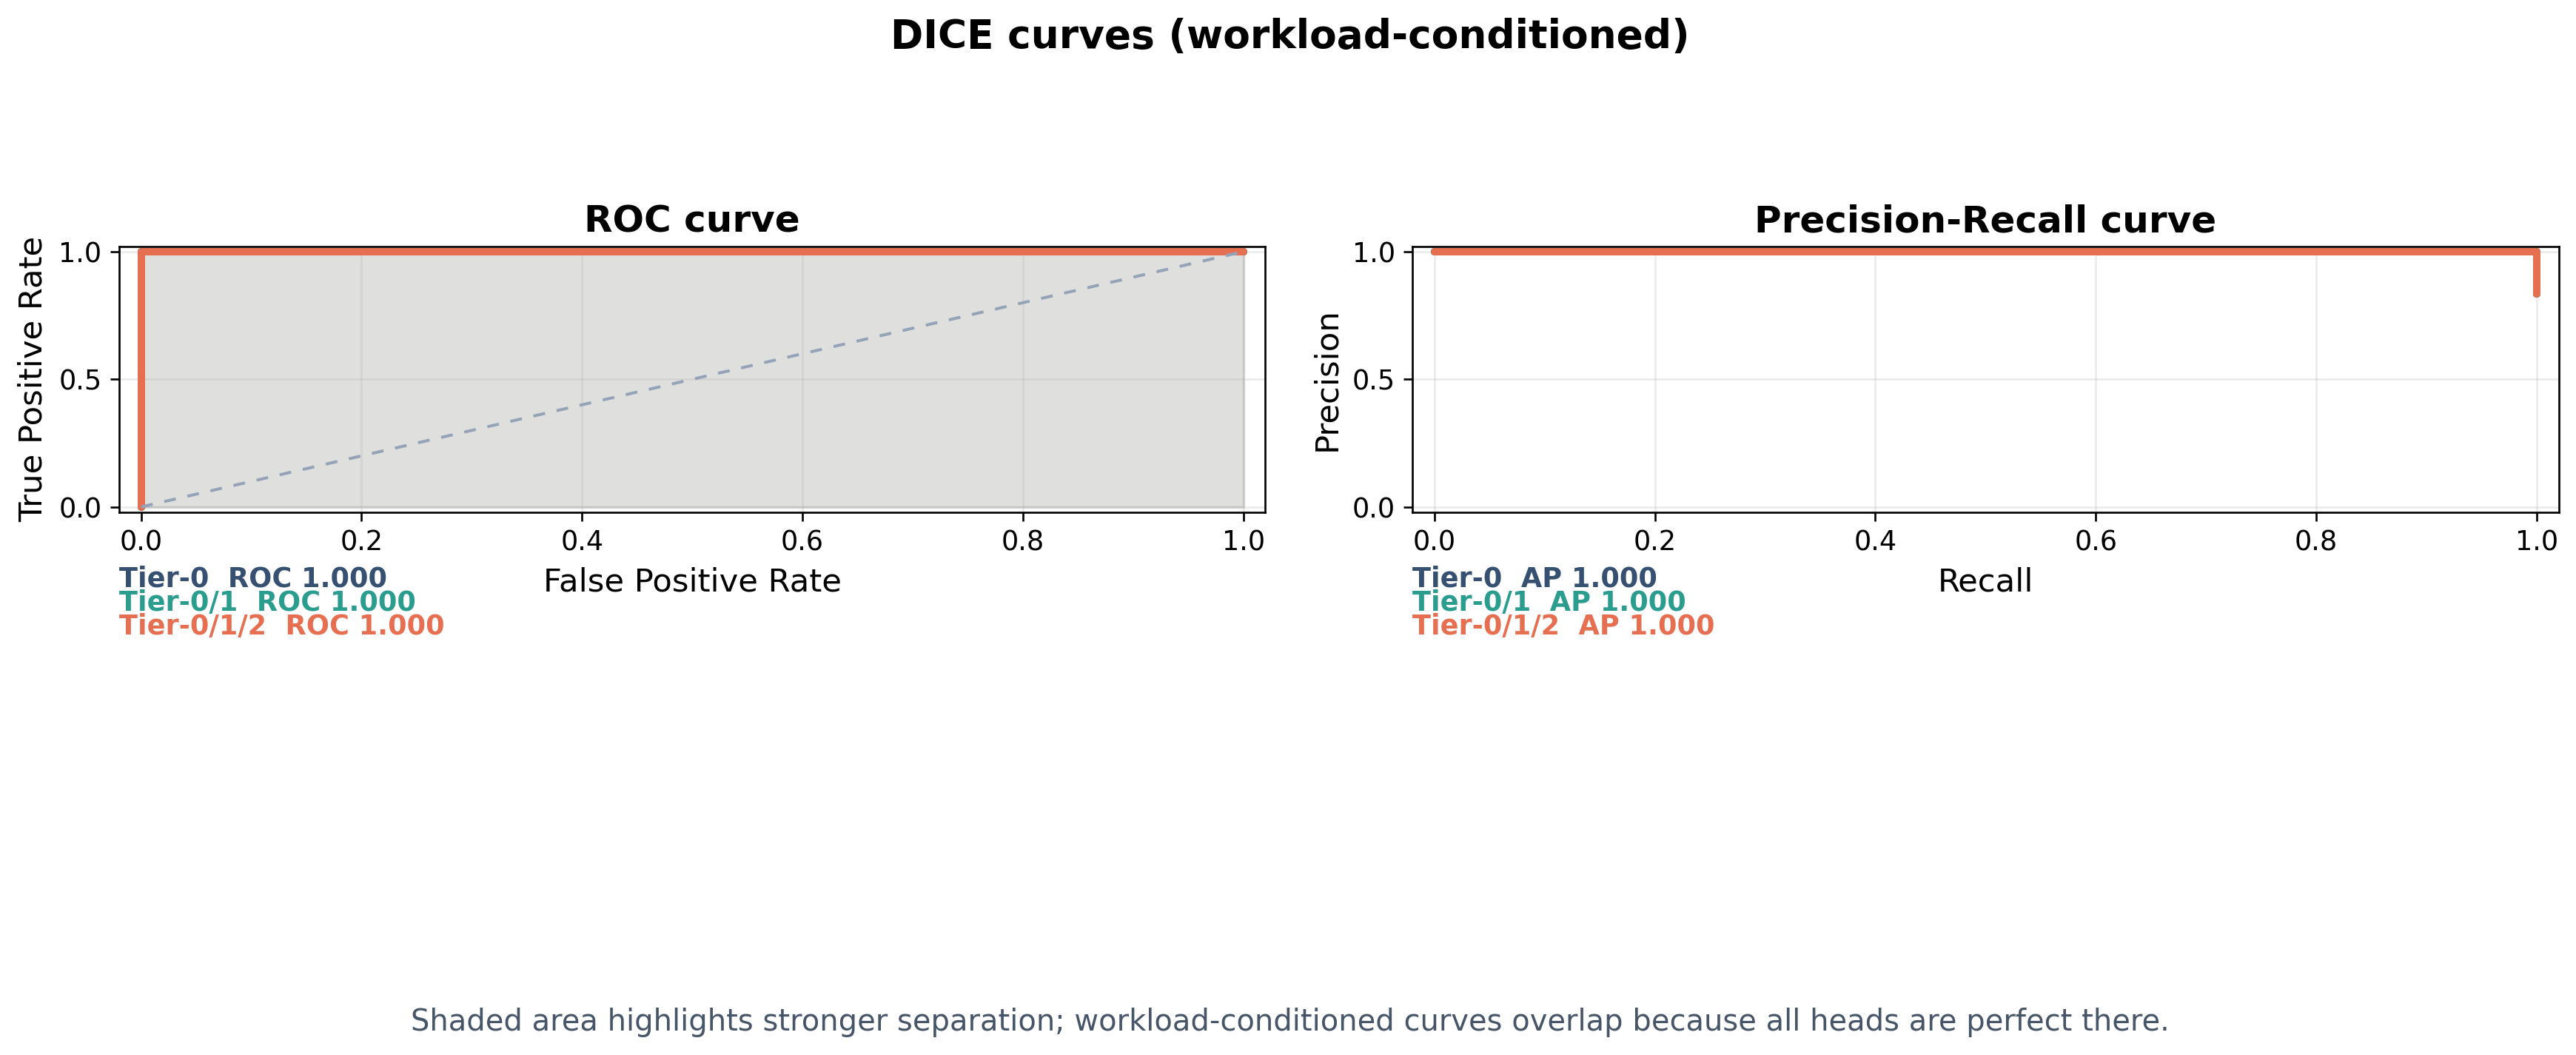

#### Run-score distributions

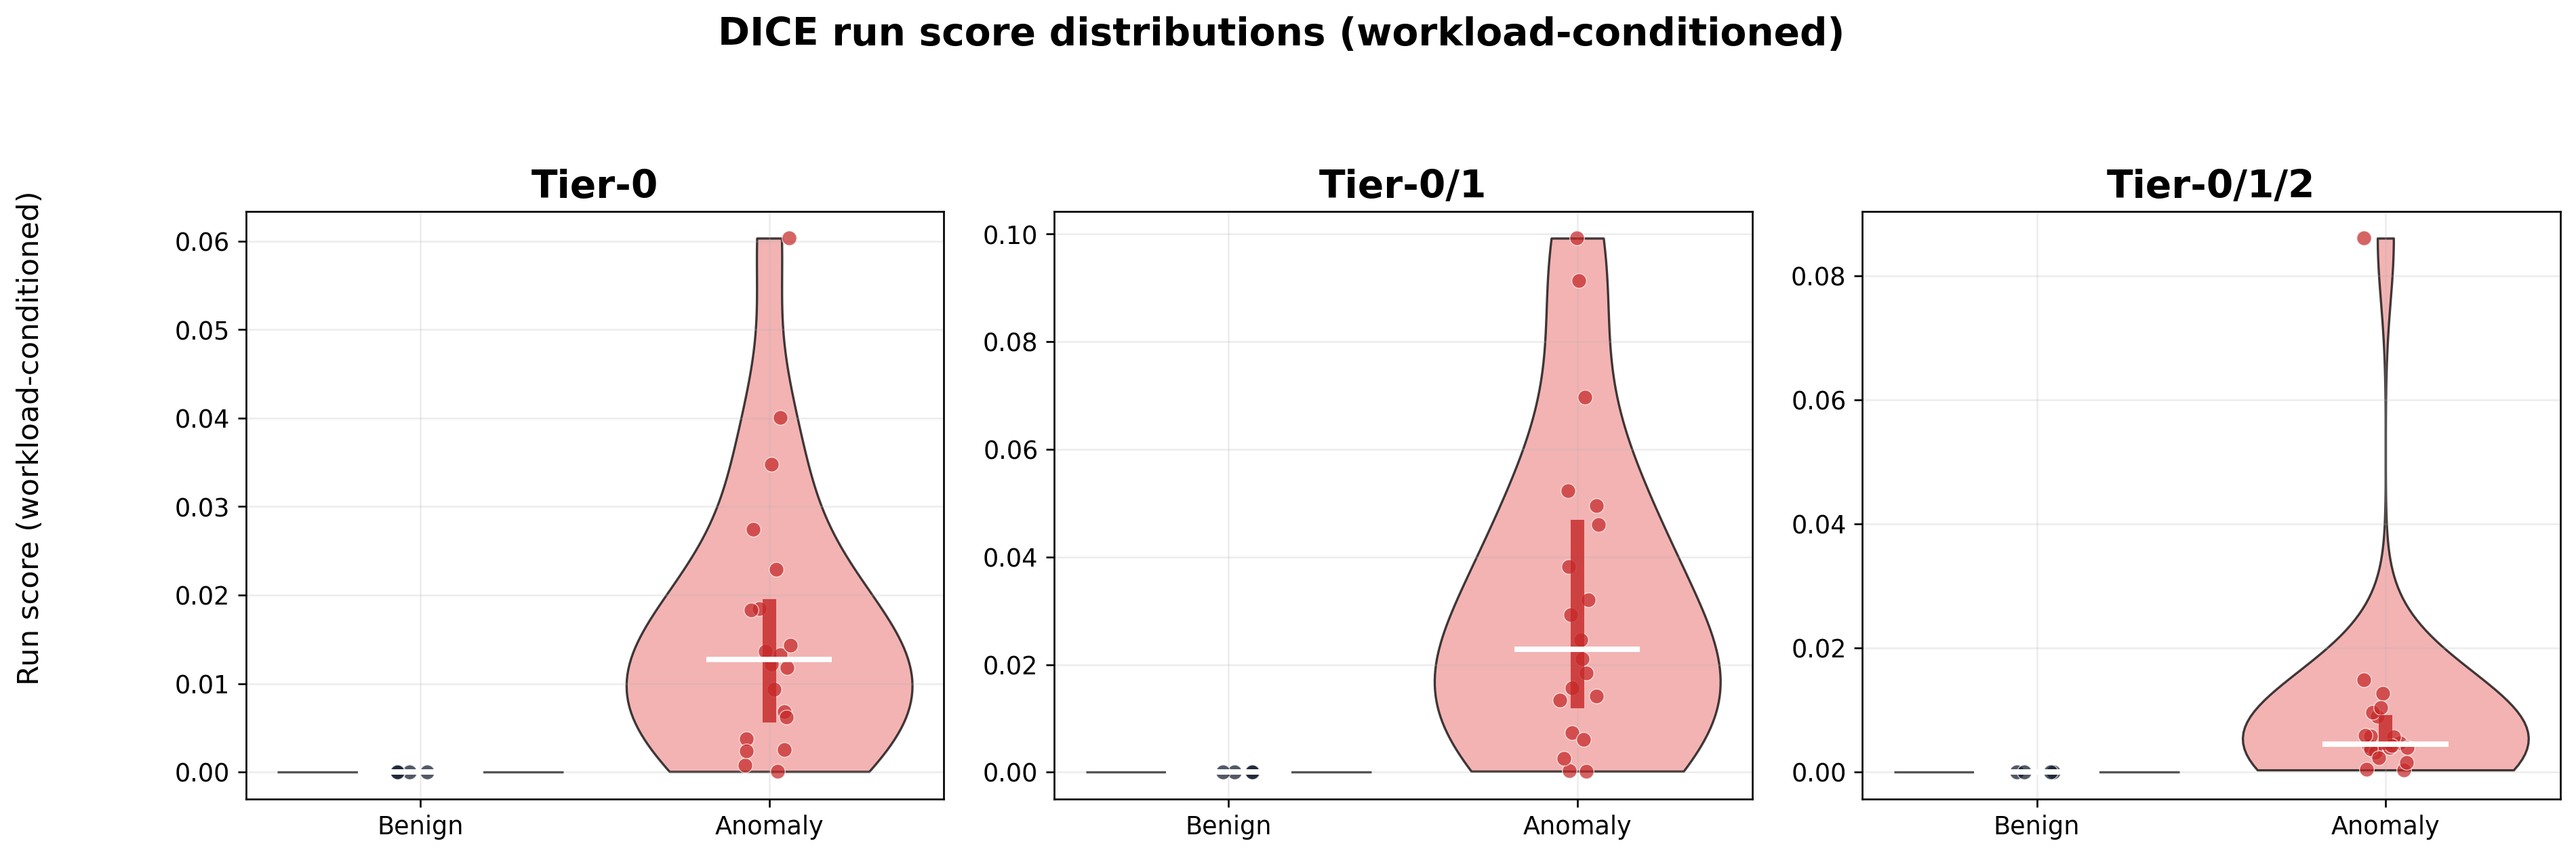

#### Detection latency

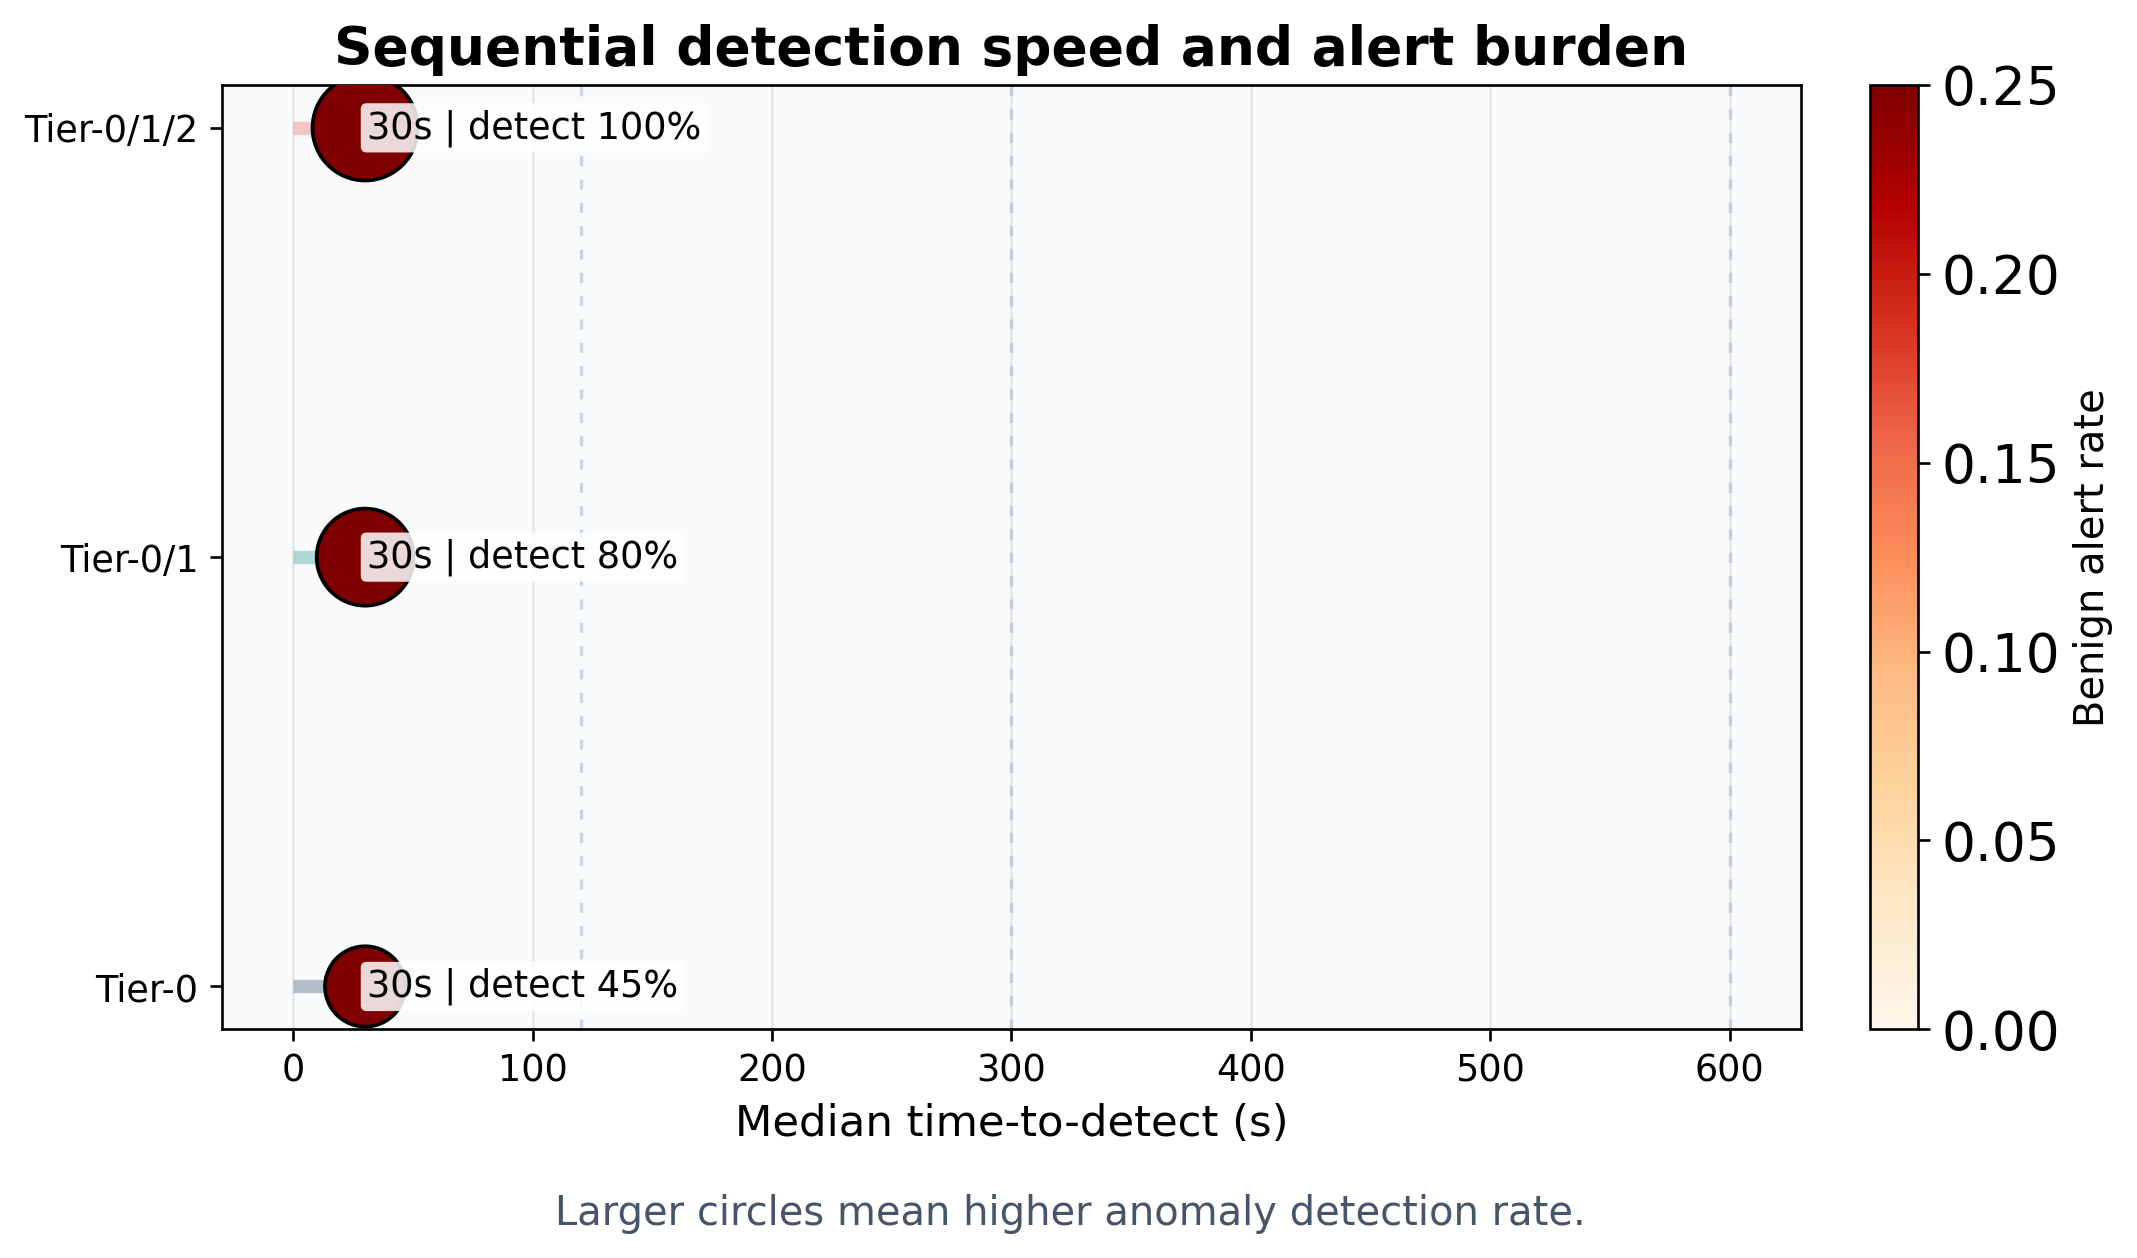

#### Stressor confusion

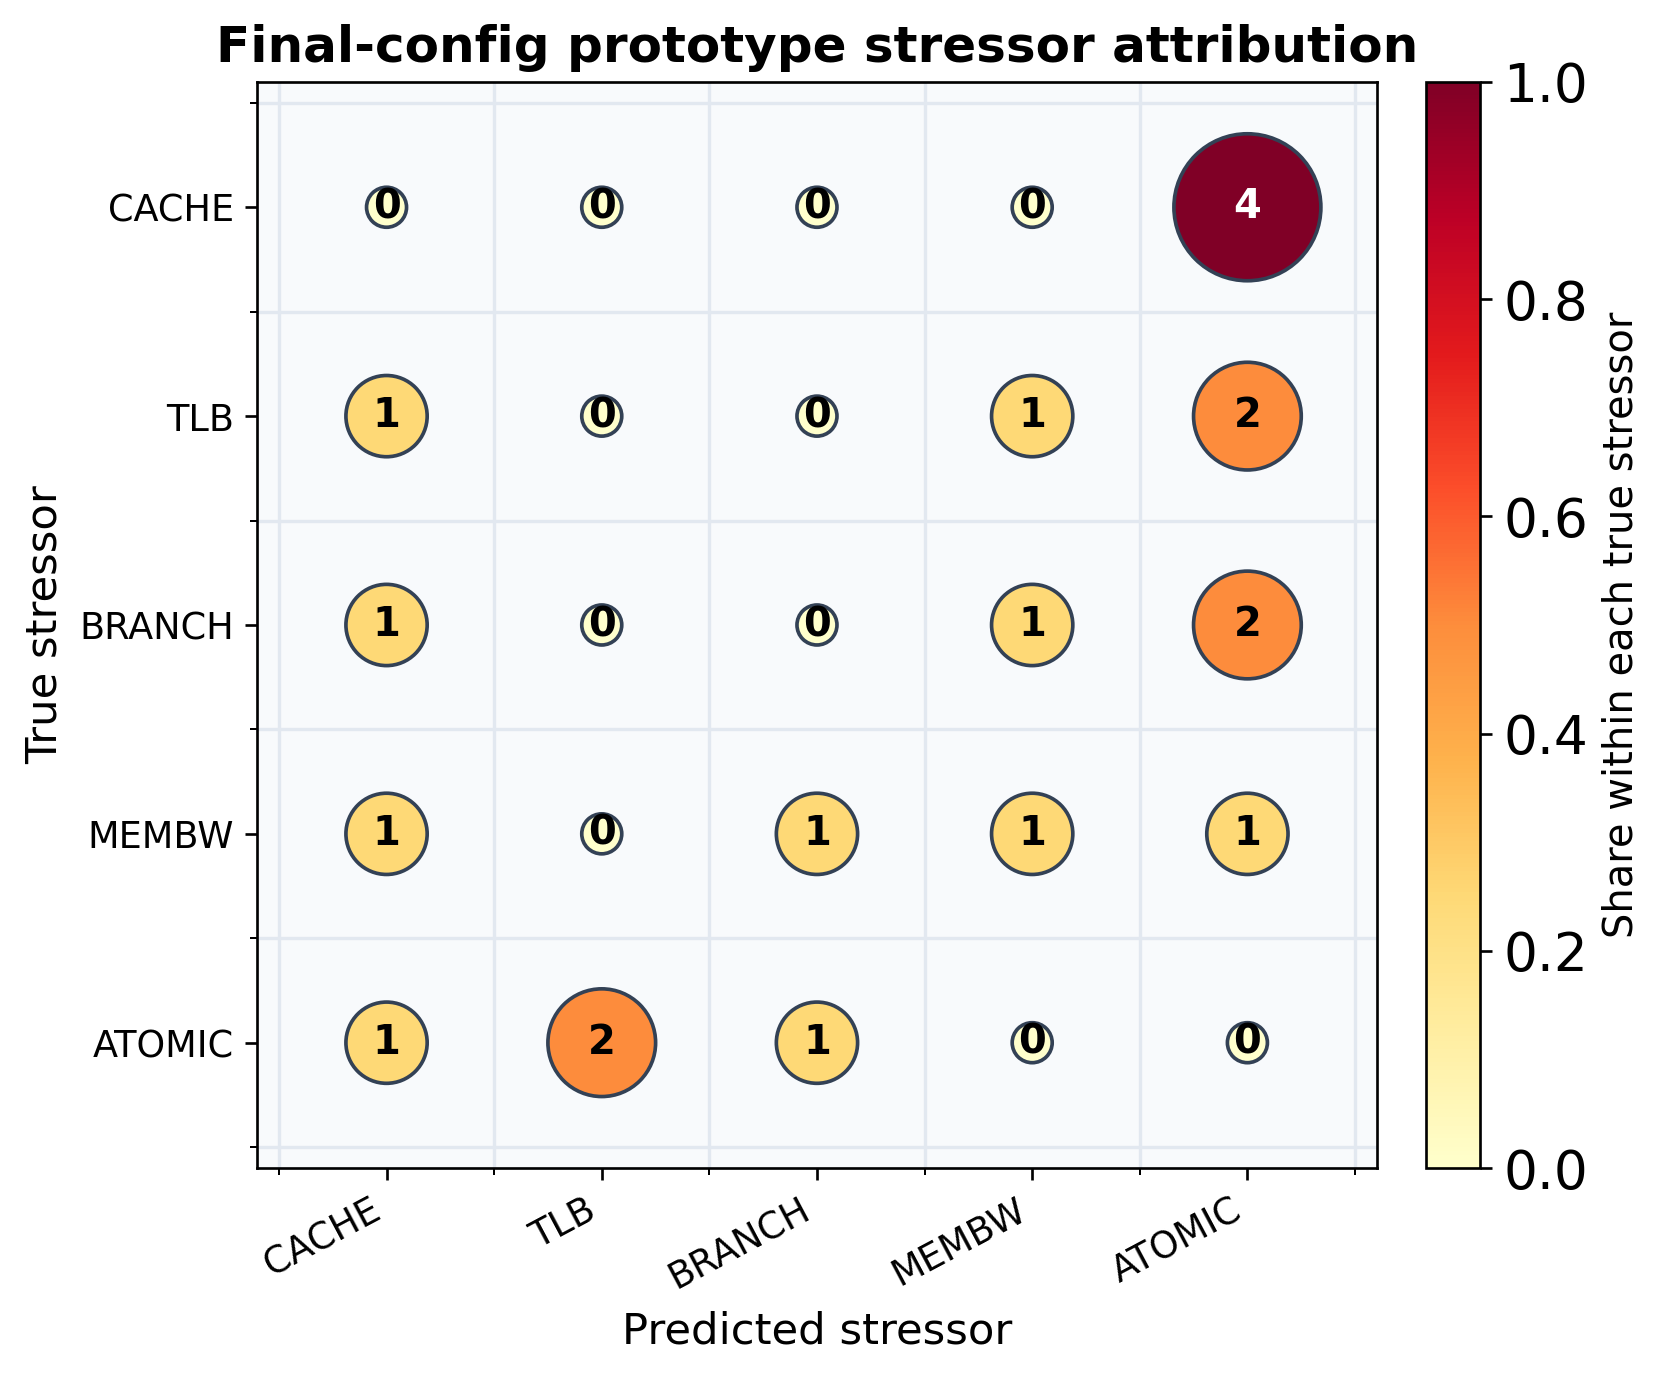

#### Tier contributions

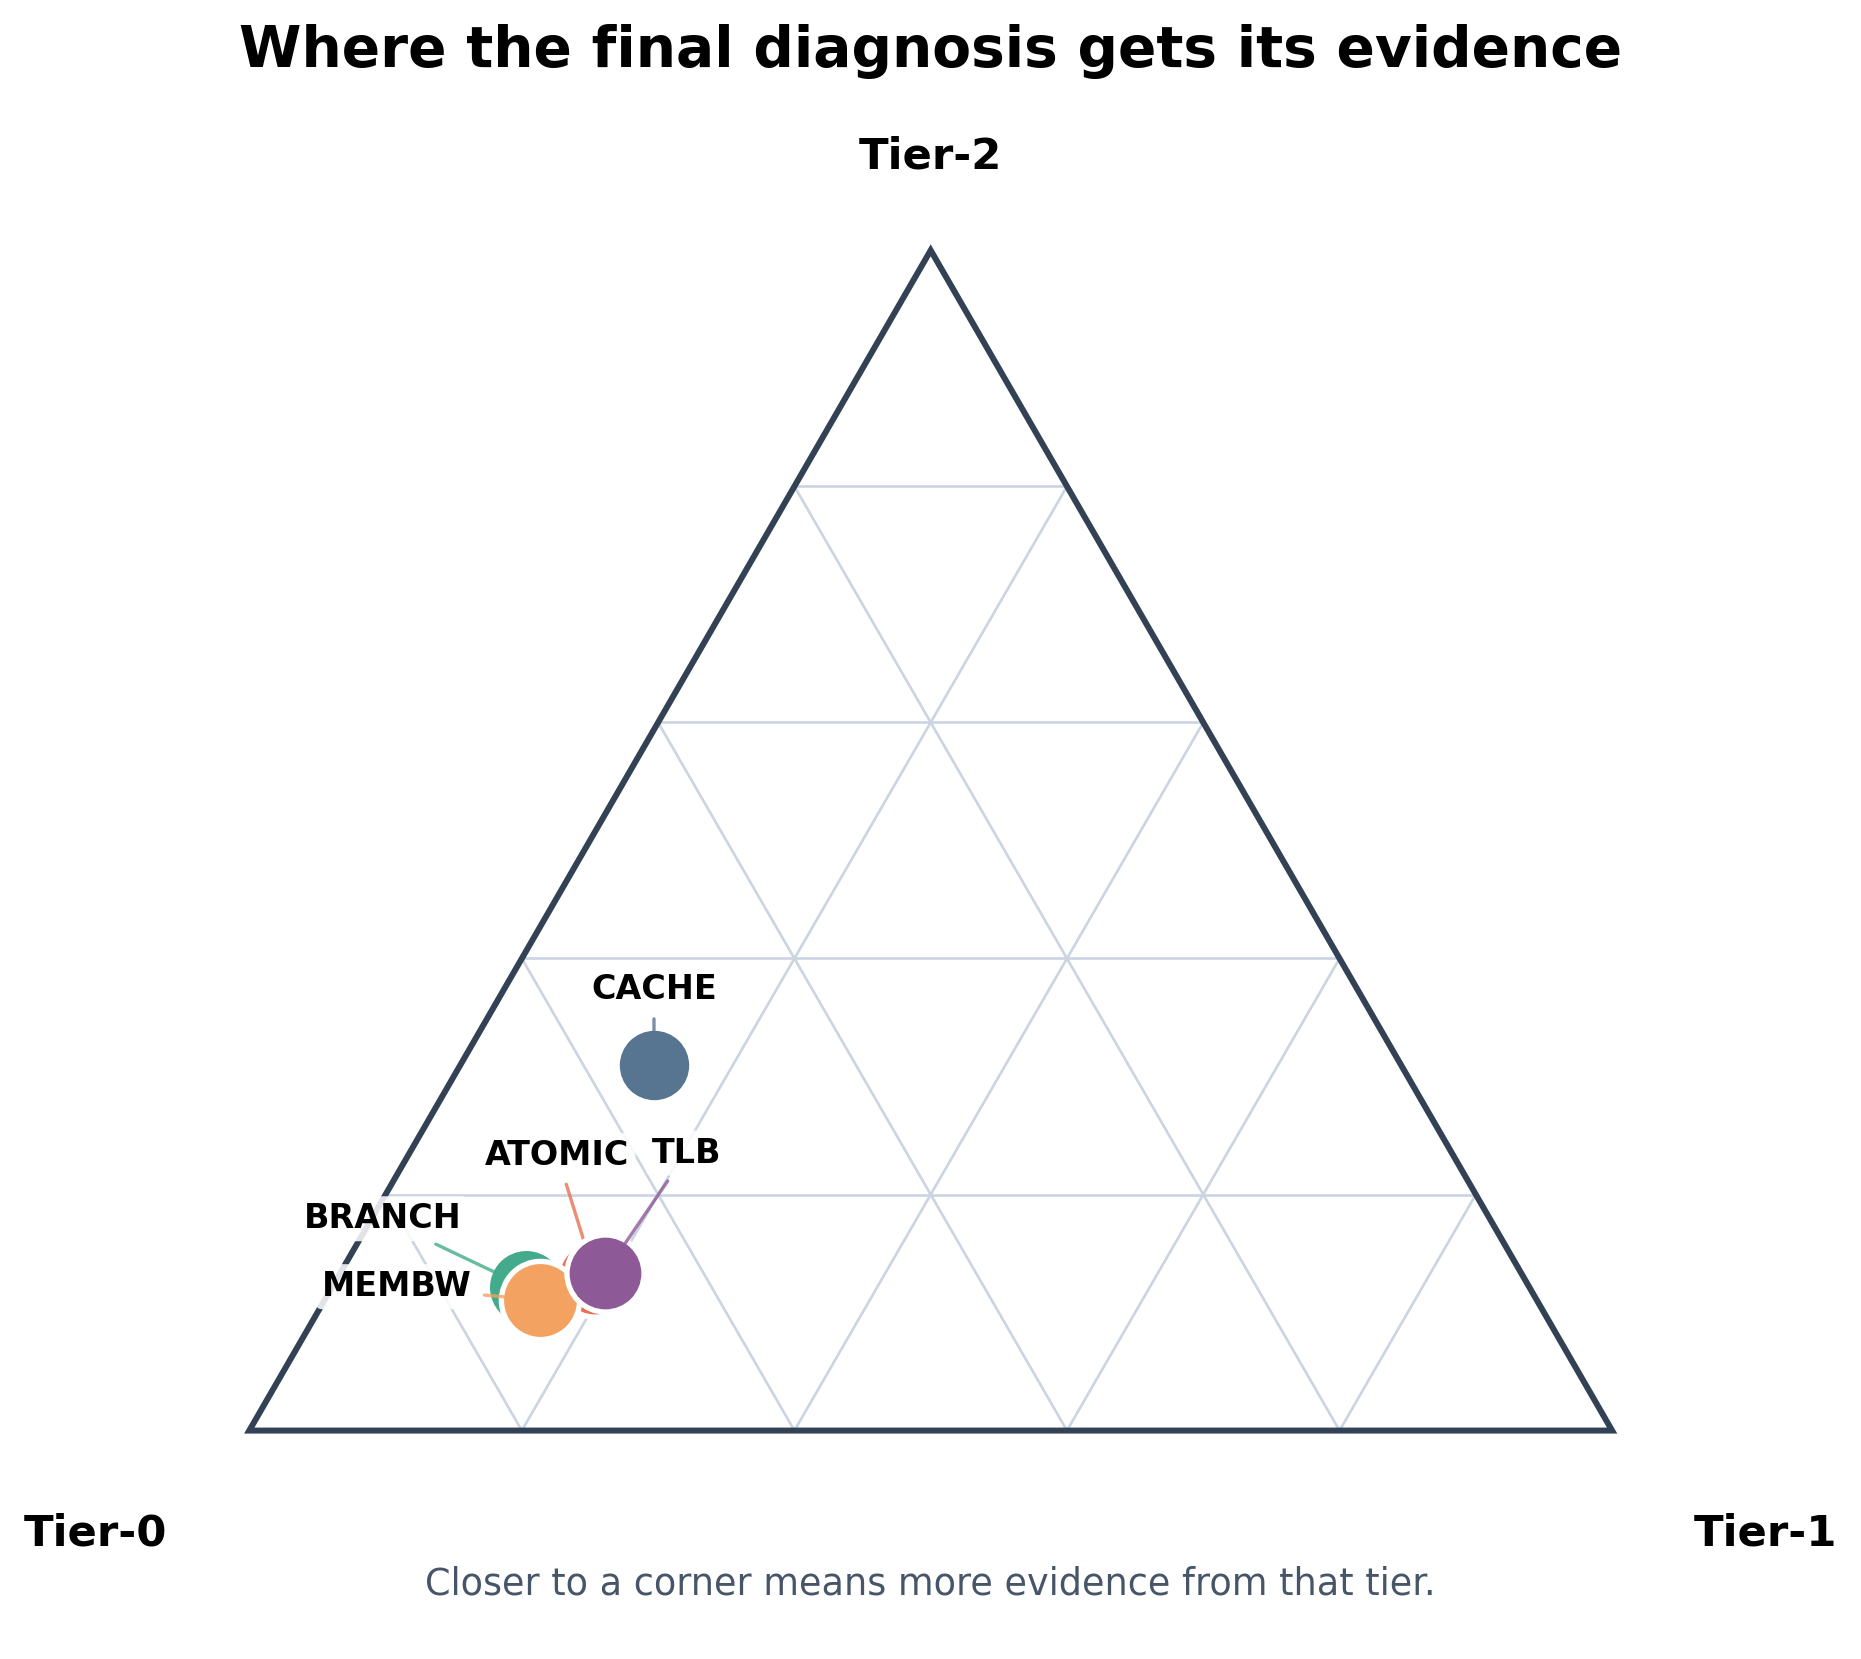

#### Mechanism contributions

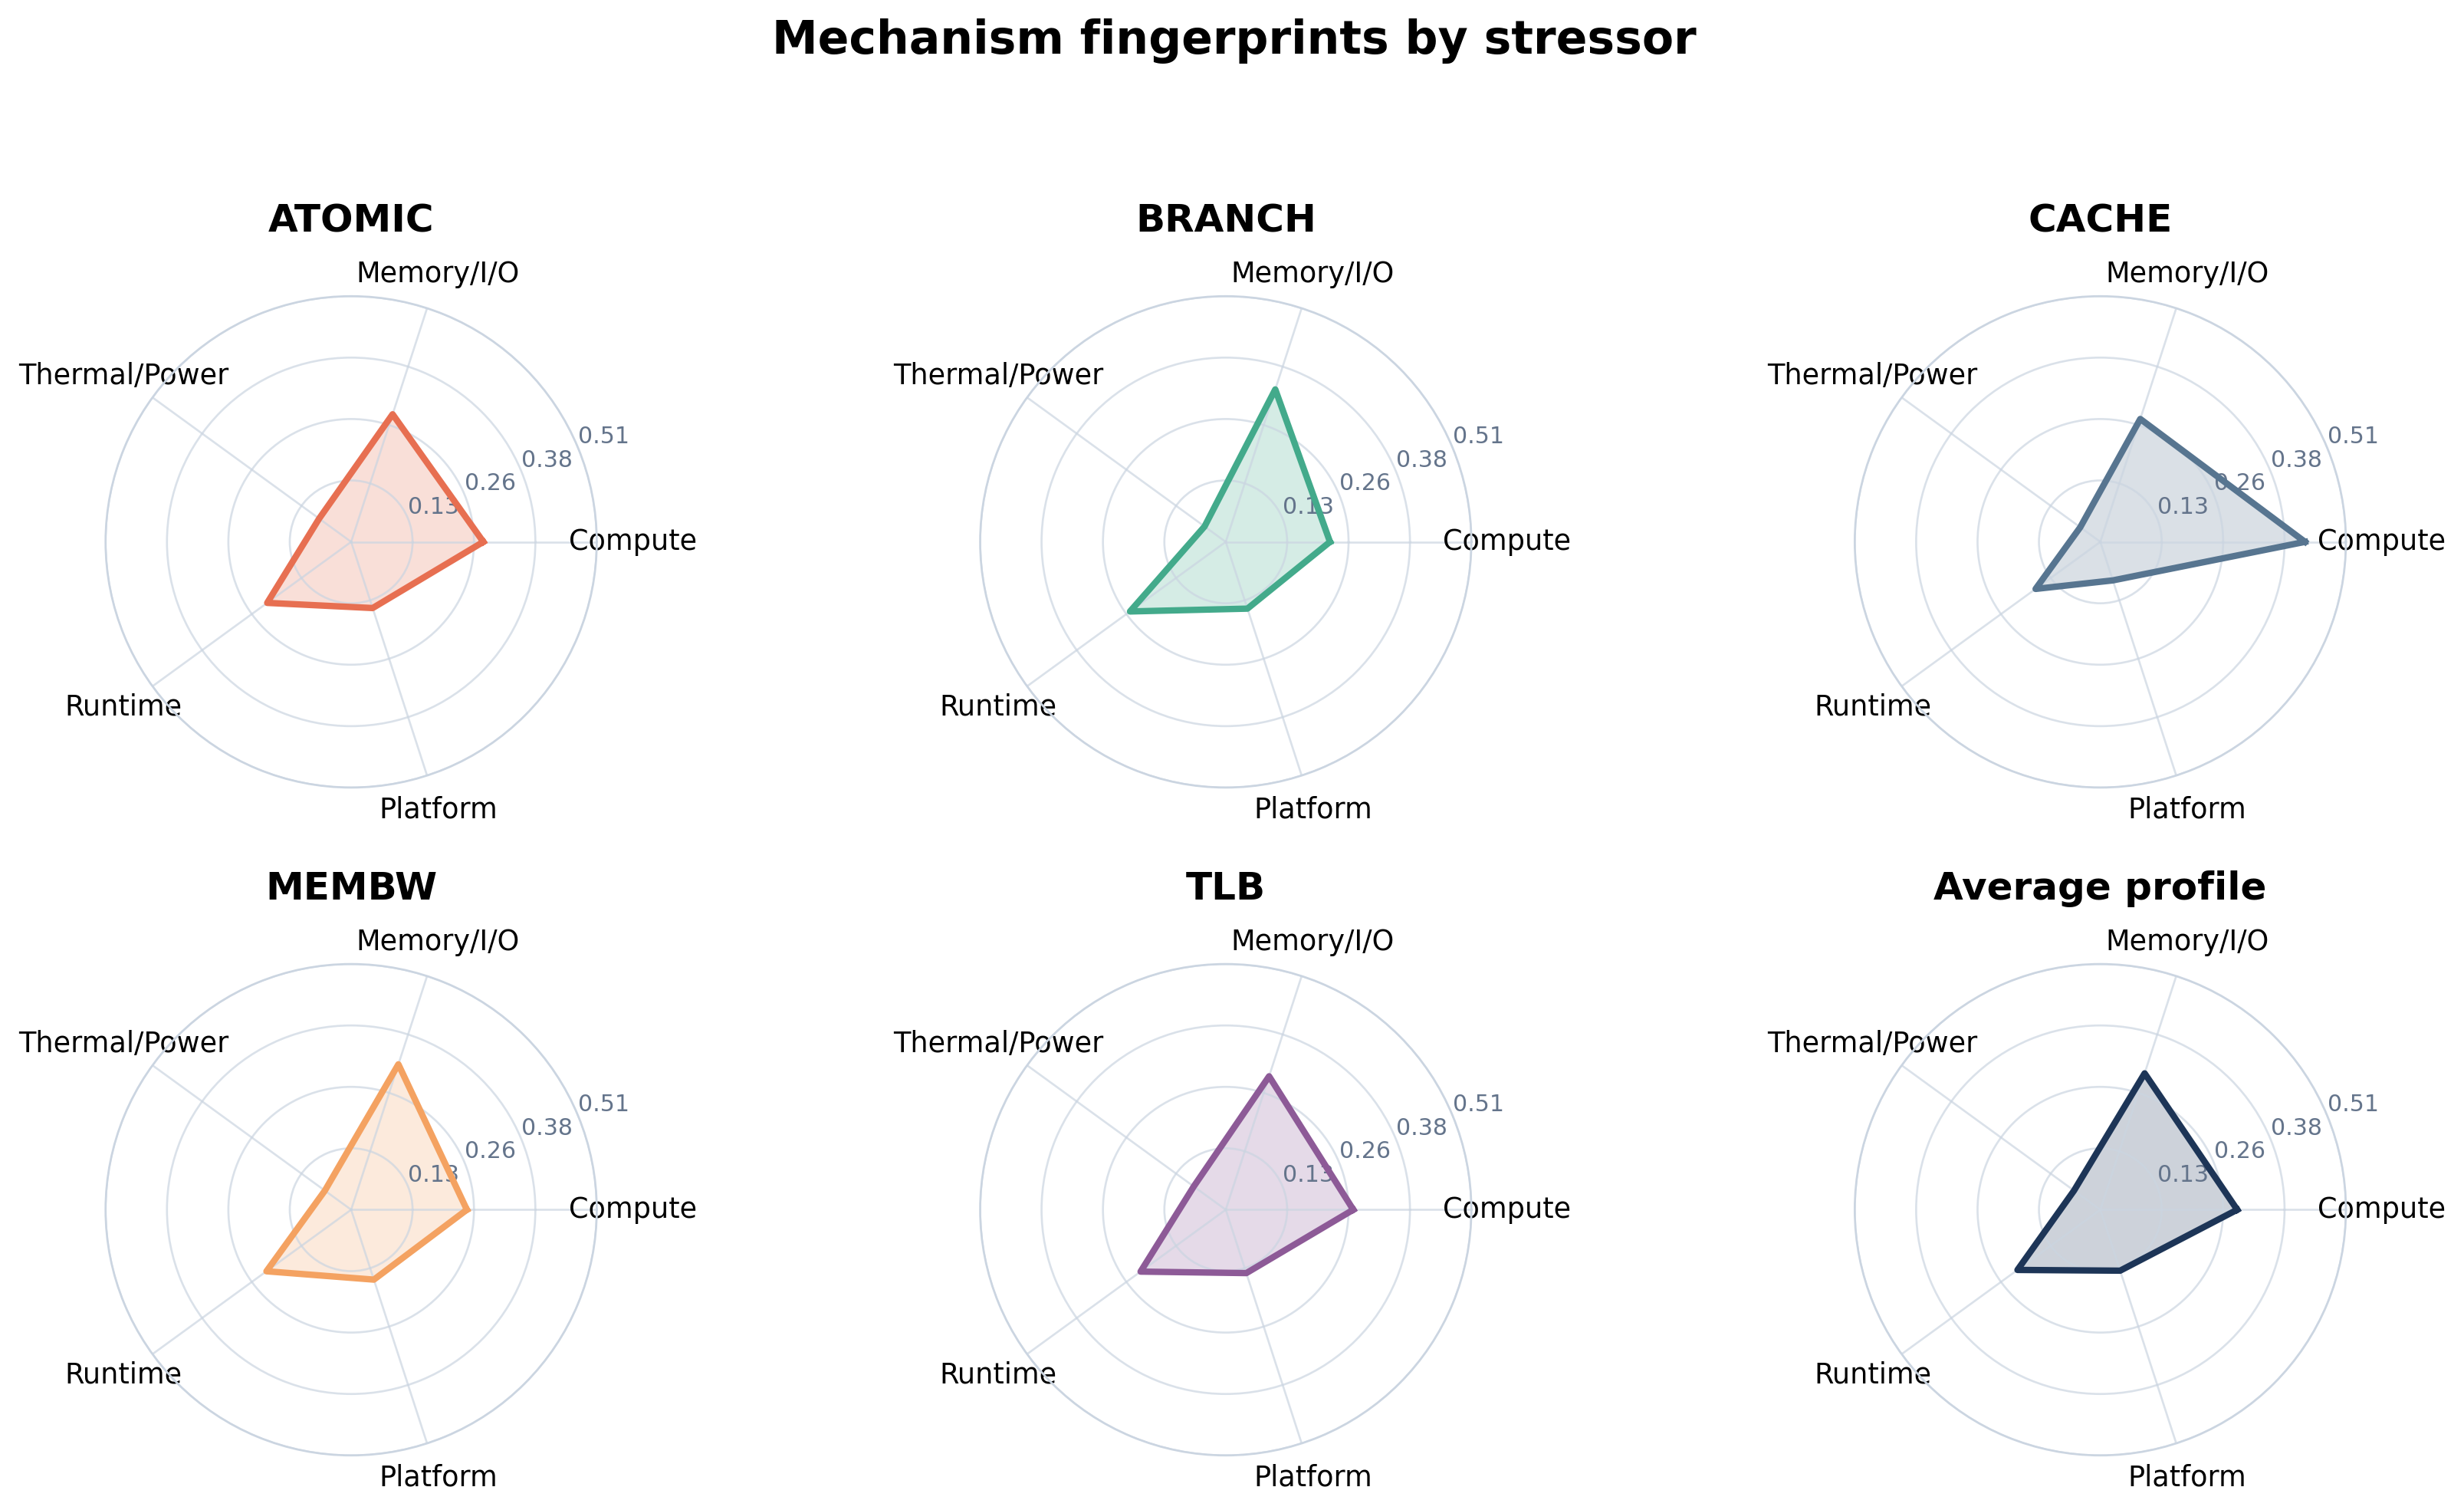

### Two-stage DICE summary

/var/folders/2z/b1lzf17n4z90pz80khfc42fw0000gp/T/ipykernel_12852/1882438553.py:633: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
RUN_END_TO_END = True
INCLUDE_TUNING = True  # Run the full parameter sweep for each feature profile in FEATURE_PROFILES_TO_SWEEP.
ALERT_TUNING_OBJECTIVE = 'balanced'  # Choose from: 'conservative', 'balanced', 'aggressive'.
USE_TUNED_ALERT_CONFIG = True  # Use each profile's recommended_alert_config.csv for the main outputs.
TUNED_ALERT_CONFIG_PATH = None  # Optional explicit CSV path; may include {feature_profile}; defaults to each profile's tuning folder.
RUN_HOLDOUT = True

RUN_TWO_STAGE = True
TWO_STAGE_QUANTILES = [0.90, 0.95, 0.98]

QUIET_STAGE_OUTPUT = True
SHOW_RESULT_GALLERY = True

import io
import html
from contextlib import redirect_stdout, redirect_stderr
from IPython.display import HTML, Image

runtime_start = perf_counter()
notebook_run_summary = {}
stage_logs = {}

progress_view = display(HTML(''), display_id=True)


def update_progress(done, total, title, detail=''):
    pct = 100.0 * done / max(total, 1)
    progress_view.update(
        HTML(
            f"""
            <div style="border:1px solid #d8d8d8; border-radius:12px; padding:14px; margin:8px 0;">
              <div style="font-weight:700; margin-bottom:8px;">DICE artifact generation progress</div>
              <div style="background:#eeeeee; border-radius:999px; overflow:hidden; height:12px;">
                <div style="width:{pct:.1f}%; background:linear-gradient(90deg,#4E79A7,#59A14F); height:12px;"></div>
              </div>
              <div style="margin-top:10px;"><b>{done}/{total}</b> stages complete</div>
              <div style="margin-top:6px;"><b>Current stage:</b> {html.escape(title)}</div>
              <div style="color:#666; margin-top:4px;">{html.escape(detail)}</div>
            </div>
            """
        )
    )


def run_stage(step_idx, total_steps, stage_name, fn, *args, detail='', **kwargs):
    update_progress(step_idx - 1, total_steps, stage_name, detail)
    buf = io.StringIO()
    t0 = perf_counter()
    try:
        if QUIET_STAGE_OUTPUT:
            with redirect_stdout(buf), redirect_stderr(buf):
                out = fn(*args, **kwargs)
        else:
            out = fn(*args, **kwargs)
        elapsed = perf_counter() - t0
        stage_logs[stage_name] = buf.getvalue()
        update_progress(step_idx, total_steps, f'{stage_name} complete', f'Finished in {elapsed:.2f} s')
        return out
    except Exception as exc:
        stage_logs[stage_name] = buf.getvalue()
        update_progress(step_idx - 1, total_steps, f'{stage_name} failed', str(exc))
        raise


def resolve_tuned_alert_config_path(profile: str, tuning_out: Path) -> Path:
    if TUNED_ALERT_CONFIG_PATH:
        raw = str(TUNED_ALERT_CONFIG_PATH)
        candidate = raw.format(feature_profile=profile) if '{feature_profile}' in raw else raw
        candidate_path = Path(candidate).expanduser()
        if candidate_path.is_dir():
            return (candidate_path / 'recommended_alert_config.csv').resolve()
        return candidate_path.resolve()
    return (Path(tuning_out) / 'recommended_alert_config.csv').resolve()


def resolve_primary_profile_run(profile_runs: dict[str, dict[str, object]], preferred_profile: str) -> tuple[str, Path, Path | None, Path | None]:
    candidates = []
    if preferred_profile in FEATURE_PROFILES_TO_SWEEP:
        candidates.append(preferred_profile)
    for profile in FEATURE_PROFILES_TO_SWEEP:
        if profile not in candidates:
            candidates.append(profile)

    for profile in candidates:
        run = profile_runs.get(profile, {}) if isinstance(profile_runs, dict) else {}
        global_dir = Path(run['global_out']).expanduser().resolve() if run.get('global_out') else PROFILE_OUT_DIRS[profile]['global']
        holdout_dir = Path(run['holdout_out']).expanduser().resolve() if run.get('holdout_out') else PROFILE_OUT_DIRS[profile]['holdout']
        tuning_dir = Path(run['tuning_out']).expanduser().resolve() if run.get('tuning_out') else default_tuning_out_dir(DATASET_ROOT, profile)
        if (global_dir / 'overall_metrics.csv').exists():
            return (
                profile,
                global_dir,
                holdout_dir if (holdout_dir / 'holdout_robustness_summary.csv').exists() else None,
                tuning_dir if tuning_dir.exists() else None,
            )

    fallback_profile = candidates[0] if candidates else DISPLAY_FEATURE_PROFILE
    return (
        fallback_profile,
        PROFILE_OUT_DIRS[fallback_profile]['global'],
        PROFILE_OUT_DIRS[fallback_profile]['holdout'],
        default_tuning_out_dir(DATASET_ROOT, fallback_profile),
    )


def load_best_diagnosis_metrics(global_dir: Path, final_config: str = 'tier0_tier1_tier2') -> tuple[pd.DataFrame, str, Path | None]:
    candidates = []
    for diag_source, name in [
        ('feature-level', 'stressor_feature_diagnosis_metrics.csv'),
        ('mechanism-level', 'stressor_diagnosis_metrics.csv'),
    ]:
        path = global_dir / name
        if not path.exists():
            continue
        diag = pd.read_csv(path)
        if 'macro_f1' not in diag.columns:
            diag = diag.copy()
            diag['macro_f1'] = np.nan
        final_rows = diag[diag['config'] == final_config]
        row = final_rows.iloc[0] if not final_rows.empty else (diag.iloc[0] if not diag.empty else None)
        if row is None:
            continue
        candidates.append(
            (
                np.nan_to_num(float(row.get('top1_acc', np.nan)), nan=-1.0),
                np.nan_to_num(float(row.get('top2_acc', np.nan)), nan=-1.0),
                np.nan_to_num(float(row.get('macro_f1', np.nan)), nan=-1.0),
                diag_source,
                diag,
                path,
            )
        )
    if not candidates:
        return pd.DataFrame(), 'unavailable', None
    _, _, _, diag_source, diag, path = sorted(candidates)[-1]
    return diag, diag_source, path


def display_inline_figure(fig, dpi: int = 180) -> None:
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buf.getvalue()))


def resolve_stage2_config(case_pred: pd.DataFrame) -> str | None:
    available_cfgs = set(case_pred['config'].dropna().astype(str))
    for candidate in ['tier0_tier1_tier2', 'tier0_tier1_alt_tier2', 'tier0_tier1']:
        if candidate in available_cfgs:
            return candidate
    return sorted(available_cfgs)[-1] if available_cfgs else None


if RUN_END_TO_END:
    deterministic_env()
    root = Path(DATASET_ROOT).expanduser().resolve()
    ensure_dataset_root(root)

    profiles = FEATURE_PROFILES_TO_SWEEP
    total_steps = 1 + len(profiles) * (1 + int(RUN_HOLDOUT) + int(INCLUDE_TUNING))
    step = 1

    base_operating_point = {
        'source_hz': 5,
        'fit_ratio': 0.6,
        'block_B': 60,
        'alpha': 0.05,
        'persist_k': 3,
        'gain': 0.35,
        'ridge_lambda': 1e-3,
    }
    profile_runs = {}

    analysis_out = run_stage(
        step,
        total_steps,
        'Analysis figures',
        run_analysis_notebook,
        root,
        source_hz=5,
        detail='Generating tier-level tables, heatmaps, and AF-index figures.',
    )
    step += 1

    for profile in profiles:
        operating_point = dict(base_operating_point)
        tuned_operating_point = None
        tuning_out = None

        if INCLUDE_TUNING and USE_TUNED_ALERT_CONFIG:
            tuning_out = run_stage(
                step,
                total_steps,
                f'Tuning sweep [{profile}]',
                run_tuning_notebook,
                root,
                source_hz=operating_point['source_hz'],
                fit_ratio=operating_point['fit_ratio'],
                ridge_lambda=operating_point['ridge_lambda'],
                feature_profile=profile,
                selection_mode=ALERT_TUNING_OBJECTIVE,
                detail=f'Running the full parameter sweep for the {profile} profile and selecting an alert-oriented operating point.',
            )
            tuned_path = resolve_tuned_alert_config_path(profile, Path(tuning_out))
            if tuned_path.exists():
                tuned_df = pd.read_csv(tuned_path)
                if not tuned_df.empty:
                    tuned_row = tuned_df.iloc[0]
                    tuned_operating_point = {
                        'block_B': int(tuned_row['block_B']),
                        'alpha': float(tuned_row['alpha']),
                        'persist_k': int(tuned_row['persist_k']),
                        'gain': float(tuned_row['gain']),
                    }
                    operating_point.update(tuned_operating_point)
            step += 1

        full_out = run_stage(
            step,
            total_steps,
            f'Global DICE results [{profile}]',
            run_full_notebook,
            root,
            protocol='global',
            source_hz=operating_point['source_hz'],
            fit_ratio=operating_point['fit_ratio'],
            block_B=operating_point['block_B'],
            alpha=operating_point['alpha'],
            persist_k=operating_point['persist_k'],
            gain=operating_point['gain'],
            ridge_lambda=operating_point['ridge_lambda'],
            feature_profile=profile,
            detail=f'Generating global metrics and figures for the {profile} profile.',
        )
        step += 1

        holdout_out = None
        if RUN_HOLDOUT:
            holdout_out = run_stage(
                step,
                total_steps,
                f'Holdout robustness [{profile}]',
                run_full_notebook,
                root,
                protocol='workload_holdout',
                source_hz=operating_point['source_hz'],
                fit_ratio=operating_point['fit_ratio'],
                block_B=operating_point['block_B'],
                alpha=operating_point['alpha'],
                persist_k=operating_point['persist_k'],
                gain=operating_point['gain'],
                ridge_lambda=operating_point['ridge_lambda'],
                feature_profile=profile,
                detail=f'Generating workload-holdout summaries for the {profile} profile.',
            )
            step += 1

        if INCLUDE_TUNING and not USE_TUNED_ALERT_CONFIG:
            tuning_out = run_stage(
                step,
                total_steps,
                f'Tuning sweep [{profile}]',
                run_tuning_notebook,
                root,
                source_hz=operating_point['source_hz'],
                fit_ratio=operating_point['fit_ratio'],
                ridge_lambda=operating_point['ridge_lambda'],
                feature_profile=profile,
                selection_mode=ALERT_TUNING_OBJECTIVE,
                detail=f'Running the full parameter sweep for the {profile} profile after the main outputs.',
            )
            step += 1

        profile_runs[profile] = {
            'feature_profile': profile,
            'global_out': str(full_out),
            'holdout_out': str(holdout_out) if holdout_out else '',
            'tuning_out': str(tuning_out) if tuning_out else '',
            'operating_point': dict(operating_point),
            'tuned_operating_point': tuned_operating_point or {},
        }


    display_profile = DISPLAY_FEATURE_PROFILE
    primary_run = profile_runs[display_profile]
    full_out = Path(primary_run['global_out'])
    holdout_out = Path(primary_run['holdout_out']) if primary_run['holdout_out'] else None
    tuning_out = Path(primary_run['tuning_out']) if primary_run['tuning_out'] else None

    update_progress(step - 1, total_steps, 'Writing manifest', 'Saving reproducibility metadata.')
    run_config = {
        **base_operating_point,
        'run_holdout': RUN_HOLDOUT,
        'include_tuning': INCLUDE_TUNING,
        'feature_profiles_swept': profiles,
        'display_feature_profile': display_profile,
        'alert_tuning_objective': ALERT_TUNING_OBJECTIVE,
        'use_tuned_alert_config': USE_TUNED_ALERT_CONFIG,
        'tuned_alert_config_path': str(TUNED_ALERT_CONFIG_PATH) if TUNED_ALERT_CONFIG_PATH else '',
        'profile_runs': profile_runs,
    }
    manifest_path = write_run_manifest(root, analysis_out, full_out, holdout_out, tuning_out, run_config)
    update_progress(total_steps, total_steps, 'All stages complete', 'All figures and CSV artifacts are ready.')

    notebook_run_summary = {
        'analysis_out': str(analysis_out),
        'full_out': str(full_out),
        'holdout_out': str(holdout_out) if holdout_out else '',
        'tuning_out': str(tuning_out) if tuning_out else '',
        'manifest_path': str(manifest_path),
        'run_holdout': RUN_HOLDOUT,
        'include_tuning': INCLUDE_TUNING,
        'feature_profiles_swept': profiles,
        'display_feature_profile': display_profile,
        'profile_runs': profile_runs,
    }
else:
    print('Skipped end-to-end run. Set RUN_END_TO_END=True to execute.')

runtime_seconds = round(perf_counter() - runtime_start, 2)
runtime_summary = {
    'runtime_seconds': runtime_seconds,
    'runtime_minutes': round(runtime_seconds / 60.0, 2),
    'run_end_to_end': RUN_END_TO_END,
    'run_holdout': RUN_HOLDOUT,
    'include_tuning': INCLUDE_TUNING,
    'feature_profiles_swept': FEATURE_PROFILES_TO_SWEEP,
    'display_feature_profile': DISPLAY_FEATURE_PROFILE,
    'repo_root': str(REPO_ROOT),
    'dataset_root': str(DATASET_ROOT),
    **notebook_run_summary,
}
NOTEBOOK_RUNTIME.write_text(json.dumps(runtime_summary, indent=2))
NOTEBOOK_RUNTIME.with_name('run_console.log').write_text(
    "\n\n".join(f'===== {k} =====\n{v}' for k, v in stage_logs.items())
)


def show_png(title, path, width=900):
    if path.exists():
        display(Markdown(f'#### {title}'))
        display(Image(filename=str(path), width=width))


def draw_metric_paths(ax, df, specs, title, y_label, ylim=(0.0, 1.05)):
    x = np.arange(len(df))
    for col, label, color, marker, yoff in specs:
        vals = df[col].to_numpy(dtype=float)
        ax.plot(x, vals, color=color, marker=marker, linewidth=3.0, markersize=10)
        for xi, yi in zip(x, vals):
            ax.text(xi, yi + 0.035, f'{yi:.2f}', ha='center', fontsize=11, color=color)
        ax.text(x[-1] + 0.22, vals[-1] + yoff, label, color=color, fontsize=13, fontweight='bold', va='center')
    ax.set_xticks(x)
    ax.set_xticklabels(df['label'])
    ax.set_xlim(-0.15, x[-1] + 0.95)
    ax.set_ylim(*ylim)
    ax.set_ylabel(y_label)
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.22)


def draw_dumbbell(ax, df, left_col, right_col, left_label, right_label, title, xlim=(0.0, 1.05)):
    y = np.arange(len(df))
    left = df[left_col].to_numpy(dtype=float)
    right = df[right_col].to_numpy(dtype=float)
    ax.hlines(y, left, right, color='#CBD5E1', linewidth=5, zorder=1)
    ax.scatter(left, y, s=150, color='#F28E2B', edgecolor='white', linewidth=1.5, zorder=3)
    ax.scatter(right, y, s=170, color='#E15759', edgecolor='white', linewidth=1.5, zorder=4)
    for yi, lv, rv in zip(y, left, right):
        ax.text(lv - 0.035, yi, f'{lv:.2f}', ha='right', va='center', fontsize=11, color='#9A3412')
        ax.text(rv + 0.035, yi, f'{rv:.2f}', ha='left', va='center', fontsize=11, color='#991B1B')
    ax.set_yticks(y)
    ax.set_yticklabels(df['label'])
    ax.set_xlim(*xlim)
    ax.set_xlabel('Rate')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.22)
    ax.text(
        0.0,
        1.05,
        f'Left marker = {left_label}; right marker = {right_label}',
        transform=ax.transAxes,
        fontsize=11,
        color='#475569',
        ha='left',
    )

summary_profile, summary_global_dir, summary_holdout_dir, summary_tuning_dir = resolve_primary_profile_run(
    notebook_run_summary.get('profile_runs', {}) if isinstance(notebook_run_summary, dict) else {},
    notebook_run_summary.get('display_feature_profile', DISPLAY_FEATURE_PROFILE) if isinstance(notebook_run_summary, dict) else DISPLAY_FEATURE_PROFILE,
)
ACTIVE_RESULT_PROFILE = summary_profile
ACTIVE_OUT_FULL = summary_global_dir
ACTIVE_OUT_HOLDOUT = summary_holdout_dir if summary_holdout_dir is not None else OUT_HOLDOUT
ACTIVE_TUNING_OUT = summary_tuning_dir if summary_tuning_dir is not None else default_tuning_out_dir(DATASET_ROOT, summary_profile)

required_bundle = [
    summary_global_dir / 'overall_metrics.csv',
    summary_global_dir / 'sequential_metrics.csv',
    summary_global_dir / 'stressor_metrics_final_config.csv',
]
missing_bundle = [p for p in required_bundle if not p.exists()]

display(Markdown('### End-to-end DICE run summary'))
display(Markdown(f"Runtime: **{runtime_summary['runtime_minutes']:.2f} min**"))

if missing_bundle:
    missing_md = '<br>'.join(f'`{p}`' for p in missing_bundle)
    display(
        Markdown(
            f"Primary result bundle for profile `{summary_profile}` is incomplete. Missing:<br>{missing_md}"
        )
    )
else:
    overall_full = pd.read_csv(summary_global_dir / 'overall_metrics.csv')
    sequential = pd.read_csv(summary_global_dir / 'sequential_metrics.csv')
    diagnosis, diagnosis_source, diagnosis_path = load_best_diagnosis_metrics(summary_global_dir)
    if 'benign_run_keep_rate' not in sequential.columns and 'benign_run_alert_rate' in sequential.columns:
        sequential = sequential.copy()
        sequential['benign_run_keep_rate'] = 1.0 - sequential['benign_run_alert_rate']
    if diagnosis.empty:
        diagnosis = overall_full[['config']].copy()
        diagnosis['top1_acc'] = np.nan
        diagnosis['top2_acc'] = np.nan
        diagnosis['macro_f1'] = np.nan
    if 'macro_f1' not in diagnosis.columns:
        diagnosis = diagnosis.copy()
        diagnosis['macro_f1'] = np.nan

    stress_final = pd.read_csv(summary_global_dir / 'stressor_metrics_final_config.csv')
    holdout = (
        pd.read_csv(summary_holdout_dir / 'holdout_robustness_summary.csv')
        if summary_holdout_dir is not None and (summary_holdout_dir / 'holdout_robustness_summary.csv').exists()
        else pd.DataFrame()
    )

    summary_df = (
        overall_full[['config', 'roc_auc_wc', 'pr_auc_wc']]
        .merge(
            sequential[
                ['config', 'benign_run_alert_rate', 'benign_run_keep_rate', 'anomaly_detect_rate', 'median_time_to_detect_s']
            ],
            on='config',
            how='left',
        )
        .merge(
            diagnosis[['config', 'top1_acc', 'top2_acc', 'macro_f1']],
            on='config',
            how='left',
        )
    )

    config_label_map = {
        'tier0': 'Tier-0',
        'tier0_tier1': 'Tier-0/1',
        'tier0_tier1_tier2': 'Tier-0/1/2',
    }
    config_order = ['tier0', 'tier0_tier1', 'tier0_tier1_tier2']
    order_map = {k: i for i, k in enumerate(config_order)}

    summary_df['label'] = summary_df['config'].map(config_label_map)
    summary_df['sort_key'] = summary_df['config'].map(order_map)
    summary_df = summary_df.sort_values('sort_key').reset_index(drop=True)
    stress_final = stress_final.sort_values('stressor').reset_index(drop=True)

    diag_note = diagnosis_source
    if diagnosis_path is not None:
        diag_note = f"{diagnosis_source} (`{diagnosis_path.name}`)"
    profile_label_map = globals().get('PROFILE_LABEL', {'mixed': 'Mixed', 'full': 'Full'})
    profile_label = profile_label_map.get(summary_profile, summary_profile)
    display(
        Markdown(
            f"Active result bundle: **{profile_label}** at `{summary_global_dir}`. "
            f"Diagnosis summary source: **{diag_note}**."
        )
    )
    display(
        summary_df[
            ['label', 'pr_auc_wc', 'roc_auc_wc', 'anomaly_detect_rate', 'benign_run_keep_rate', 'benign_run_alert_rate', 'median_time_to_detect_s', 'top1_acc', 'top2_acc', 'macro_f1']
        ].rename(
            columns={
                'label': 'Observation head',
                'pr_auc_wc': 'AUC-PR',
                'roc_auc_wc': 'ROC-AUC',
                'anomaly_detect_rate': 'Detection rate',
                'benign_run_keep_rate': 'Benign keep rate',
                'benign_run_alert_rate': 'Benign alert rate',
                'median_time_to_detect_s': 'Median TTD (s)',
                'top1_acc': 'Top-1',
                'top2_acc': 'Top-2',
                'macro_f1': 'Macro-F1',
            }
        ).round(3)
    )

    fig, axes = plt.subplots(2, 2, figsize=(16.0, 10.0))
    draw_metric_paths(
        axes[0, 0],
        summary_df,
        [
            ('pr_auc_wc', 'AUC-PR', '#355070', 'o', 0.02),
            ('roc_auc_wc', 'ROC-AUC', '#2A9D8F', 's', -0.02),
        ],
        'Score quality across observation heads',
        'Workload-conditioned quality',
    )
    draw_dumbbell(
        axes[0, 1],
        summary_df,
        'benign_run_alert_rate',
        'anomaly_detect_rate',
        'benign alert rate',
        'detection rate',
        'Operational tradeoff',
    )
    draw_dumbbell(
        axes[1, 0],
        summary_df,
        'top1_acc',
        'top2_acc',
        'Top-1 diagnosis',
        'Top-2 diagnosis',
        'Diagnosis quality',
    )
    axes[1, 1].set_title('Final head by stressor', fontweight='bold')
    stress_plot = stress_final.sort_values('pr_auc_wc', ascending=False).reset_index(drop=True)
    y = np.arange(len(stress_plot))
    axes[1, 1].hlines(y, stress_plot['pr_auc'], stress_plot['pr_auc_wc'], color='#CBD5E1', linewidth=4, zorder=1)
    axes[1, 1].scatter(stress_plot['pr_auc'], y, s=130, color='#94A3B8', edgecolor='white', linewidth=1.3, zorder=3)
    axes[1, 1].scatter(stress_plot['pr_auc_wc'], y, s=150, marker='s', color='#355070', edgecolor='white', linewidth=1.3, zorder=4)
    for yi, row in enumerate(stress_plot.itertuples(index=False)):
        axes[1, 1].text(row.pr_auc_wc + 0.015, yi, f'{row.stressor}  {row.pr_auc_wc:.2f}', va='center', fontsize=11, color='#1E3A8A')
    axes[1, 1].set_yticks(y)
    axes[1, 1].set_yticklabels([''] * len(y))
    axes[1, 1].set_xlim(0.0, 1.05)
    axes[1, 1].set_xlabel('AUC-PR')
    axes[1, 1].grid(axis='x', alpha=0.22)
    axes[1, 1].text(0.0, 1.05, 'Circle = base score; square = workload-conditioned score', transform=axes[1, 1].transAxes, fontsize=11, color='#475569', ha='left')

    fig.suptitle('DICE visual summary', fontsize=22, fontweight='bold', y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
    display_inline_figure(fig, dpi=180)

    if SHOW_RESULT_GALLERY:
        display(Markdown('### Generated paper figures'))
        show_png('ROC/PR curves', summary_global_dir / 'figures' / 'fig_roc_pr_by_config_wc.png')
        show_png('Run-score distributions', summary_global_dir / 'figures' / 'fig_run_score_boxplot_wc.png')
        show_png('Detection latency', summary_global_dir / 'figures' / 'fig_detection_latency.png')
        show_png('Stressor confusion', summary_global_dir / 'figures' / 'fig_stressor_confusion_matrix.png')
        show_png('Tier contributions', summary_global_dir / 'figures' / 'fig_stressor_tier_contributions.png')
        show_png('Mechanism contributions', summary_global_dir / 'figures' / 'fig_mechanism_group_summary.png')

    if RUN_TWO_STAGE and (summary_global_dir / 'case_predictions.csv').exists():
        display(Markdown('### Two-stage DICE summary'))

        case_pred = pd.read_csv(summary_global_dir / 'case_predictions.csv').copy()
        score_col = 'run_score_wc' if 'run_score_wc' in case_pred.columns else 'run_score'
        stage2_config = resolve_stage2_config(case_pred)

        if stage2_config is None:
            display(Markdown('Two-stage summary skipped because no stage-2 configuration was found.'))
        else:
            stage1 = (
                case_pred[case_pred['config'] == 'tier0'][
                    ['case_id', 'workload', 'stressor', 'label', 'run_alert', score_col, 'n_features', 'time_to_detect_s']
                ]
                .rename(
                    columns={
                        'run_alert': 'stage1_alert',
                        score_col: 'stage1_score_wc',
                        'n_features': 'stage1_features',
                        'time_to_detect_s': 'stage1_ttd_s',
                    }
                )
            )

            stage2 = (
                case_pred[case_pred['config'] == stage2_config][
                    ['case_id', 'workload', 'stressor', 'label', 'run_alert', score_col, 'n_features', 'time_to_detect_s']
                ]
                .rename(
                    columns={
                        'run_alert': 'stage2_alert',
                        score_col: 'stage2_score_wc',
                        'n_features': 'stage2_features',
                        'time_to_detect_s': 'stage2_ttd_s',
                    }
                )
            )

            two_stage_df = stage1.merge(
                stage2,
                on=['case_id', 'workload', 'stressor', 'label'],
                how='inner',
            )

            if two_stage_df.empty:
                display(Markdown('Two-stage merge produced no rows.'))
            else:
                y = two_stage_df['label'].to_numpy(dtype=int)
                benign_mask = y == 0
                anomaly_mask = y == 1

                stage1_features = int(two_stage_df['stage1_features'].iloc[0])
                stage2_features = int(two_stage_df['stage2_features'].iloc[0])

                def safe_pr_auc(y_true, score):
                    if len(np.unique(y_true)) < 2:
                        return np.nan
                    return float(average_precision_score(y_true, score))

                def safe_roc_auc(y_true, score):
                    if len(np.unique(y_true)) < 2:
                        return np.nan
                    return float(roc_auc_score(y_true, score))

                def safe_median_ttd(ttd_values, final_alert):
                    vals = pd.Series(ttd_values)[(final_alert == 1) & anomaly_mask].dropna()
                    return float(vals.median()) if len(vals) else np.nan

                rows = []

                final_alert = two_stage_df['stage1_alert'].to_numpy(dtype=int)
                final_score = two_stage_df['stage1_score_wc'].to_numpy(dtype=float)
                rows.append(
                    {
                        'policy': 'Tier-0 only',
                        'trigger_quantile': np.nan,
                        'trigger_rate_all': 0.0,
                        'trigger_rate_benign': 0.0,
                        'trigger_rate_anomaly': 0.0,
                        'avg_feature_budget': float(stage1_features),
                        'auc_pr': safe_pr_auc(y, final_score),
                        'roc_auc': safe_roc_auc(y, final_score),
                        'benign_alert_rate': float(final_alert[benign_mask].mean()),
                        'detection_rate': float(final_alert[anomaly_mask].mean()),
                        'median_ttd_s': safe_median_ttd(two_stage_df['stage1_ttd_s'], final_alert),
                    }
                )

                benign_scores = two_stage_df.loc[benign_mask, 'stage1_score_wc']

                for q in TWO_STAGE_QUANTILES:
                    gate = float(benign_scores.quantile(q))
                    trigger = (two_stage_df['stage1_score_wc'] >= gate).to_numpy(dtype=bool)

                    final_alert = np.where(trigger, two_stage_df['stage2_alert'], two_stage_df['stage1_alert']).astype(int)
                    final_score = np.where(trigger, two_stage_df['stage2_score_wc'], two_stage_df['stage1_score_wc']).astype(float)
                    final_ttd = np.where(trigger, two_stage_df['stage2_ttd_s'], two_stage_df['stage1_ttd_s'])

                    rows.append(
                        {
                            'policy': f'Two-stage q={q:.2f}',
                            'trigger_quantile': q,
                            'trigger_rate_all': float(trigger.mean()),
                            'trigger_rate_benign': float(trigger[benign_mask].mean()),
                            'trigger_rate_anomaly': float(trigger[anomaly_mask].mean()),
                            'avg_feature_budget': float(stage1_features + trigger.mean() * (stage2_features - stage1_features)),
                            'auc_pr': safe_pr_auc(y, final_score),
                            'roc_auc': safe_roc_auc(y, final_score),
                            'benign_alert_rate': float(final_alert[benign_mask].mean()),
                            'detection_rate': float(final_alert[anomaly_mask].mean()),
                            'median_ttd_s': safe_median_ttd(final_ttd, final_alert),
                        }
                    )

                final_alert = two_stage_df['stage2_alert'].to_numpy(dtype=int)
                final_score = two_stage_df['stage2_score_wc'].to_numpy(dtype=float)
                rows.append(
                    {
                        'policy': f'Always {stage2_config}',
                        'trigger_quantile': 0.0,
                        'trigger_rate_all': 1.0,
                        'trigger_rate_benign': 1.0,
                        'trigger_rate_anomaly': 1.0,
                        'avg_feature_budget': float(stage2_features),
                        'auc_pr': safe_pr_auc(y, final_score),
                        'roc_auc': safe_roc_auc(y, final_score),
                        'benign_alert_rate': float(final_alert[benign_mask].mean()),
                        'detection_rate': float(final_alert[anomaly_mask].mean()),
                        'median_ttd_s': safe_median_ttd(two_stage_df['stage2_ttd_s'], final_alert),
                    }
                )

                two_stage_summary = pd.DataFrame(rows)

                two_stage_out = OUT_PAPER / summary_profile
                two_stage_fig = two_stage_out / 'figures'
                two_stage_out.mkdir(parents=True, exist_ok=True)
                two_stage_fig.mkdir(parents=True, exist_ok=True)
                two_stage_summary.to_csv(two_stage_out / 'two_stage_dice_summary.csv', index=False)

                fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

                frontier_df = two_stage_summary.copy()
                sc = axes[0].scatter(
                    frontier_df['avg_feature_budget'],
                    frontier_df['detection_rate'],
                    s=600 * frontier_df['auc_pr'].fillna(0.5),
                    c=frontier_df['benign_alert_rate'],
                    cmap='YlOrRd',
                    edgecolor='black',
                    linewidth=0.8,
                )

                for _, row in frontier_df.iterrows():
                    axes[0].text(
                        row['avg_feature_budget'] + 0.2,
                        row['detection_rate'] + 0.01,
                        row['policy'].replace('Two-stage ', ''),
                        fontsize=9,
                    )

                axes[0].set_xlabel('Average active feature budget')
                axes[0].set_ylabel('Detection rate')
                axes[0].set_ylim(0, 1.05)
                axes[0].set_title('Two-stage performance-cost frontier')
                axes[0].grid(alpha=0.20)
                cbar = fig.colorbar(sc, ax=axes[0], fraction=0.046, pad=0.04)
                cbar.set_label('Benign alert rate')

                mid_df = two_stage_summary[two_stage_summary['policy'].str.startswith('Two-stage')].copy()
                y2 = np.arange(len(mid_df))

                axes[1].hlines(
                    y2,
                    mid_df['trigger_rate_benign'],
                    mid_df['trigger_rate_anomaly'],
                    color='#CBD5E1',
                    linewidth=4,
                    zorder=1,
                )
                axes[1].scatter(mid_df['trigger_rate_benign'], y2, s=140, color='#4E79A7', edgecolor='white', linewidth=1.3, zorder=3)
                axes[1].scatter(mid_df['trigger_rate_anomaly'], y2, s=150, color='#E15759', edgecolor='white', linewidth=1.3, zorder=4)
                for yi, row in enumerate(mid_df.itertuples(index=False)):
                    axes[1].text(row.trigger_rate_anomaly + 0.03, yi, f"{row.trigger_rate_anomaly:.2f}", va='center', fontsize=10, color='#991B1B')
                    axes[1].text(row.trigger_rate_benign - 0.03, yi, f"{row.trigger_rate_benign:.2f}", va='center', ha='right', fontsize=10, color='#1D4ED8')
                axes[1].set_yticks(y2)
                axes[1].set_yticklabels([f"q={q:.2f}" for q in mid_df['trigger_quantile']])
                axes[1].set_xlim(0, 1.05)
                axes[1].set_xlabel('Trigger rate')
                axes[1].set_title('Stage-2 trigger selectivity')
                axes[1].text(0.0, 1.04, 'Blue = benign triggers; red = anomaly triggers', transform=axes[1].transAxes, fontsize=10.5, color='#475569', ha='left')
                axes[1].grid(axis='x', alpha=0.20)

                fig.suptitle('Two-stage DICE: Tier-0 screen plus selective refinement', fontsize=15, fontweight='bold')
                fig.tight_layout()
                fig.savefig(two_stage_fig / 'fig_two_stage_dice_summary.png', dpi=220, bbox_inches='tight')
                display_inline_figure(fig, dpi=180)



## 1. Experimental Setup and Released Data Inventory

This section summarizes the released dataset artifacts that support the paper. The early AF-index plots are descriptive data views from the released traces, not the full DICE detector score.


In [8]:
overall = pd.read_csv(OUT / 'table_overall_metrics.csv')
stressor = pd.read_csv(OUT / 'table_stressor_metrics.csv')
workload = pd.read_csv(OUT / 'table_workload_summary.csv')
features = pd.read_csv(OUT / 'table_feature_inventory.csv')
quality = pd.read_csv(OUT / 'table_case_quality.csv')

setup_snapshot = features[['tier_name', 'n_features_common', 'n_features_union']].copy()
setup_snapshot = setup_snapshot.rename(
    columns={
        'tier_name': 'Tier',
        'n_features_common': 'Common features',
        'n_features_union': 'Union features',
    }
)

workload_snapshot = workload[['tier_name', 'workload', 'nominal_score', 'anomaly_median_score', 'anomaly_nominal_ratio']].copy()
workload_snapshot = workload_snapshot.rename(
    columns={
        'tier_name': 'Tier',
        'workload': 'Workload',
        'nominal_score': 'Nominal AF index',
        'anomaly_median_score': 'Median anomaly AF index',
        'anomaly_nominal_ratio': 'Anomaly/nominal ratio',
    }
)

quality_snapshot = quality[['tier', 'case_id', 'rows_5hz', 'numeric_cols', 'nan_fraction']].head(8).copy()
quality_snapshot = quality_snapshot.rename(
    columns={
        'tier': 'Tier',
        'case_id': 'Case',
        'rows_5hz': 'Rows @5Hz',
        'numeric_cols': 'Numeric cols',
        'nan_fraction': 'NaN fraction',
    }
)

display(Markdown('### Released data snapshot'))
display(setup_snapshot)

display(Markdown('### Workload-level AF-index context'))
display(workload_snapshot.round(4))

display(Markdown('### Case-quality spot check'))
display(quality_snapshot.round(4))


### Released data snapshot

,Tier,Common features,Union features
0,Tier-0,46,51
1,Tier-1,11,13
2,Tier-2,7,9


### Workload-level AF-index context

,Tier,Workload,Nominal AF index,Median anomaly AF index,Anomaly/nominal ratio
0,Tier-0,BROWSER,0.7023,4.7620,6.7809
1,Tier-0,PY_AI,0.7636,2.8109,3.6810
2,Tier-0,PY_STATS,1.1640,4.3531,3.7398
3,Tier-0,VIDEO_SW,0.9404,1.6942,1.8016
4,Tier-1,BROWSER,0.2731,25.5976,93.7454
5,Tier-1,PY_AI,0.3660,0.5417,1.4801
6,Tier-1,PY_STATS,0.4262,0.9577,2.2469
7,Tier-1,VIDEO_SW,0.3813,3.6727,9.6328
8,Tier-2,BROWSER,0.4927,114.8220,233.0271
9,Tier-2,PY_AI,0.6664,1.1157,1.6741


### Case-quality spot check

,Tier,Case,Rows @5Hz,Numeric cols,NaN fraction
0,tier0,BROWSER__ATOMIC,5000,51,0.0
1,tier0,BROWSER__BRANCH,5000,51,0.0
2,tier0,BROWSER__CACHE,5000,51,0.0
3,tier0,BROWSER__MEMBW,5000,51,0.0
4,tier0,BROWSER__NOMINAL,5000,51,0.0
5,tier0,BROWSER__TLB,5000,51,0.0
6,tier0,PY_AI__ATOMIC,5000,51,0.0
7,tier0,PY_AI__BRANCH,5000,51,0.0


## 1B. Profile-Aware Result Helpers


In [15]:
display(Markdown('### Profile-aware result helpers'))

FINAL_CONFIG = 'tier0_tier1_tier2'
CONFIG_ORDER = ['tier0', 'tier0_tier1', 'tier0_tier1_tier2']
CFG_LABEL = {
    'tier0': 'Tier-0',
    'tier0_tier1': 'Tier-0/1',
    'tier0_tier1_tier2': 'Tier-0/1/2',
}
PROFILE_LABEL = {'mixed': 'Mixed', 'full': 'Full'}
PROFILE_COLOR = {'mixed': '#355C7D', 'full': '#C44E52'}
PROFILE_MARKER = {'mixed': 'o', 'full': 's'}
PROFILE_ORDER = [p for p in ['mixed', 'full'] if p in FEATURE_PROFILES_TO_SWEEP]
PRO_FIG_DPI = 300

COMPARISON_DIR = OUT_PAPER / 'comparison'
COMPARISON_FIG = COMPARISON_DIR / 'figures'
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
COMPARISON_FIG.mkdir(parents=True, exist_ok=True)

PAPER_FULL = OUT_PAPER / DISPLAY_FEATURE_PROFILE
PAPER_FULL.mkdir(parents=True, exist_ok=True)
PAPER_FIG = PAPER_FULL / 'figures'
PAPER_FIG.mkdir(parents=True, exist_ok=True)
APPENDIX_FULL = OUT_APPENDIX / DISPLAY_FEATURE_PROFILE
APPENDIX_FULL.mkdir(parents=True, exist_ok=True)


def profile_paper_dir(profile: str) -> Path:
    path = OUT_PAPER / profile
    path.mkdir(parents=True, exist_ok=True)
    return path


def profile_fig_dir(profile: str) -> Path:
    path = profile_paper_dir(profile) / 'figures'
    path.mkdir(parents=True, exist_ok=True)
    return path


def profile_appendix_dir(profile: str) -> Path:
    path = OUT_APPENDIX / profile
    path.mkdir(parents=True, exist_ok=True)
    return path


def profile_global_dir(profile: str) -> Path:
    return PROFILE_OUT_DIRS[profile]['global']


def profile_holdout_dir(profile: str) -> Path:
    return PROFILE_OUT_DIRS[profile]['holdout']


def profile_scope_dir(profile: str, scope: str) -> Path:
    if scope == 'global':
        return profile_global_dir(profile)
    if scope == 'holdout':
        return profile_holdout_dir(profile)
    if scope == 'paper':
        return profile_paper_dir(profile)
    if scope == 'appendix':
        return profile_appendix_dir(profile)
    raise ValueError(f'Unsupported scope: {scope}')


def profile_operating_point(profile: str) -> dict[str, object]:
    invocation_path = profile_global_dir(profile) / 'notebook_invocation.json'
    if invocation_path.exists():
        return json.loads(invocation_path.read_text())
    return {}


def profile_requirements(profile: str, required_global=(), required_holdout=(), required_paper=(), required_appendix=()):
    missing = []
    for scope, names in [
        ('global', required_global),
        ('holdout', required_holdout),
        ('paper', required_paper),
        ('appendix', required_appendix),
    ]:
        for name in names:
            path = profile_scope_dir(profile, scope) / name
            if not path.exists():
                missing.append(path)
    return missing


def available_profiles(required_global=(), required_holdout=(), required_paper=(), required_appendix=()):
    ready = []
    missing = {}
    for profile in PROFILE_ORDER:
        miss = profile_requirements(
            profile,
            required_global=required_global,
            required_holdout=required_holdout,
            required_paper=required_paper,
            required_appendix=required_appendix,
        )
        if miss:
            missing[profile] = miss
        else:
            ready.append(profile)
    return ready, missing


def read_profile_csv(profile: str, scope: str, name: str) -> pd.DataFrame:
    return pd.read_csv(profile_scope_dir(profile, scope) / name)


def add_profile_and_config_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'feature_profile' in out.columns:
        out['profile_label'] = out['feature_profile'].map(PROFILE_LABEL).fillna(out['feature_profile'])
    if 'config' in out.columns:
        out['config_label'] = out['config'].map(CFG_LABEL).fillna(out['config'])
    return out


def sort_profile_config(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'feature_profile' in out.columns:
        out['feature_profile'] = pd.Categorical(out['feature_profile'], categories=PROFILE_ORDER, ordered=True)
    if 'config' in out.columns:
        out['config'] = pd.Categorical(out['config'], categories=CONFIG_ORDER, ordered=True)
    order_cols = [col for col in ['feature_profile', 'config'] if col in out.columns]
    if order_cols:
        out = out.sort_values(order_cols).reset_index(drop=True)
    return out


def markdown_missing_profiles(missing: dict[str, list[Path]]) -> str:
    if not missing:
        return ''
    lines = ['Profiles still missing result bundles:']
    for profile, paths in missing.items():
        shown = ', '.join(f'`{p.name}`' for p in paths[:2])
        if len(paths) > 2:
            shown += ', ...'
        lines.append(f"- {PROFILE_LABEL.get(profile, profile)}: {shown}")
    return '\n'.join(lines)


def feature_count_for_profile(profile: str, config: str, default_value=np.nan) -> float:
    overall_path = profile_global_dir(profile) / 'overall_metrics.csv'
    if not overall_path.exists():
        return float(default_value)
    overall = pd.read_csv(overall_path)
    row = overall.loc[overall['config'] == config]
    if row.empty:
        return float(default_value)
    return float(row['n_features'].iloc[0])


### Profile-aware result helpers

## 2. Main DICE Performance

This section reports the main detector results used in the paper: score separation, alerting behavior, and diagnosis summaries.


In [21]:
display(Markdown('### Monitoring summary tables'))

required_global = ['overall_metrics.csv', 'sequential_metrics.csv', 'stressor_diagnosis_metrics.csv', 'case_predictions.csv']
ready_profiles, missing_profiles = available_profiles(required_global=required_global)

main_monitoring_csv = COMPARISON_DIR / 'main_monitoring_profile_summary.csv'
final_monitoring_csv = COMPARISON_DIR / 'final_head_monitoring_profile_summary.csv'
score_dist_csv = COMPARISON_DIR / 'final_head_score_distribution_profiles.csv'


def select_with_fallback(df, columns, aliases=None, fill_value=np.nan):
    out = df.copy()
    aliases = aliases or {}

    for target, candidates in aliases.items():
        if target not in out.columns:
            for alt in candidates:
                if alt in out.columns:
                    out[target] = out[alt]
                    break

    for col in columns:
        if col not in out.columns:
            out[col] = fill_value

    return out[columns].copy()


if not ready_profiles:
    display(Markdown('No global result bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    merged_rows = []
    score_rows = []
    missing_notes = []

    for profile in ready_profiles:
        overall = read_profile_csv(profile, 'global', 'overall_metrics.csv')
        sequential = read_profile_csv(profile, 'global', 'sequential_metrics.csv')
        diagnosis = read_profile_csv(profile, 'global', 'stressor_diagnosis_metrics.csv')
        if 'benign_run_keep_rate' not in sequential.columns and 'benign_run_alert_rate' in sequential.columns:
            sequential = sequential.copy()
            sequential['benign_run_keep_rate'] = 1.0 - sequential['benign_run_alert_rate']
        case_pred = read_profile_csv(profile, 'global', 'case_predictions.csv')

        overall_sel = select_with_fallback(
            overall,
            ['config', 'n_features', 'roc_auc', 'pr_auc', 'roc_auc_wc', 'pr_auc_wc', 'fit_eval_seconds'],
            aliases={
                'fit_eval_seconds': ['runtime_s_profile', 'runtime_seconds', 'eval_seconds']
            },
        )
        sequential_sel = select_with_fallback(
            sequential,
            ['config', 'benign_run_alert_rate', 'benign_run_keep_rate', 'anomaly_detect_rate', 'median_time_to_detect_s'],
        )
        diagnosis_sel = select_with_fallback(
            diagnosis,
            ['config', 'top1_acc', 'top2_acc', 'macro_f1', 'balanced_acc', 'mean_margin_to_second'],
        )

        if 'fit_eval_seconds' not in overall.columns and overall_sel['fit_eval_seconds'].isna().all():
            missing_notes.append(
                f'- `{PROFILE_LABEL.get(profile, profile)}` overall metrics do not include `fit_eval_seconds`; runtime is omitted from the display table.'
            )

        merged = (
            overall_sel
            .merge(sequential_sel, on='config', how='left')
            .merge(diagnosis_sel, on='config', how='left')
        )
        merged['feature_profile'] = profile
        merged_rows.append(add_profile_and_config_labels(merged))

        final_scores = case_pred[case_pred['config'] == FINAL_CONFIG].copy()
        if not final_scores.empty:
            final_scores['feature_profile'] = profile
            final_scores['profile_label'] = PROFILE_LABEL.get(profile, profile)
            final_scores['label_name'] = final_scores['label'].map({0: 'Benign', 1: 'Anomaly'})
            score_rows.append(
                select_with_fallback(
                    final_scores,
                    ['feature_profile', 'profile_label', 'case_id', 'label', 'label_name', 'run_score', 'run_score_wc'],
                )
            )

    monitoring_summary = sort_profile_config(pd.concat(merged_rows, ignore_index=True))
    final_monitoring = monitoring_summary[
        monitoring_summary['config'].astype(str) == FINAL_CONFIG
    ].reset_index(drop=True)
    score_distribution = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()

    monitoring_summary.to_csv(main_monitoring_csv, index=False)
    final_monitoring.to_csv(final_monitoring_csv, index=False)
    if not score_distribution.empty:
        score_distribution.to_csv(score_dist_csv, index=False)

    runtime_available = monitoring_summary['fit_eval_seconds'].notna().any()

    display_cols = [
        'profile_label', 'config_label', 'n_features', 'roc_auc', 'pr_auc', 'roc_auc_wc', 'pr_auc_wc',
        'benign_run_keep_rate', 'benign_run_alert_rate', 'anomaly_detect_rate', 'median_time_to_detect_s',
        'top1_acc', 'top2_acc', 'macro_f1'
    ]
    final_cols = [
        'profile_label', 'n_features', 'roc_auc', 'pr_auc', 'roc_auc_wc', 'pr_auc_wc',
        'benign_run_keep_rate', 'benign_run_alert_rate', 'anomaly_detect_rate', 'median_time_to_detect_s',
        'top1_acc', 'top2_acc', 'macro_f1'
    ]

    if runtime_available:
        display_cols.insert(7, 'fit_eval_seconds')
        final_cols.insert(6, 'fit_eval_seconds')

    display(Markdown('#### Final-head comparison'))
    display(final_monitoring[final_cols].round(4))

    display(Markdown('#### Per-config comparison'))
    display(monitoring_summary[display_cols].round(4))

    if missing_notes and not runtime_available:
        display(Markdown('**Notes**\n' + '\n'.join(sorted(set(missing_notes)))))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))




### Monitoring summary tables

#### Final-head comparison

,profile_label,n_features,roc_auc,pr_auc,roc_auc_wc,pr_auc_wc,benign_run_alert_rate,anomaly_detect_rate,median_time_to_detect_s,top1_acc,top2_acc
0,Mixed,64,0.850,0.9620,1.0,1.0,0.25,0.9,76.0,0.25,0.60
1,Full,75,0.975,0.9951,1.0,1.0,0.25,1.0,30.0,0.05,0.25


#### Per-config comparison

,profile_label,config_label,n_features,roc_auc,pr_auc,roc_auc_wc,pr_auc_wc,benign_run_alert_rate,anomaly_detect_rate,median_time_to_detect_s,top1_acc,top2_acc
0,Mixed,Tier-0,46,0.8000,0.9319,1.0,1.0,0.25,0.45,30.0,0.25,0.45
1,Mixed,Tier-0/1,57,0.8375,0.9570,1.0,1.0,0.25,0.80,235.5,0.25,0.50
2,Mixed,Tier-0/1/2,64,0.8500,0.9620,1.0,1.0,0.25,0.90,76.0,0.25,0.60
3,Full,Tier-0,46,0.8000,0.9319,1.0,1.0,0.25,0.45,30.0,0.25,0.45
4,Full,Tier-0/1,64,0.8375,0.9600,1.0,1.0,0.25,0.80,30.0,0.10,0.35
5,Full,Tier-0/1/2,75,0.9750,0.9951,1.0,1.0,0.25,1.00,30.0,0.05,0.25


**Notes**
- `Full` overall metrics do not include `fit_eval_seconds`; runtime is omitted from the display table.
- `Mixed` overall metrics do not include `fit_eval_seconds`; runtime is omitted from the display table.

### Benign vs anomaly score separation

This figure shows the final-head workload-conditioned run scores for benign and anomalous cases. It works better in the results section than in the setup section because it is a direct outcome figure.


### Monitoring comparison figures

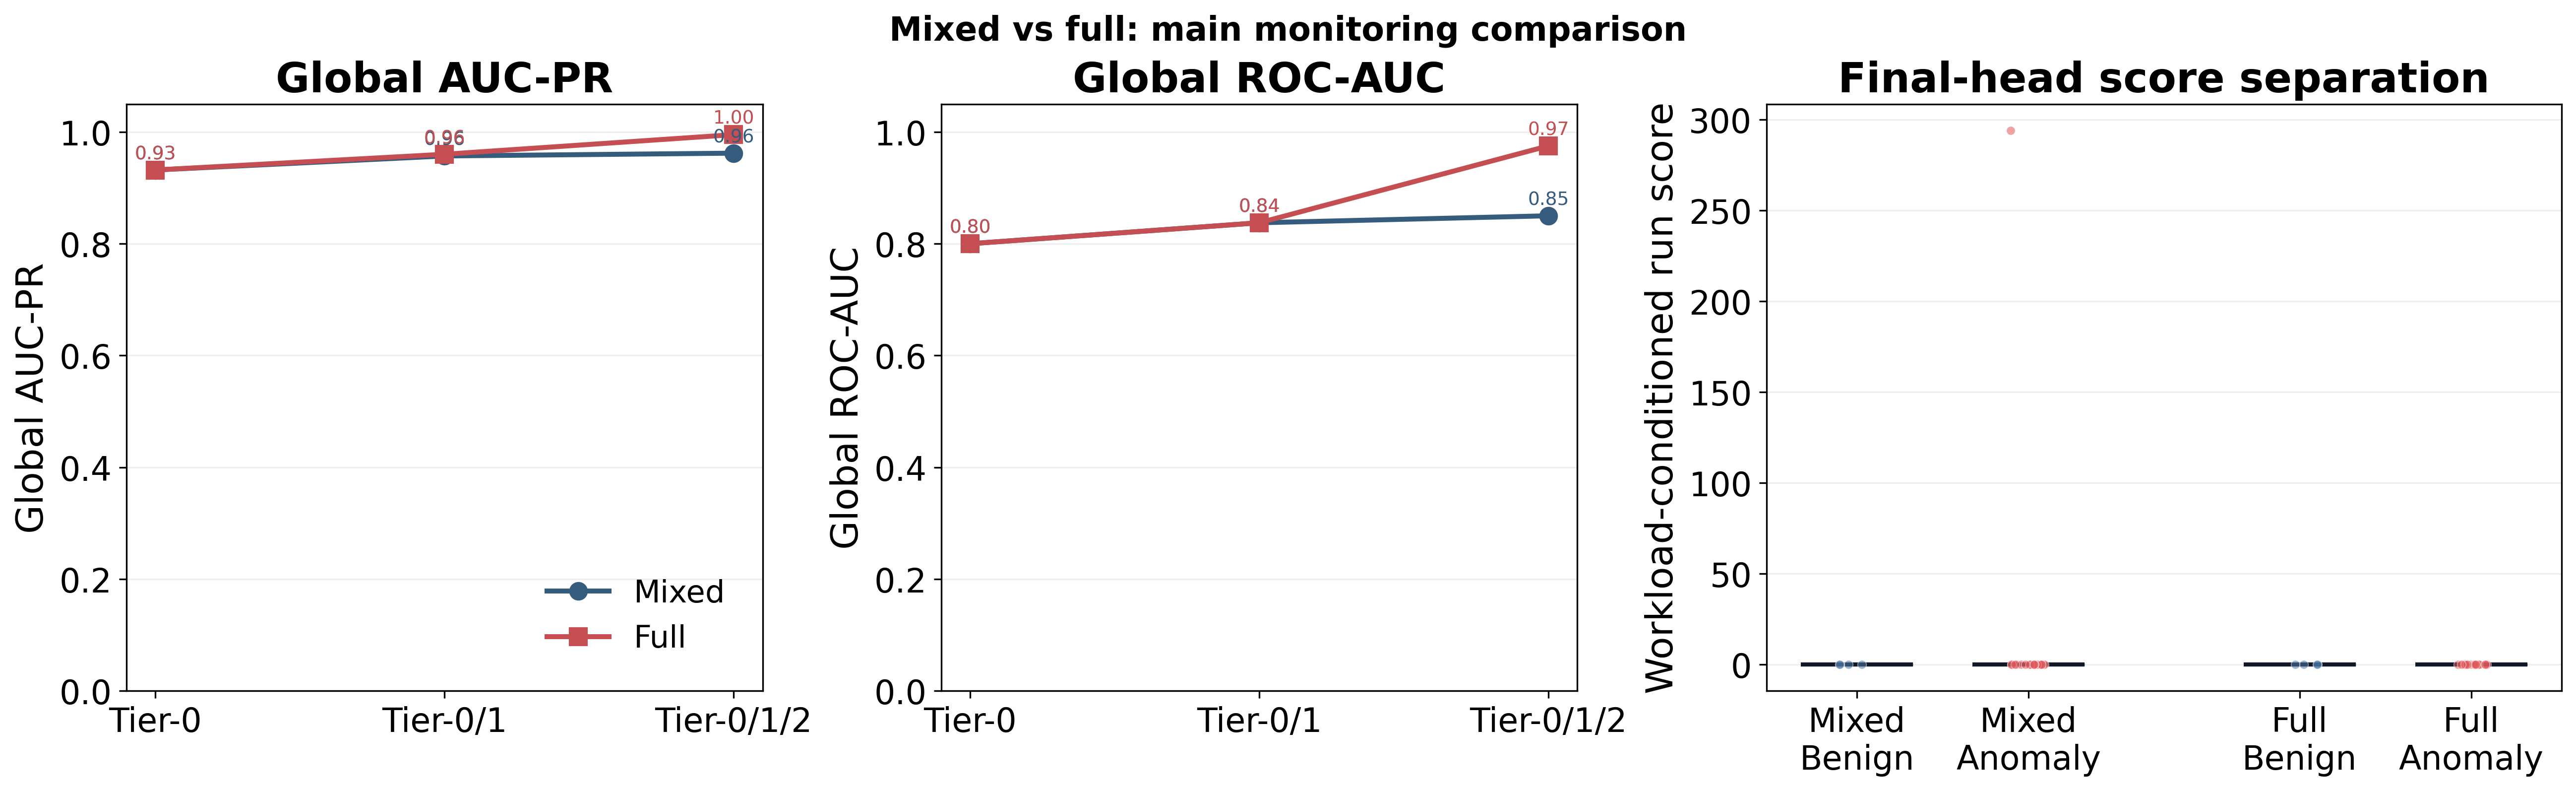

In [22]:
display(Markdown('### Monitoring comparison figures'))

main_monitoring_csv = COMPARISON_DIR / 'main_monitoring_profile_summary.csv'
score_dist_csv = COMPARISON_DIR / 'final_head_score_distribution_profiles.csv'
main_monitoring_png = COMPARISON_FIG / 'fig_main_monitoring_profile_comparison.png'

if not main_monitoring_csv.exists():
    display(Markdown('Run the previous monitoring-summary cell first so the comparison CSVs exist.'))
else:
    monitoring = pd.read_csv(main_monitoring_csv)
    monitoring['config_label'] = monitoring['config'].map(CFG_LABEL).fillna(monitoring['config'])
    monitoring['config'] = pd.Categorical(monitoring['config'], categories=CONFIG_ORDER, ordered=True)
    monitoring = monitoring.sort_values(['feature_profile', 'config']).reset_index(drop=True)
    profiles = [p for p in PROFILE_ORDER if p in set(monitoring['feature_profile'])]

    score_df = pd.read_csv(score_dist_csv) if score_dist_csv.exists() else pd.DataFrame()

    fig, axes = plt.subplots(1, 3, figsize=(17.2, 5.2), constrained_layout=True, gridspec_kw={'width_ratios': [1.0, 1.0, 1.25]})

    for ax, metric, title in zip(axes[:2], ['pr_auc', 'roc_auc'], ['Global AUC-PR', 'Global ROC-AUC']):
        for profile in profiles:
            d = monitoring[monitoring['feature_profile'] == profile].copy().sort_values('config')
            x = np.arange(len(d))
            ax.plot(
                x,
                d[metric].to_numpy(dtype=float),
                marker=PROFILE_MARKER[profile],
                markersize=8,
                linewidth=2.4,
                color=PROFILE_COLOR[profile],
                label=PROFILE_LABEL[profile],
            )
            for xi, yi in zip(x, d[metric].to_numpy(dtype=float)):
                ax.text(xi, yi + 0.02, f'{yi:.2f}', ha='center', fontsize=9, color=PROFILE_COLOR[profile])
        ax.set_xticks(np.arange(len(CONFIG_ORDER)))
        ax.set_xticklabels([CFG_LABEL[cfg] for cfg in CONFIG_ORDER])
        ax.set_ylim(0.0, 1.05)
        ax.set_ylabel(title)
        ax.set_title(title, fontweight='bold')
        ax.grid(axis='y', alpha=0.20)
    axes[0].legend(frameon=False, loc='lower right')

    if score_df.empty:
        axes[2].text(0.5, 0.5, 'No final-head score table found yet.', ha='center', va='center', fontsize=12)
        axes[2].set_axis_off()
    else:
        box_data = []
        positions = []
        labels = []
        box_colors = []
        pos = 0.0
        for profile in profiles:
            for label_name, color in [('Benign', '#4E79A7'), ('Anomaly', '#E15759')]:
                vals = score_df[
                    (score_df['feature_profile'] == profile) & (score_df['label_name'] == label_name)
                ]['run_score_wc'].dropna().to_numpy(dtype=float)
                if len(vals) == 0:
                    continue
                box_data.append(vals)
                positions.append(pos)
                labels.append(f"{PROFILE_LABEL[profile]}\n{label_name}")
                box_colors.append(color)
                pos += 0.95
            pos += 0.55

        bp = axes[2].boxplot(
            box_data,
            positions=positions,
            widths=0.62,
            patch_artist=True,
            showfliers=False,
            medianprops={'color': '#111827', 'linewidth': 2.0},
        )
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.65)
            patch.set_edgecolor('#1F2937')
            patch.set_linewidth(1.2)

        rng = np.random.default_rng(0)
        for xpos, vals, color in zip(positions, box_data, box_colors):
            jitter = rng.uniform(-0.10, 0.10, size=len(vals))
            axes[2].scatter(
                np.full(len(vals), xpos) + jitter,
                vals,
                s=18,
                alpha=0.55,
                color=color,
                edgecolor='white',
                linewidth=0.35,
                zorder=3,
            )

        axes[2].set_xticks(positions)
        axes[2].set_xticklabels(labels)
        axes[2].set_ylabel('Workload-conditioned run score')
        axes[2].set_title('Final-head score separation', fontweight='bold')
        axes[2].grid(axis='y', alpha=0.20)

    fig.suptitle('Mixed vs full: main monitoring comparison', fontsize=16, fontweight='bold')
    fig.savefig(main_monitoring_png, dpi=PRO_FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(main_monitoring_png)))


## 3. Reliability Without Per-Workload Tuning

This section asks a simple question: can one shared alert rule work across different workloads without hand-tuning the detector for each application?

One term difference matters here:
- **Block level** means short time windows inside a run.
- **Run level** means the whole experiment from start to finish.

A method can have a low false-alarm rate at the block level but still raise more run-level alerts, because a long run contains many blocks and the alerts are combined over time.


In [23]:
display(Markdown('### Reliability summary tables'))

ready_profiles, missing_profiles = available_profiles(required_global=['case_predictions.csv'])
reliability_csv = COMPARISON_DIR / 'conformal_reliability_profiles.csv'
reliability_workload_csv = COMPARISON_DIR / 'conformal_reliability_by_workload_profiles.csv'

if not ready_profiles:
    display(Markdown('No case-level prediction bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    reliability_rows = []
    workload_rows = []
    for profile in ready_profiles:
        case_pred = read_profile_csv(profile, 'global', 'case_predictions.csv')
        target_alpha = float(profile_operating_point(profile).get('alpha', 0.05))

        profile_rows = []
        for cfg, block in case_pred.groupby('config', sort=False):
            benign = block[block['label'] == 0].copy()
            anomaly = block[block['label'] == 1].copy()
            profile_rows.append(
                {
                    'feature_profile': profile,
                    'config': cfg,
                    'target_alpha': target_alpha,
                    'benign_block_false_alarm_rate': benign['n_block_alerts'].sum() / benign['n_blocks'].sum(),
                    'benign_persist_false_alarm_rate': benign['n_persist_alerts'].sum() / benign['n_blocks'].sum(),
                    'benign_run_false_alarm_rate': benign['run_alert'].mean(),
                    'benign_run_keep_rate': 1.0 - benign['run_alert'].mean(),
                    'anomaly_run_detection_rate': anomaly['run_alert'].mean(),
                    'median_anomaly_time_to_detect_s': anomaly.loc[anomaly['run_alert'] == 1, 'time_to_detect_s'].median(),
                }
            )

        profile_rel = add_profile_and_config_labels(pd.DataFrame(profile_rows))
        profile_rel = sort_profile_config(profile_rel)
        profile_rel.to_csv(profile_paper_dir(profile) / 'conformal_reliability_summary.csv', index=False)
        reliability_rows.append(profile_rel)

        by_workload = (
            case_pred[case_pred['label'] == 0]
            .groupby(['config', 'workload'], sort=False)
            .apply(
                lambda x: pd.Series(
                    {
                        'target_alpha': target_alpha,
                        'benign_block_false_alarm_rate': x['n_block_alerts'].sum() / x['n_blocks'].sum(),
                        'benign_persist_false_alarm_rate': x['n_persist_alerts'].sum() / x['n_blocks'].sum(),
                        'benign_run_false_alarm_rate': x['run_alert'].mean(),
                        'benign_run_keep_rate': 1.0 - x['run_alert'].mean(),
                    }
                ),
                include_groups=False,
            )
            .reset_index()
        )
        by_workload['feature_profile'] = profile
        by_workload = add_profile_and_config_labels(by_workload)
        by_workload = sort_profile_config(by_workload)
        by_workload.to_csv(profile_appendix_dir(profile) / 'conformal_reliability_by_workload.csv', index=False)
        workload_rows.append(by_workload)

    reliability_summary = sort_profile_config(pd.concat(reliability_rows, ignore_index=True))
    reliability_by_workload = sort_profile_config(pd.concat(workload_rows, ignore_index=True))
    reliability_summary.to_csv(reliability_csv, index=False)
    reliability_by_workload.to_csv(reliability_workload_csv, index=False)

    display_cols = [
        'profile_label', 'config_label', 'target_alpha', 'benign_block_false_alarm_rate',
        'benign_persist_false_alarm_rate', 'benign_run_keep_rate', 'benign_run_false_alarm_rate',
        'anomaly_run_detection_rate', 'median_anomaly_time_to_detect_s'
    ]
    display(Markdown('#### Reliability by profile and head'))
    display(reliability_summary[display_cols].round(4))

    workload_cols = [
        'profile_label', 'config_label', 'workload', 'target_alpha',
        'benign_block_false_alarm_rate', 'benign_run_keep_rate', 'benign_run_false_alarm_rate'
    ]
    display(Markdown('#### Benign reliability by workload'))
    display(reliability_by_workload[workload_cols].round(4))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))


### Reliability summary tables

#### Reliability by profile and head

,profile_label,config_label,target_alpha,benign_block_false_alarm_rate,benign_persist_false_alarm_rate,benign_run_false_alarm_rate,anomaly_run_detection_rate,median_anomaly_time_to_detect_s
0,Mixed,Tier-0,0.1,0.0392,0.0392,0.25,0.45,30.0
1,Mixed,Tier-0/1,0.1,0.0389,0.0389,0.25,0.80,235.5
2,Mixed,Tier-0/1/2,0.1,0.0389,0.0389,0.25,0.90,76.0
3,Full,Tier-0,0.1,0.0392,0.0392,0.25,0.45,30.0
4,Full,Tier-0/1,0.1,0.0381,0.0381,0.25,0.80,30.0
5,Full,Tier-0/1/2,0.1,0.0379,0.0379,0.25,1.00,30.0


#### Benign reliability by workload

,profile_label,config_label,workload,target_alpha,benign_block_false_alarm_rate,benign_run_false_alarm_rate
0,Mixed,Tier-0,BROWSER,0.1,0.0000,0.0
1,Mixed,Tier-0,PY_AI,0.1,0.0000,0.0
2,Mixed,Tier-0,PY_STATS,0.1,0.0000,0.0
3,Mixed,Tier-0,VIDEO_SW,0.1,0.1567,1.0
4,Mixed,Tier-0/1,BROWSER,0.1,0.0000,0.0
5,Mixed,Tier-0/1,PY_AI,0.1,0.0000,0.0
6,Mixed,Tier-0/1,PY_STATS,0.1,0.0000,0.0
7,Mixed,Tier-0/1,VIDEO_SW,0.1,0.1557,1.0
8,Mixed,Tier-0/1/2,BROWSER,0.1,0.0000,0.0
9,Mixed,Tier-0/1/2,PY_AI,0.1,0.0000,0.0


### Reliability comparison figures


### Calibrated alerting figures

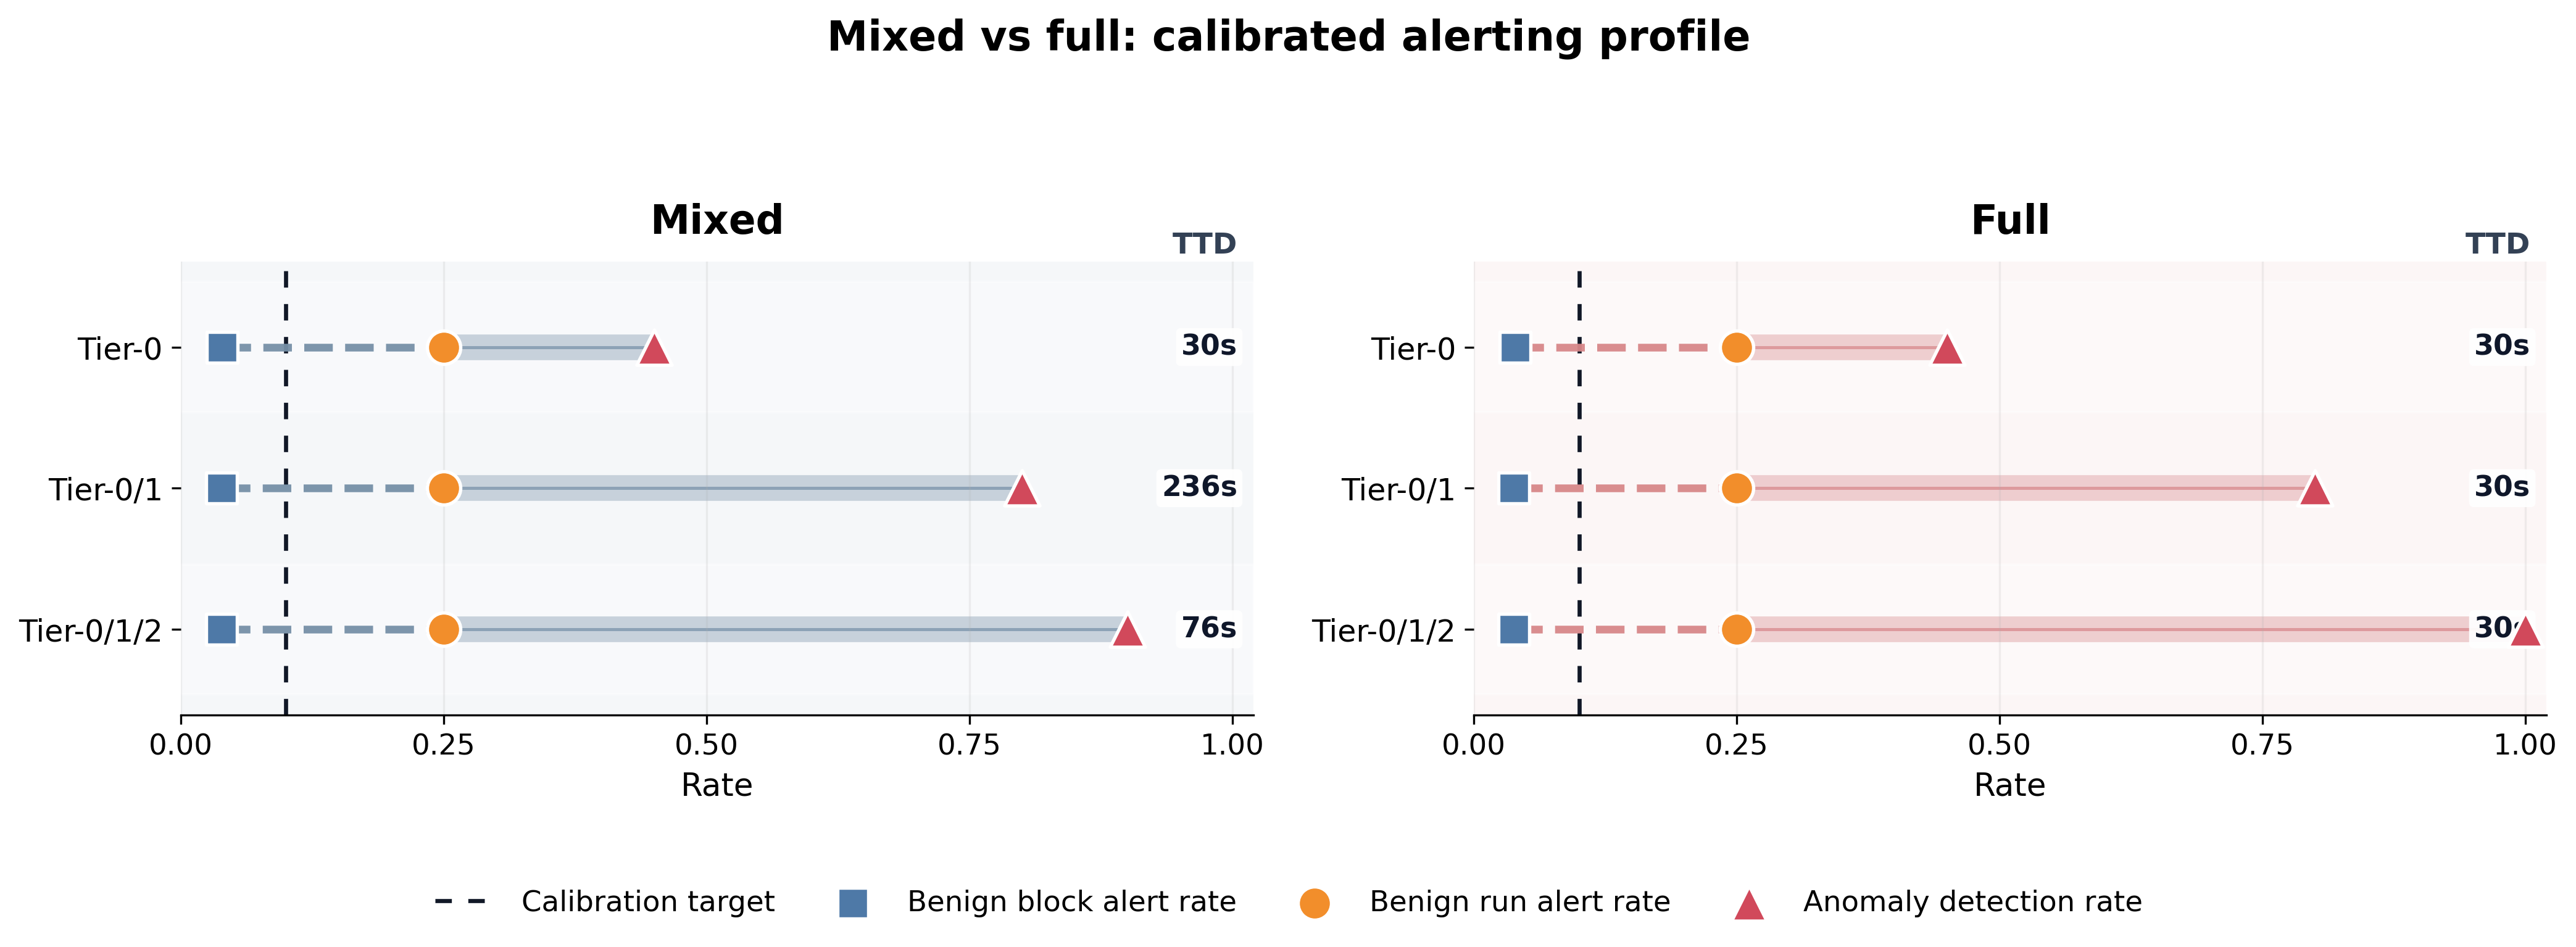

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.transforms import blended_transform_factory
from matplotlib.colors import to_rgb
from IPython.display import display, Markdown, Image

display(Markdown('### Calibrated alerting figures'))

reliability_csv = COMPARISON_DIR / 'conformal_reliability_profiles.csv'
reliability_png = COMPARISON_FIG / 'fig_conformal_reliability_profiles.png'

if not reliability_csv.exists():
    display(Markdown('Run the reliability-summary cell first so the comparison CSV exists.'))
else:
    rel = pd.read_csv(reliability_csv)
    rel = rel.sort_values(['feature_profile', 'config']).reset_index(drop=True)
    profiles = [p for p in PROFILE_ORDER if p in set(rel['feature_profile'])]

    if not profiles:
        display(Markdown('No calibrated alerting rows are available yet.'))
    else:
        def lighten_color(color, amount):
            rgb = np.array(to_rgb(color))
            white = np.ones(3)
            return tuple(rgb * (1.0 - amount) + white * amount)

        profile_colors = {
            'mixed': '#355C7D',
            'full': '#C44E52',
        }

        block_color = '#4E79A7'
        run_color = '#F28E2B'
        detect_color = '#D1495B'

        all_vals = []
        for col in [
            'benign_block_false_alarm_rate',
            'benign_run_false_alarm_rate',
            'anomaly_run_detection_rate',
            'target_alpha',
        ]:
            if col in rel.columns:
                vals = pd.to_numeric(rel[col], errors='coerce').to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                if len(vals):
                    all_vals.extend(vals.tolist())

        if all_vals:
            xmin = float(np.min(all_vals))
            xmax = float(np.max(all_vals))
            span = max(xmax - xmin, 0.15)
            pad = max(0.03, 0.12 * span)
            x_lo = max(0.0, xmin - pad)
            x_hi = min(1.02, xmax + pad)
            if x_hi - x_lo < 0.30:
                mid = 0.5 * (x_lo + x_hi)
                x_lo = max(0.0, mid - 0.15)
                x_hi = min(1.02, mid + 0.15)
        else:
            x_lo, x_hi = 0.0, 1.0

        fig, axes = plt.subplots(
            1,
            len(profiles),
            figsize=(7.4 * len(profiles), 5.2),
            squeeze=False,
            constrained_layout=False,
        )
        axes = axes[0]

        legend_handles = None

        for ax, profile in zip(axes, profiles):
            d = rel[rel['feature_profile'] == profile].copy().sort_values('config').reset_index(drop=True)
            y = np.arange(len(d), dtype=float)

            accent = profile_colors.get(profile, '#355C7D')
            panel_bg = lighten_color(accent, 0.95)
            corridor_fill = lighten_color(accent, 0.72)
            corridor_edge = lighten_color(accent, 0.42)
            bridge_color = lighten_color(accent, 0.32)

            ax.set_facecolor(panel_bg)

            for yi in y:
                if int(yi) % 2 == 0:
                    ax.axhspan(yi - 0.46, yi + 0.46, color='white', alpha=0.34, zorder=0)

            line = ax.axvline(
                float(d['target_alpha'].iloc[0]),
                color='#111827',
                linestyle=(0, (4, 4)),
                linewidth=1.6,
                label='Calibration target',
                zorder=1,
            )

            ax.hlines(
                y,
                d['benign_run_false_alarm_rate'],
                d['anomaly_run_detection_rate'],
                color=corridor_fill,
                linewidth=10,
                alpha=0.98,
                zorder=1.2,
            )
            ax.hlines(
                y,
                d['benign_run_false_alarm_rate'],
                d['anomaly_run_detection_rate'],
                color=corridor_edge,
                linewidth=1.2,
                alpha=0.95,
                zorder=1.4,
            )
            ax.hlines(
                y,
                d['benign_block_false_alarm_rate'],
                d['benign_run_false_alarm_rate'],
                color=bridge_color,
                linewidth=3.0,
                alpha=0.95,
                linestyle='--',
                zorder=1.5,
            )

            s1 = ax.scatter(
                d['benign_block_false_alarm_rate'],
                y,
                s=145,
                marker='s',
                color=block_color,
                edgecolor='white',
                linewidth=1.3,
                label='Benign block alert rate',
                zorder=3,
            )
            s2 = ax.scatter(
                d['benign_run_false_alarm_rate'],
                y,
                s=168,
                marker='o',
                color=run_color,
                edgecolor='white',
                linewidth=1.3,
                label='Benign run alert rate',
                zorder=4,
            )
            s3 = ax.scatter(
                d['anomaly_run_detection_rate'],
                y,
                s=188,
                marker='^',
                color=detect_color,
                edgecolor='white',
                linewidth=1.3,
                label='Anomaly detection rate',
                zorder=5,
            )

            trans = blended_transform_factory(ax.transAxes, ax.transData)
            ax.text(
                0.985,
                -0.72,
                'TTD',
                transform=trans,
                ha='right',
                va='center',
                fontsize=11.4,
                fontweight='bold',
                color='#334155',
            )

            for yi, row in enumerate(d.itertuples(index=False)):
                if pd.notna(row.median_anomaly_time_to_detect_s):
                    ax.text(
                        0.985,
                        yi,
                        f'{row.median_anomaly_time_to_detect_s:.0f}s',
                        transform=trans,
                        ha='right',
                        va='center',
                        fontsize=11.0,
                        fontweight='bold',
                        color='#0F172A',
                        bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.94),
                    )

            ax.set_yticks(y)
            ax.set_yticklabels(d['config_label'], fontsize=11.8)
            ax.invert_yaxis()
            ax.set_xlim(x_lo, x_hi)
            ax.set_xlabel('Rate', fontsize=12.4)
            ax.set_title(PROFILE_LABEL[profile], fontsize=15.5, fontweight='bold', pad=11)
            ax.grid(axis='x', alpha=0.18)
            ax.tick_params(axis='x', labelsize=11.2)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)

            legend_handles = [line, s1, s2, s3]

        fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=4,
            frameon=False,
            fontsize=11.2,
            handlelength=2.2,
            columnspacing=1.6,
        )

        fig.suptitle('Mixed vs full: calibrated alerting profile', fontsize=16, fontweight='bold')
        fig.tight_layout(rect=[0.02, 0.12, 0.98, 0.92])
        fig.savefig(reliability_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        display(Image(filename=str(reliability_png)))
        plt.close(fig)



## 4. Observability Heads and Digital-Twin Variants

This section compares three sensing setups: `Tier-0`, `Tier-0/1`, and `Tier-0/1/2`.

In plain terms, it shows what we gain when we give DICE more system signals to work with. It compares:
- the base score,
- the workload-conditioned score,
- and the diagnosis output.


In [26]:
display(Markdown('### Observability and diagnosis tables'))

ready_profiles, missing_profiles = available_profiles(required_global=['overall_metrics.csv', 'stressor_diagnosis_metrics.csv'])
variant_csv = COMPARISON_DIR / 'digital_twin_variant_summary_profiles.csv'

if not ready_profiles:
    display(Markdown('No observability-head result bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    variant_rows = []
    for profile in ready_profiles:
        overall = read_profile_csv(profile, 'global', 'overall_metrics.csv')
        diag = read_profile_csv(profile, 'global', 'stressor_diagnosis_metrics.csv')
        merged = (
            overall[['config', 'n_features', 'roc_auc', 'pr_auc', 'roc_auc_wc', 'pr_auc_wc']]
            .merge(diag[['config', 'top1_acc', 'top2_acc', 'macro_f1', 'mean_margin_to_second']], on='config', how='left')
        )
        merged['feature_profile'] = profile
        variant_rows.append(add_profile_and_config_labels(merged))

    variant_summary = sort_profile_config(pd.concat(variant_rows, ignore_index=True))
    variant_summary.to_csv(variant_csv, index=False)
    display(variant_summary[[
        'profile_label', 'config_label', 'n_features', 'roc_auc', 'pr_auc', 'roc_auc_wc', 'pr_auc_wc',
        'top1_acc', 'top2_acc', 'macro_f1', 'mean_margin_to_second'
    ]].round(4))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))


### Observability and diagnosis tables

,profile_label,config_label,n_features,roc_auc,pr_auc,roc_auc_wc,pr_auc_wc,top1_acc,top2_acc,macro_f1,mean_margin_to_second
0,Mixed,Tier-0,46,0.8000,0.9319,1.0,1.0,0.25,0.45,0.1891,0.0009
1,Mixed,Tier-0/1,57,0.8375,0.9570,1.0,1.0,0.25,0.50,0.2061,0.0000
2,Mixed,Tier-0/1/2,64,0.8500,0.9620,1.0,1.0,0.25,0.60,0.2260,0.0000
3,Full,Tier-0,46,0.8000,0.9319,1.0,1.0,0.25,0.45,0.1891,0.0009
4,Full,Tier-0/1,64,0.8375,0.9600,1.0,1.0,0.10,0.35,0.0800,0.0010
5,Full,Tier-0/1/2,75,0.9750,0.9951,1.0,1.0,0.05,0.25,0.0571,0.0002


### Observability comparison figures


### Observability comparison figures

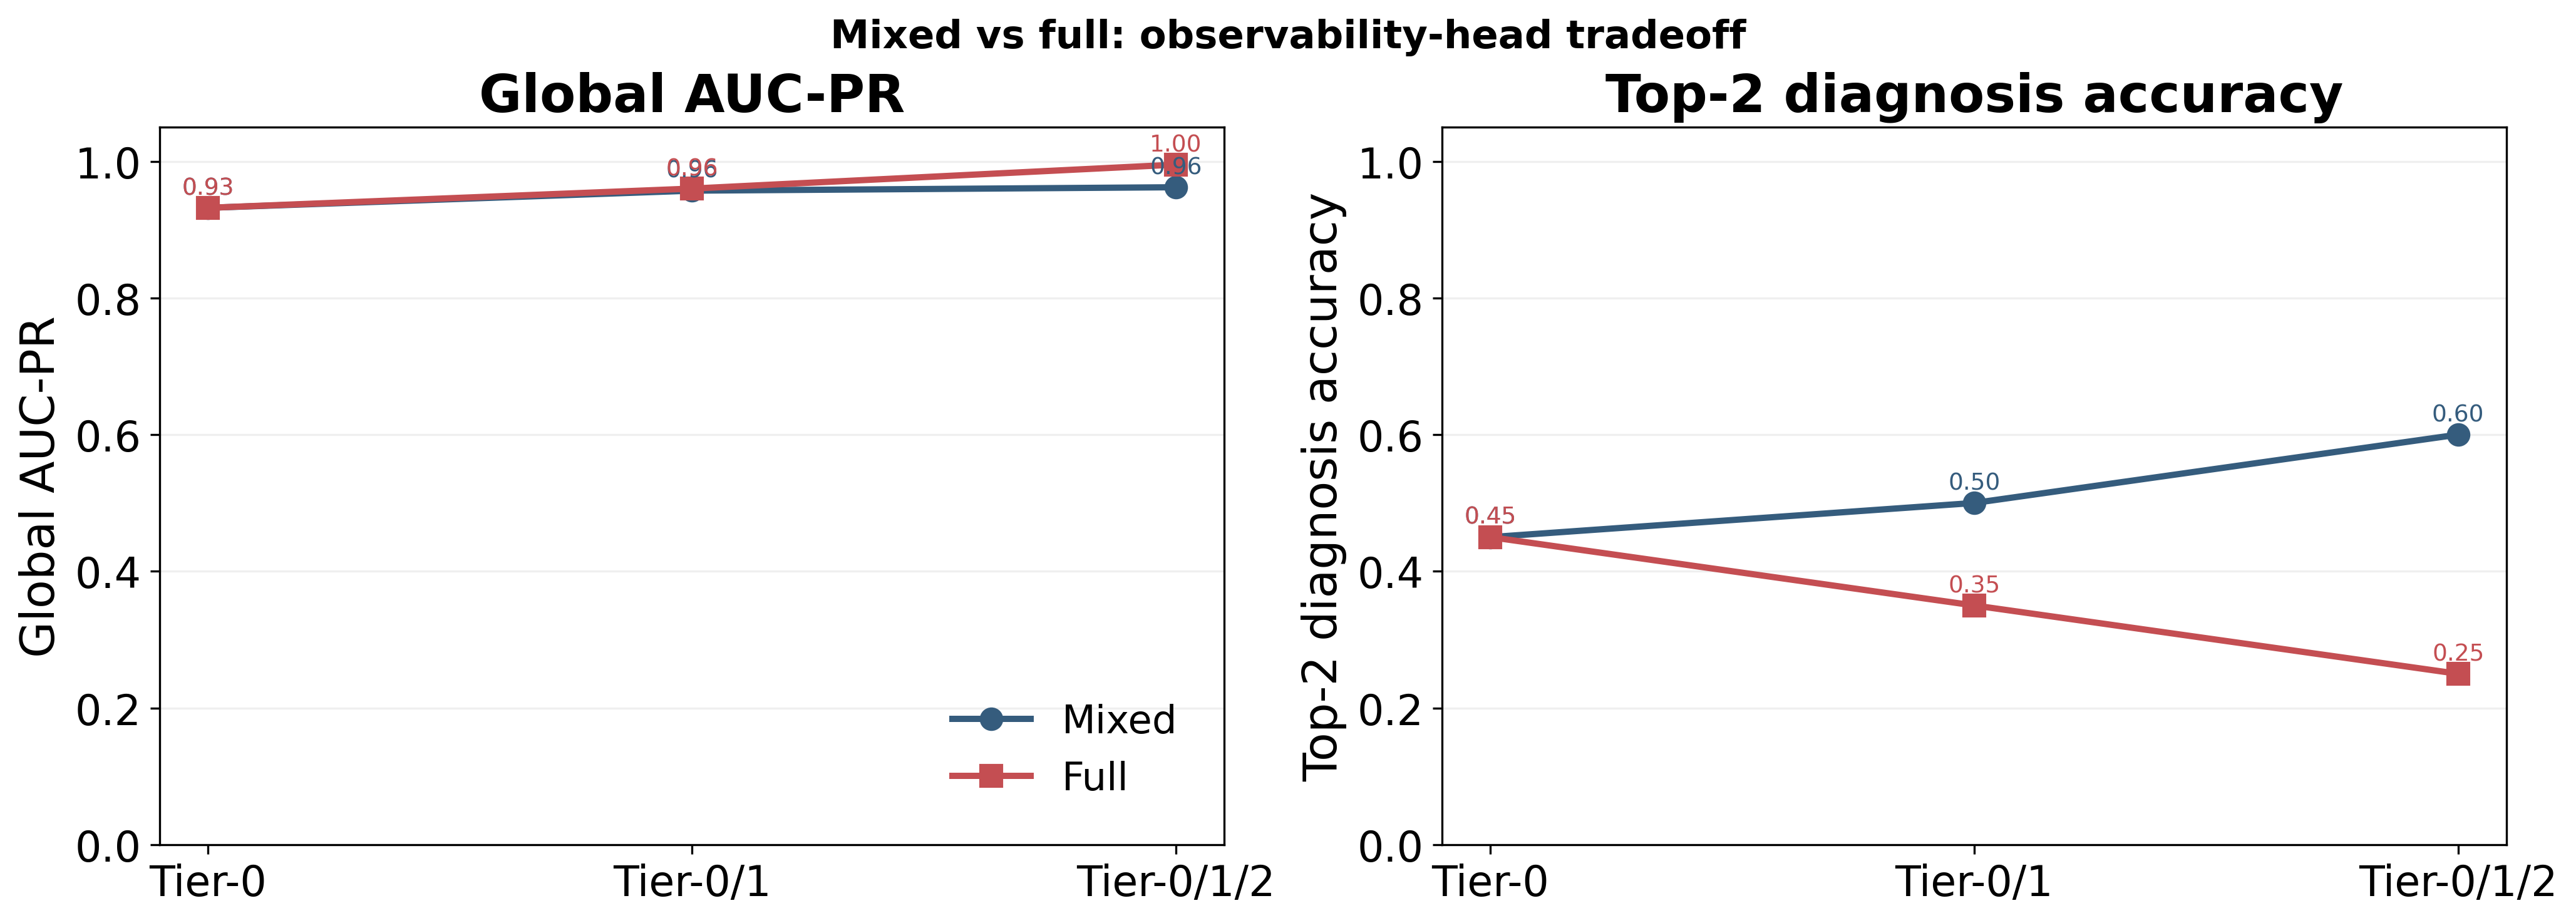

In [27]:
display(Markdown('### Observability comparison figures'))

variant_csv = COMPARISON_DIR / 'digital_twin_variant_summary_profiles.csv'
variant_png = COMPARISON_FIG / 'fig_observability_variant_profiles.png'

if not variant_csv.exists():
    display(Markdown('Run the observability-summary cell first so the comparison CSV exists.'))
else:
    variant = pd.read_csv(variant_csv)
    variant['config'] = pd.Categorical(variant['config'], categories=CONFIG_ORDER, ordered=True)
    variant = variant.sort_values(['feature_profile', 'config']).reset_index(drop=True)
    profiles = [p for p in PROFILE_ORDER if p in set(variant['feature_profile'])]

    fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8), constrained_layout=True)
    for ax, metric, title in zip(axes, ['pr_auc', 'top2_acc'], ['Global AUC-PR', 'Top-2 diagnosis accuracy']):
        for profile in profiles:
            d = variant[variant['feature_profile'] == profile].copy().sort_values('config')
            x = np.arange(len(d))
            ax.plot(
                x,
                d[metric].to_numpy(dtype=float),
                marker=PROFILE_MARKER[profile],
                markersize=8,
                linewidth=2.4,
                color=PROFILE_COLOR[profile],
                label=PROFILE_LABEL[profile],
            )
            for xi, yi in zip(x, d[metric].to_numpy(dtype=float)):
                ax.text(xi, yi + 0.02, f'{yi:.2f}', ha='center', fontsize=9, color=PROFILE_COLOR[profile])
        ax.set_xticks(np.arange(len(CONFIG_ORDER)))
        ax.set_xticklabels([CFG_LABEL[cfg] for cfg in CONFIG_ORDER])
        ax.set_ylim(0.0, 1.05)
        ax.set_ylabel(title)
        ax.set_title(title, fontweight='bold')
        ax.grid(axis='y', alpha=0.20)
    axes[0].legend(frameon=False, loc='lower right')
    fig.suptitle('Mixed vs full: observability-head tradeoff', fontsize=15, fontweight='bold')
    fig.savefig(variant_png, dpi=PRO_FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(variant_png)))


## 4B. Two-Stage DICE

This section tests a cheaper two-stage version of DICE.

- Stage 1 uses `Tier-0` as a lightweight screen that can run all the time.
- Stage 2 uses `Tier-0/1/2` as a richer follow-up step that runs only when Stage 1 looks suspicious.

The goal is to see how much detection quality we can keep while lowering the average number of active features.


In [28]:
display(Markdown('### Two-stage comparison tables'))

ready_profiles, missing_profiles = available_profiles(required_global=['case_predictions.csv'])
two_stage_csv = COMPARISON_DIR / 'two_stage_dice_profiles.csv'

if not ready_profiles:
    display(Markdown('No case-level prediction bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    summary_rows = []
    for profile in ready_profiles:
        profile_csv = profile_paper_dir(profile) / 'two_stage_dice_summary.csv'
        if profile_csv.exists():
            profile_summary = pd.read_csv(profile_csv)
        else:
            case_pred = read_profile_csv(profile, 'global', 'case_predictions.csv').copy()
            stage1 = (
                case_pred[case_pred['config'] == 'tier0'][
                    ['case_id', 'workload', 'stressor', 'label', 'run_alert', 'run_score_wc', 'n_features', 'time_to_detect_s']
                ]
                .rename(columns={
                    'run_alert': 'stage1_alert',
                    'run_score_wc': 'stage1_score_wc',
                    'n_features': 'stage1_features',
                    'time_to_detect_s': 'stage1_ttd_s',
                })
            )
            stage2 = (
                case_pred[case_pred['config'] == FINAL_CONFIG][
                    ['case_id', 'workload', 'stressor', 'label', 'run_alert', 'run_score_wc', 'n_features', 'time_to_detect_s']
                ]
                .rename(columns={
                    'run_alert': 'stage2_alert',
                    'run_score_wc': 'stage2_score_wc',
                    'n_features': 'stage2_features',
                    'time_to_detect_s': 'stage2_ttd_s',
                })
            )
            df = stage1.merge(stage2, on=['case_id', 'workload', 'stressor', 'label'], how='inner')
            if df.empty:
                continue
            y = df['label'].to_numpy(dtype=int)
            benign_mask = y == 0
            anomaly_mask = y == 1
            stage1_features = int(df['stage1_features'].iloc[0])
            stage2_features = int(df['stage2_features'].iloc[0])

            def safe_pr_auc(y_true, score):
                return float(average_precision_score(y_true, score)) if len(np.unique(y_true)) >= 2 else np.nan

            def safe_roc_auc(y_true, score):
                return float(roc_auc_score(y_true, score)) if len(np.unique(y_true)) >= 2 else np.nan

            def safe_median_ttd(ttd_values, final_alert):
                vals = pd.Series(ttd_values)[(final_alert == 1) & anomaly_mask].dropna()
                return float(vals.median()) if len(vals) else np.nan

            rows = []
            final_alert = df['stage1_alert'].to_numpy(dtype=int)
            final_score = df['stage1_score_wc'].to_numpy(dtype=float)
            rows.append({
                'policy': 'Tier-0 only',
                'trigger_quantile': np.nan,
                'trigger_rate_all': 0.0,
                'trigger_rate_benign': 0.0,
                'trigger_rate_anomaly': 0.0,
                'avg_feature_budget': float(stage1_features),
                'auc_pr': safe_pr_auc(y, final_score),
                'roc_auc': safe_roc_auc(y, final_score),
                'benign_alert_rate': float(final_alert[benign_mask].mean()),
                'detection_rate': float(final_alert[anomaly_mask].mean()),
                'median_ttd_s': safe_median_ttd(df['stage1_ttd_s'], final_alert),
            })

            benign_scores = df.loc[benign_mask, 'stage1_score_wc']
            for q in [0.90, 0.95, 0.98]:
                gate = float(benign_scores.quantile(q))
                trigger = (df['stage1_score_wc'] >= gate).to_numpy(dtype=bool)
                final_alert = np.where(trigger, df['stage2_alert'], df['stage1_alert']).astype(int)
                final_score = np.where(trigger, df['stage2_score_wc'], df['stage1_score_wc']).astype(float)
                final_ttd = np.where(trigger, df['stage2_ttd_s'], df['stage1_ttd_s'])
                rows.append({
                    'policy': f'Two-stage q={q:.2f}',
                    'trigger_quantile': q,
                    'trigger_rate_all': float(trigger.mean()),
                    'trigger_rate_benign': float(trigger[benign_mask].mean()),
                    'trigger_rate_anomaly': float(trigger[anomaly_mask].mean()),
                    'avg_feature_budget': float(stage1_features + trigger.mean() * (stage2_features - stage1_features)),
                    'auc_pr': safe_pr_auc(y, final_score),
                    'roc_auc': safe_roc_auc(y, final_score),
                    'benign_alert_rate': float(final_alert[benign_mask].mean()),
                    'detection_rate': float(final_alert[anomaly_mask].mean()),
                    'median_ttd_s': safe_median_ttd(final_ttd, final_alert),
                })

            final_alert = df['stage2_alert'].to_numpy(dtype=int)
            final_score = df['stage2_score_wc'].to_numpy(dtype=float)
            rows.append({
                'policy': 'Always Tier-0/1/2',
                'trigger_quantile': 0.0,
                'trigger_rate_all': 1.0,
                'trigger_rate_benign': 1.0,
                'trigger_rate_anomaly': 1.0,
                'avg_feature_budget': float(stage2_features),
                'auc_pr': safe_pr_auc(y, final_score),
                'roc_auc': safe_roc_auc(y, final_score),
                'benign_alert_rate': float(final_alert[benign_mask].mean()),
                'detection_rate': float(final_alert[anomaly_mask].mean()),
                'median_ttd_s': safe_median_ttd(df['stage2_ttd_s'], final_alert),
            })
            profile_summary = pd.DataFrame(rows)
            profile_summary.to_csv(profile_csv, index=False)

        profile_summary['feature_profile'] = profile
        profile_summary['profile_label'] = PROFILE_LABEL[profile]
        summary_rows.append(profile_summary)

    if not summary_rows:
        display(Markdown('Two-stage comparison is not available yet.'))
    else:
        two_stage_summary = pd.concat(summary_rows, ignore_index=True)
        two_stage_summary.to_csv(two_stage_csv, index=False)
        display(two_stage_summary.round(4))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))


### Two-stage comparison tables

,policy,trigger_quantile,trigger_rate_all,trigger_rate_benign,trigger_rate_anomaly,avg_feature_budget,auc_pr,roc_auc,benign_alert_rate,detection_rate,median_ttd_s,feature_profile,profile_label
0,Tier-0 only,NaN,0.0,0.0,0.0,46.0,1.0,1.0,0.25,0.30,74.5,mixed,Mixed
1,Two-stage q=0.90,0.90,1.0,1.0,1.0,64.0,1.0,1.0,0.25,0.45,62.0,mixed,Mixed
2,Two-stage q=0.95,0.95,1.0,1.0,1.0,64.0,1.0,1.0,0.25,0.45,62.0,mixed,Mixed
3,Two-stage q=0.98,0.98,1.0,1.0,1.0,64.0,1.0,1.0,0.25,0.45,62.0,mixed,Mixed
4,Always Tier-0/1/2,0.00,1.0,1.0,1.0,64.0,1.0,1.0,0.25,0.45,62.0,mixed,Mixed
5,Tier-0 only,NaN,0.0,0.0,0.0,46.0,1.0,1.0,0.25,0.45,30.0,full,Full
6,Two-stage q=0.90,0.90,1.0,1.0,1.0,75.0,1.0,1.0,0.25,1.00,30.0,full,Full
7,Two-stage q=0.95,0.95,1.0,1.0,1.0,75.0,1.0,1.0,0.25,1.00,30.0,full,Full
8,Two-stage q=0.98,0.98,1.0,1.0,1.0,75.0,1.0,1.0,0.25,1.00,30.0,full,Full
9,Always Tier-0/1/2,0.00,1.0,1.0,1.0,75.0,1.0,1.0,0.25,1.00,30.0,full,Full


### Two-stage comparison figures


### Two-stage comparison figures

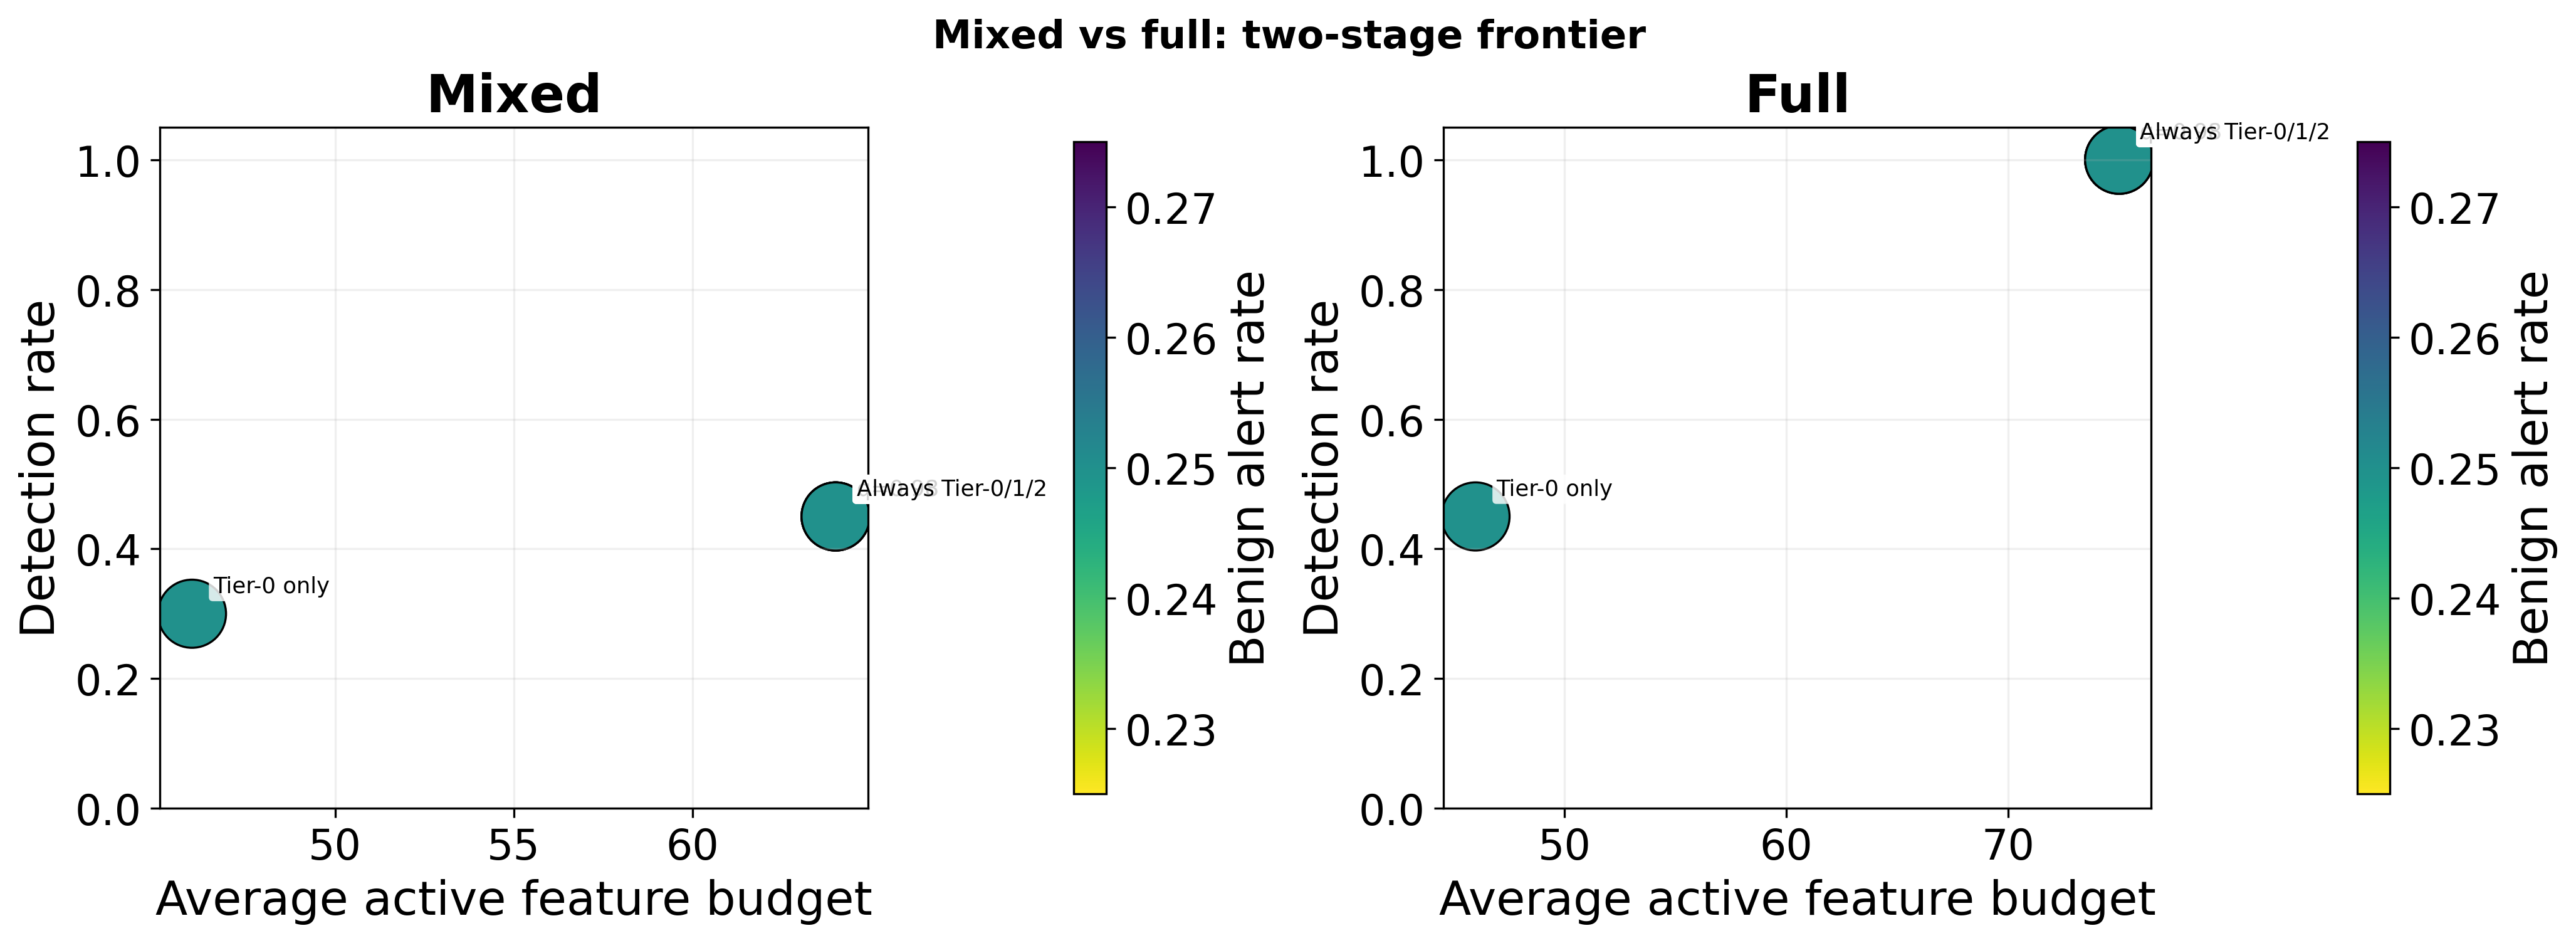

In [62]:
display(Markdown('### Two-stage comparison figures'))

two_stage_csv = COMPARISON_DIR / 'two_stage_dice_profiles.csv'
two_stage_png = COMPARISON_FIG / 'fig_two_stage_profile_comparison.png'

if not two_stage_csv.exists():
    display(Markdown('Run the two-stage summary cell first so the comparison CSV exists.'))
else:
    summary = pd.read_csv(two_stage_csv)
    profiles = [p for p in PROFILE_ORDER if p in set(summary['feature_profile'])]
    fig, axes = plt.subplots(1, max(1, len(profiles)), figsize=(6.8 * max(1, len(profiles)), 4.9), squeeze=False, constrained_layout=True)
    axes = axes[0]

    for ax, profile in zip(axes, profiles):
        d = summary[summary['feature_profile'] == profile].copy()
        sc = ax.scatter(
            d['avg_feature_budget'],
            d['detection_rate'],
            s=260 + 420 * d['auc_pr'].fillna(0.0),
            c=d['benign_alert_rate'],
            cmap='viridis_r',
            edgecolor='black',
            linewidth=0.8,
        )
        for row in d.itertuples(index=False):
            ax.annotate(
                str(row.policy).replace('Two-stage ', ''),
                xy=(float(row.avg_feature_budget), float(row.detection_rate)),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.82),
            )
        ax.set_xlabel('Average active feature budget')
        ax.set_ylabel('Detection rate')
        ax.set_ylim(0.0, 1.05)
        ax.set_title(PROFILE_LABEL[profile], fontweight='bold')
        ax.grid(alpha=0.20)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Benign alert rate')

    fig.suptitle('Mixed vs full: two-stage frontier', fontsize=15, fontweight='bold')
    fig.savefig(two_stage_png, dpi=PRO_FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(two_stage_png)))


## 5. Workload-Holdout Robustness and Drift Proxy

This section checks what happens when the detector is tested on a workload it did not see during training.

That is a simple stand-in for real-world change, such as new software behavior, usage drift, or a different workload mix after deployment.


In [66]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

display(Markdown('### Workload-transfer comparison tables'))

transfer_csv = COMPARISON_DIR / 'holdout_robustness_profiles.csv'


def resolve_profile_availability(required_holdout=(), required_global=(), required_paper=(), required_appendix=()):
    ready = []
    missing = {}
    for profile in PROFILE_ORDER:
        miss = profile_requirements(
            profile,
            required_global=required_global,
            required_holdout=required_holdout,
            required_paper=required_paper,
            required_appendix=required_appendix,
        )
        if miss:
            missing[profile] = miss
        else:
            ready.append(profile)
    return ready, missing


def select_transfer_columns(df):
    out = df.copy()

    aliases = {
        'pooled_pr_auc': ['pooled_holdout_pr_auc'],
        'pooled_roc_auc': ['pooled_holdout_roc_auc'],
        'mean_pr_auc': ['holdout_mean_pr_auc'],
        'worst_pr_auc': ['holdout_worst_pr_auc'],
        'mean_roc_auc': ['holdout_mean_roc_auc'],
        'mean_fpr': ['holdout_mean_fpr'],
        'mean_tpr': ['holdout_mean_tpr'],
    }

    for target, candidates in aliases.items():
        if target not in out.columns:
            for alt in candidates:
                if alt in out.columns:
                    out[target] = out[alt]
                    break

    required = [
        'config',
        'mean_pr_auc',
        'worst_pr_auc',
        'mean_roc_auc',
        'pooled_pr_auc',
        'pooled_roc_auc',
        'mean_fpr',
        'mean_tpr',
    ]
    for col in required:
        if col not in out.columns:
            out[col] = np.nan

    return out[required].copy()


ready_profile_list, missing_profiles = resolve_profile_availability(
    required_holdout=['holdout_robustness_summary.csv']
)

if not ready_profile_list:
    display(Markdown('No workload-transfer bundles are ready yet. Run **Run End-to-End** with workload-transfer evaluation enabled.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    transfer_rows = []
    notes = []

    for profile in ready_profile_list:
        raw_transfer = read_profile_csv(profile, 'holdout', 'holdout_robustness_summary.csv').copy()
        transfer = select_transfer_columns(raw_transfer)
        transfer['feature_profile'] = profile
        transfer_rows.append(add_profile_and_config_labels(transfer))

        pooled_missing = not (
            'pooled_pr_auc' in raw_transfer.columns or
            'pooled_holdout_pr_auc' in raw_transfer.columns
        )
        if pooled_missing:
            notes.append(
                f'- `{PROFILE_LABEL.get(profile, profile)}` workload-transfer summary does not include pooled metrics; those columns are omitted from the display table.'
            )

    transfer_summary = sort_profile_config(pd.concat(transfer_rows, ignore_index=True))
    transfer_summary.to_csv(transfer_csv, index=False)

    pooled_available = (
        transfer_summary[['pooled_pr_auc', 'pooled_roc_auc']].notna().any().any()
        if {'pooled_pr_auc', 'pooled_roc_auc'}.issubset(transfer_summary.columns)
        else False
    )

    display_cols = [
        'profile_label',
        'config_label',
        'mean_pr_auc',
        'worst_pr_auc',
        'mean_roc_auc',
        'mean_fpr',
        'mean_tpr',
    ]
    if pooled_available:
        display_cols[5:5] = ['pooled_pr_auc', 'pooled_roc_auc']

    display(transfer_summary[display_cols].round(4))

    if notes and not pooled_available:
        display(Markdown('**Notes**\n' + '\n'.join(sorted(set(notes)))))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))



### Workload-transfer comparison tables

,profile_label,config_label,mean_pr_auc,worst_pr_auc,mean_roc_auc,mean_fpr,mean_tpr
0,Mixed,Tier-0,0.8242,0.71,0.35,0.1667,0.7500
1,Mixed,Tier-0/1,0.8617,0.71,0.45,0.1667,0.7500
2,Mixed,Tier-0/1/2,0.8867,0.81,0.50,0.1667,0.7500
3,Full,Tier-0,0.8242,0.71,0.35,0.1667,0.7500
4,Full,Tier-0/1,0.8075,0.71,0.30,0.1667,0.7917
5,Full,Tier-0/1/2,0.8325,0.71,0.35,0.1667,0.8333


**Notes**
- `Full` workload-transfer summary does not include pooled metrics; those columns are omitted from the display table.
- `Mixed` workload-transfer summary does not include pooled metrics; those columns are omitted from the display table.

### Holdout comparison figures


### Workload-transfer comparison figures

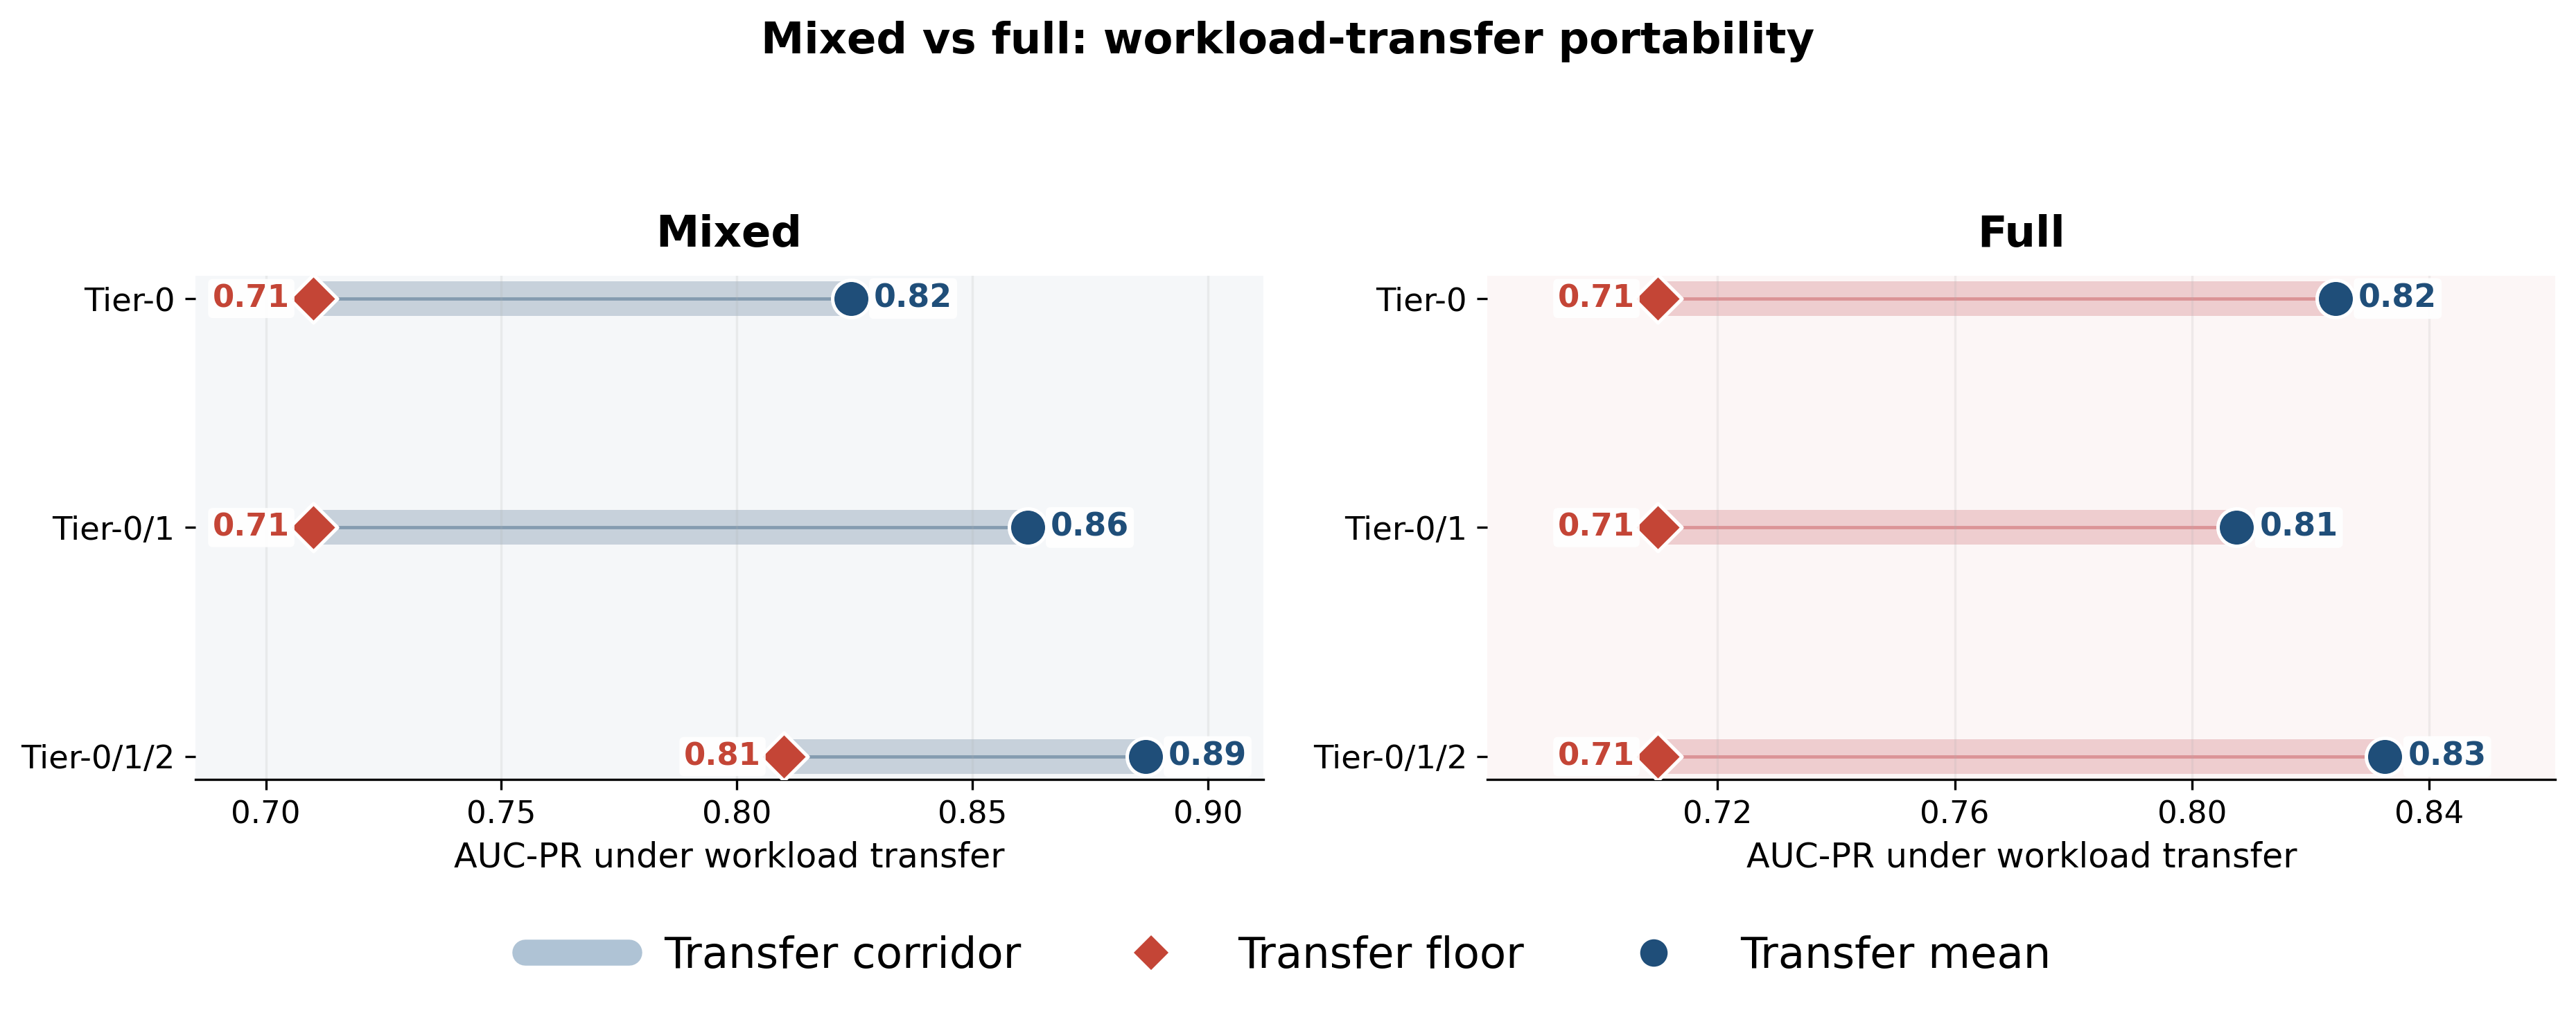

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.colors import to_rgb
from IPython.display import display, Markdown, Image

display(Markdown('### Workload-transfer comparison figures'))

transfer_csv = COMPARISON_DIR / 'holdout_robustness_profiles.csv'
transfer_png = COMPARISON_FIG / 'fig_workload_transfer_profile_comparison.png'

if not transfer_csv.exists():
    display(Markdown('Run the workload-transfer summary cell first so the comparison CSV exists.'))
else:
    transfer = pd.read_csv(transfer_csv)
    profiles = [p for p in PROFILE_ORDER if p in set(transfer['feature_profile'])]

    if not profiles:
        display(Markdown('No workload-transfer comparison rows are available yet.'))
    else:
        profile_colors = {
            'mixed': '#355C7D',
            'full': '#C44E52',
        }
        floor_color = '#C44536'
        mean_color = '#1F4E79'

        def lighten_color(color, amount):
            rgb = np.array(to_rgb(color))
            white = np.ones(3)
            return tuple(rgb * (1.0 - amount) + white * amount)

        fig, axes = plt.subplots(
            1,
            len(profiles),
            figsize=(6.6 * len(profiles), 5.0),
            squeeze=False,
            constrained_layout=False,
        )
        axes = axes[0]

        for ax, profile in zip(axes, profiles):
            d = transfer[transfer['feature_profile'] == profile].copy().sort_values('config')
            d = d.reset_index(drop=True)
            y = np.arange(len(d), dtype=float)

            accent = profile_colors.get(profile, '#355C7D')
            corridor_fill = lighten_color(accent, 0.72)
            corridor_edge = lighten_color(accent, 0.38)
            panel_bg = lighten_color(accent, 0.95)

            ax.set_facecolor(panel_bg)

            lower_vals = []
            upper_vals = []

            for yi, row in enumerate(d.itertuples(index=False)):
                x_floor = float(row.worst_pr_auc)
                x_mean = float(row.mean_pr_auc)
                if not np.isfinite(x_floor) or not np.isfinite(x_mean):
                    continue

                x_lo, x_hi = sorted([x_floor, x_mean])

                ax.plot(
                    [x_lo, x_hi],
                    [yi, yi],
                    color=corridor_fill,
                    linewidth=12,
                    solid_capstyle='round',
                    zorder=1,
                    alpha=0.98,
                )
                ax.plot(
                    [x_lo, x_hi],
                    [yi, yi],
                    color=corridor_edge,
                    linewidth=1.15,
                    solid_capstyle='round',
                    zorder=1.5,
                    alpha=0.95,
                )

                lower_vals.append(x_lo)
                upper_vals.append(x_hi)

            ax.scatter(
                d['worst_pr_auc'],
                y,
                s=138,
                marker='D',
                color=floor_color,
                edgecolor='white',
                linewidth=1.2,
                zorder=3,
            )
            ax.scatter(
                d['mean_pr_auc'],
                y,
                s=168,
                marker='o',
                color=mean_color,
                edgecolor='white',
                linewidth=1.2,
                zorder=4,
            )

            for yi, row in enumerate(d.itertuples(index=False)):
                x_floor = float(row.worst_pr_auc)
                x_mean = float(row.mean_pr_auc)
                if not np.isfinite(x_floor) or not np.isfinite(x_mean):
                    continue

                gap = abs(x_mean - x_floor)

                if gap < 0.065:
                    floor_offset = (-8, -13)
                    floor_ha = 'right'
                    floor_va = 'top'
                    mean_offset = (8, 13)
                    mean_ha = 'left'
                    mean_va = 'bottom'
                else:
                    floor_offset = (-8, 0)
                    floor_ha = 'right'
                    floor_va = 'center'
                    mean_offset = (8, 0)
                    mean_ha = 'left'
                    mean_va = 'center'

                ax.annotate(
                    f'{x_floor:.2f}',
                    xy=(x_floor, yi),
                    xytext=floor_offset,
                    textcoords='offset points',
                    ha=floor_ha,
                    va=floor_va,
                    fontsize=10.8,
                    fontweight='bold',
                    color=floor_color,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.92),
                )
                ax.annotate(
                    f'{x_mean:.2f}',
                    xy=(x_mean, yi),
                    xytext=mean_offset,
                    textcoords='offset points',
                    ha=mean_ha,
                    va=mean_va,
                    fontsize=11.0,
                    fontweight='bold',
                    color=mean_color,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.92),
                )

            vals = np.concatenate([
                d['worst_pr_auc'].to_numpy(dtype=float),
                d['mean_pr_auc'].to_numpy(dtype=float),
            ])
            vals = vals[np.isfinite(vals)]

            if len(vals) == 0:
                ax.set_xlim(0.0, 1.0)
            else:
                xmin = float(np.min(vals))
                xmax = float(np.max(vals))
                span = max(xmax - xmin, 0.06)
                pad = max(0.025, 0.12 * span)
                lo = max(0.0, xmin - pad)
                hi = min(1.02, xmax + pad)

                if hi - lo < 0.18:
                    mid = 0.5 * (lo + hi)
                    lo = max(0.0, mid - 0.09)
                    hi = min(1.02, mid + 0.09)

                ax.set_xlim(lo, hi)

            ax.set_yticks(y)
            ax.set_yticklabels(d['config_label'], fontsize=11.2)
            ax.invert_yaxis()
            ax.set_xlabel('AUC-PR under workload transfer', fontsize=11.8)
            ax.set_title(PROFILE_LABEL[profile], fontsize=15, fontweight='bold', pad=10)
            ax.grid(axis='x', alpha=0.18)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            ax.tick_params(axis='x', labelsize=10.8)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)

        legend_handles = [
            Line2D([0], [0], color='#AFC3D5', linewidth=9, solid_capstyle='round', label='Transfer corridor'),
            Line2D([0], [0], marker='D', linestyle='None', markersize=9.5,
                   markerfacecolor=floor_color, markeredgecolor='white', label='Transfer floor'),
            Line2D([0], [0], marker='o', linestyle='None', markersize=10.5,
                   markerfacecolor=mean_color, markeredgecolor='white', label='Transfer mean'),
        ]

        fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=len(legend_handles),
            frameon=False,
            handlelength=2.4,
            columnspacing=1.8,
        )

        fig.suptitle('Mixed vs full: workload-transfer portability', fontsize=15, fontweight='bold')
        fig.tight_layout(rect=[0.02, 0.11, 0.98, 0.93])
        fig.savefig(transfer_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        display(Image(filename=str(transfer_png)))
        plt.close(fig)



## 6. DICE-Specific Design-Space Evaluation

This section looks beyond a single accuracy table and asks a broader engineering question: which DICE design choices matter most, and what tradeoffs do they create?

Sweeps 1, 4, and 5 are built from the main released outputs. Sweeps 2 and 3 use the tuning outputs and appear after running the notebook with `INCLUDE_TUNING = True`. Sweep 6 is a notebook-local feature-budget study that retrains the final detector using only the top-ranked features.


This design-space section now emphasizes profile-aware operating-point and deployment tradeoffs.


In [54]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

display(Markdown('### Feature-budget summary exports'))

FEATURE_PROFILE_TIER_FILES = {
    'mixed': {
        'tier0': 'tier0_full_5hz.csv',
        'tier1_alt': 'tier1_alt_core_5hz.csv',
        'tier2': 'tier2_core_5hz.csv',
    },
    'full': {
        'tier0': 'tier0_full_5hz.csv',
        'tier1_alt': 'tier1_alt_full_5hz.csv',
        'tier2': 'tier2_full_5hz.csv',
    },
}

FEATURE_BUDGET_PCTS = list(range(10, 101, 10))
FEATURE_BUDGET_BOOTSTRAPS = 800
FEATURE_BUDGET_BOOTSTRAP_SEED = 7

FM = FULL_MODULE
all_cases_fn = FM['all_cases']
common_features_per_tier_fn = FM['common_features_per_tier']
build_case_matrix_fn = FM['build_case_matrix']
train_bundle_fn = FM['train_bundle']
evaluate_run_fn = FM['evaluate_run']
residual_timeseries_fn = FM['residual_timeseries']
block_signatures_fn = FM['block_signatures']
safe_auc_fn = FM['safe_auc']
safe_ap_fn = FM['safe_ap']
configs_map = FM['CONFIGS']


def metrics_only(result):
    return result[0] if isinstance(result, tuple) else result


def full_run_feature_contrib(X_run, bundle, B, gain):
    Xn = (X_run - bundle.median) / (bundle.scale + 1e-12)
    r = residual_timeseries_fn(Xn, bundle.A, gain=gain)
    sig = block_signatures_fn(r, B=B)
    run_signature = np.nanmedian(sig, axis=0) if len(sig) else np.zeros_like(bundle.weights)
    contrib = run_signature * bundle.weights
    return np.maximum(np.asarray(contrib, dtype=float), 0.0)


def bootstrap_metric_summary(labels, scores, n_boot=FEATURE_BUDGET_BOOTSTRAPS, seed=FEATURE_BUDGET_BOOTSTRAP_SEED):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)

    valid = np.isfinite(scores)
    labels = labels[valid]
    scores = scores[valid]

    benign_idx = np.flatnonzero(labels == 0)
    anomaly_idx = np.flatnonzero(labels == 1)
    if len(benign_idx) == 0 or len(anomaly_idx) == 0:
        return {
            'roc_auc_boot_mean': np.nan,
            'roc_auc_boot_q05': np.nan,
            'roc_auc_boot_q25': np.nan,
            'roc_auc_boot_q75': np.nan,
            'roc_auc_boot_q95': np.nan,
            'pr_auc_boot_mean': np.nan,
            'pr_auc_boot_q05': np.nan,
            'pr_auc_boot_q25': np.nan,
            'pr_auc_boot_q75': np.nan,
            'pr_auc_boot_q95': np.nan,
        }

    rng = np.random.default_rng(seed)
    roc_vals = []
    pr_vals = []
    for _ in range(int(n_boot)):
        sample_idx = np.concatenate([
            rng.choice(benign_idx, size=len(benign_idx), replace=True),
            rng.choice(anomaly_idx, size=len(anomaly_idx), replace=True),
        ])
        yb = labels[sample_idx]
        sb = scores[sample_idx]
        roc_vals.append(float(safe_auc_fn(yb, sb)))
        pr_vals.append(float(safe_ap_fn(yb, sb)))

    roc_vals = np.asarray(roc_vals, dtype=float)
    pr_vals = np.asarray(pr_vals, dtype=float)

    return {
        'roc_auc_boot_mean': float(np.nanmean(roc_vals)),
        'roc_auc_boot_q05': float(np.nanquantile(roc_vals, 0.05)),
        'roc_auc_boot_q25': float(np.nanquantile(roc_vals, 0.25)),
        'roc_auc_boot_q75': float(np.nanquantile(roc_vals, 0.75)),
        'roc_auc_boot_q95': float(np.nanquantile(roc_vals, 0.95)),
        'pr_auc_boot_mean': float(np.nanmean(pr_vals)),
        'pr_auc_boot_q05': float(np.nanquantile(pr_vals, 0.05)),
        'pr_auc_boot_q25': float(np.nanquantile(pr_vals, 0.25)),
        'pr_auc_boot_q75': float(np.nanquantile(pr_vals, 0.75)),
        'pr_auc_boot_q95': float(np.nanquantile(pr_vals, 0.95)),
    }


summary_written = []
ranking_written = []
prediction_written = []

for profile in PROFILE_ORDER:
    overall_path = profile_global_dir(profile) / 'overall_metrics.csv'
    sequential_path = profile_global_dir(profile) / 'sequential_metrics.csv'
    if not overall_path.exists() or not sequential_path.exists():
        print(f'Skip {profile}: missing overall/sequential metrics.')
        continue

    rec_path = default_tuning_out_dir(DATASET_ROOT, profile) / 'recommended_alert_config.csv'
    op = profile_operating_point(profile)

    if rec_path.exists():
        rec = pd.read_csv(rec_path)
        rec_row = rec.iloc[0] if not rec.empty else None
    else:
        rec_row = None

    block_B = int(rec_row['block_B']) if rec_row is not None and 'block_B' in rec_row.index else int(op.get('block_B', 60))
    alpha = float(rec_row['alpha']) if rec_row is not None and 'alpha' in rec_row.index else float(op.get('alpha', 0.05))
    persist_k = int(rec_row['persist_k']) if rec_row is not None and 'persist_k' in rec_row.index else int(op.get('persist_k', 3))
    gain = float(rec_row['gain']) if rec_row is not None and 'gain' in rec_row.index else float(op.get('gain', 0.35))
    fit_ratio = float(op.get('fit_ratio', 0.6))
    ridge_lambda = float(op.get('ridge_lambda', 1e-3))
    source_hz = int(op.get('source_hz', 5))

    FM['TIER_FILE'] = FEATURE_PROFILE_TIER_FILES[profile].copy()

    tiers = configs_map[FINAL_CONFIG]
    root = Path(DATASET_ROOT)
    feature_map = {tier: common_features_per_tier_fn(root, tier) for tier in tiers}

    case_X = {}
    feature_names_full = None
    for case in all_cases_fn():
        X, names = build_case_matrix_fn(
            root,
            case,
            tiers=tiers,
            feature_map=feature_map,
            source_hz=source_hz,
        )
        case_X[case.case_id] = X
        if feature_names_full is None:
            feature_names_full = names

    benign_runs_full = {
        case_id: X
        for case_id, X in case_X.items()
        if case_id.endswith('__NOMINAL')
    }

    bundle_full = train_bundle_fn(
        train_benign_runs=benign_runs_full,
        feature_names=feature_names_full,
        fit_ratio=fit_ratio,
        B=block_B,
        alpha=alpha,
        gain=gain,
        ridge_lambda=ridge_lambda,
    )

    contrib_rows = []
    for case in all_cases_fn():
        contrib = full_run_feature_contrib(
            case_X[case.case_id],
            bundle_full,
            B=block_B,
            gain=gain,
        )
        contrib_rows.append({
            'case_id': case.case_id,
            'workload': case.workload,
            'stressor': case.stressor,
            'label': case.label,
            'contrib': contrib,
        })

    benign_contrib = np.vstack([r['contrib'] for r in contrib_rows if int(r['label']) == 0])
    anomaly_contrib = np.vstack([r['contrib'] for r in contrib_rows if int(r['label']) == 1])

    med_benign = np.median(benign_contrib, axis=0)
    med_anomaly = np.median(anomaly_contrib, axis=0)
    mad_benign = np.median(np.abs(benign_contrib - med_benign), axis=0) + 1e-9

    disc_score = np.maximum(med_anomaly - med_benign, 0.0) / mad_benign
    stability_score = np.abs(bundle_full.weights)
    stability_score = stability_score / max(float(np.max(stability_score)), 1e-12)
    rank_score = disc_score * np.sqrt(stability_score)

    ranked_idx = np.argsort(rank_score)[::-1] if np.any(rank_score > 0) else np.argsort(np.abs(bundle_full.weights))[::-1]

    rank_df = pd.DataFrame({
        'feature_profile': profile,
        'feature_name': feature_names_full,
        'rank_score': rank_score,
        'disc_score': disc_score,
        'stability_score': stability_score,
    }).sort_values('rank_score', ascending=False).reset_index(drop=True)

    rank_out = profile_paper_dir(profile) / 'dse_feature_ranking.csv'
    rank_df.to_csv(rank_out, index=False)
    ranking_written.append(rank_out)
    print(f'Wrote {rank_out}')

    n_total = len(ranked_idx)
    budget_rows = []
    prediction_rows = []

    for pct in FEATURE_BUDGET_PCTS:
        n_keep = max(1, int(np.ceil(n_total * pct / 100.0)))
        keep_idx = np.sort(ranked_idx[:n_keep])

        feature_names_sel = [feature_names_full[i] for i in keep_idx]
        benign_runs_sel = {
            case_id: X[:, keep_idx]
            for case_id, X in benign_runs_full.items()
        }

        bundle_sel = train_bundle_fn(
            train_benign_runs=benign_runs_sel,
            feature_names=feature_names_sel,
            fit_ratio=fit_ratio,
            B=block_B,
            alpha=alpha,
            gain=gain,
            ridge_lambda=ridge_lambda,
        )

        pred_rows = []
        for case in all_cases_fn():
            X_sel = case_X[case.case_id][:, keep_idx]
            metrics = metrics_only(
                evaluate_run_fn(
                    X_sel,
                    bundle_sel,
                    B=block_B,
                    alpha=alpha,
                    persist_k=persist_k,
                    gain=gain,
                )
            )

            pred_rows.append({
                'case_id': case.case_id,
                'workload': case.workload,
                'stressor': case.stressor,
                'label': case.label,
                'run_score': float(metrics['run_score']),
                'run_alert': int(metrics['run_alert']),
                'time_to_detect_s': float(metrics['time_to_detect_s']),
            })

        pred_df = pd.DataFrame(pred_rows)
        nominal_map = (
            pred_df[pred_df['stressor'] == 'NOMINAL']
            .set_index('workload')['run_score']
            .to_dict()
        )
        pred_df['nominal_template_score'] = pred_df['workload'].map(nominal_map)
        pred_df['run_score_wc'] = (pred_df['run_score'] - pred_df['nominal_template_score']).abs()

        for row in pred_df.itertuples(index=False):
            prediction_rows.append({
                'feature_profile': profile,
                'budget_pct': float(pct),
                'n_selected_features': int(n_keep),
                'block_B': float(block_B),
                'alpha': float(alpha),
                'persist_k': float(persist_k),
                'gain': float(gain),
                'case_id': row.case_id,
                'workload': row.workload,
                'stressor': row.stressor,
                'label': int(row.label),
                'run_score': float(row.run_score),
                'run_score_wc': float(row.run_score_wc),
                'run_alert': int(row.run_alert),
                'time_to_detect_s': float(row.time_to_detect_s),
            })

        y = pred_df['label'].to_numpy(dtype=int)
        s = pred_df['run_score'].to_numpy(dtype=float)
        s_wc = pred_df['run_score_wc'].to_numpy(dtype=float)

        benign = pred_df[pred_df['label'] == 0]
        anomaly = pred_df[pred_df['label'] == 1]
        detected = anomaly[anomaly['run_alert'] == 1]
        boot = bootstrap_metric_summary(y, s)

        budget_rows.append({
            'feature_profile': profile,
            'budget_pct': float(pct),
            'n_selected_features': int(n_keep),
            'roc_auc': float(safe_auc_fn(y, s)),
            'pr_auc': float(safe_ap_fn(y, s)),
            'roc_auc_wc': float(safe_auc_fn(y, s_wc)),
            'pr_auc_wc': float(safe_ap_fn(y, s_wc)),
            'detection_rate': float(anomaly['run_alert'].mean()),
            'benign_alert_rate': float(benign['run_alert'].mean()),
            'median_time_to_detect_s': float(detected['time_to_detect_s'].median()) if not detected.empty else np.nan,
            'block_B': float(block_B),
            'alpha': float(alpha),
            'persist_k': float(persist_k),
            'gain': float(gain),
            **boot,
        })

    budget_df = pd.DataFrame(budget_rows).sort_values('budget_pct').reset_index(drop=True)

    summary_out = profile_paper_dir(profile) / 'dse_feature_budget_summary.csv'
    pred_out = profile_paper_dir(profile) / 'dse_feature_budget_case_predictions.csv'

    budget_df.to_csv(summary_out, index=False)
    pd.DataFrame(prediction_rows).to_csv(pred_out, index=False)

    summary_written.append(summary_out)
    prediction_written.append(pred_out)

    print(f'Wrote {summary_out}')
    print(f'Wrote {pred_out}')

if summary_written:
    display(Markdown('#### Exported feature-budget summaries'))
    display(pd.DataFrame({'path': [str(p) for p in summary_written]}))

if prediction_written:
    display(Markdown('#### Exported feature-budget case predictions'))
    display(pd.DataFrame({'path': [str(p) for p in prediction_written]}))

if ranking_written:
    display(Markdown('#### Exported feature rankings'))
    display(pd.DataFrame({'path': [str(p) for p in ranking_written]}))

if not summary_written and not prediction_written and not ranking_written:
    display(Markdown('No feature-budget artifacts were written. Check that the global result bundles exist first.'))


### Feature-budget summary exports

Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/mixed/dse_feature_ranking.csv
Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/mixed/dse_feature_budget_summary.csv
Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/mixed/dse_feature_budget_case_predictions.csv
Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/dse_feature_ranking.csv
Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/dse_feature_budget_summary.csv
Wrote /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/dse_feature_budget_case_predictions.csv


#### Exported feature-budget summaries

,path
0,/Users/hsiaopingni/DICE/data generation/datase...
1,/Users/hsiaopingni/DICE/data generation/datase...


#### Exported feature-budget case predictions

,path
0,/Users/hsiaopingni/DICE/data generation/datase...
1,/Users/hsiaopingni/DICE/data generation/datase...


#### Exported feature rankings

,path
0,/Users/hsiaopingni/DICE/data generation/datase...
1,/Users/hsiaopingni/DICE/data generation/datase...


In [55]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

display(Markdown('### Design-space comparison tables'))

design_csv = COMPARISON_DIR / 'design_space_recommendations_by_profile.csv'
ready_profiles = [p for p in PROFILE_ORDER if p in FEATURE_PROFILES_TO_SWEEP]

rows = []
notes = []

for profile in ready_profiles:
    row = {
        'feature_profile': profile,
        'profile_label': PROFILE_LABEL.get(profile, profile),
        'final_features': np.nan,
        'final_roc_auc': np.nan,
        'final_pr_auc': np.nan,
        'final_detect_rate': np.nan,
        'final_benign_alert_rate': np.nan,
        'final_median_ttd_s': np.nan,
        'selected_gain': np.nan,
        'selected_block_B': np.nan,
        'selected_alpha': np.nan,
        'selected_persist_k': np.nan,
        'two_stage_policy': '',
        'two_stage_budget': np.nan,
        'two_stage_detect_rate': np.nan,
        'two_stage_benign_alert_rate': np.nan,
        'feature_budget_pct': np.nan,
        'feature_budget_n_features': np.nan,
        'feature_budget_roc_auc': np.nan,
        'feature_budget_pr_auc': np.nan,
        'feature_budget_detect_rate': np.nan,
        'feature_budget_benign_alert_rate': np.nan,
    }

    overall_path = profile_global_dir(profile) / 'overall_metrics.csv'
    seq_path = profile_global_dir(profile) / 'sequential_metrics.csv'
    tuning_path = default_tuning_out_dir(DATASET_ROOT, profile) / 'recommended_alert_config.csv'
    two_stage_path = profile_paper_dir(profile) / 'two_stage_dice_summary.csv'
    budget_path = profile_paper_dir(profile) / 'dse_feature_budget_summary.csv'

    if overall_path.exists():
        overall = pd.read_csv(overall_path)
        final_row = overall[overall['config'].astype(str) == FINAL_CONFIG]
        if not final_row.empty:
            final_row = final_row.iloc[0]
            row['final_features'] = float(final_row.get('n_features', np.nan))
            row['final_roc_auc'] = float(final_row.get('roc_auc', np.nan))
            row['final_pr_auc'] = float(final_row.get('pr_auc', np.nan))
    else:
        notes.append(f'- `{PROFILE_LABEL.get(profile, profile)}` overall metrics CSV is missing.')

    if seq_path.exists():
        seq = pd.read_csv(seq_path)
        final_seq = seq[seq['config'].astype(str) == FINAL_CONFIG]
        if not final_seq.empty:
            final_seq = final_seq.iloc[0]
            row['final_detect_rate'] = float(final_seq.get('anomaly_detect_rate', np.nan))
            row['final_benign_alert_rate'] = float(final_seq.get('benign_run_alert_rate', np.nan))
            row['final_median_ttd_s'] = float(final_seq.get('median_time_to_detect_s', np.nan))
    else:
        notes.append(f'- `{PROFILE_LABEL.get(profile, profile)}` sequential metrics CSV is missing.')

    if tuning_path.exists():
        tuning = pd.read_csv(tuning_path)
        if not tuning.empty:
            tuning_row = tuning.iloc[0]
            row['selected_gain'] = float(tuning_row.get('gain', np.nan))
            row['selected_block_B'] = float(tuning_row.get('block_B', np.nan))
            row['selected_alpha'] = float(tuning_row.get('alpha', np.nan))
            row['selected_persist_k'] = float(tuning_row.get('persist_k', np.nan))
    else:
        op = profile_operating_point(profile)
        row['selected_gain'] = float(op.get('gain', np.nan))
        row['selected_block_B'] = float(op.get('block_B', np.nan))
        row['selected_alpha'] = float(op.get('alpha', np.nan))
        row['selected_persist_k'] = float(op.get('persist_k', np.nan))
        notes.append(f'- `{PROFILE_LABEL.get(profile, profile)}` tuned operating-point CSV is missing; notebook defaults were used.')

    if two_stage_path.exists():
        two_stage = pd.read_csv(two_stage_path)
        if not two_stage.empty:
            two_stage = two_stage.copy()
            policy_col = 'policy_label' if 'policy_label' in two_stage.columns else 'policy'
            budget_col = 'active_feature_budget' if 'active_feature_budget' in two_stage.columns else 'avg_feature_budget'
            detect_col = 'anomaly_detect_rate' if 'anomaly_detect_rate' in two_stage.columns else 'detection_rate'
            benign_col = 'benign_run_alert_rate' if 'benign_run_alert_rate' in two_stage.columns else 'benign_alert_rate'

            candidates = two_stage.copy()
            if policy_col in candidates.columns:
                candidates = candidates[candidates[policy_col].astype(str).str.startswith('Two-stage')].copy()

            if not candidates.empty:
                candidates = candidates.sort_values([budget_col, benign_col, detect_col], ascending=[True, True, False])
                ts_row = candidates.iloc[0]
                row['two_stage_policy'] = str(ts_row.get(policy_col, ''))
                row['two_stage_budget'] = float(ts_row.get(budget_col, np.nan))
                row['two_stage_detect_rate'] = float(ts_row.get(detect_col, np.nan))
                row['two_stage_benign_alert_rate'] = float(ts_row.get(benign_col, np.nan))
    else:
        notes.append(f'- `{PROFILE_LABEL.get(profile, profile)}` two-stage summary is missing.')

    if budget_path.exists():
        budget = pd.read_csv(budget_path)
        if not budget.empty:
            budget = budget.copy()

            for col in [
                'budget_pct', 'n_selected_features', 'roc_auc', 'pr_auc',
                'detection_rate', 'benign_alert_rate'
            ]:
                if col not in budget.columns:
                    budget[col] = np.nan

            candidates = budget.copy()

            if pd.notna(row['final_benign_alert_rate']):
                constrained = candidates[candidates['benign_alert_rate'] <= row['final_benign_alert_rate'] + 0.05].copy()
                if not constrained.empty:
                    candidates = constrained

            best_pr = candidates['pr_auc'].max()
            best_roc = candidates['roc_auc'].max()

            near_best = candidates[
                (candidates['pr_auc'] >= best_pr - 0.01) &
                (candidates['roc_auc'] >= best_roc - 0.01)
            ].copy()

            if near_best.empty:
                near_best = candidates[candidates['pr_auc'] >= best_pr - 0.01].copy()
            if near_best.empty:
                near_best = candidates.copy()

            near_best = near_best.sort_values(
                ['n_selected_features', 'benign_alert_rate', 'detection_rate'],
                ascending=[True, True, False],
            )

            b_row = near_best.iloc[0]
            row['feature_budget_pct'] = float(b_row.get('budget_pct', np.nan))
            row['feature_budget_n_features'] = float(b_row.get('n_selected_features', np.nan))
            row['feature_budget_roc_auc'] = float(b_row.get('roc_auc', np.nan))
            row['feature_budget_pr_auc'] = float(b_row.get('pr_auc', np.nan))
            row['feature_budget_detect_rate'] = float(b_row.get('detection_rate', np.nan))
            row['feature_budget_benign_alert_rate'] = float(b_row.get('benign_alert_rate', np.nan))
    else:
        notes.append(f'- `{PROFILE_LABEL.get(profile, profile)}` feature-budget summary is missing.')

    rows.append(row)

design_space_summary = pd.DataFrame(rows)
design_space_summary.to_csv(design_csv, index=False)

display_cols = [
    'feature_profile',
    'profile_label',
    'final_features',
    'final_roc_auc',
    'final_pr_auc',
    'final_detect_rate',
    'final_benign_alert_rate',
    'final_median_ttd_s',
    'selected_gain',
    'selected_block_B',
    'selected_alpha',
    'selected_persist_k',
    'two_stage_policy',
    'two_stage_budget',
    'two_stage_detect_rate',
    'two_stage_benign_alert_rate',
]

if design_space_summary[['feature_budget_pct', 'feature_budget_n_features', 'feature_budget_pr_auc']].notna().any().any():
    display_cols += [
        'feature_budget_pct',
        'feature_budget_n_features',
        'feature_budget_roc_auc',
        'feature_budget_pr_auc',
        'feature_budget_detect_rate',
        'feature_budget_benign_alert_rate',
    ]

display(design_space_summary[display_cols].round(4))

if notes:
    display(Markdown('**Notes**\n' + '\n'.join(sorted(set(notes)))))


### Design-space comparison tables

,feature_profile,profile_label,final_features,final_roc_auc,final_pr_auc,final_detect_rate,final_benign_alert_rate,final_median_ttd_s,selected_gain,selected_block_B,...,two_stage_policy,two_stage_budget,two_stage_detect_rate,two_stage_benign_alert_rate,feature_budget_pct,feature_budget_n_features,feature_budget_roc_auc,feature_budget_pr_auc,feature_budget_detect_rate,feature_budget_benign_alert_rate
0,mixed,Mixed,64.0,0.850,0.9620,0.9,0.25,76.0,0.15,30.0,...,Two-stage q=0.90,64.0,0.45,0.25,100.0,64.0,0.8500,0.9620,0.9,0.25
1,full,Full,75.0,0.975,0.9951,1.0,0.25,30.0,0.15,30.0,...,Two-stage q=0.90,75.0,1.00,0.25,50.0,38.0,0.9875,0.9976,1.0,0.25


### Design-space comparison figure

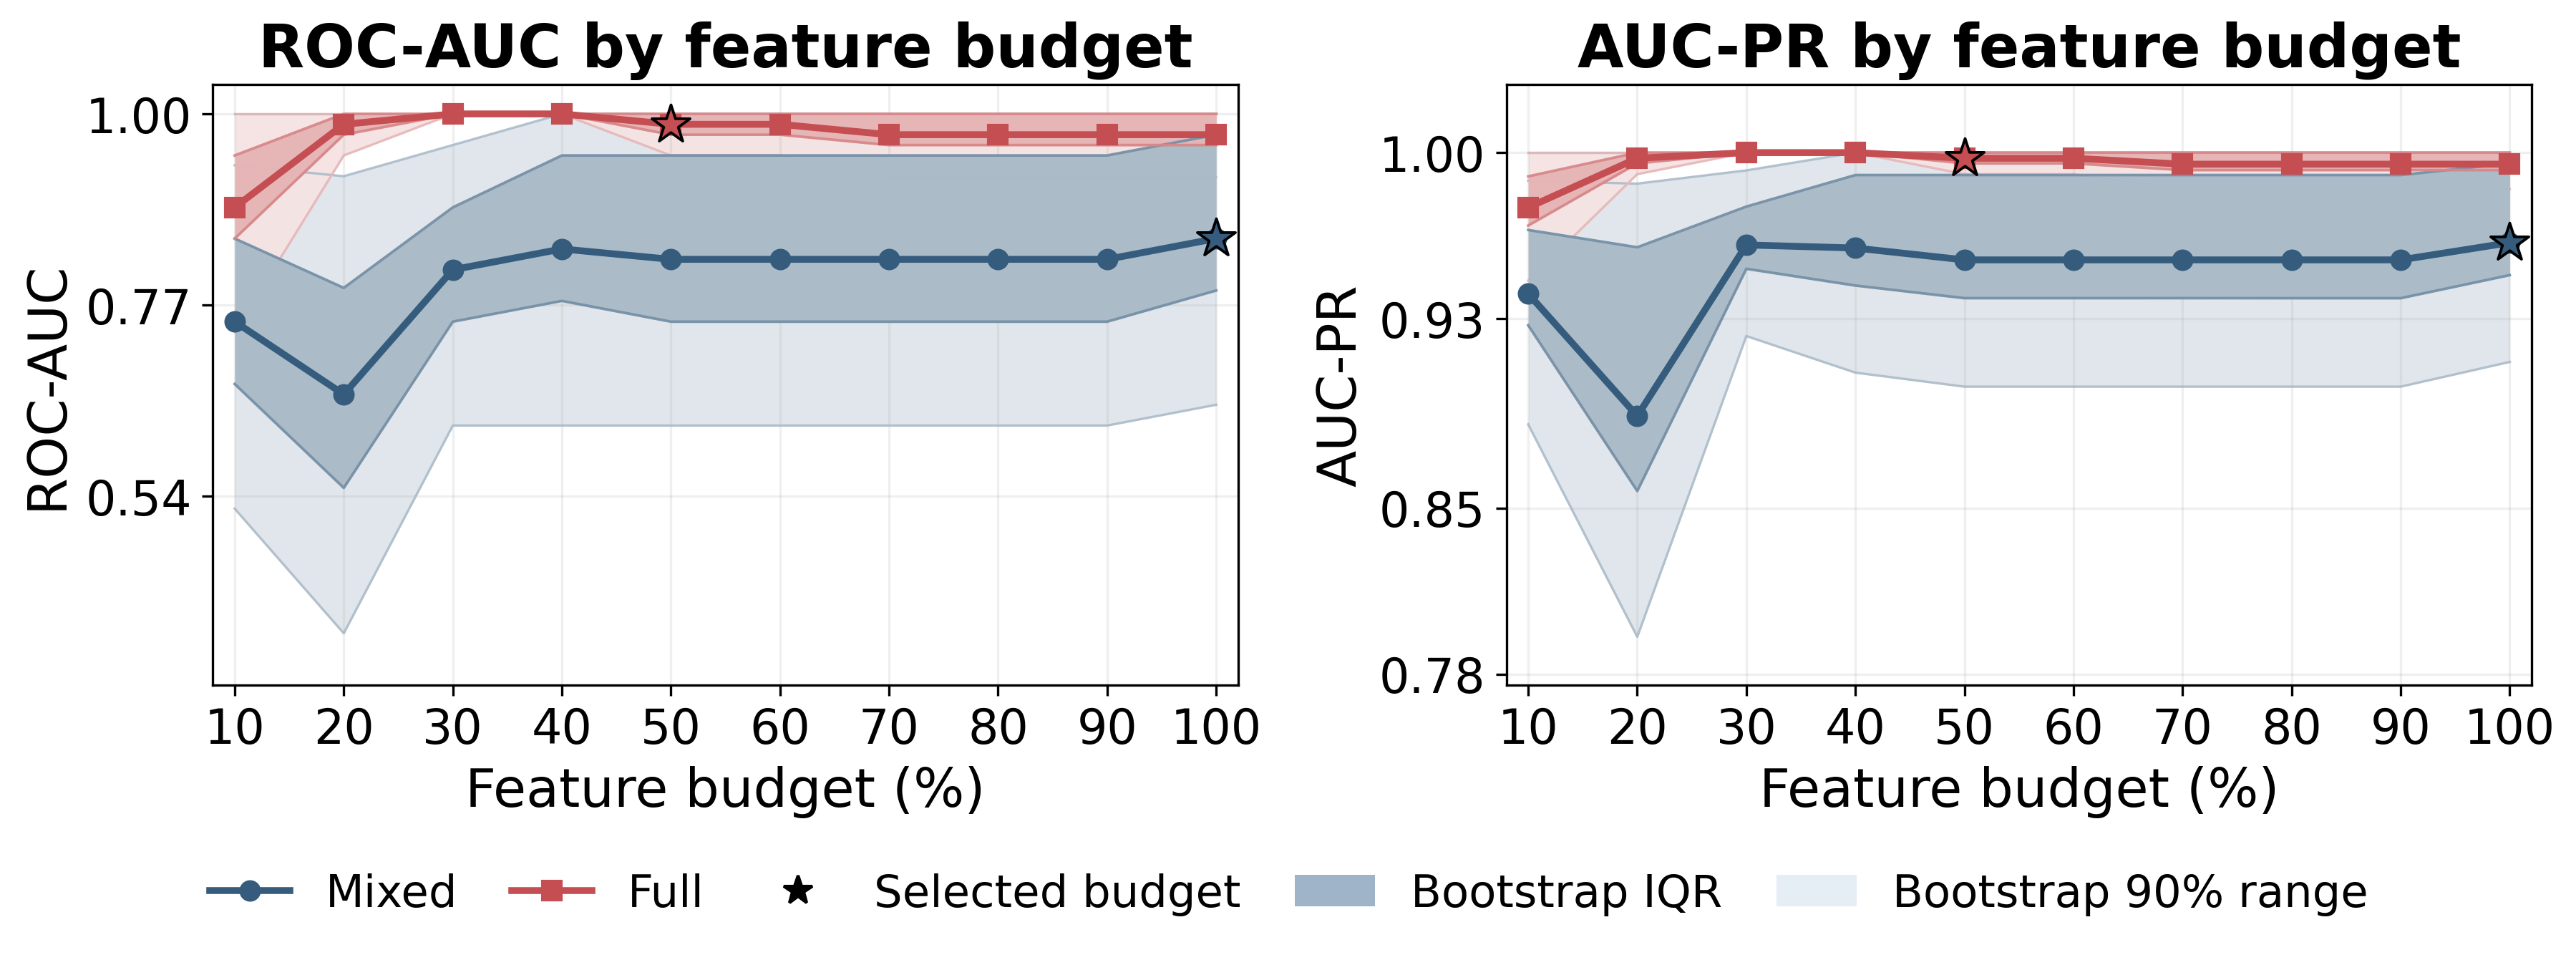

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.colors import to_rgb
from IPython.display import display, Markdown, Image

display(Markdown('### Design-space comparison figure'))

design_csv = COMPARISON_DIR / 'design_space_recommendations_by_profile.csv'
design_png = COMPARISON_FIG / 'fig_design_space_profile_comparison.png'

if not design_csv.exists():
    display(Markdown('Run the design-space summary cell first so the comparison CSV exists.'))
else:
    design_df = pd.read_csv(design_csv)

    summary_frames = []
    for profile in PROFILE_ORDER:
        summary_path = profile_paper_dir(profile) / 'dse_feature_budget_summary.csv'
        if summary_path.exists():
            s = pd.read_csv(summary_path).copy()
            if not s.empty:
                s['feature_profile'] = profile
                s['profile_label'] = PROFILE_LABEL.get(profile, profile)
                summary_frames.append(s)

    if not summary_frames:
        display(Markdown('Run the feature-budget export cell first so the budget summaries exist.'))
    else:
        summary_df = pd.concat(summary_frames, ignore_index=True)
        available_profiles = [
            p for p in PROFILE_ORDER
            if p in set(summary_df['feature_profile'])
        ]

        required_cols = [
            'budget_pct', 'roc_auc', 'pr_auc',
            'roc_auc_boot_q05', 'roc_auc_boot_q25', 'roc_auc_boot_q75', 'roc_auc_boot_q95',
            'pr_auc_boot_q05', 'pr_auc_boot_q25', 'pr_auc_boot_q75', 'pr_auc_boot_q95',
        ]
        missing_required = [c for c in required_cols if c not in summary_df.columns]
        if missing_required:
            display(Markdown('Run the updated feature-budget export cell first so the bootstrap columns exist.'))
        else:
            if 'FEATURE_BUDGET_PCTS' not in globals():
                FEATURE_BUDGET_PCTS = list(range(10, 101, 10))

            profile_colors = {
                'mixed': '#355C7D',
                'full': '#C44E52',
            }
            profile_markers = {
                'mixed': 'o',
                'full': 's',
            }

            def lighten_color(color, amount):
                rgb = np.array(to_rgb(color))
                white = np.ones(3)
                return tuple(rgb * (1.0 - amount) + white * amount)

            fig, axes = plt.subplots(
                1, 2,
                figsize=(12.8, 4.8),
                squeeze=False,
                constrained_layout=False,
            )
            axes = axes[0]

            def apply_tight_ylim(ax, lower_vals, upper_vals, force_one_tick=False):
                lower_vals = np.asarray(lower_vals, dtype=float)
                upper_vals = np.asarray(upper_vals, dtype=float)
                valid = np.isfinite(lower_vals) & np.isfinite(upper_vals)

                if not np.any(valid):
                    ax.set_ylim(0.0, 1.02)
                    ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
                    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
                    return

                ymin = float(np.min(lower_vals[valid]))
                ymax = float(np.max(upper_vals[valid]))

                span = max(ymax - ymin, 0.02)
                lower_pad = max(0.012, 0.10 * span)
                upper_pad = max(0.014, 0.14 * span)

                lo = max(0.0, ymin - lower_pad)

                if ymax >= 0.94 or force_one_tick:
                    hi = max(1.018, ymax + upper_pad)
                else:
                    hi = ymax + upper_pad
                hi = min(1.035, hi)

                if hi - lo < 0.06:
                    mid = 0.5 * (lo + hi)
                    lo = max(0.0, mid - 0.035)
                    hi = min(1.035, mid + 0.035)

                ax.set_ylim(lo, hi)

                if force_one_tick or ymax >= 0.94:
                    base_ticks = np.linspace(lo, min(1.0, hi), 4)
                    ticks = np.unique(np.round(np.concatenate([base_ticks, [1.0]]), 2))
                    ticks = ticks[(ticks >= lo - 1e-9) & (ticks <= hi + 1e-9)]
                    ax.set_yticks(ticks)
                else:
                    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

                ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

            def add_budget_panel(
                ax,
                metric_col,
                q05_col,
                q25_col,
                q75_col,
                q95_col,
                y_label,
                title,
                force_one_tick=False,
            ):
                all_lower = []
                all_upper = []

                for profile in available_profiles:
                    d = summary_df[summary_df['feature_profile'] == profile].copy().sort_values('budget_pct')
                    if d.empty:
                        continue

                    x = d['budget_pct'].to_numpy(dtype=float)
                    y = d[metric_col].to_numpy(dtype=float)
                    q05 = d[q05_col].to_numpy(dtype=float)
                    q25 = d[q25_col].to_numpy(dtype=float)
                    q75 = d[q75_col].to_numpy(dtype=float)
                    q95 = d[q95_col].to_numpy(dtype=float)

                    valid = np.isfinite(x) & np.isfinite(y)
                    x = x[valid]
                    y = y[valid]
                    q05 = q05[valid]
                    q25 = q25[valid]
                    q75 = q75[valid]
                    q95 = q95[valid]
                    if len(x) == 0:
                        continue

                    line_color = profile_colors.get(profile, '#4E79A7')
                    marker = profile_markers.get(profile, 'o')

                    range_fill = lighten_color(line_color, 0.84)
                    iqr_fill = lighten_color(line_color, 0.58)
                    range_edge = lighten_color(line_color, 0.60)
                    iqr_edge = lighten_color(line_color, 0.32)

                    ax.fill_between(x, q05, q95, color=range_fill, alpha=0.95, linewidth=0, zorder=1)
                    ax.fill_between(x, q25, q75, color=iqr_fill, alpha=0.98, linewidth=0, zorder=2)

                    ax.plot(x, q05, color=range_edge, linewidth=0.8, alpha=0.95, zorder=1.5)
                    ax.plot(x, q95, color=range_edge, linewidth=0.8, alpha=0.95, zorder=1.5)
                    ax.plot(x, q25, color=iqr_edge, linewidth=0.9, alpha=0.95, zorder=2.5)
                    ax.plot(x, q75, color=iqr_edge, linewidth=0.9, alpha=0.95, zorder=2.5)

                    ax.plot(
                        x,
                        y,
                        color=line_color,
                        marker=marker,
                        linewidth=2.3,
                        markersize=6.2,
                        zorder=3,
                    )

                    rec_row = design_df[design_df['feature_profile'] == profile]
                    if not rec_row.empty and pd.notna(rec_row.iloc[0].get('feature_budget_pct', np.nan)):
                        sel_pct = float(rec_row.iloc[0]['feature_budget_pct'])
                        sel_match = d[np.isclose(d['budget_pct'], sel_pct)]
                        if not sel_match.empty:
                            sel = sel_match.iloc[0]
                            ax.scatter(
                                [sel['budget_pct']],
                                [sel[metric_col]],
                                s=180,
                                marker='*',
                                color=line_color,
                                edgecolor='black',
                                linewidth=0.9,
                                zorder=5,
                            )

                    all_lower.extend(q05.tolist())
                    all_upper.extend(q95.tolist())

                ax.set_xlim(8, 102)
                ax.set_xticks(FEATURE_BUDGET_PCTS)
                ax.set_xlabel('Feature budget (%)')
                ax.set_ylabel(y_label)
                ax.set_title(title, fontweight='bold')
                ax.grid(alpha=0.20)
                apply_tight_ylim(ax, all_lower, all_upper, force_one_tick=force_one_tick)

            add_budget_panel(
                axes[0],
                metric_col='roc_auc',
                q05_col='roc_auc_boot_q05',
                q25_col='roc_auc_boot_q25',
                q75_col='roc_auc_boot_q75',
                q95_col='roc_auc_boot_q95',
                y_label='ROC-AUC',
                title='ROC-AUC by feature budget',
                force_one_tick=True,
            )

            add_budget_panel(
                axes[1],
                metric_col='pr_auc',
                q05_col='pr_auc_boot_q05',
                q25_col='pr_auc_boot_q25',
                q75_col='pr_auc_boot_q75',
                q95_col='pr_auc_boot_q95',
                y_label='AUC-PR',
                title='AUC-PR by feature budget',
                force_one_tick=False,
            )

            handles = []
            for profile in available_profiles:
                handles.append(
                    Line2D(
                        [0], [0],
                        color=profile_colors.get(profile, '#4E79A7'),
                        marker=profile_markers.get(profile, 'o'),
                        linewidth=2.3,
                        markersize=6.2,
                        label=PROFILE_LABEL.get(profile, profile),
                    )
                )

            handles += [
                Line2D([0], [0], color='black', marker='*', linestyle='None', markersize=10, label='Selected budget'),
                Patch(facecolor='#9FB4C9', edgecolor='none', label='Bootstrap IQR'),
                Patch(facecolor='#E5EDF5', edgecolor='none', label='Bootstrap 90% range'),
            ]

            fig.legend(
                handles=handles,
                loc='lower center',
                bbox_to_anchor=(0.5, 0.01),
                ncol=len(handles),
                frameon=False,
                handlelength=1.8,
                columnspacing=1.2,
            )

            fig.tight_layout(rect=[0.02, 0.11, 0.98, 0.98])
            fig.savefig(design_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
            display(Image(filename=str(design_png)))
            plt.close(fig)



## 6B. Runtime and Power Context

This section separates three related but different ideas:
- runtime context,
- deployment cost,
- and host power context.

The released dataset already supports workload power context. A true detector-overhead claim, however, needs paired benign runs with and without DICE enabled. The helper cell below is for collecting those paired traces.


In [67]:
display(Markdown('### Low-overhead comparison tables'))

low_overhead_csv = COMPARISON_DIR / 'low_overhead_story_by_profile.csv'
rows = []
for profile in PROFILE_ORDER:
    overall_path = profile_global_dir(profile) / 'overall_metrics.csv'
    sequential_path = profile_global_dir(profile) / 'sequential_metrics.csv'
    if not overall_path.exists() or not sequential_path.exists():
        continue
    overall = pd.read_csv(overall_path)
    sequential = pd.read_csv(sequential_path)
    final_row = overall.loc[overall['config'] == FINAL_CONFIG].iloc[0]
    seq_row = sequential.loc[sequential['config'] == FINAL_CONFIG].iloc[0]

    two_stage_path = profile_paper_dir(profile) / 'two_stage_dice_summary.csv'
    two_stage = pd.read_csv(two_stage_path) if two_stage_path.exists() else pd.DataFrame()
    if not two_stage.empty:
        cand = two_stage[two_stage['policy'].astype(str).str.startswith('Two-stage')].copy()
        cand = cand.sort_values(['avg_feature_budget', 'benign_alert_rate'], ascending=[True, True]) if not cand.empty else cand
        rec_two_stage = cand.iloc[0] if not cand.empty else None
    else:
        rec_two_stage = None

    feature_budget_path = profile_paper_dir(profile) / 'dse_feature_budget_summary.csv'
    feature_budget = pd.read_csv(feature_budget_path) if feature_budget_path.exists() else pd.DataFrame()
    rec_budget = feature_budget.sort_values(['n_selected_features', 'pr_auc_wc'], ascending=[True, False]).iloc[0] if not feature_budget.empty else None

    rows.append({
        'feature_profile': profile,
        'profile_label': PROFILE_LABEL[profile],
        'final_features': float(final_row['n_features']),
        'final_detect_rate': float(seq_row['anomaly_detect_rate']),
        'final_benign_alert_rate': float(seq_row['benign_run_alert_rate']),
        'final_median_ttd_s': float(seq_row['median_time_to_detect_s']),
        'two_stage_policy': str(rec_two_stage['policy']) if rec_two_stage is not None else '',
        'two_stage_budget': float(rec_two_stage['avg_feature_budget']) if rec_two_stage is not None else np.nan,
        'two_stage_detect_rate': float(rec_two_stage['detection_rate']) if rec_two_stage is not None else np.nan,
        'two_stage_benign_alert_rate': float(rec_two_stage['benign_alert_rate']) if rec_two_stage is not None else np.nan,
        'feature_budget_pct': float(rec_budget['budget_pct']) if rec_budget is not None else np.nan,
        'feature_budget_n_features': float(rec_budget['n_selected_features']) if rec_budget is not None else np.nan,
        'feature_budget_detect_rate': float(rec_budget['detection_rate']) if rec_budget is not None else np.nan,
        'feature_budget_benign_alert_rate': float(rec_budget['benign_alert_rate']) if rec_budget is not None else np.nan,
    })

if not rows:
    display(Markdown('No low-overhead comparison is ready yet. Run the two-stage and feature-budget cells first.'))
else:
    low_overhead_df = pd.DataFrame(rows)
    low_overhead_df.to_csv(low_overhead_csv, index=False)
    display(low_overhead_df.round(4))


### Low-overhead comparison tables

,feature_profile,profile_label,final_features,final_detect_rate,final_benign_alert_rate,final_median_ttd_s,two_stage_policy,two_stage_budget,two_stage_detect_rate,two_stage_benign_alert_rate,feature_budget_pct,feature_budget_n_features,feature_budget_detect_rate,feature_budget_benign_alert_rate
0,mixed,Mixed,64.0,0.9,0.25,76.0,Two-stage q=0.90,64.0,0.45,0.25,10.0,7.0,0.75,0.5
1,full,Full,75.0,1.0,0.25,30.0,Two-stage q=0.90,75.0,1.00,0.25,10.0,8.0,0.95,0.5


### Optional paired-overhead collection and Tier-1 host power context

Use the helper cell below if you want a clean side-by-side measurement of detector overhead.

The recommended setup is to collect paired benign runs for `BROWSER`, `VIDEO_SW`, `PY_AI`, and `PY_STATS`:
- one baseline run without DICE,
- one run with DICE enabled.

Keeping this study benign-only helps separate detector cost from stressor cost. The analysis cell after it summarizes workload power context from the released Tier-1 traces and computes true power overhead once the paired files exist.


In [68]:
display(Markdown("### Paired benign power-overhead collection helper"))

import importlib.util
import sys

POWER_TOOL = REPO_ROOT / "data generation" / "tools" / "collect_power_overhead_pairs.py"
if not POWER_TOOL.exists():
    raise FileNotFoundError(f"Missing power helper script: {POWER_TOOL}")

spec = importlib.util.spec_from_file_location("dice_power_overhead_pairs", POWER_TOOL)
power_tool = importlib.util.module_from_spec(spec)
sys.modules["dice_power_overhead_pairs"] = power_tool
spec.loader.exec_module(power_tool)

POWER_PAIRS_ROOT = DATASET_ROOT / "power_overhead_pairs"
POWER_PAIRS_ROOT.mkdir(parents=True, exist_ok=True)
POWER_MANIFEST = power_tool.ensure_manifest(POWER_PAIRS_ROOT)

def collect_power_overhead_pairs(
    mode: str,
    workloads=None,
    duration_s: int = 1000,
    tier1_alt_bin: str = "macmon",
    runtime_config: str = "tier0_tier1",
    feature_profile: str = "mixed",
    fit_ratio: float = 0.6,
    block_B: int = 60,
    alpha: float = 0.05,
    gain: float = 0.35,
    ridge_lambda: float = 1e-3,
    runtime_hz: int = 1,
):
    workloads = workloads or list(power_tool.WORKLOADS_POWER)
    runtime_cfg = None
    bundle = None
    if mode == "dice_on":
        runtime_cfg = power_tool.RuntimeConfig(
            dataset_root=DATASET_ROOT,
            feature_profile=feature_profile,
            config_name=runtime_config,
            fit_ratio=fit_ratio,
            block_B=block_B,
            alpha=alpha,
            gain=gain,
            ridge_lambda=ridge_lambda,
            runtime_hz=runtime_hz,
        )
        bundle = power_tool.prepare_bundle(runtime_cfg)

    rows = []
    for workload in workloads:
        out_csv = power_tool.collect_one(
            dataset_root=DATASET_ROOT,
            pairs_root=POWER_PAIRS_ROOT,
            workload=workload,
            mode=mode,
            tier1_alt_bin=tier1_alt_bin,
            duration_s=duration_s,
            runtime_cfg=runtime_cfg,
            bundle=bundle,
        )
        rows.append({"workload": workload, "mode": mode, "output_csv": str(out_csv)})
    out_df = pd.DataFrame(rows)
    display(out_df)
    return out_df


def verify_power_overhead_pairs():
    manifest = pd.read_csv(POWER_MANIFEST).copy()
    manifest["abs_path"] = manifest["csv_path"].apply(lambda p: POWER_PAIRS_ROOT / p)
    manifest["exists"] = manifest["abs_path"].apply(Path.exists)
    display(manifest[["workload", "mode", "abs_path", "exists"]])
    return manifest


if POWER_MANIFEST.exists():
    display(pd.read_csv(POWER_MANIFEST))
else:
    display(Markdown(f"Manifest not created yet at `{POWER_MANIFEST}`."))

print("Run collect_power_overhead_pairs(mode='baseline') first, then collect_power_overhead_pairs(mode='dice_on'), then verify_power_overhead_pairs().")


### Paired benign power-overhead collection helper

,workload,mode,csv_path,power_col,sample_hz
0,BROWSER,baseline,BROWSER/baseline/tier1_alt_full_5hz.csv,sys_power,5
1,BROWSER,dice_on,BROWSER/dice_on/tier1_alt_full_5hz.csv,sys_power,5
2,VIDEO_SW,baseline,VIDEO_SW/baseline/tier1_alt_full_5hz.csv,sys_power,5
3,VIDEO_SW,dice_on,VIDEO_SW/dice_on/tier1_alt_full_5hz.csv,sys_power,5
4,PY_AI,baseline,PY_AI/baseline/tier1_alt_full_5hz.csv,sys_power,5
5,PY_AI,dice_on,PY_AI/dice_on/tier1_alt_full_5hz.csv,sys_power,5
6,PY_STATS,baseline,PY_STATS/baseline/tier1_alt_full_5hz.csv,sys_power,5
7,PY_STATS,dice_on,PY_STATS/dice_on/tier1_alt_full_5hz.csv,sys_power,5


Run collect_power_overhead_pairs(mode='baseline') first, then collect_power_overhead_pairs(mode='dice_on'), then verify_power_overhead_pairs().


### Tier-1 host power context from released traces

,workload,source_file,power_col,mean_power_w,p95_power_w,energy_j
4,BROWSER,tier1_alt_full_5hz.csv,sys_power,10.4125,15.7493,10412.4935
10,PY_AI,tier1_alt_full_5hz.csv,sys_power,63.7376,97.9348,63737.5598
16,PY_STATS,tier1_alt_full_5hz.csv,sys_power,24.3762,32.9187,24376.2374
22,VIDEO_SW,tier1_alt_full_5hz.csv,sys_power,12.9898,16.1393,12989.8021


,stressor,n_cases,mean_power_w,mean_delta_vs_nominal_w,median_delta_vs_nominal_w,mean_energy_j
0,ATOMIC,4,20.0929,-7.7861,2.8222,20092.8970
1,BRANCH,4,23.9440,-3.9350,4.9737,23944.0263
2,CACHE,4,27.7702,-0.1088,11.4754,27770.1923
3,MEMBW,4,34.2233,6.3443,7.9821,34223.3323
4,TLB,4,23.7235,-4.1555,2.4568,23723.4791


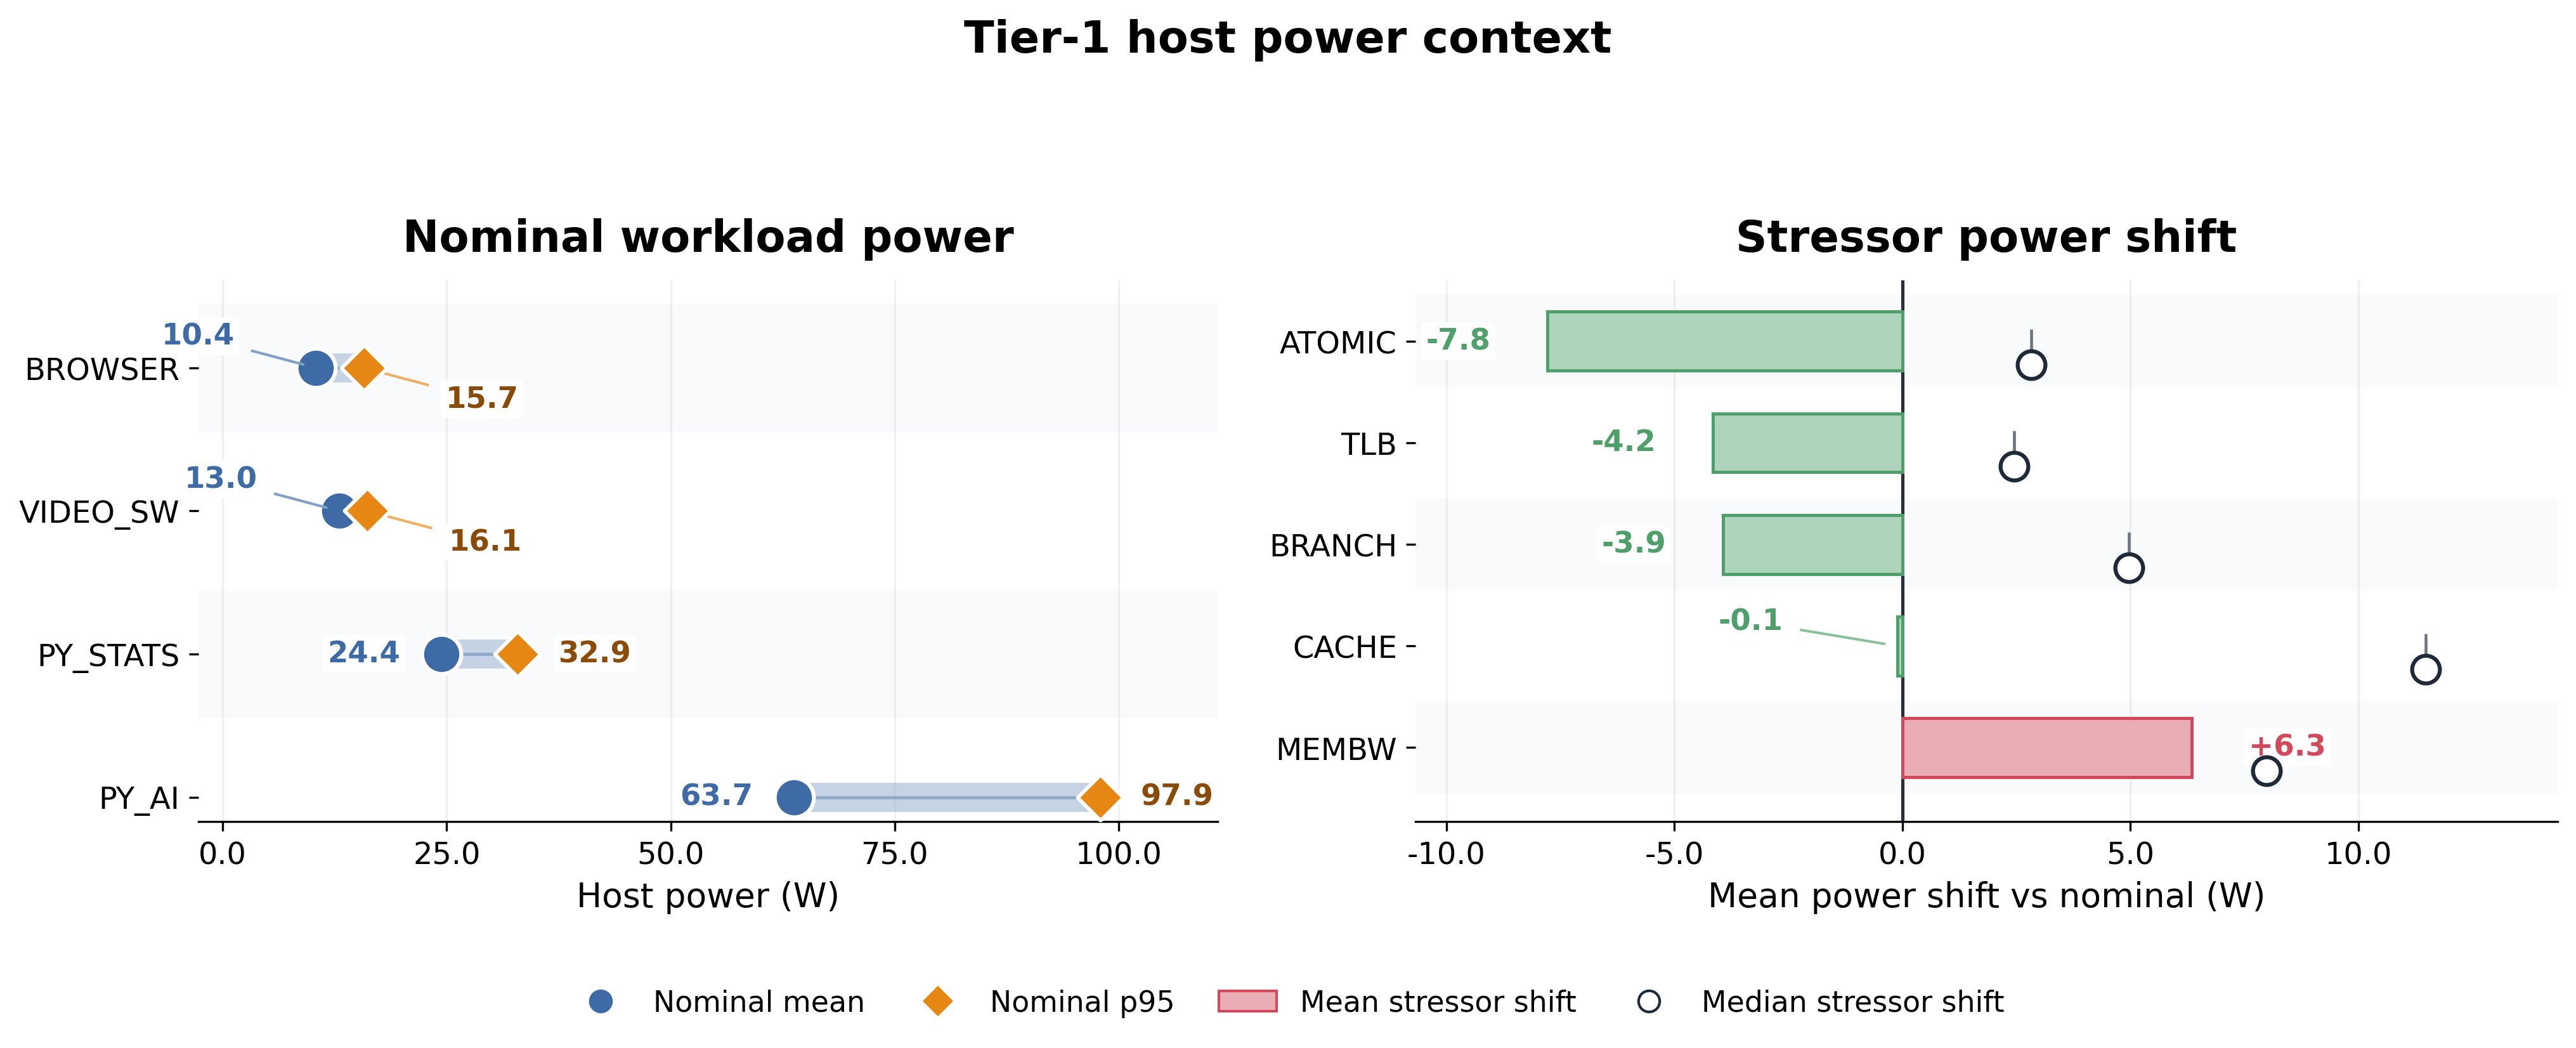

### Benign-only paired DICE-off/DICE-on overhead measurement

This paired study is intentionally limited to the four benign workloads. It is meant to measure detector cost, not stressor-driven workload cost.

Template manifest: `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/power_overhead_pairs/manifest_template_benign_only.csv`

The paired manifest was found, but no usable power traces could be parsed.

In [72]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.colors import to_rgb
from IPython.display import display, Markdown, Image

display(Markdown("### Tier-1 host power context from released traces"))

paper_full = OUT_PAPER / "full"
paper_fig = paper_full / "figures"
paper_full.mkdir(parents=True, exist_ok=True)
paper_fig.mkdir(parents=True, exist_ok=True)

WORKLOADS_LOCAL = ["BROWSER", "VIDEO_SW", "PY_AI", "PY_STATS"]
STRESSORS_LOCAL = ["NOMINAL", "CACHE", "TLB", "BRANCH", "MEMBW", "ATOMIC"]
POWER_CANDIDATES = ["sys_power", "all_power", "processor_power_w", "package_power_w", "soc_power_w", "cpu_power_w"]


def lighten_color(color, amount):
    rgb = np.array(to_rgb(color))
    white = np.ones(3)
    return tuple(rgb * (1.0 - amount) + white * amount)


def tight_xlim_from_values(values, include_zero=False, min_span=1.0, pad_frac=0.12, min_pad=0.25):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return (0.0, 1.0)

    xmin = float(np.min(vals))
    xmax = float(np.max(vals))
    if include_zero:
        xmin = min(xmin, 0.0)
        xmax = max(xmax, 0.0)

    span = max(xmax - xmin, min_span)
    pad = max(min_pad, pad_frac * span)
    lo = xmin - pad
    hi = xmax + pad

    if include_zero:
        if xmin >= 0:
            lo = min(lo, -0.05 * span)
        if xmax <= 0:
            hi = max(hi, 0.05 * span)

    return lo, hi


def load_tier1_power_trace(case_id: str):
    case_dir = DATASET_ROOT / "tier1_alt" / case_id
    for fname in ["tier1_alt_full_5hz.csv", "tier1_alt_core_5hz.csv"]:
        p = case_dir / fname
        if not p.exists():
            continue
        df = pd.read_csv(p)
        for col in POWER_CANDIDATES:
            if col in df.columns:
                return df, col, fname
    return None, None, None


power_rows = []
for workload in WORKLOADS_LOCAL:
    for stressor in STRESSORS_LOCAL:
        case_id = f"{workload}__{stressor}"
        df, power_col, source_file = load_tier1_power_trace(case_id)
        if df is None:
            continue

        power = pd.to_numeric(df[power_col], errors="coerce").dropna()
        if len(power) == 0:
            continue

        duration_s = float(len(power) / 5.0)
        power_rows.append(
            {
                "case_id": case_id,
                "workload": workload,
                "stressor": stressor,
                "source_file": source_file,
                "power_col": power_col,
                "mean_power_w": float(power.mean()),
                "median_power_w": float(power.median()),
                "p95_power_w": float(power.quantile(0.95)),
                "duration_s": duration_s,
                "energy_j": float(power.mean() * duration_s),
            }
        )

if len(power_rows) == 0:
    display(Markdown("No Tier-1 power traces were found under `tier1_alt`."))
else:
    power_df = pd.DataFrame(power_rows).sort_values(["workload", "stressor"]).reset_index(drop=True)
    nominal_map = power_df[power_df["stressor"] == "NOMINAL"].set_index("workload")["mean_power_w"].to_dict()
    power_df["delta_vs_nominal_w"] = power_df["mean_power_w"] - power_df["workload"].map(nominal_map)
    power_df.to_csv(paper_full / "tier1_power_context_cases.csv", index=False)

    workload_power = power_df[power_df["stressor"] == "NOMINAL"][
        ["workload", "source_file", "power_col", "mean_power_w", "p95_power_w", "energy_j"]
    ].sort_values("workload")
    workload_power.to_csv(paper_full / "tier1_power_context_workloads.csv", index=False)

    stressor_power = (
        power_df[power_df["stressor"] != "NOMINAL"]
        .groupby("stressor", as_index=False)
        .agg(
            n_cases=("case_id", "count"),
            mean_power_w=("mean_power_w", "mean"),
            mean_delta_vs_nominal_w=("delta_vs_nominal_w", "mean"),
            median_delta_vs_nominal_w=("delta_vs_nominal_w", "median"),
            mean_energy_j=("energy_j", "mean"),
        )
        .sort_values("stressor")
    )
    stressor_power.to_csv(paper_full / "tier1_power_context_stressors.csv", index=False)

    display(workload_power.round(4))
    display(stressor_power.round(4))

    nominal_view = workload_power.sort_values("mean_power_w").reset_index(drop=True)
    stressor_view = stressor_power.sort_values("mean_delta_vs_nominal_w").reset_index(drop=True)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14.4, 5.6),
        gridspec_kw={"width_ratios": [1.0, 1.12]},
        constrained_layout=False,
    )

    title_fs = 16.5
    label_fs = 12.8
    tick_fs = 11.5
    number_fs = 11.2

    # ------------------------------------------------------------
    # Panel 1: nominal workload power context
    # ------------------------------------------------------------
    ax = axes[0]
    y0 = np.arange(len(nominal_view), dtype=float)

    mean_color = "#3E6BA5"
    p95_color = "#E68613"
    connector_fill = lighten_color(mean_color, 0.70)
    connector_edge = lighten_color(mean_color, 0.42)

    for yi in y0:
        if int(yi) % 2 == 0:
            ax.axhspan(yi - 0.44, yi + 0.44, color="#F8FAFC", zorder=0)

    mean_vals = nominal_view["mean_power_w"].to_numpy(dtype=float)
    p95_vals = nominal_view["p95_power_w"].to_numpy(dtype=float)

    for yi, row in zip(y0, nominal_view.itertuples(index=False)):
        x1 = float(row.mean_power_w)
        x2 = float(row.p95_power_w)
        lo, hi = sorted([x1, x2])

        ax.plot([lo, hi], [yi, yi], color=connector_fill, linewidth=11, solid_capstyle="round", zorder=1)
        ax.plot([lo, hi], [yi, yi], color=connector_edge, linewidth=1.2, solid_capstyle="round", zorder=1.2)

    ax.scatter(
        mean_vals,
        y0,
        s=220,
        color=mean_color,
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )
    ax.scatter(
        p95_vals,
        y0,
        s=150,
        marker="D",
        color=p95_color,
        edgecolor="white",
        linewidth=1.4,
        zorder=4,
    )

    xlim_left = tight_xlim_from_values(
        np.concatenate([mean_vals, p95_vals]),
        include_zero=False,
        min_span=3.0,
        pad_frac=0.15,
        min_pad=0.6,
    )
    x_span_left = xlim_left[1] - xlim_left[0]
    gap_thr_left = max(0.30, 0.06 * x_span_left)
    edge_thr_left = max(0.35, 0.08 * x_span_left)
    nudge_left = max(0.18, 0.04 * x_span_left)
    far_nudge_left = max(0.34, 0.08 * x_span_left)

    for yi, row in zip(y0, nominal_view.itertuples(index=False)):
        x_mean = float(row.mean_power_w)
        x_p95 = float(row.p95_power_w)
        gap = abs(x_p95 - x_mean)

        if gap < gap_thr_left:
            mx = x_mean - far_nudge_left
            my = yi - 0.22
            mha = "right"
            mean_arrow = True
        elif x_mean < xlim_left[0] + edge_thr_left:
            mx = x_mean + nudge_left
            my = yi
            mha = "left"
            mean_arrow = False
        else:
            mx = x_mean - nudge_left
            my = yi
            mha = "right"
            mean_arrow = False

        mean_kwargs = dict(
            xy=(x_mean, yi),
            xytext=(mx, my),
            textcoords="data",
            ha=mha,
            va="center",
            fontsize=number_fs,
            fontweight="bold",
            color=mean_color,
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.95),
        )
        if mean_arrow:
            mean_kwargs["arrowprops"] = dict(
                arrowstyle="-",
                color=lighten_color(mean_color, 0.35),
                linewidth=1.0,
                shrinkA=5,
                shrinkB=5,
            )
        ax.annotate(f"{x_mean:.1f}", **mean_kwargs)

        if gap < gap_thr_left:
            px = x_p95 + far_nudge_left
            py = yi + 0.22
            pha = "left"
            p95_arrow = True
        elif x_p95 > xlim_left[1] - edge_thr_left:
            px = x_p95 - nudge_left
            py = yi
            pha = "right"
            p95_arrow = False
        else:
            px = x_p95 + nudge_left
            py = yi
            pha = "left"
            p95_arrow = False

        p95_kwargs = dict(
            xy=(x_p95, yi),
            xytext=(px, py),
            textcoords="data",
            ha=pha,
            va="center",
            fontsize=number_fs,
            fontweight="bold",
            color="#8A4B08",
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.95),
        )
        if p95_arrow:
            p95_kwargs["arrowprops"] = dict(
                arrowstyle="-",
                color=lighten_color(p95_color, 0.35),
                linewidth=1.0,
                shrinkA=5,
                shrinkB=5,
            )
        ax.annotate(f"{x_p95:.1f}", **p95_kwargs)

    ax.set_xlim(*xlim_left)
    ax.set_yticks(y0)
    ax.set_yticklabels(nominal_view["workload"], fontsize=tick_fs)
    ax.invert_yaxis()
    ax.set_xlabel("Host power (W)", fontsize=label_fs)
    ax.set_title("Nominal workload power", fontsize=title_fs, fontweight="bold", pad=11)
    ax.grid(axis="x", alpha=0.18)
    ax.tick_params(axis="x", labelsize=tick_fs)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # ------------------------------------------------------------
    # Panel 2: stressor power shift
    # ------------------------------------------------------------
    ax = axes[1]
    y1 = np.arange(len(stressor_view), dtype=float)

    pos_color = "#D1495B"
    neg_color = "#4E9F69"
    median_marker_edge = "#1F2937"
    median_offset = 0.23

    for yi in y1:
        if int(yi) % 2 == 0:
            ax.axhspan(yi - 0.44, yi + 0.44, color="#F8FAFC", zorder=0)

    mean_vals = stressor_view["mean_delta_vs_nominal_w"].to_numpy(dtype=float)
    median_vals = stressor_view["median_delta_vs_nominal_w"].to_numpy(dtype=float)

    bar_colors = [pos_color if v >= 0 else neg_color for v in mean_vals]
    bar_fills = [lighten_color(c, 0.55) for c in bar_colors]

    ax.barh(
        y1,
        mean_vals,
        height=0.58,
        color=bar_fills,
        edgecolor=bar_colors,
        linewidth=1.2,
        zorder=2,
    )

    median_y = y1 + median_offset
    ax.vlines(
        median_vals,
        y1 - 0.12,
        median_y - 0.04,
        colors=lighten_color(median_marker_edge, 0.35),
        linewidth=1.1,
        zorder=3,
    )
    ax.scatter(
        median_vals,
        median_y,
        s=110,
        marker="o",
        facecolor="white",
        edgecolor=median_marker_edge,
        linewidth=1.5,
        zorder=4,
    )

    xlim_right = tight_xlim_from_values(
        np.concatenate([mean_vals, median_vals]),
        include_zero=True,
        min_span=1.2,
        pad_frac=0.15,
        min_pad=0.35,
    )
    x_span = xlim_right[1] - xlim_right[0]
    near_zero_thr = max(0.18, 0.08 * x_span)
    edge_thr = max(0.16, 0.08 * x_span)
    label_nudge = max(0.14, 0.05 * x_span)
    label_far_nudge = max(0.24, 0.10 * x_span)

    for yi, row in zip(y1, stressor_view.itertuples(index=False)):
        x = float(row.mean_delta_vs_nominal_w)
        label_color = pos_color if x >= 0 else neg_color

        if abs(x) < near_zero_thr:
            x_text = x + (label_far_nudge if x >= 0 else -label_far_nudge)
            y_text = yi - 0.24
            ha = "left" if x >= 0 else "right"
        elif x > xlim_right[1] - edge_thr:
            x_text = x - label_nudge
            y_text = yi
            ha = "right"
        elif x < xlim_right[0] + edge_thr:
            x_text = x + label_nudge
            y_text = yi
            ha = "left"
        else:
            x_text = x + (label_nudge if x >= 0 else -label_nudge)
            y_text = yi
            ha = "left" if x >= 0 else "right"

        annot_kwargs = dict(
            xy=(x, yi),
            xytext=(x_text, y_text),
            textcoords="data",
            ha=ha,
            va="center",
            fontsize=number_fs,
            fontweight="bold",
            color=label_color,
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.95),
        )

        if abs(y_text - yi) > 1e-9:
            annot_kwargs["arrowprops"] = dict(
                arrowstyle="-",
                color=lighten_color(label_color, 0.35),
                linewidth=1.0,
                shrinkA=5,
                shrinkB=5,
            )

        ax.annotate(f"{x:+.1f}", **annot_kwargs)

    ax.set_xlim(*xlim_right)
    ax.axvline(0.0, color="#111827", linewidth=1.2, zorder=1)
    ax.set_yticks(y1)
    ax.set_yticklabels(stressor_view["stressor"], fontsize=tick_fs)
    ax.set_ylim(len(stressor_view) - 0.5 + median_offset, -0.6)
    ax.set_xlabel("Mean power shift vs nominal (W)", fontsize=label_fs)
    ax.set_title("Stressor power shift", fontsize=title_fs, fontweight="bold", pad=11)
    ax.grid(axis="x", alpha=0.18)
    ax.tick_params(axis="x", labelsize=tick_fs)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="None", markersize=10, markerfacecolor=mean_color, markeredgecolor="white", label="Nominal mean"),
        Line2D([0], [0], marker="D", linestyle="None", markersize=9, markerfacecolor=p95_color, markeredgecolor="white", label="Nominal p95"),
        Patch(facecolor=lighten_color(pos_color, 0.55), edgecolor=pos_color, label="Mean stressor shift"),
        Line2D([0], [0], marker="o", linestyle="None", markersize=8, markerfacecolor="white", markeredgecolor=median_marker_edge, label="Median stressor shift"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        frameon=False,
        fontsize=11.0,
        handlelength=2.0,
        columnspacing=1.5,
    )
    fig.suptitle("Tier-1 host power context", fontsize=16.8, fontweight="bold")
    fig.tight_layout(rect=[0.02, 0.10, 0.98, 0.92])

    tier1_power_png = paper_fig / "fig_tier1_power_context.png"
    fig.savefig(tier1_power_png, dpi=300, bbox_inches="tight", facecolor="white")
    display(Image(filename=str(tier1_power_png)))
    plt.close(fig)


display(Markdown("### Benign-only paired DICE-off/DICE-on overhead measurement"))
display(Markdown(
    "This paired study is intentionally limited to the four benign workloads. "
    "It is meant to measure detector cost, not stressor-driven workload cost."
))

paired_dir = DATASET_ROOT / "power_overhead_pairs"
paired_dir.mkdir(parents=True, exist_ok=True)
paired_manifest = paired_dir / "manifest.csv"
paired_template = paired_dir / "manifest_template_benign_only.csv"

if not paired_template.exists():
    template_rows = []
    for workload in WORKLOADS_LOCAL:
        for mode in ["baseline", "dice_on"]:
            template_rows.append(
                {
                    "workload": workload,
                    "mode": mode,
                    "csv_path": f"{workload}/{mode}/tier1_alt_full_5hz.csv",
                    "power_col": "sys_power",
                    "sample_hz": 5,
                }
            )
    pd.DataFrame(template_rows).to_csv(paired_template, index=False)

display(Markdown(f"Template manifest: `{paired_template}`"))

if not paired_manifest.exists():
    display(Markdown(
        "No paired overhead manifest was found. Fill in the benign-only template at "
        f"`{paired_template}` or create `{paired_manifest}` with columns `workload`, `mode`, and `csv_path`, "
        "plus optional columns `power_col` and `sample_hz`. Use `baseline` for DICE-off runs and `dice_on` for "
        "DICE-enabled runs. After that, rerun this cell to compute mean power delta (W), percent overhead, and extra energy (J)."
    ))
else:
    manifest = pd.read_csv(paired_manifest).copy()
    manifest["workload"] = manifest["workload"].astype(str)
    manifest["mode"] = manifest["mode"].astype(str)
    manifest = manifest[manifest["workload"].isin(WORKLOADS_LOCAL)].copy()
    manifest = manifest[manifest["mode"].isin(["baseline", "dice_on"])].copy()

    if manifest.empty:
        display(Markdown("The paired manifest exists, but it does not contain benign baseline/dice_on rows for the four supported workloads."))
    else:
        counts = manifest.groupby(["workload", "mode"]).size().unstack(fill_value=0)
        missing_pairs = [
            workload for workload in WORKLOADS_LOCAL
            if counts.get("baseline", pd.Series(dtype=int)).get(workload, 0) == 0
            or counts.get("dice_on", pd.Series(dtype=int)).get(workload, 0) == 0
        ]
        if missing_pairs:
            display(Markdown(
                "The paired manifest is missing benign baseline/dice_on rows for: "
                + ", ".join(f"`{w}`" for w in missing_pairs)
                + "."
            ))

        pair_rows = []
        for row in manifest.itertuples(index=False):
            csv_path = Path(row.csv_path)
            if not csv_path.is_absolute():
                csv_path = paired_dir / csv_path
            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            power_col = getattr(row, "power_col", None)
            if not isinstance(power_col, str) or power_col.strip() == "":
                power_col = next((col for col in POWER_CANDIDATES if col in df.columns), None)
            if power_col is None:
                continue

            sample_hz = float(getattr(row, "sample_hz", 5.0) or 5.0)
            power = pd.to_numeric(df[power_col], errors="coerce").dropna()
            if len(power) == 0:
                continue

            pair_rows.append(
                {
                    "workload": row.workload,
                    "mode": row.mode,
                    "power_col": power_col,
                    "mean_power_w": float(power.mean()),
                    "median_power_w": float(power.median()),
                    "p95_power_w": float(power.quantile(0.95)),
                    "duration_s": float(len(power) / sample_hz),
                    "energy_j": float(power.mean() * (len(power) / sample_hz)),
                }
            )

        if len(pair_rows) == 0:
            display(Markdown("The paired manifest was found, but no usable power traces could be parsed."))
        else:
            pair_df = pd.DataFrame(pair_rows).sort_values(["workload", "mode"]).reset_index(drop=True)
            pair_df.to_csv(paper_full / "dice_power_overhead_detail.csv", index=False)

            pivot = pair_df.pivot_table(
                index="workload",
                columns="mode",
                values=["mean_power_w", "energy_j", "median_power_w", "p95_power_w"],
                aggfunc="mean",
            )
            pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
            pivot = pivot.reset_index()

            if "mean_power_w_baseline" in pivot.columns and "mean_power_w_dice_on" in pivot.columns:
                pivot["delta_power_w"] = pivot["mean_power_w_dice_on"] - pivot["mean_power_w_baseline"]
                pivot["delta_power_pct"] = 100.0 * pivot["delta_power_w"] / pivot["mean_power_w_baseline"].replace(0, np.nan)
            if "energy_j_baseline" in pivot.columns and "energy_j_dice_on" in pivot.columns:
                pivot["delta_energy_j"] = pivot["energy_j_dice_on"] - pivot["energy_j_baseline"]

            pivot.to_csv(paper_full / "dice_power_overhead_summary.csv", index=False)
            display(pivot.round(4))

            overhead_summary = pd.DataFrame([
                {
                    "n_workloads": int(len(pivot)),
                    "median_delta_power_w": float(pivot["delta_power_w"].median()) if "delta_power_w" in pivot else float("nan"),
                    "mean_delta_power_w": float(pivot["delta_power_w"].mean()) if "delta_power_w" in pivot else float("nan"),
                    "median_delta_power_pct": float(pivot["delta_power_pct"].median()) if "delta_power_pct" in pivot else float("nan"),
                    "mean_delta_power_pct": float(pivot["delta_power_pct"].mean()) if "delta_power_pct" in pivot else float("nan"),
                    "median_delta_energy_j": float(pivot["delta_energy_j"].median()) if "delta_energy_j" in pivot else float("nan"),
                }
            ])
            overhead_summary.to_csv(paper_full / "dice_power_overhead_headline.csv", index=False)

            headline = overhead_summary.iloc[0]
            abstract_power_line = (
                f"Across paired benign workloads, the median detector power overhead is "
                f"{headline['median_delta_power_w']:.4f} W ({headline['median_delta_power_pct']:.2f}\\%)."
                if pd.notna(headline['median_delta_power_w']) and pd.notna(headline['median_delta_power_pct'])
                else "Paired benign workloads were parsed, but the detector power delta could not be summarized."
            )
            results_power_line = (
                f"Across paired benign workloads, the median detector power overhead is "
                f"{headline['median_delta_power_w']:.4f} W ({headline['median_delta_power_pct']:.2f}\\%), "
                f"and the mean detector power overhead is {headline['mean_delta_power_w']:.4f} W "
                f"({headline['mean_delta_power_pct']:.2f}\\%). This benign-only paired study excludes anomaly-inducing "
                f"stressors so that the reported overhead reflects detector cost rather than stressor cost."
                if pd.notna(headline['median_delta_power_w']) and pd.notna(headline['median_delta_power_pct'])
                and pd.notna(headline['mean_delta_power_w']) and pd.notna(headline['mean_delta_power_pct'])
                else "Paired benign workloads were parsed, but the detector power delta could not be summarized."
            )
            (paper_full / "ABSTRACT_POWER_SNIPPET.md").write_text(abstract_power_line + "\n")
            (paper_full / "RESULTS_POWER_SNIPPET.md").write_text(results_power_line + "\n")
            display(Markdown("> **Abstract power box**  \n" + abstract_power_line))
            display(Markdown("> **Results power box**  \n" + results_power_line))

            overhead_view = pivot.copy().sort_values("delta_power_w").reset_index(drop=True)

            fig, axes = plt.subplots(
                1, 2,
                figsize=(14.2, 5.6),
                gridspec_kw={"width_ratios": [1.05, 0.95]},
                constrained_layout=False,
            )

            title_fs = 16.0
            label_fs = 12.8
            tick_fs = 11.5
            number_fs = 11.0

            baseline_color = "#9AA5B1"
            dice_on_color = "#D1495B"
            connector_fill = lighten_color(dice_on_color, 0.74)
            connector_edge = lighten_color(dice_on_color, 0.42)

            # Left panel: paired baseline vs DICE-on mean power
            ax = axes[0]
            y = np.arange(len(overhead_view), dtype=float)

            for yi in y:
                if int(yi) % 2 == 0:
                    ax.axhspan(yi - 0.44, yi + 0.44, color="#F8FAFC", zorder=0)

            baseline_vals = overhead_view["mean_power_w_baseline"].to_numpy(dtype=float)
            dice_on_vals = overhead_view["mean_power_w_dice_on"].to_numpy(dtype=float)

            for yi, row in zip(y, overhead_view.itertuples(index=False)):
                x1 = float(row.mean_power_w_baseline)
                x2 = float(row.mean_power_w_dice_on)
                lo, hi = sorted([x1, x2])

                ax.plot([lo, hi], [yi, yi], color=connector_fill, linewidth=11, solid_capstyle="round", zorder=1)
                ax.plot([lo, hi], [yi, yi], color=connector_edge, linewidth=1.2, solid_capstyle="round", zorder=1.2)

            ax.scatter(
                baseline_vals,
                y,
                s=170,
                marker="s",
                color=baseline_color,
                edgecolor="white",
                linewidth=1.4,
                zorder=3,
            )
            ax.scatter(
                dice_on_vals,
                y,
                s=190,
                marker="o",
                color=dice_on_color,
                edgecolor="white",
                linewidth=1.4,
                zorder=4,
            )

            left_xlim = tight_xlim_from_values(
                np.concatenate([baseline_vals, dice_on_vals]),
                include_zero=False,
                min_span=0.6,
                pad_frac=0.15,
                min_pad=0.08,
            )
            x_span_left = left_xlim[1] - left_xlim[0]
            gap_thr_left = max(0.05, 0.06 * x_span_left)
            edge_thr_left = max(0.06, 0.07 * x_span_left)
            nudge_left = max(0.03, 0.03 * x_span_left)
            far_nudge_left = max(0.06, 0.06 * x_span_left)

            for yi, row in zip(y, overhead_view.itertuples(index=False)):
                x_base = float(row.mean_power_w_baseline)
                x_on = float(row.mean_power_w_dice_on)
                gap = abs(x_on - x_base)

                if gap < gap_thr_left:
                    bx = x_base - far_nudge_left
                    by = yi - 0.22
                    bha = "right"
                    b_arrow = True
                elif x_base < left_xlim[0] + edge_thr_left:
                    bx = x_base + nudge_left
                    by = yi
                    bha = "left"
                    b_arrow = False
                else:
                    bx = x_base - nudge_left
                    by = yi
                    bha = "right"
                    b_arrow = False

                base_kwargs = dict(
                    xy=(x_base, yi),
                    xytext=(bx, by),
                    textcoords="data",
                    ha=bha,
                    va="center",
                    fontsize=number_fs,
                    fontweight="bold",
                    color="#4B5563",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.94),
                )
                if b_arrow:
                    base_kwargs["arrowprops"] = dict(
                        arrowstyle="-",
                        color=lighten_color("#4B5563", 0.35),
                        linewidth=1.0,
                        shrinkA=5,
                        shrinkB=5,
                    )
                ax.annotate(f"{x_base:.2f}", **base_kwargs)

                if gap < gap_thr_left:
                    dx = x_on + far_nudge_left
                    dy = yi + 0.22
                    dha = "left"
                    d_arrow = True
                elif x_on > left_xlim[1] - edge_thr_left:
                    dx = x_on - nudge_left
                    dy = yi
                    dha = "right"
                    d_arrow = False
                else:
                    dx = x_on + nudge_left
                    dy = yi
                    dha = "left"
                    d_arrow = False

                on_kwargs = dict(
                    xy=(x_on, yi),
                    xytext=(dx, dy),
                    textcoords="data",
                    ha=dha,
                    va="center",
                    fontsize=number_fs,
                    fontweight="bold",
                    color=dice_on_color,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.94),
                )
                if d_arrow:
                    on_kwargs["arrowprops"] = dict(
                        arrowstyle="-",
                        color=lighten_color(dice_on_color, 0.35),
                        linewidth=1.0,
                        shrinkA=5,
                        shrinkB=5,
                    )
                ax.annotate(f"{x_on:.2f}", **on_kwargs)

            ax.set_xlim(*left_xlim)
            ax.set_yticks(y)
            ax.set_yticklabels(overhead_view["workload"], fontsize=tick_fs)
            ax.invert_yaxis()
            ax.set_xlabel("Mean host power (W)", fontsize=label_fs)
            ax.set_title("Benign paired power", fontsize=title_fs, fontweight="bold", pad=11)
            ax.grid(axis="x", alpha=0.18)
            ax.tick_params(axis="x", labelsize=tick_fs)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)

            # Right panel: percent overhead
            ax = axes[1]
            y = np.arange(len(overhead_view), dtype=float)

            for yi in y:
                if int(yi) % 2 == 0:
                    ax.axhspan(yi - 0.44, yi + 0.44, color="#F8FAFC", zorder=0)

            pct_vals = overhead_view["delta_power_pct"].to_numpy(dtype=float)

            pct_fill = lighten_color(dice_on_color, 0.60)
            ax.barh(
                y,
                pct_vals,
                height=0.58,
                color=pct_fill,
                edgecolor=dice_on_color,
                linewidth=1.2,
                zorder=2,
            )
            ax.axvline(0.0, color="#111827", linewidth=1.2, zorder=1)

            right_xlim = tight_xlim_from_values(
                pct_vals,
                include_zero=True,
                min_span=1.0,
                pad_frac=0.18,
                min_pad=0.18,
            )
            x_span_right = right_xlim[1] - right_xlim[0]
            near_zero_thr = max(0.18, 0.06 * x_span_right)
            edge_thr_right = max(0.18, 0.08 * x_span_right)
            nudge_right = max(0.14, 0.04 * x_span_right)
            far_nudge_right = max(0.24, 0.08 * x_span_right)

            for yi, row in zip(y, overhead_view.itertuples(index=False)):
                x = float(row.delta_power_pct)
                label_text = f"{row.delta_power_pct:+.2f}%\n({row.delta_power_w:+.3f} W)"
                label_color = dice_on_color if x >= 0 else "#2D6A4F"

                if abs(x) < near_zero_thr:
                    tx = x + (far_nudge_right if x >= 0 else -far_nudge_right)
                    ty = yi - 0.24
                    tha = "left" if x >= 0 else "right"
                    use_arrow = True
                elif x > right_xlim[1] - edge_thr_right:
                    tx = x - nudge_right
                    ty = yi
                    tha = "right"
                    use_arrow = False
                elif x < right_xlim[0] + edge_thr_right:
                    tx = x + nudge_right
                    ty = yi
                    tha = "left"
                    use_arrow = False
                else:
                    tx = x + (nudge_right if x >= 0 else -nudge_right)
                    ty = yi
                    tha = "left" if x >= 0 else "right"
                    use_arrow = False

                pct_kwargs = dict(
                    xy=(x, yi),
                    xytext=(tx, ty),
                    textcoords="data",
                    ha=tha,
                    va="center",
                    fontsize=10.7,
                    fontweight="bold",
                    color=label_color,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.95),
                )
                if use_arrow:
                    pct_kwargs["arrowprops"] = dict(
                        arrowstyle="-",
                        color=lighten_color(label_color, 0.35),
                        linewidth=1.0,
                        shrinkA=5,
                        shrinkB=5,
                    )
                ax.annotate(label_text, **pct_kwargs)

            ax.set_xlim(*right_xlim)
            ax.set_yticks(y)
            ax.set_yticklabels(overhead_view["workload"], fontsize=tick_fs)
            ax.invert_yaxis()
            ax.set_xlabel("Power overhead (%)", fontsize=label_fs)
            ax.set_title("Detector overhead", fontsize=title_fs, fontweight="bold", pad=11)
            ax.grid(axis="x", alpha=0.18)
            ax.tick_params(axis="x", labelsize=tick_fs)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)

            legend_handles = [
                Line2D([0], [0], marker="s", linestyle="None", markersize=9.5, markerfacecolor=baseline_color, markeredgecolor="white", label="DICE-off baseline"),
                Line2D([0], [0], marker="o", linestyle="None", markersize=10.5, markerfacecolor=dice_on_color, markeredgecolor="white", label="DICE-on"),
                Patch(facecolor=pct_fill, edgecolor=dice_on_color, label="Percent overhead"),
            ]

            fig.legend(
                handles=legend_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.01),
                ncol=3,
                frameon=False,
                fontsize=11.0,
                handlelength=2.0,
                columnspacing=1.7,
            )
            fig.suptitle("Benign paired DICE power overhead", fontsize=16.5, fontweight="bold")
            fig.tight_layout(rect=[0.02, 0.10, 0.98, 0.92])

            overhead_png = paper_fig / "fig_dice_power_overhead_pairs.png"
            fig.savefig(overhead_png, dpi=300, bbox_inches="tight", facecolor="white")
            display(Image(filename=str(overhead_png)))
            plt.close(fig)



## 7. Projected DICE-Score Accelerator Complexity

This section estimates only the hardware cost of the final DICE scoring stage. It does **not** estimate the cost of the full software system around it.

Included in the estimate:
- blockwise accumulation of `|r_{t,j}|`
- weighted reduction into one score
- threshold and persistence logic
- a small top-k attribution buffer

Not included in the estimate:
- telemetry collection
- normalization
- digital-twin state update / synchronization
- host software runtime

So this is best read as a rough hardware-sizing exercise, not as a final chip area or power result.


In [74]:
display(Markdown('### Accelerator complexity tables'))

complexity_csv = COMPARISON_DIR / 'projected_dice_score_accelerator_complexity_profiles.csv'
rows = []
BLOCK_B = 60
ACC_WIDTH_BITS = 32
WEIGHT_WIDTH_BITS = 16
SCORE_WIDTH_BITS = 24
TOPK = 5
PERSIST_COUNTER_BITS = 8

for profile in PROFILE_ORDER:
    overall_path = profile_global_dir(profile) / 'overall_metrics.csv'
    if not overall_path.exists():
        continue
    accel_metrics = pd.read_csv(overall_path).copy().sort_values('n_features').reset_index(drop=True)
    accel_metrics['label'] = accel_metrics['config'].map(CFG_LABEL).fillna(accel_metrics['config'])
    accel_metrics['feature_profile'] = profile
    for row in accel_metrics.itertuples(index=False):
        n = int(row.n_features)
        feature_index_bits = max(1, int(np.ceil(np.log2(max(n, 2)))))
        sample_path_ops_per_block = (n + n) * BLOCK_B
        block_end_ops_per_block = n + max(n - 1, 0) + n * TOPK + 2
        total_state_bits = n * ACC_WIDTH_BITS + n * WEIGHT_WIDTH_BITS + TOPK * (feature_index_bits + SCORE_WIDTH_BITS) + SCORE_WIDTH_BITS + 2 * PERSIST_COUNTER_BITS + 16
        rows.append({
            'feature_profile': profile,
            'profile_label': PROFILE_LABEL[profile],
            'config': row.config,
            'config_label': row.label,
            'n_features': n,
            'sample_path_ops_per_block': sample_path_ops_per_block,
            'block_end_ops_per_block': block_end_ops_per_block,
            'total_state_bytes': int(np.ceil(total_state_bits / 8.0)),
        })

if not rows:
    display(Markdown('No overall metrics are ready yet. Run **Run End-to-End** first.'))
else:
    accel_df = sort_profile_config(add_profile_and_config_labels(pd.DataFrame(rows)))
    base = accel_df.groupby('feature_profile', observed=False)['sample_path_ops_per_block'].transform('min')
    base_block = accel_df.groupby('feature_profile', observed=False)['block_end_ops_per_block'].transform('min')
    base_state = accel_df.groupby('feature_profile', observed=False)['total_state_bytes'].transform('min')
    accel_df['complexity_index'] = (
        0.40 * accel_df['sample_path_ops_per_block'] / base
        + 0.35 * accel_df['block_end_ops_per_block'] / base_block
        + 0.25 * accel_df['total_state_bytes'] / base_state
    )
    accel_df.to_csv(complexity_csv, index=False)
    display(accel_df[['profile_label', 'config_label', 'n_features', 'sample_path_ops_per_block', 'block_end_ops_per_block', 'total_state_bytes', 'complexity_index']].round(3))


### Accelerator complexity tables

,profile_label,config_label,n_features,sample_path_ops_per_block,block_end_ops_per_block,total_state_bytes,complexity_index
0,Mixed,Tier-0,46,5520,323,302,1.000
1,Mixed,Tier-0/1,57,6840,400,368,1.234
2,Mixed,Tier-0/1/2,64,7680,449,410,1.382
3,Full,Tier-0,46,5520,323,302,1.000
4,Full,Tier-0/1,64,7680,449,410,1.382
5,Full,Tier-0/1/2,75,9000,526,477,1.617


### Accelerator comparison figure


### Accelerator comparison figure

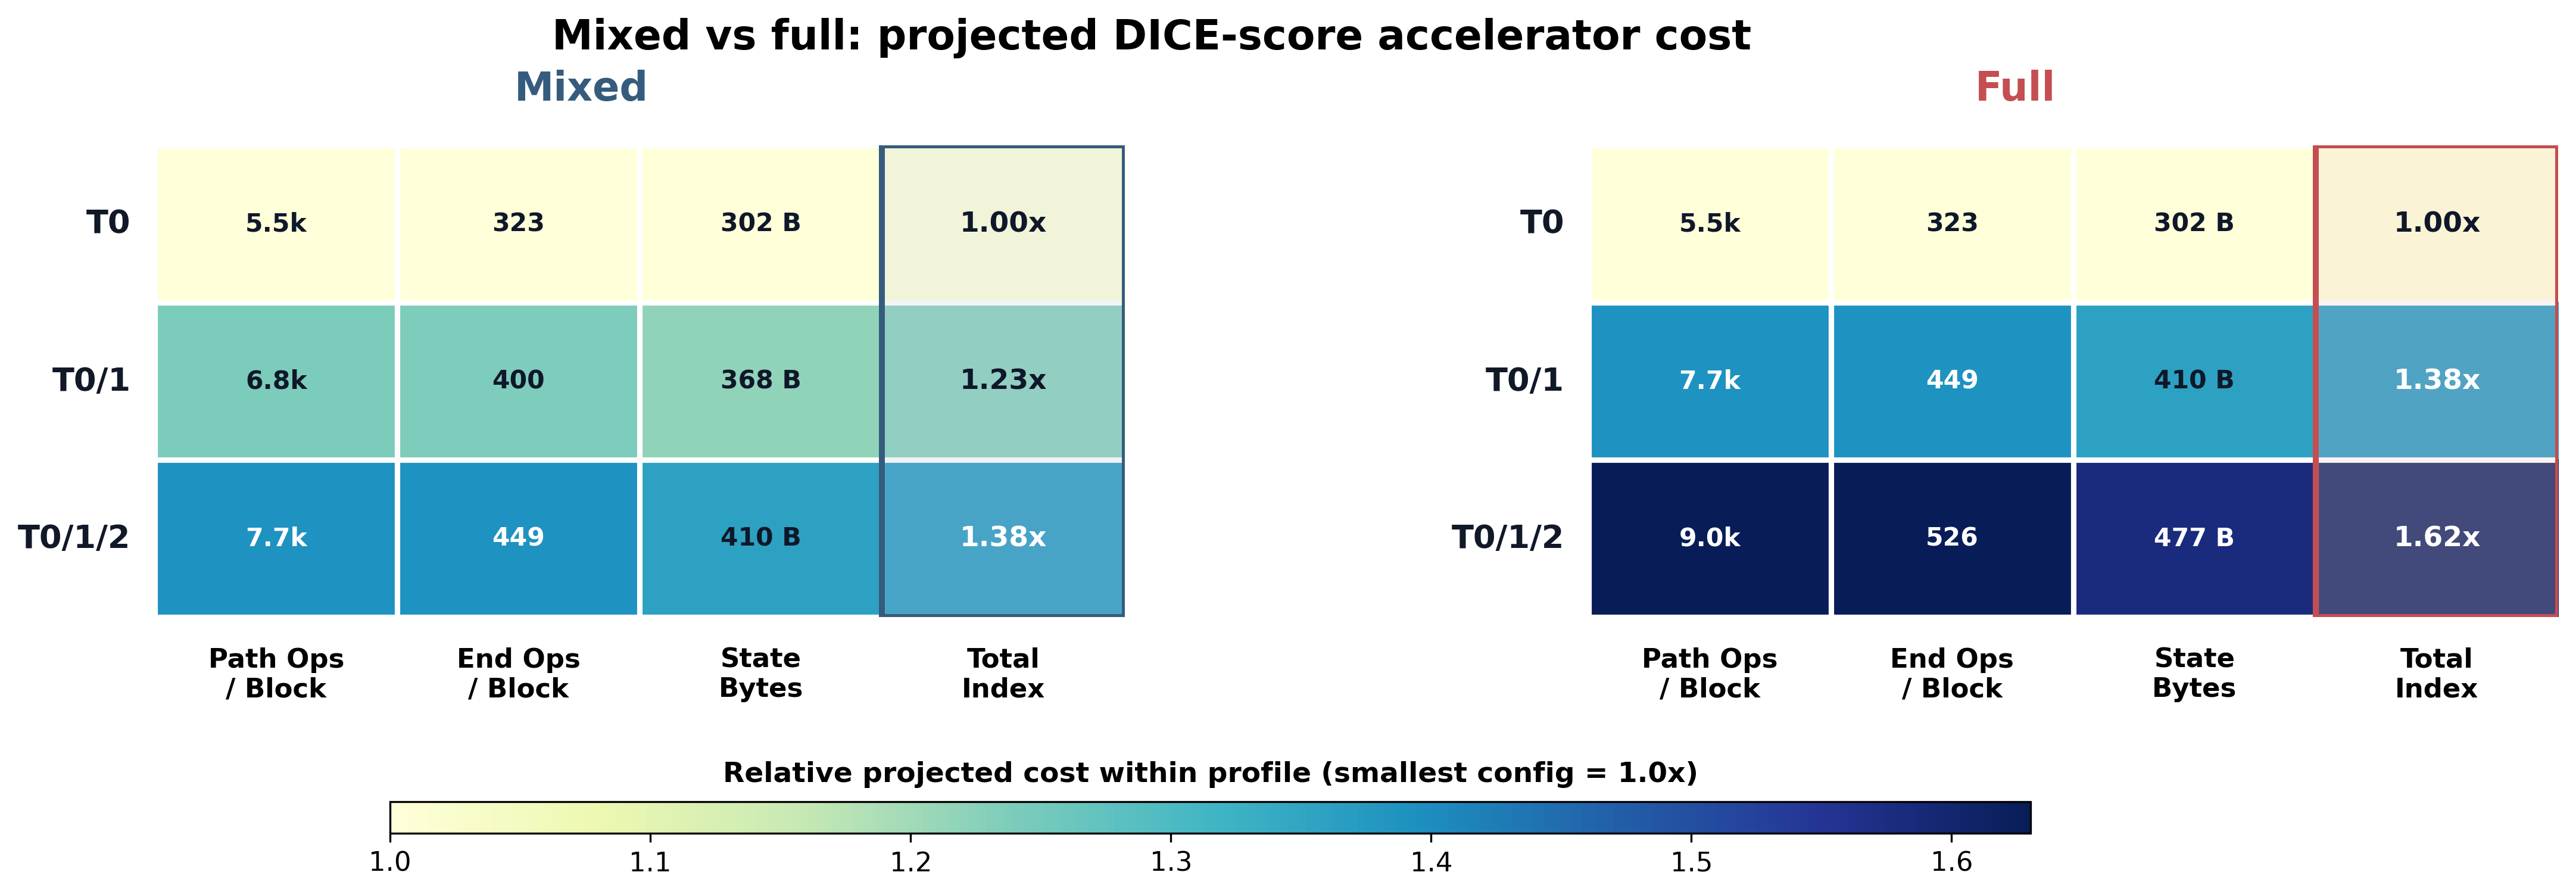

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb
from IPython.display import display, Markdown, Image

display(Markdown('### Accelerator comparison figure'))

complexity_csv = COMPARISON_DIR / 'projected_dice_score_accelerator_complexity_profiles.csv'
complexity_png = COMPARISON_FIG / 'fig_projected_dice_score_accelerator_complexity_profiles.png'

if not complexity_csv.exists():
    display(Markdown('Run the accelerator-complexity cell first so the comparison CSV exists.'))
else:
    accel_df = pd.read_csv(complexity_csv)
    profiles_present = [p for p in PROFILE_ORDER if p in set(accel_df['feature_profile'])]

    if not profiles_present:
        display(Markdown('No accelerator-complexity rows are available yet.'))
    else:
        profile_colors = {
            'mixed': '#355C7D',
            'full': '#C44E52',
        }

        short_label_map = {
            'Tier-0': 'T0',
            'Tier-0/1': 'T0/1',
            'Tier-0/1/2': 'T0/1/2',
            'tier0': 'T0',
            'tier0_tier1_alt': 'T0/1',
            'tier0_tier1_alt_tier2': 'T0/1/2',
        }

        component_specs = [
            ('sample_path_ops_per_block', 'Path Ops\n/ Block', lambda v: f'{v/1000:.1f}k' if v >= 1000 else f'{int(v)}'),
            ('block_end_ops_per_block', 'End Ops\n/ Block', lambda v: f'{int(v)}'),
            ('total_state_bytes', 'State\nBytes', lambda v: f'{int(v)} B'),
            ('complexity_index', 'Total\nIndex', lambda v: f'{v:.2f}x'),
        ]

        def ensure_labels(df):
            out = df.copy()
            if 'config_label' not in out.columns:
                if 'label' in out.columns:
                    out['config_label'] = out['label']
                else:
                    out['config_label'] = out['config'].astype(str)

            out['display_label'] = [
                short_label_map.get(str(lbl), short_label_map.get(str(cfg), str(lbl)))
                for cfg, lbl in zip(out['config'], out['config_label'])
            ]
            return out

        def blend_with_white(color, amount):
            rgb = np.array(to_rgb(color))
            white = np.ones(3)
            return tuple(rgb * (1.0 - amount) + white * amount)

        mats = {}
        vmax = 1.0
        max_rows = 0

        for profile in profiles_present:
            d = accel_df[accel_df['feature_profile'] == profile].copy().sort_values('n_features').reset_index(drop=True)
            d = ensure_labels(d)
            max_rows = max(max_rows, len(d))

            ratio_cols = []
            for col, _, _ in component_specs:
                base = max(float(pd.to_numeric(d[col], errors='coerce').min()), 1e-12)
                ratio_cols.append(pd.to_numeric(d[col], errors='coerce').to_numpy(dtype=float) / base)

            mat = np.column_stack(ratio_cols)
            mats[profile] = (d, mat)
            vmax = max(vmax, float(np.nanmax(mat)))

        norm = Normalize(vmin=1.0, vmax=max(1.05, vmax))
        cmap = plt.cm.YlGnBu

        fig_h = max(5.5, 2.7 + 0.84 * max_rows)
        fig_w = 8.2 * len(profiles_present)
        fig, axes = plt.subplots(
            1,
            len(profiles_present),
            figsize=(fig_w, fig_h),
            squeeze=False,
            constrained_layout=False,
        )
        axes = axes[0]

        for ax, profile in zip(axes, profiles_present):
            d, mat = mats[profile]
            accent = profile_colors.get(profile, '#355C7D')

            n_rows, n_cols = mat.shape

            # Dedicated left gutter for row labels.
            gutter_x0 = -0.98
            gutter_w = 0.48
            label_x = -0.60

            ax.imshow(
                mat,
                aspect='auto',
                cmap=cmap,
                norm=norm,
                interpolation='nearest',
                extent=(-0.5, n_cols - 0.5, n_rows - 0.5, -0.5),
                zorder=1,
            )

            ax.set_xlim(gutter_x0, n_cols - 0.5)
            ax.set_ylim(n_rows - 0.5, -0.5)

            ax.add_patch(
                Rectangle(
                    (gutter_x0, -0.5),
                    gutter_w,
                    n_rows,
                    facecolor='white',
                    edgecolor='none',
                    zorder=0,
                )
            )

            ax.set_yticks([])
            for i, lbl in enumerate(d['display_label']):
                ax.text(
                    label_x,
                    i,
                    str(lbl),
                    ha='right',
                    va='center',
                    fontsize=13.0,
                    fontweight='bold',
                    color='#111827',
                    zorder=10,
                )

            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels(
                [label for _, label, _ in component_specs],
                fontsize=10.8,
                fontweight='bold',
            )
            ax.tick_params(axis='x', pad=12, length=0)
            ax.xaxis.tick_bottom()

            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which='minor', color='white', linewidth=2.2)
            ax.tick_params(which='minor', bottom=False, left=False)

            total_fill = blend_with_white(accent, 0.72)
            for i in range(n_rows):
                ax.add_patch(
                    Rectangle(
                        (n_cols - 1 - 0.5, i - 0.5),
                        1.0,
                        1.0,
                        facecolor=total_fill,
                        edgecolor='none',
                        alpha=0.24,
                        zorder=2,
                    )
                )

            ax.add_patch(
                Rectangle(
                    (n_cols - 1 - 0.5, -0.5),
                    1.0,
                    n_rows,
                    fill=False,
                    edgecolor=accent,
                    linewidth=2.4,
                    zorder=6,
                )
            )

            for i in range(n_rows):
                for j, (col, _, formatter) in enumerate(component_specs):
                    value = float(pd.to_numeric(d.iloc[i][col], errors='coerce'))
                    ratio = float(mat[i, j])

                    if j == n_cols - 1:
                        text_color = 'white' if norm(ratio) > 0.45 else '#0F172A'
                        font_size = 11.3
                    else:
                        text_color = 'white' if norm(ratio) > 0.57 else '#0F172A'
                        font_size = 10.2

                    ax.text(
                        j,
                        i,
                        formatter(value),
                        ha='center',
                        va='center',
                        fontsize=font_size,
                        fontweight='bold',
                        color=text_color,
                        zorder=7,
                    )

            ax.set_title(
                PROFILE_LABEL.get(profile, profile),
                fontsize=16.0,
                fontweight='bold',
                color=accent,
                pad=18,
            )

            for spine in ax.spines.values():
                spine.set_visible(False)

        fig.subplots_adjust(
            left=0.12,
            right=0.98,
            top=0.82,
            bottom=0.34,
            wspace=0.32,
        )

        cbar_ax = fig.add_axes([0.24, 0.12, 0.56, 0.032])
        cbar = fig.colorbar(
            ScalarMappable(norm=norm, cmap=cmap),
            cax=cbar_ax,
            orientation='horizontal',
        )
        cbar.ax.tick_params(labelsize=10.8)
        cbar_ax.set_title(
            'Relative projected cost within profile (smallest config = 1.0x)',
            fontsize=11.3,
            fontweight='bold',
            pad=8,
        )

        fig.suptitle(
            'Mixed vs full: projected DICE-score accelerator cost',
            fontsize=16.6,
            fontweight='bold',
            y=0.95,
        )

        fig.savefig(complexity_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        display(Image(filename=str(complexity_png)))
        plt.close(fig)


## 8. Case Study: True Time-Series Overlay

This section shows a side-by-side comparison between an anomalous run and its matched benign reference.

The plots make it easier to see when the two behaviors begin to separate, where the detector becomes surprised, and how that change appears over time.


### True time-series overlay: anomaly vs benign reference

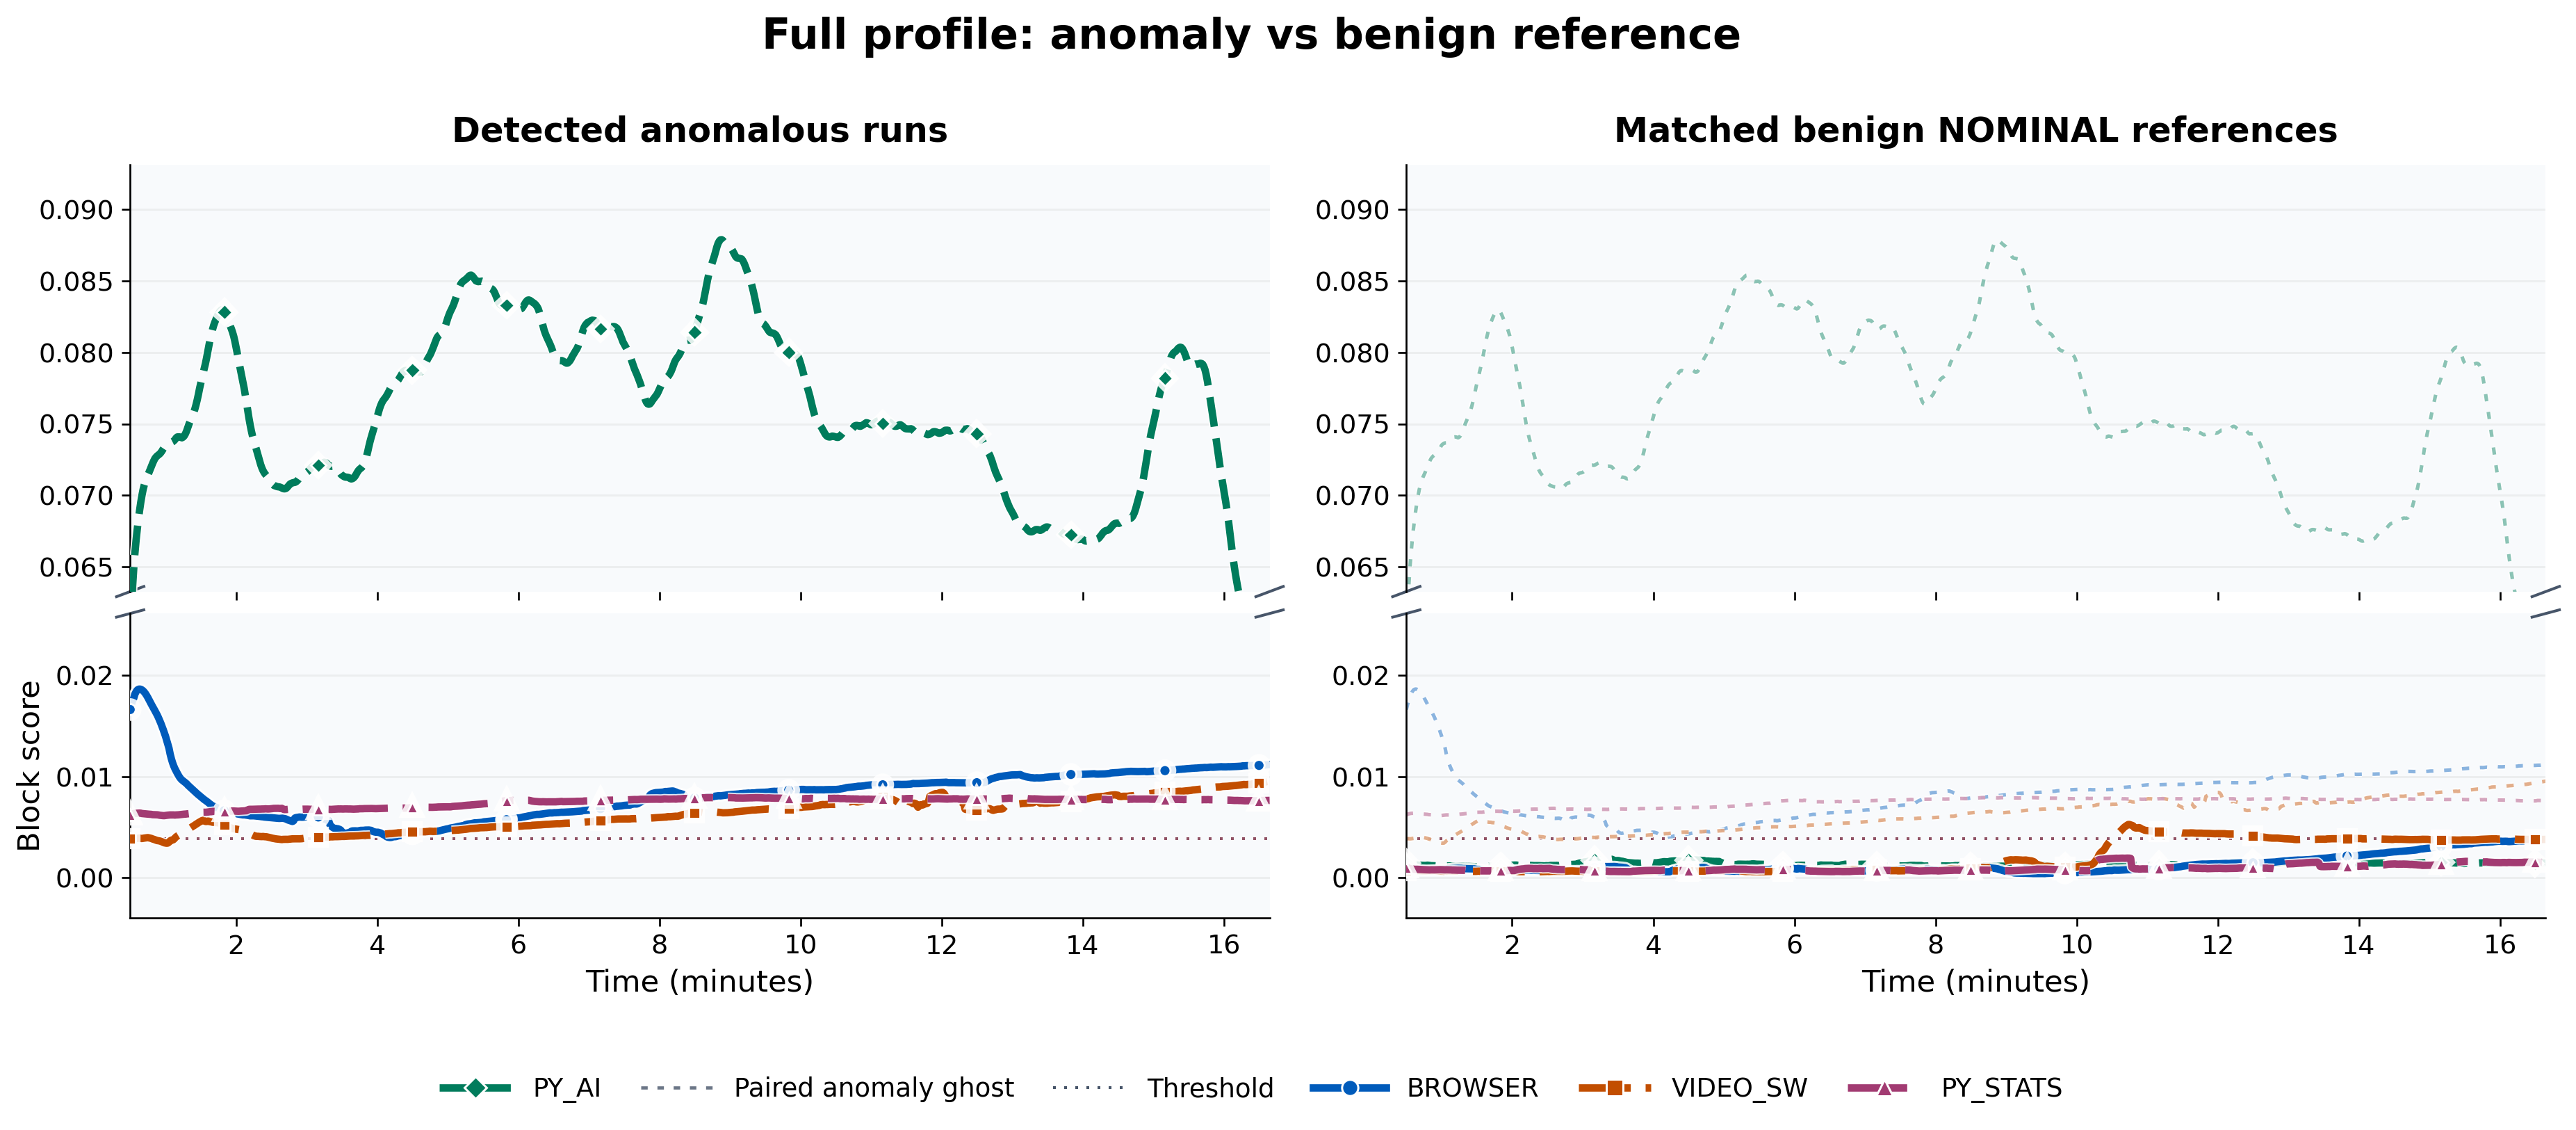

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.lines import Line2D
from IPython.display import display, Markdown, Image

display(Markdown("### True time-series overlay: anomaly vs benign reference"))


def outlined_plot(
    ax,
    x,
    y,
    color,
    linewidth=3.0,
    linestyle="-",
    marker=None,
    markevery=None,
    markersize=4.8,
    alpha=1.0,
    zorder=4,
):
    (line,) = ax.plot(
        x,
        y,
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
        marker=marker,
        markevery=markevery,
        markersize=markersize,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.85,
        alpha=alpha,
        zorder=zorder,
    )
    extra = 1.8 if linestyle == "-" else 1.1
    line.set_path_effects(
        [
            pe.Stroke(linewidth=linewidth + extra, foreground="white", alpha=0.88),
            pe.Normal(),
        ]
    )
    return line


def add_axis_break_marks(ax_top, ax_bottom, d=0.012, color="#475569", lw=1.2):
    kwargs_top = dict(transform=ax_top.transAxes, color=color, clip_on=False, linewidth=lw)
    ax_top.plot((-d, +d), (-d, +d), **kwargs_top)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs_top)

    kwargs_bottom = dict(transform=ax_bottom.transAxes, color=color, clip_on=False, linewidth=lw)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs_bottom)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_bottom)


feature_profile = str(globals().get("ACTIVE_RESULT_PROFILE", globals().get("DISPLAY_FEATURE_PROFILE", "full")))
active_full_out = Path(globals().get("ACTIVE_OUT_FULL", OUT_FULL))
paper_full = OUT_PAPER / feature_profile
paper_full.mkdir(parents=True, exist_ok=True)

case_pred = pd.read_csv(active_full_out / "case_predictions.csv")
trace_path = active_full_out / "case_block_traces.csv"

WORKLOAD_ORDER = ["BROWSER", "VIDEO_SW", "PY_AI", "PY_STATS"]
available_workloads = [
    w for w in WORKLOAD_ORDER
    if w in set(case_pred["workload"].dropna().astype(str))
]
if not available_workloads:
    available_workloads = sorted(case_pred["workload"].dropna().astype(str).unique())

if not trace_path.exists():
    display(Markdown("`case_block_traces.csv` not found yet. Rerun **Run End-to-End** once after the patch cell."))
else:
    trace_df = pd.read_csv(trace_path)

    preferred_cfg_by_profile = {
        "mixed": "tier0_tier1_alt_tier2",
        "full": "tier0_tier1_tier2",
    }
    available_cfgs = set(case_pred["config"].dropna().astype(str))
    preferred_cfg = preferred_cfg_by_profile.get(feature_profile, "tier0_tier1_tier2")

    if preferred_cfg in available_cfgs:
        final_cfg = preferred_cfg
    elif "tier0_tier1_tier2" in available_cfgs:
        final_cfg = "tier0_tier1_tier2"
    elif "tier0_tier1_alt_tier2" in available_cfgs:
        final_cfg = "tier0_tier1_alt_tier2"
    elif available_cfgs:
        final_cfg = sorted(available_cfgs)[-1]
    else:
        final_cfg = preferred_cfg

    displayed_profile = (
        "mixed" if final_cfg == "tier0_tier1_alt_tier2"
        else "full" if final_cfg == "tier0_tier1_tier2"
        else feature_profile
    )

    workload_colors = {
        "BROWSER": "#005BBB",
        "VIDEO_SW": "#C24E00",
        "PY_AI": "#007C5C",
        "PY_STATS": "#A23B72",
    }
    workload_markers = {
        "BROWSER": "o",
        "VIDEO_SW": "s",
        "PY_AI": "D",
        "PY_STATS": "^",
    }
    workload_linestyles = {
        "BROWSER": "-",
        "VIDEO_SW": (0, (7, 2)),
        "PY_AI": (0, (4, 1.6)),
        "PY_STATS": (0, (8, 2, 1.5, 2)),
    }

    detected = case_pred[
        (case_pred["config"] == final_cfg)
        & (case_pred["label"] == 1)
        & (case_pred["run_alert"] == 1)
    ].copy()

    if detected.empty:
        display(Markdown(f"No detected anomaly case found for config `{final_cfg}`."))
    else:
        sort_col = "run_score_wc" if "run_score_wc" in detected.columns else "run_score"

        chosen_rows = []
        for workload in available_workloads:
            dw = detected[detected["workload"] == workload].sort_values(sort_col, ascending=False)
            if not dw.empty:
                chosen_rows.append(dw.iloc[0])

        if not chosen_rows:
            display(Markdown(f"No workload-specific detected anomaly cases found for config `{final_cfg}`."))
        else:
            chosen_df = pd.DataFrame(chosen_rows).reset_index(drop=True)
            trace_rows = []
            tau_rows = []

            for row in chosen_df.itertuples(index=False):
                workload = row.workload
                anomaly_case = row.case_id

                nominal_rows = case_pred[
                    (case_pred["config"] == final_cfg)
                    & (case_pred["workload"] == workload)
                    & (case_pred["stressor"] == "NOMINAL")
                ]
                if nominal_rows.empty:
                    continue

                nominal_case = nominal_rows.iloc[0]["case_id"]

                anom_trace = trace_df[
                    (trace_df["config"] == final_cfg)
                    & (trace_df["case_id"] == anomaly_case)
                ].copy()
                nom_trace = trace_df[
                    (trace_df["config"] == final_cfg)
                    & (trace_df["case_id"] == nominal_case)
                ].copy()
                if anom_trace.empty or nom_trace.empty:
                    continue

                merged = anom_trace.merge(
                    nom_trace[["block_idx", "score"]].rename(columns={"score": "nominal_score"}),
                    on="block_idx",
                    how="inner",
                ).copy()
                if merged.empty:
                    continue

                merged = merged.sort_values("block_idx").reset_index(drop=True)
                merged["block_time_min"] = merged["block_end_s"] / 60.0
                merged["workload"] = workload
                trace_rows.append(merged)

                tau_rows.append(
                    {
                        "workload": workload,
                        "tau": float(row.tau),
                    }
                )

            if not trace_rows:
                display(Markdown(f"No aligned anomaly/reference traces were available for config `{final_cfg}`."))
            else:
                panel_df = pd.concat(trace_rows, ignore_index=True)
                tau_df = pd.DataFrame(tau_rows).drop_duplicates(subset=["workload"])

                tmin = float(panel_df["block_time_min"].min())
                tmax = float(panel_df["block_time_min"].max())

                score_min = float(min(panel_df["score"].min(), panel_df["nominal_score"].min(), tau_df["tau"].min()))
                score_max = float(max(panel_df["score"].max(), panel_df["nominal_score"].max(), tau_df["tau"].max()))
                score_span = max(score_max - score_min, 1e-6)
                score_min -= 0.05 * score_span
                score_max += 0.06 * score_span

                peak_by_workload = {}
                for workload in available_workloads:
                    d = panel_df[panel_df["workload"] == workload]
                    if not d.empty:
                        peak_by_workload[workload] = float(max(d["score"].max(), d["nominal_score"].max()))

                plot_order = sorted(
                    available_workloads,
                    key=lambda w: peak_by_workload.get(w, -np.inf),
                    reverse=True,
                )

                sorted_peaks = sorted(peak_by_workload.values(), reverse=True)
                dominant_peak = sorted_peaks[0] if sorted_peaks else score_max
                second_peak = sorted_peaks[1] if len(sorted_peaks) > 1 else max(score_min + 0.25 * score_span, dominant_peak * 0.25)

                low_max = max(second_peak * 1.40, float(tau_df["tau"].max()) * 1.35)
                high_min = max(dominant_peak * 0.72, low_max * 1.12)

                if low_max <= score_min:
                    low_max = score_min + 0.45 * score_span
                if high_min >= score_max:
                    high_min = score_min + 0.62 * score_span
                    low_max = score_min + 0.52 * score_span
                if high_min <= low_max:
                    high_min = low_max + 0.08 * score_span

                title_fs = 14.8
                axis_fs = 13.0
                tick_fs = 11.4
                legend_fs = 11.2
                suptitle_fs = 18.2

                fig = plt.figure(figsize=(16.0, 7.4))
                gs = fig.add_gridspec(
                    2,
                    2,
                    height_ratios=[1.15, 0.82],
                    left=0.08,
                    right=0.985,
                    top=0.83,
                    bottom=0.22,
                    hspace=0.06,
                    wspace=0.12,
                )

                ax_anom_hi = fig.add_subplot(gs[0, 0])
                ax_ref_hi = fig.add_subplot(gs[0, 1], sharex=ax_anom_hi, sharey=ax_anom_hi)
                ax_anom_lo = fig.add_subplot(gs[1, 0], sharex=ax_anom_hi)
                ax_ref_lo = fig.add_subplot(gs[1, 1], sharex=ax_ref_hi, sharey=ax_anom_lo)

                top_axes = [ax_anom_hi, ax_ref_hi]
                bottom_axes = [ax_anom_lo, ax_ref_lo]
                all_axes = top_axes + bottom_axes

                for ax in all_axes:
                    ax.set_facecolor("#F8FAFC")
                    ax.spines["top"].set_visible(False)
                    ax.spines["right"].set_visible(False)
                    ax.grid(axis="y", alpha=0.16, linewidth=0.9)
                    ax.set_xlim(tmin, tmax)
                    ax.tick_params(axis="both", labelsize=tick_fs)

                for ax in top_axes:
                    ax.set_ylim(high_min, score_max)
                    ax.tick_params(axis="x", labelbottom=False)
                    ax.spines["bottom"].set_visible(False)

                for ax in bottom_axes:
                    ax.set_ylim(score_min, low_max)
                    ax.spines["top"].set_visible(False)
                    ax.set_xlabel("Time (minutes)", fontsize=axis_fs)

                add_axis_break_marks(ax_anom_hi, ax_anom_lo)
                add_axis_break_marks(ax_ref_hi, ax_ref_lo)

                legend_handles = []
                ghost_handle_added = False
                threshold_handle_added = False

                for workload in plot_order:
                    d = panel_df[panel_df["workload"] == workload].copy()
                    if d.empty:
                        continue
                    d = d.sort_values("block_time_min")

                    color = workload_colors.get(workload, "#334155")
                    marker = workload_markers.get(workload, "o")
                    linestyle = workload_linestyles.get(workload, "-")
                    tau = float(tau_df.loc[tau_df["workload"] == workload, "tau"].iloc[0])

                    t = d["block_time_min"].to_numpy(dtype=float)
                    anomaly_score = d["score"].to_numpy(dtype=float)
                    nominal_score = d["nominal_score"].to_numpy(dtype=float)
                    markevery = max(len(t) // 12, 1)

                    for ax in [ax_anom_hi, ax_anom_lo]:
                        outlined_plot(
                            ax,
                            t,
                            anomaly_score,
                            color=color,
                            linewidth=3.2,
                            linestyle=linestyle,
                            marker=marker,
                            markevery=markevery,
                            markersize=4.8,
                            zorder=5,
                        )

                    for ax in [ax_ref_hi, ax_ref_lo]:
                        outlined_plot(
                            ax,
                            t,
                            anomaly_score,
                            color=color,
                            linewidth=1.55,
                            linestyle=(0, (2, 3)),
                            alpha=0.45,
                            zorder=2,
                        )
                        outlined_plot(
                            ax,
                            t,
                            nominal_score,
                            color=color,
                            linewidth=3.2,
                            linestyle=linestyle,
                            marker=marker,
                            markevery=markevery,
                            markersize=4.8,
                            zorder=5,
                        )

                    for ax in [ax_anom_lo, ax_ref_lo]:
                        ax.axhline(
                            tau,
                            color=color,
                            linestyle=(0, (1, 3)),
                            linewidth=1.2,
                            alpha=0.50,
                            zorder=1,
                        )

                    legend_handles.append(
                        Line2D(
                            [0],
                            [0],
                            color=color,
                            linewidth=3.2,
                            linestyle=linestyle,
                            marker=marker,
                            markersize=7.0,
                            markerfacecolor=color,
                            markeredgecolor="white",
                            markeredgewidth=0.9,
                            label=workload,
                        )
                    )

                    if not ghost_handle_added:
                        legend_handles.append(
                            Line2D(
                                [0],
                                [0],
                                color="#475569",
                                linestyle=(0, (2, 3)),
                                linewidth=1.4,
                                alpha=0.8,
                                label="Paired anomaly ghost",
                            )
                        )
                        ghost_handle_added = True

                    if not threshold_handle_added:
                        legend_handles.append(
                            Line2D(
                                [0],
                                [0],
                                color="#475569",
                                linestyle=(0, (1, 3)),
                                linewidth=1.2,
                                label="Threshold",
                            )
                        )
                        threshold_handle_added = True

                ax_anom_lo.set_ylabel("Block score", fontsize=axis_fs)
                ax_anom_hi.set_title("Detected anomalous runs", fontsize=title_fs, fontweight="bold", pad=10)
                ax_ref_hi.set_title("Matched benign NOMINAL references", fontsize=title_fs, fontweight="bold", pad=10)

                fig.legend(
                    handles=legend_handles,
                    loc="lower center",
                    bbox_to_anchor=(0.5, 0.045),
                    ncol=6,
                    frameon=False,
                    fontsize=legend_fs,
                    handlelength=2.8,
                    columnspacing=1.5,
                )

                fig.suptitle(
                    f"{displayed_profile.title()} profile: anomaly vs benign reference",
                    fontsize=suptitle_fs,
                    fontweight="bold",
                    y=0.95,
                )

                out_png = paper_full / "fig_true_timeseries_overlay.png"
                fig.savefig(out_png, dpi=240, bbox_inches="tight", facecolor="white")
                plt.close(fig)
                display(Image(filename=str(out_png)))



## 9. Tier and Mechanism Attribution Dashboard

These plots explain where the detector is getting its evidence.

- The tier view shows which sensing level contributes the most.
- The mechanism view shows which type of system behavior contributes the most.
- The confusion matrix shows which stressors are easiest or hardest for the diagnosis head to tell apart.


In [100]:
display(Markdown('### Attribution summary tables'))

tier_csv = COMPARISON_DIR / 'tier_attribution_profiles.csv'
mechanism_csv = COMPARISON_DIR / 'mechanism_attribution_profiles.csv'
diagnosis_csv = COMPARISON_DIR / 'diagnosis_summary_profiles.csv'

DIAGNOSIS_CANDIDATES = [
    'stressor_feature_diagnosis_metrics.csv',
    'stressor_diagnosis_metrics.csv',
]


def resolve_attribution_profiles():
    ready = []
    missing = {}

    for profile in PROFILE_ORDER:
        profile_missing = []
        gdir = profile_global_dir(profile)

        if not (gdir / 'case_diagnosis_summary.csv').exists():
            profile_missing.append('global/case_diagnosis_summary.csv')

        diagnosis_name = next(
            (name for name in DIAGNOSIS_CANDIDATES if (gdir / name).exists()),
            None,
        )
        if diagnosis_name is None:
            profile_missing.append(
                'global/stressor_feature_diagnosis_metrics.csv or global/stressor_diagnosis_metrics.csv'
            )

        if profile_missing:
            missing[profile] = profile_missing
        else:
            ready.append(profile)

    return ready, missing


ready_profiles, missing_profiles = resolve_attribution_profiles()

if not ready_profiles:
    display(Markdown('No diagnosis bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))
else:
    tier_rows = []
    mechanism_rows = []
    diagnosis_rows = []

    for profile in ready_profiles:
        case_diag = read_profile_csv(profile, 'global', 'case_diagnosis_summary.csv')
        anomaly = case_diag[case_diag['label'] == 1].copy()
        if anomaly.empty:
            continue

        tier_cols = [c for c in ['tier0_share', 'tier1_alt_share', 'tier2_share'] if c in anomaly.columns]
        mech_cols = [
            c for c in [
                'compute_share',
                'memory_io_share',
                'thermal_power_share',
                'scheduler_runtime_share',
                'platform_pressure_share',
            ]
            if c in anomaly.columns
        ]

        if tier_cols:
            tier_summary = (
                anomaly.groupby('config', sort=False)[tier_cols]
                .mean()
                .reset_index()
            )
            tier_summary['feature_profile'] = profile
            tier_rows.append(add_profile_and_config_labels(tier_summary))

        if mech_cols:
            mechanism_summary = (
                anomaly.groupby('config', sort=False)[mech_cols]
                .mean()
                .reset_index()
            )
            mechanism_summary['feature_profile'] = profile
            mechanism_rows.append(add_profile_and_config_labels(mechanism_summary))

        diagnosis_name = next(
            name for name in DIAGNOSIS_CANDIDATES
            if (profile_global_dir(profile) / name).exists()
        )
        diagnosis_raw = read_profile_csv(profile, 'global', diagnosis_name).copy()
        diagnosis_cols = [
            c
            for c in [
                'config',
                'top1_acc',
                'top2_acc',
                'balanced_acc',
                'macro_f1',
                'mean_margin_to_second',
                'median_margin_to_second',
            ]
            if c in diagnosis_raw.columns
        ]

        if 'config' in diagnosis_cols:
            diagnosis = diagnosis_raw[diagnosis_cols].copy()
            diagnosis['feature_profile'] = profile
            diagnosis_rows.append(add_profile_and_config_labels(diagnosis))

    if tier_rows:
        tier_summary = sort_profile_config(pd.concat(tier_rows, ignore_index=True))
        tier_summary.to_csv(tier_csv, index=False)
        display(Markdown('#### Mean tier share by head'))
        display(tier_summary.round(4))
    else:
        tier_summary = pd.DataFrame()
        display(Markdown('#### Mean tier share by head'))
        display(Markdown('No anomaly-attribution tier rows were available.'))

    if mechanism_rows:
        mechanism_summary = sort_profile_config(pd.concat(mechanism_rows, ignore_index=True))
        mechanism_summary.to_csv(mechanism_csv, index=False)
        display(Markdown('#### Mean mechanism share by head'))
        display(mechanism_summary.round(4))
    else:
        mechanism_summary = pd.DataFrame()
        display(Markdown('#### Mean mechanism share by head'))
        display(Markdown('No anomaly-attribution mechanism rows were available.'))

    if diagnosis_rows:
        diagnosis_summary = sort_profile_config(pd.concat(diagnosis_rows, ignore_index=True))
        diagnosis_summary.to_csv(diagnosis_csv, index=False)
        display(Markdown('#### Diagnosis accuracy by head'))
        display(diagnosis_summary.round(4))
    else:
        diagnosis_summary = pd.DataFrame()
        display(Markdown('#### Diagnosis accuracy by head'))
        display(Markdown('No diagnosis metric rows were available.'))

    if missing_profiles:
        display(Markdown(markdown_missing_profiles(missing_profiles)))



### Attribution summary tables

#### Mean tier share by head

,config,tier0_share,tier1_alt_share,tier2_share,feature_profile,profile_label,config_label
0,tier0,1.0000,0.0000,0.0000,mixed,Mixed,Tier-0
1,tier0_tier1,0.8553,0.1447,0.0000,mixed,Mixed,Tier-0/1
2,tier0_tier1_tier2,0.7698,0.1345,0.0957,mixed,Mixed,Tier-0/1/2
3,tier0,1.0000,0.0000,0.0000,full,Full,Tier-0
4,tier0_tier1,0.8024,0.1976,0.0000,full,Full,Tier-0/1
5,tier0_tier1_tier2,0.6739,0.1651,0.1610,full,Full,Tier-0/1/2


#### Mean mechanism share by head

,config,compute_share,memory_io_share,thermal_power_share,scheduler_runtime_share,platform_pressure_share,feature_profile,profile_label,config_label
0,tier0,0.1941,0.4935,0.0000,0.1513,0.1611,mixed,Mixed,Tier-0
1,tier0_tier1,0.2454,0.4246,0.0581,0.1329,0.1390,mixed,Mixed,Tier-0/1
2,tier0_tier1_tier2,0.2243,0.3832,0.0521,0.2154,0.1251,mixed,Mixed,Tier-0/1/2
3,tier0,0.1941,0.4935,0.0000,0.1513,0.1611,full,Full,Tier-0
4,tier0_tier1,0.2441,0.3854,0.0893,0.1399,0.1413,full,Full,Tier-0/1
5,tier0_tier1_tier2,0.2856,0.2991,0.0679,0.2137,0.1337,full,Full,Tier-0/1/2


#### Diagnosis accuracy by head

,config,top1_acc,top2_acc,macro_f1,feature_profile,profile_label,config_label
0,tier0,0.25,0.60,0.2016,mixed,Mixed,Tier-0
1,tier0_tier1,0.30,0.60,0.2371,mixed,Mixed,Tier-0/1
2,tier0_tier1_tier2,0.40,0.60,0.3594,mixed,Mixed,Tier-0/1/2
3,tier0,0.25,0.60,0.2016,full,Full,Tier-0
4,tier0_tier1,0.15,0.35,0.1333,full,Full,Tier-0/1
5,tier0_tier1_tier2,0.15,0.35,0.1511,full,Full,Tier-0/1/2


### Attribution comparison figures


### Attribution comparison figures

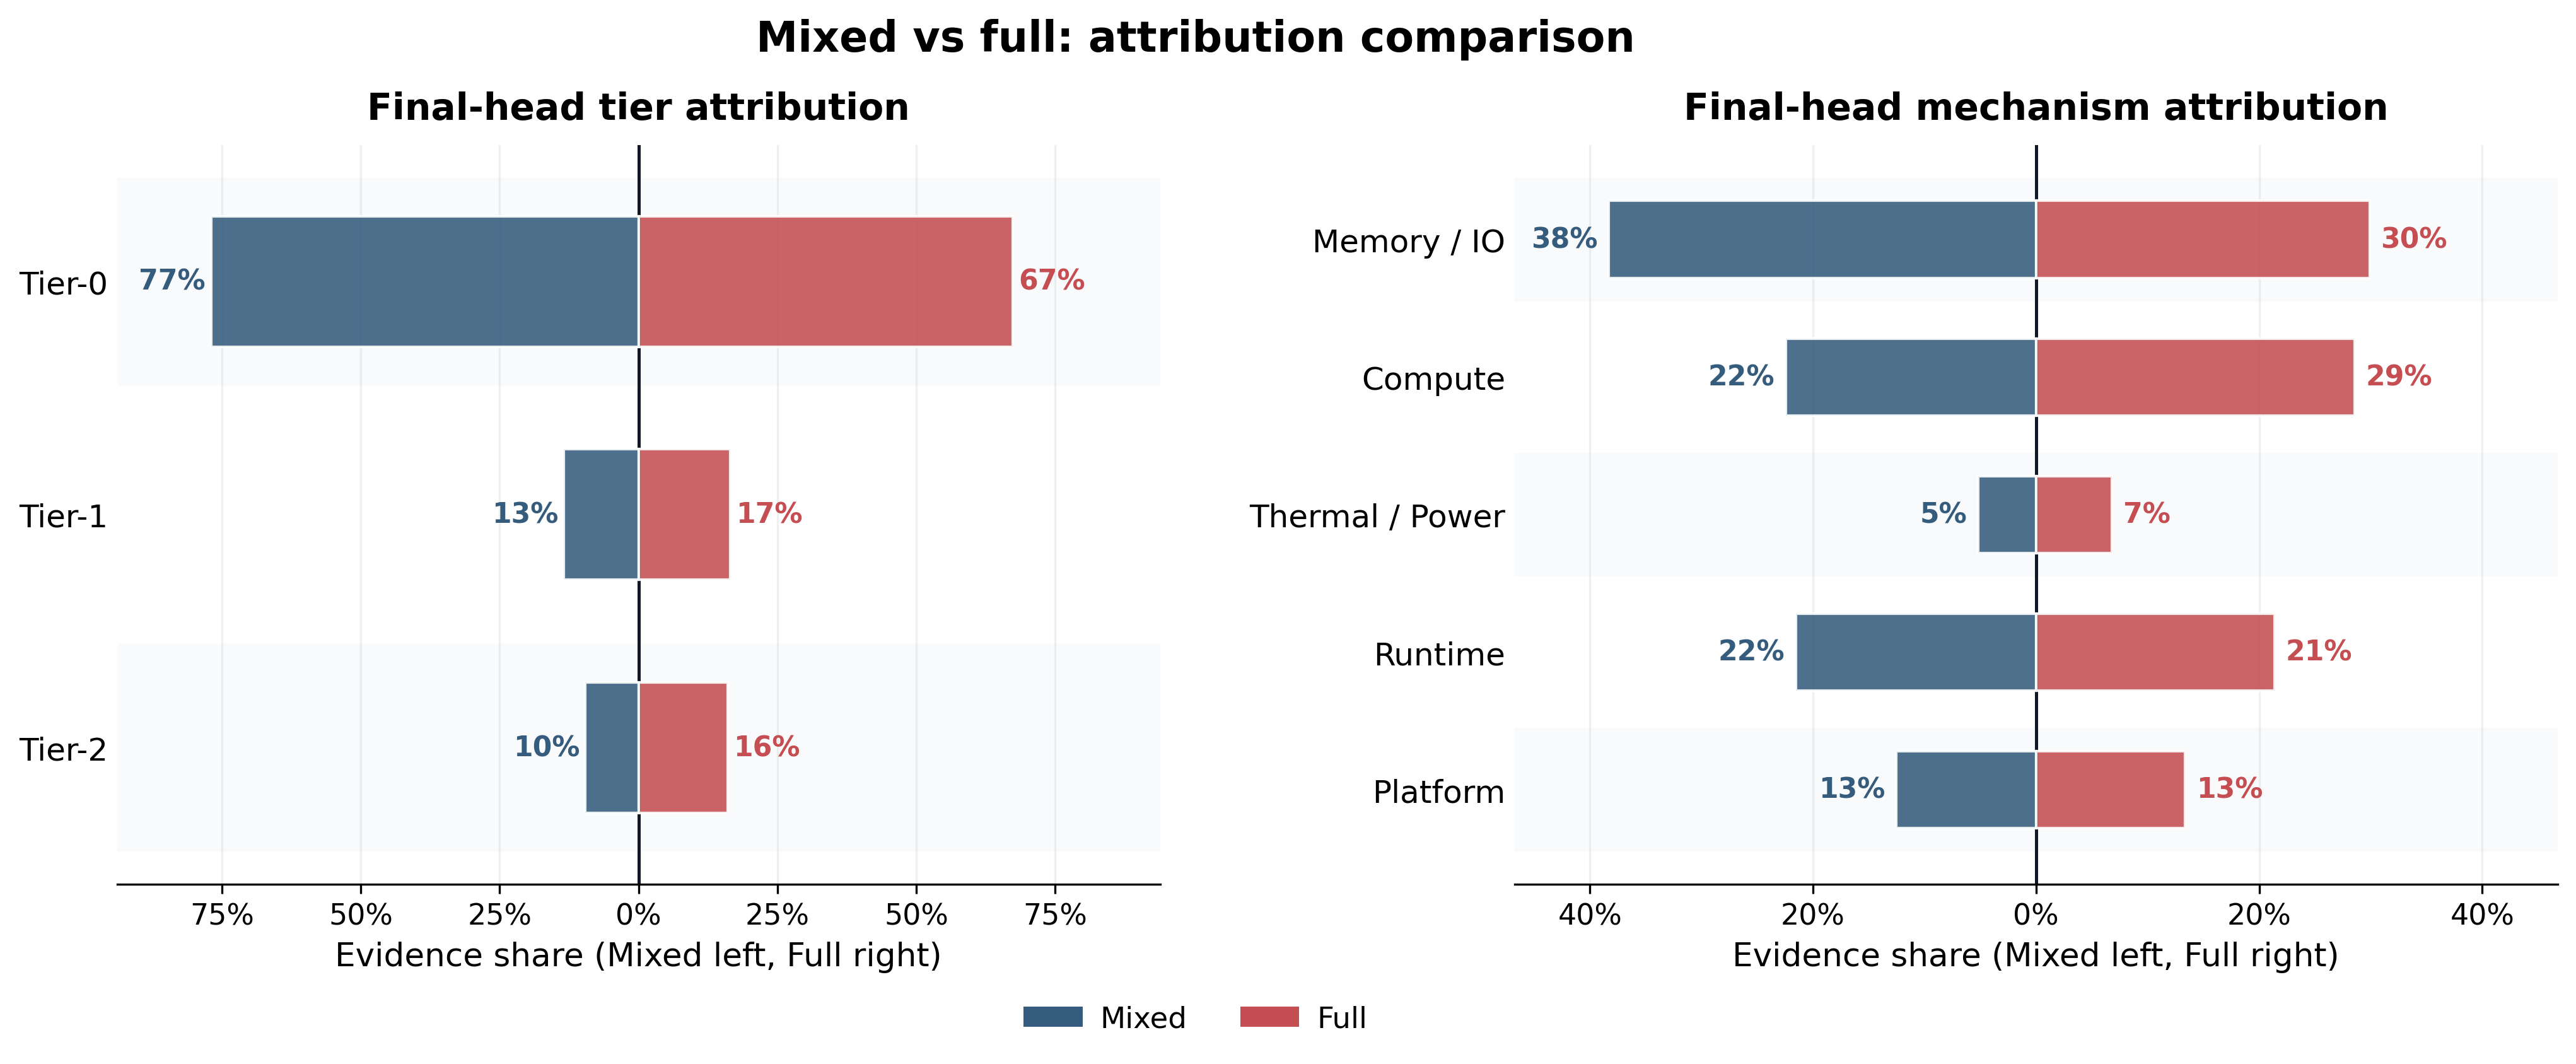

In [103]:
display(Markdown('### Attribution comparison figures'))

from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

tier_csv = COMPARISON_DIR / 'tier_attribution_profiles.csv'
mechanism_csv = COMPARISON_DIR / 'mechanism_attribution_profiles.csv'
attrib_png = COMPARISON_FIG / 'fig_attribution_profile_comparison.png'

if not tier_csv.exists() or not mechanism_csv.exists():
    display(Markdown('Run the attribution-summary cell first so the comparison CSVs exist.'))
else:
    tier_summary = pd.read_csv(tier_csv)
    mechanism_summary = pd.read_csv(mechanism_csv)

    final_tier = tier_summary[tier_summary['config'] == FINAL_CONFIG].copy()
    final_mech = mechanism_summary[mechanism_summary['config'] == FINAL_CONFIG].copy()

    profiles_present = set(pd.concat([
        final_tier['feature_profile'],
        final_mech['feature_profile'],
    ], ignore_index=True).dropna().astype(str))

    profiles = [p for p in PROFILE_ORDER if p in profiles_present]

    if not profiles:
        display(Markdown(f'No attribution rows were found for final config `{FINAL_CONFIG}`.'))
    else:
        tier_specs = [
            ('tier0_share', 'Tier-0'),
            ('tier1_alt_share', 'Tier-1'),
            ('tier2_share', 'Tier-2'),
        ]
        mech_specs = [
            ('memory_io_share', 'Memory / IO'),
            ('compute_share', 'Compute'),
            ('thermal_power_share', 'Thermal / Power'),
            ('scheduler_runtime_share', 'Runtime'),
            ('platform_pressure_share', 'Platform'),
        ]

        profile_colors = {
            p: PROFILE_COLOR.get(p, '#334155')
            for p in profiles
        }
        profile_labels = {
            p: PROFILE_LABEL.get(p, p.title())
            for p in profiles
        }

        def plot_butterfly(ax, df, specs, title):
            present_specs = [(col, label) for col, label in specs if col in df.columns]
            if not present_specs:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_axis_off()
                return

            labels = [label for _, label in present_specs]
            y = np.arange(len(labels), dtype=float)

            for yi in y:
                if int(yi) % 2 == 0:
                    ax.axhspan(yi - 0.44, yi + 0.44, color='#F8FAFC', zorder=0)

            profile_vals = {}
            for profile in profiles:
                row = df[df['feature_profile'] == profile]
                vals = []
                for col, _ in present_specs:
                    if row.empty or col not in row.columns or pd.isna(row.iloc[0][col]):
                        vals.append(np.nan)
                    else:
                        vals.append(float(row.iloc[0][col]))
                profile_vals[profile] = np.asarray(vals, dtype=float)

            finite_vals = []
            for vals in profile_vals.values():
                finite_vals.extend(np.abs(vals[np.isfinite(vals)]).tolist())
            max_val = max(finite_vals) if finite_vals else 0.05
            max_val = max(max_val, 0.05)
            pad = max(0.04, 0.22 * max_val)

            if len(profiles) >= 2:
                left_profile, right_profile = profiles[:2]
                left_vals = -np.nan_to_num(profile_vals[left_profile], nan=0.0)
                right_vals = np.nan_to_num(profile_vals[right_profile], nan=0.0)

                left_fill = left_vals
                right_fill = right_vals

                ax.barh(
                    y,
                    left_fill,
                    height=0.56,
                    color=profile_colors[left_profile],
                    alpha=0.88,
                    edgecolor='white',
                    linewidth=1.0,
                    zorder=3,
                )
                ax.barh(
                    y,
                    right_fill,
                    height=0.56,
                    color=profile_colors[right_profile],
                    alpha=0.88,
                    edgecolor='white',
                    linewidth=1.0,
                    zorder=3,
                )

                ax.axvline(0.0, color='#111827', linewidth=1.2, zorder=2)

                for yi, val in zip(y, left_vals):
                    if val != 0:
                        ax.text(
                            val - 0.01,
                            yi,
                            f'{abs(val):.0%}',
                            ha='right',
                            va='center',
                            fontsize=10.6,
                            fontweight='bold',
                            color=profile_colors[left_profile],
                        )

                for yi, val in zip(y, right_vals):
                    if val != 0:
                        ax.text(
                            val + 0.01,
                            yi,
                            f'{abs(val):.0%}',
                            ha='left',
                            va='center',
                            fontsize=10.6,
                            fontweight='bold',
                            color=profile_colors[right_profile],
                        )

                ax.set_xlim(-(max_val + pad), max_val + pad)
                ax.set_xlabel(
                    f'Evidence share ({profile_labels[left_profile]} left, {profile_labels[right_profile]} right)',
                    fontsize=12.4,
                )
            else:
                only_profile = profiles[0]
                vals = np.nan_to_num(profile_vals[only_profile], nan=0.0)

                ax.barh(
                    y,
                    vals,
                    height=0.56,
                    color=profile_colors[only_profile],
                    alpha=0.88,
                    edgecolor='white',
                    linewidth=1.0,
                    zorder=3,
                )

                for yi, val in zip(y, vals):
                    if val != 0:
                        ax.text(
                            val + 0.01,
                            yi,
                            f'{val:.0%}',
                            ha='left',
                            va='center',
                            fontsize=10.6,
                            fontweight='bold',
                            color=profile_colors[only_profile],
                        )

                ax.set_xlim(0.0, max_val + pad)
                ax.set_xlabel('Mean anomaly evidence share', fontsize=12.4)

            ax.set_yticks(y)
            ax.set_yticklabels(labels, fontsize=12.0)
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.18)
            ax.tick_params(axis='x', labelsize=11.0)
            ax.tick_params(axis='y', length=0)
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{abs(x):.0%}'))
            ax.set_title(title, fontsize=14.0, fontweight='bold', pad=10)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15.0, 6.1),
            constrained_layout=False,
        )

        plot_butterfly(axes[0], final_tier, tier_specs, 'Final-head tier attribution')
        plot_butterfly(axes[1], final_mech, mech_specs, 'Final-head mechanism attribution')

        legend_handles = [
            Patch(facecolor=profile_colors[p], edgecolor='none', label=profile_labels[p])
            for p in profiles
        ]

        fig.subplots_adjust(left=0.12, right=0.98, top=0.84, bottom=0.20, wspace=0.34)

        fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.04),
            ncol=max(1, len(legend_handles)),
            frameon=False,
            fontsize=11.2,
            columnspacing=1.8,
            handletextpad=0.6,
        )

        fig.suptitle('Mixed vs full: attribution comparison', fontsize=16.0, fontweight='bold', y=0.95)
        fig.savefig(attrib_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        display(Image(filename=str(attrib_png)))



## 10. Residual Evidence Concentration

This section shows how much anomaly evidence is captured by the top residual contributors.


In [110]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

display(Markdown('### Evidence concentration tables'))

evidence_csv = COMPARISON_DIR / 'residual_evidence_concentration_profiles.csv'
stressor_evidence_csv = COMPARISON_DIR / 'stressor_residual_evidence_concentration_profiles.csv'

profile_order = list(globals().get('PROFILE_ORDER', ['mixed', 'full']))


def resolve_evidence_profiles():
    ready = []
    missing = {}

    for profile in profile_order:
        profile_missing = []
        gdir = profile_global_dir(profile)

        if not (gdir / 'case_diagnosis_summary.csv').exists():
            profile_missing.append('global/case_diagnosis_summary.csv')

        if profile_missing:
            missing[profile] = profile_missing
        else:
            ready.append(profile)

    return ready, missing


def render_missing_profiles(missing):
    helper = globals().get('markdown_missing_profiles', None)
    if callable(helper):
        return helper(missing)

    lines = ['Missing bundles:']
    for profile, items in missing.items():
        joined = ', '.join(f'`{x}`' for x in items)
        lines.append(f'- `{profile}`: {joined}')
    return '\n'.join(lines)


ready_profiles, missing_profiles = resolve_evidence_profiles()

if not ready_profiles:
    display(Markdown('No diagnosis bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(render_missing_profiles(missing_profiles)))
else:
    evidence_rows = []
    stressor_rows = []

    mech_cols = [
        'compute_contrib',
        'memory_io_contrib',
        'thermal_power_contrib',
        'scheduler_runtime_contrib',
        'platform_pressure_contrib',
    ]

    for profile in ready_profiles:
        case_diag = read_profile_csv(profile, 'global', 'case_diagnosis_summary.csv')
        anom_diag = case_diag[case_diag['label'] == 1].copy()
        if anom_diag.empty:
            continue

        contrib_cols = [c for c in mech_cols if c in anom_diag.columns]
        if not contrib_cols:
            continue

        anom_diag['total_evidence'] = anom_diag[contrib_cols].sum(axis=1).replace(0.0, np.nan)

        for k in range(1, 6):
            cols = [c for c in [f'top_feature_score_{i}' for i in range(1, k + 1)] if c in anom_diag.columns]
            if cols:
                anom_diag[f'feature_top{k}_coverage'] = anom_diag[cols].sum(axis=1) / anom_diag['total_evidence']
            else:
                anom_diag[f'feature_top{k}_coverage'] = np.nan

        for k in range(1, 4):
            cols = [c for c in [f'top_mechanism_score_{i}' for i in range(1, k + 1)] if c in anom_diag.columns]
            if cols:
                anom_diag[f'mechanism_top{k}_coverage'] = anom_diag[cols].sum(axis=1) / anom_diag['total_evidence']
            else:
                anom_diag[f'mechanism_top{k}_coverage'] = np.nan

        coverage_cols = [
            'feature_top1_coverage', 'feature_top2_coverage', 'feature_top3_coverage',
            'feature_top4_coverage', 'feature_top5_coverage',
            'mechanism_top1_coverage', 'mechanism_top2_coverage', 'mechanism_top3_coverage',
        ]

        evidence_frontier = (
            anom_diag.groupby('config', sort=False)[coverage_cols]
            .mean()
            .reset_index()
        )
        evidence_frontier['feature_profile'] = profile
        evidence_rows.append(add_profile_and_config_labels(evidence_frontier))

        final_slice = anom_diag[anom_diag['config'] == FINAL_CONFIG].copy()
        if not final_slice.empty:
            stressor_cols = [
                'feature_top1_coverage', 'feature_top3_coverage', 'feature_top5_coverage',
                'mechanism_top1_coverage', 'mechanism_top2_coverage', 'mechanism_top3_coverage',
            ]
            stressor_evidence = (
                final_slice.groupby('stressor', sort=False)[stressor_cols]
                .mean()
                .reset_index()
            )
            stressor_evidence['feature_profile'] = profile
            stressor_rows.append(add_profile_and_config_labels(stressor_evidence))

    if evidence_rows:
        evidence_frontier = sort_profile_config(pd.concat(evidence_rows, ignore_index=True))
        evidence_frontier.to_csv(evidence_csv, index=False)
        display(Markdown('#### Mean evidence concentration by head'))
        display(evidence_frontier.round(4))
    else:
        evidence_frontier = pd.DataFrame()
        display(Markdown('#### Mean evidence concentration by head'))
        display(Markdown('No anomaly evidence-concentration rows were available.'))

    if stressor_rows:
        stressor_evidence = pd.concat(stressor_rows, ignore_index=True)
        stressor_evidence.to_csv(stressor_evidence_csv, index=False)
        display(Markdown('#### Final-head stressor evidence concentration'))
        display(stressor_evidence.round(4))
    else:
        stressor_evidence = pd.DataFrame()
        display(Markdown('#### Final-head stressor evidence concentration'))
        display(Markdown('No final-head stressor evidence rows were available.'))

    if missing_profiles:
        display(Markdown(render_missing_profiles(missing_profiles)))


### Evidence concentration tables

#### Mean evidence concentration by head

,config,feature_top1_coverage,feature_top2_coverage,feature_top3_coverage,feature_top4_coverage,feature_top5_coverage,mechanism_top1_coverage,mechanism_top2_coverage,mechanism_top3_coverage,feature_profile,profile_label,config_label
0,tier0,0.1312,0.1929,0.2516,0.3040,0.3524,0.4935,0.7281,0.8876,mixed,Mixed,Tier-0
1,tier0_tier1,0.1393,0.2170,0.2719,0.3202,0.3637,0.4746,0.7000,0.8417,mixed,Mixed,Tier-0/1
2,tier0_tier1_tier2,0.1280,0.2011,0.2514,0.2964,0.3367,0.4336,0.6618,0.8497,mixed,Mixed,Tier-0/1/2
3,tier0,0.1312,0.1929,0.2516,0.3040,0.3524,0.4935,0.7281,0.8876,full,Full,Tier-0
4,tier0_tier1,0.1064,0.1632,0.2136,0.2572,0.2951,0.3906,0.6399,0.8124,full,Full,Tier-0/1
5,tier0_tier1_tier2,0.1180,0.2018,0.2425,0.2803,0.3151,0.3573,0.6081,0.8084,full,Full,Tier-0/1/2


#### Final-head stressor evidence concentration

,stressor,feature_top1_coverage,feature_top3_coverage,feature_top5_coverage,mechanism_top1_coverage,mechanism_top2_coverage,mechanism_top3_coverage,feature_profile,profile_label
0,ATOMIC,0.1016,0.2104,0.3013,0.3948,0.6427,0.8607,mixed,Mixed
1,BRANCH,0.1245,0.2312,0.3210,0.4244,0.6663,0.8370,mixed,Mixed
2,CACHE,0.1881,0.3885,0.4615,0.5262,0.6980,0.8510,mixed,Mixed
3,MEMBW,0.1279,0.2325,0.3203,0.4413,0.6632,0.8598,mixed,Mixed
4,TLB,0.0982,0.1945,0.2796,0.3812,0.6389,0.8402,mixed,Mixed
5,ATOMIC,0.1060,0.2075,0.2795,0.3046,0.5815,0.7892,full,Full
6,BRANCH,0.1112,0.2330,0.3140,0.3348,0.5897,0.8011,full,Full
7,CACHE,0.1676,0.3488,0.4128,0.4887,0.6967,0.8637,full,Full
8,MEMBW,0.1054,0.2165,0.2898,0.3361,0.5779,0.7960,full,Full
9,TLB,0.0999,0.2068,0.2795,0.3224,0.5947,0.7921,full,Full


### Evidence concentration comparison figure


### Evidence concentration comparison figure

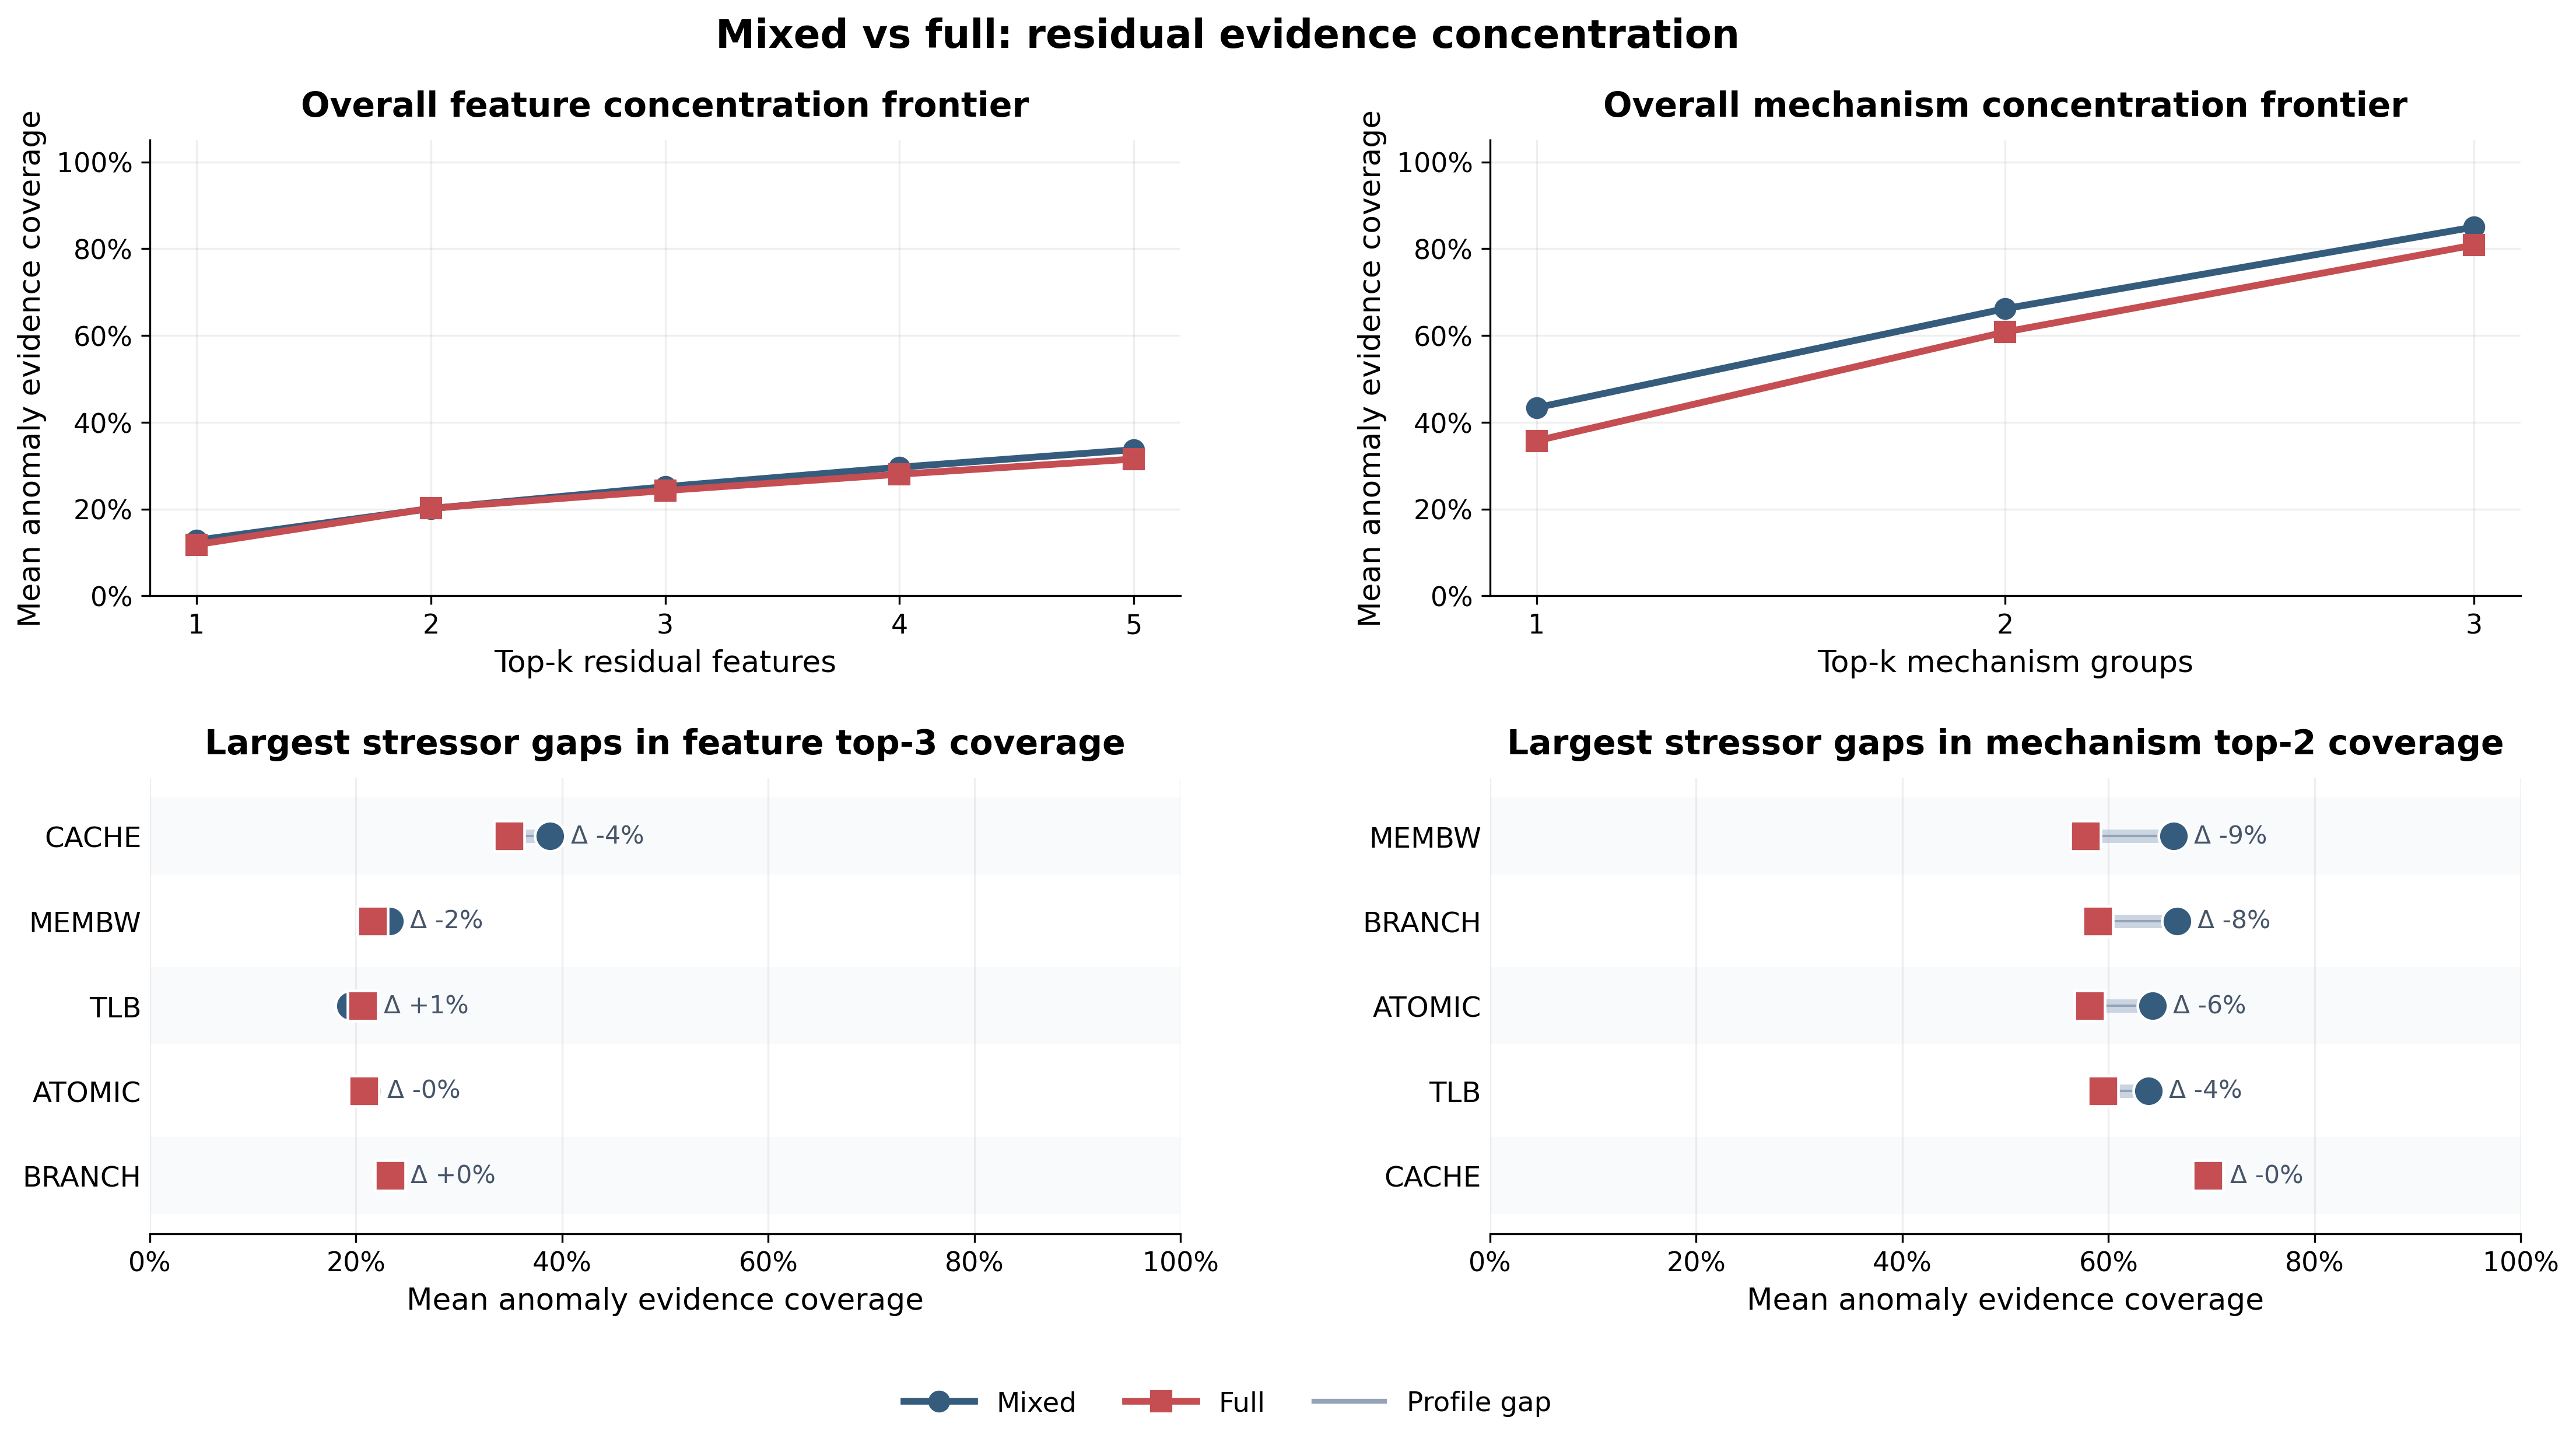

In [113]:
display(Markdown('### Evidence concentration comparison figure'))

from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

evidence_csv = COMPARISON_DIR / 'residual_evidence_concentration_profiles.csv'
evidence_png = COMPARISON_FIG / 'fig_residual_evidence_concentration_profiles.png'

if not evidence_csv.exists():
    display(Markdown('Run the evidence-concentration cell first so the comparison CSV exists.'))
else:
    evidence = pd.read_csv(evidence_csv)
    final_head = evidence[evidence['config'] == FINAL_CONFIG].copy()

    profile_order = list(globals().get('PROFILE_ORDER', ['mixed', 'full']))
    profile_label_map = globals().get('PROFILE_LABEL', {'mixed': 'Mixed', 'full': 'Full'})
    profile_color_map = globals().get('PROFILE_COLOR', {'mixed': '#355C7D', 'full': '#C44E52'})
    profile_marker_map = globals().get('PROFILE_MARKER', {'mixed': 'o', 'full': 's'})
    stressor_order = ['ATOMIC', 'BRANCH', 'CACHE', 'MEMBW', 'TLB']

    profiles = [p for p in profile_order if p in set(final_head['feature_profile'])]

    if not profiles:
        display(Markdown(f'No evidence-concentration rows were found for final config `{FINAL_CONFIG}`.'))
    else:
        stressor_rows = []
        mech_cols = [
            'compute_contrib',
            'memory_io_contrib',
            'thermal_power_contrib',
            'scheduler_runtime_contrib',
            'platform_pressure_contrib',
        ]

        for profile in profiles:
            try:
                case_diag = read_profile_csv(profile, 'global', 'case_diagnosis_summary.csv')
            except Exception:
                continue

            anom_diag = case_diag[
                (case_diag['label'] == 1) &
                (case_diag['config'] == FINAL_CONFIG)
            ].copy()
            if anom_diag.empty:
                continue

            contrib_cols = [c for c in mech_cols if c in anom_diag.columns]
            if not contrib_cols:
                continue

            anom_diag['total_evidence'] = anom_diag[contrib_cols].sum(axis=1).replace(0.0, np.nan)

            for k in range(1, 6):
                cols = [c for c in [f'top_feature_score_{i}' for i in range(1, k + 1)] if c in anom_diag.columns]
                anom_diag[f'feature_top{k}_coverage'] = (
                    anom_diag[cols].sum(axis=1) / anom_diag['total_evidence']
                    if cols else np.nan
                )

            for k in range(1, 4):
                cols = [c for c in [f'top_mechanism_score_{i}' for i in range(1, k + 1)] if c in anom_diag.columns]
                anom_diag[f'mechanism_top{k}_coverage'] = (
                    anom_diag[cols].sum(axis=1) / anom_diag['total_evidence']
                    if cols else np.nan
                )

            stressor_summary = (
                anom_diag.groupby('stressor', sort=False)[[
                    'feature_top1_coverage',
                    'feature_top3_coverage',
                    'feature_top5_coverage',
                    'mechanism_top1_coverage',
                    'mechanism_top2_coverage',
                    'mechanism_top3_coverage',
                ]]
                .mean()
                .reset_index()
            )
            stressor_summary['feature_profile'] = profile
            stressor_rows.append(stressor_summary)

        stressor_evidence = (
            pd.concat(stressor_rows, ignore_index=True)
            if stressor_rows else pd.DataFrame()
        )

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(15.4, 8.8),
            constrained_layout=False,
        )

        ax_feat = axes[0, 0]
        ax_mech = axes[0, 1]
        ax_stress_feat = axes[1, 0]
        ax_stress_mech = axes[1, 1]

        fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.17, hspace=0.40, wspace=0.30)

        # Top-left: feature concentration frontier
        for profile in profiles:
            row = final_head[final_head['feature_profile'] == profile]
            if row.empty:
                continue
            row = row.iloc[0]
            vals = [float(row.get(f'feature_top{k}_coverage', np.nan)) for k in range(1, 6)]
            ax_feat.plot(
                range(1, 6),
                vals,
                marker=profile_marker_map.get(profile, 'o'),
                markersize=8,
                linewidth=2.8,
                color=profile_color_map.get(profile, '#334155'),
                label=profile_label_map.get(profile, profile),
            )

        ax_feat.set_xlabel('Top-k residual features', fontsize=12.4)
        ax_feat.set_ylabel('Mean anomaly evidence coverage', fontsize=12.4)
        ax_feat.set_xticks(range(1, 6))
        ax_feat.set_ylim(0.0, 1.05)
        ax_feat.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax_feat.set_title('Overall feature concentration frontier', fontsize=14.0, fontweight='bold', pad=10)
        ax_feat.grid(alpha=0.20)
        ax_feat.tick_params(labelsize=11.0)
        ax_feat.spines['top'].set_visible(False)
        ax_feat.spines['right'].set_visible(False)

        # Top-right: mechanism concentration frontier
        for profile in profiles:
            row = final_head[final_head['feature_profile'] == profile]
            if row.empty:
                continue
            row = row.iloc[0]
            vals = [float(row.get(f'mechanism_top{k}_coverage', np.nan)) for k in range(1, 4)]
            ax_mech.plot(
                range(1, 4),
                vals,
                marker=profile_marker_map.get(profile, 'o'),
                markersize=8,
                linewidth=2.8,
                color=profile_color_map.get(profile, '#334155'),
                label=profile_label_map.get(profile, profile),
            )

        ax_mech.set_xlabel('Top-k mechanism groups', fontsize=12.4)
        ax_mech.set_ylabel('Mean anomaly evidence coverage', fontsize=12.4)
        ax_mech.set_xticks(range(1, 4))
        ax_mech.set_ylim(0.0, 1.05)
        ax_mech.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        ax_mech.set_title('Overall mechanism concentration frontier', fontsize=14.0, fontweight='bold', pad=10)
        ax_mech.grid(alpha=0.20)
        ax_mech.tick_params(labelsize=11.0)
        ax_mech.spines['top'].set_visible(False)
        ax_mech.spines['right'].set_visible(False)

        def plot_gap_lollipops(ax, df, metric_col, title):
            if df.empty or metric_col not in df.columns or len(profiles) < 2:
                ax.text(0.5, 0.5, 'No stressor gap breakdown available', ha='center', va='center', transform=ax.transAxes, fontsize=11.5)
                ax.set_axis_off()
                return

            left_profile, right_profile = profiles[:2]

            rows = []
            for stressor in stressor_order:
                left_hit = df[(df['feature_profile'] == left_profile) & (df['stressor'] == stressor)]
                right_hit = df[(df['feature_profile'] == right_profile) & (df['stressor'] == stressor)]
                if left_hit.empty or right_hit.empty:
                    continue

                left_val = float(left_hit.iloc[0][metric_col])
                right_val = float(right_hit.iloc[0][metric_col])

                rows.append(
                    {
                        'stressor': stressor,
                        'left_val': left_val,
                        'right_val': right_val,
                        'gap': right_val - left_val,
                        'gap_abs': abs(right_val - left_val),
                    }
                )

            plot_df = pd.DataFrame(rows)
            if plot_df.empty:
                ax.text(0.5, 0.5, 'No stressor gap breakdown available', ha='center', va='center', transform=ax.transAxes, fontsize=11.5)
                ax.set_axis_off()
                return

            plot_df = plot_df.sort_values(['gap_abs', 'stressor'], ascending=[False, True]).reset_index(drop=True)
            y = np.arange(len(plot_df), dtype=float)

            for yi in y:
                if int(yi) % 2 == 0:
                    ax.axhspan(yi - 0.44, yi + 0.44, color='#F8FAFC', zorder=0)

            for yi, row in zip(y, plot_df.itertuples(index=False)):
                ax.plot(
                    [row.left_val, row.right_val],
                    [yi, yi],
                    color='#CBD5E1',
                    linewidth=5.5,
                    solid_capstyle='round',
                    zorder=1,
                )
                ax.plot(
                    [row.left_val, row.right_val],
                    [yi, yi],
                    color='#94A3B8',
                    linewidth=1.0,
                    solid_capstyle='round',
                    zorder=1.1,
                )

                ax.scatter(
                    [row.left_val],
                    [yi],
                    s=155,
                    color=profile_color_map.get(left_profile, '#334155'),
                    marker=profile_marker_map.get(left_profile, 'o'),
                    edgecolor='white',
                    linewidth=1.1,
                    zorder=3,
                )
                ax.scatter(
                    [row.right_val],
                    [yi],
                    s=155,
                    color=profile_color_map.get(right_profile, '#334155'),
                    marker=profile_marker_map.get(right_profile, 'o'),
                    edgecolor='white',
                    linewidth=1.1,
                    zorder=3,
                )

                x_text = max(row.left_val, row.right_val) + 0.02
                ax.text(
                    x_text,
                    yi,
                    f'Δ {row.gap:+.0%}',
                    va='center',
                    ha='left',
                    fontsize=10.2,
                    color='#475569',
                )

            ax.set_yticks(y)
            ax.set_yticklabels(plot_df['stressor'], fontsize=11.6)
            ax.invert_yaxis()
            ax.set_xlim(0.0, 1.0)
            ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
            ax.set_xlabel('Mean anomaly evidence coverage', fontsize=12.4)
            ax.set_title(title, fontsize=14.0, fontweight='bold', pad=10)
            ax.grid(axis='x', alpha=0.20)
            ax.tick_params(axis='x', labelsize=11.0)
            ax.tick_params(axis='y', length=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)

        plot_gap_lollipops(
            ax_stress_feat,
            stressor_evidence,
            'feature_top3_coverage',
            'Largest stressor gaps in feature top-3 coverage',
        )
        plot_gap_lollipops(
            ax_stress_mech,
            stressor_evidence,
            'mechanism_top2_coverage',
            'Largest stressor gaps in mechanism top-2 coverage',
        )

        legend_handles = [
            Line2D(
                [0], [0],
                color=profile_color_map.get(p, '#334155'),
                marker=profile_marker_map.get(p, 'o'),
                linewidth=2.8,
                markersize=8,
                label=profile_label_map.get(p, p),
            )
            for p in profiles
        ]

        if len(profiles) >= 2:
            legend_handles.append(
                Line2D(
                    [0], [0],
                    color='#94A3B8',
                    linewidth=2.0,
                    label='Profile gap',
                )
            )

        fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.03),
            ncol=max(2, len(legend_handles)),
            frameon=False,
            fontsize=11.2,
            columnspacing=1.8,
            handlelength=2.6,
        )

        fig.suptitle('Mixed vs full: residual evidence concentration', fontsize=16.2, fontweight='bold', y=0.96)
        fig.savefig(evidence_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        display(Image(filename=str(evidence_png)))




## 11. Uncertainty and Confidence Intervals

This section adds bootstrap confidence intervals for the reported paper metrics.


In [115]:
display(Markdown('### Bootstrap confidence tables'))

from sklearn.metrics import roc_auc_score, average_precision_score

BOOTSTRAP_SAMPLES = 1000
bootstrap_csv = COMPARISON_DIR / 'bootstrap_confidence_profiles.csv'

profile_order = list(globals().get('PROFILE_ORDER', ['mixed', 'full']))
profile_label_map = globals().get('PROFILE_LABEL', {'mixed': 'Mixed', 'full': 'Full'})


def resolve_bootstrap_profiles():
    ready = []
    missing = {}

    for profile in profile_order:
        profile_missing = []
        gdir = profile_global_dir(profile)

        if not (gdir / 'case_predictions.csv').exists():
            profile_missing.append('global/case_predictions.csv')

        if profile_missing:
            missing[profile] = profile_missing
        else:
            ready.append(profile)

    return ready, missing


def render_missing_profiles(missing):
    helper = globals().get('markdown_missing_profiles', None)
    if callable(helper):
        return helper(missing)

    lines = ['Missing bundles:']
    for profile, items in missing.items():
        joined = ', '.join(f'`{x}`' for x in items)
        lines.append(f'- `{profile}`: {joined}')
    return '\n'.join(lines)


ready_profiles, missing_profiles = resolve_bootstrap_profiles()

if not ready_profiles:
    display(Markdown('No case-level prediction bundles are ready yet. Run **Run End-to-End** first.'))
    if missing_profiles:
        display(Markdown(render_missing_profiles(missing_profiles)))
else:
    rng = np.random.default_rng(0)
    rows = []

    for profile in ready_profiles:
        case_pred = read_profile_csv(profile, 'global', 'case_predictions.csv')
        final_df = case_pred[case_pred['config'] == FINAL_CONFIG].copy().reset_index(drop=True)
        if final_df.empty or 'label' not in final_df.columns:
            continue

        y = final_df['label'].to_numpy(dtype=int)

        metric_defs = [
            ('ROC-AUC', 'run_score', roc_auc_score),
            ('AUC-PR', 'run_score', average_precision_score),
            ('ROC-AUC (WC)', 'run_score_wc', roc_auc_score),
            ('AUC-PR (WC)', 'run_score_wc', average_precision_score),
        ]

        for metric_label, score_col, metric_fn in metric_defs:
            if score_col not in final_df.columns:
                continue

            score = final_df[score_col].to_numpy(dtype=float)
            valid = np.isfinite(score)
            y_valid = y[valid]
            score_valid = score[valid]

            if len(score_valid) == 0:
                continue

            samples = []
            for _ in range(BOOTSTRAP_SAMPLES):
                idx = rng.integers(0, len(score_valid), len(score_valid))
                y_boot = y_valid[idx]
                if len(np.unique(y_boot)) < 2:
                    continue
                samples.append(float(metric_fn(y_boot, score_valid[idx])))

            if not samples:
                continue

            samples_arr = np.asarray(samples, dtype=float)
            rows.append({
                'feature_profile': profile,
                'profile_label': profile_label_map.get(profile, profile),
                'metric': metric_label,
                'mean': float(samples_arr.mean()),
                'p05': float(np.quantile(samples_arr, 0.05)),
                'p50': float(np.quantile(samples_arr, 0.50)),
                'p95': float(np.quantile(samples_arr, 0.95)),
                'n_boot_valid': int(len(samples_arr)),
            })

    if not rows:
        display(Markdown('Bootstrap confidence intervals could not be computed yet.'))
    else:
        bootstrap_ci = pd.DataFrame(rows)
        bootstrap_ci.to_csv(bootstrap_csv, index=False)
        display(bootstrap_ci.round(4))

    if missing_profiles:
        display(Markdown(render_missing_profiles(missing_profiles)))



### Bootstrap confidence tables

,feature_profile,profile_label,metric,mean,p05,p50,p95,n_boot_valid
0,mixed,Mixed,ROC-AUC,0.8581,0.6190,0.8750,1.0,987
1,mixed,Mixed,AUC-PR,0.9626,0.8929,0.9676,1.0,985
2,mixed,Mixed,ROC-AUC (WC),1.0000,1.0000,1.0000,1.0,987
3,mixed,Mixed,AUC-PR (WC),1.0000,1.0000,1.0000,1.0,990
4,full,Full,ROC-AUC,0.9742,0.9048,0.9841,1.0,989
5,full,Full,AUC-PR,0.9951,0.9807,0.9974,1.0,983
6,full,Full,ROC-AUC (WC),1.0000,1.0000,1.0000,1.0,985
7,full,Full,AUC-PR (WC),1.0000,1.0000,1.0000,1.0,982


### Bootstrap comparison figure


### Bootstrap comparison figure

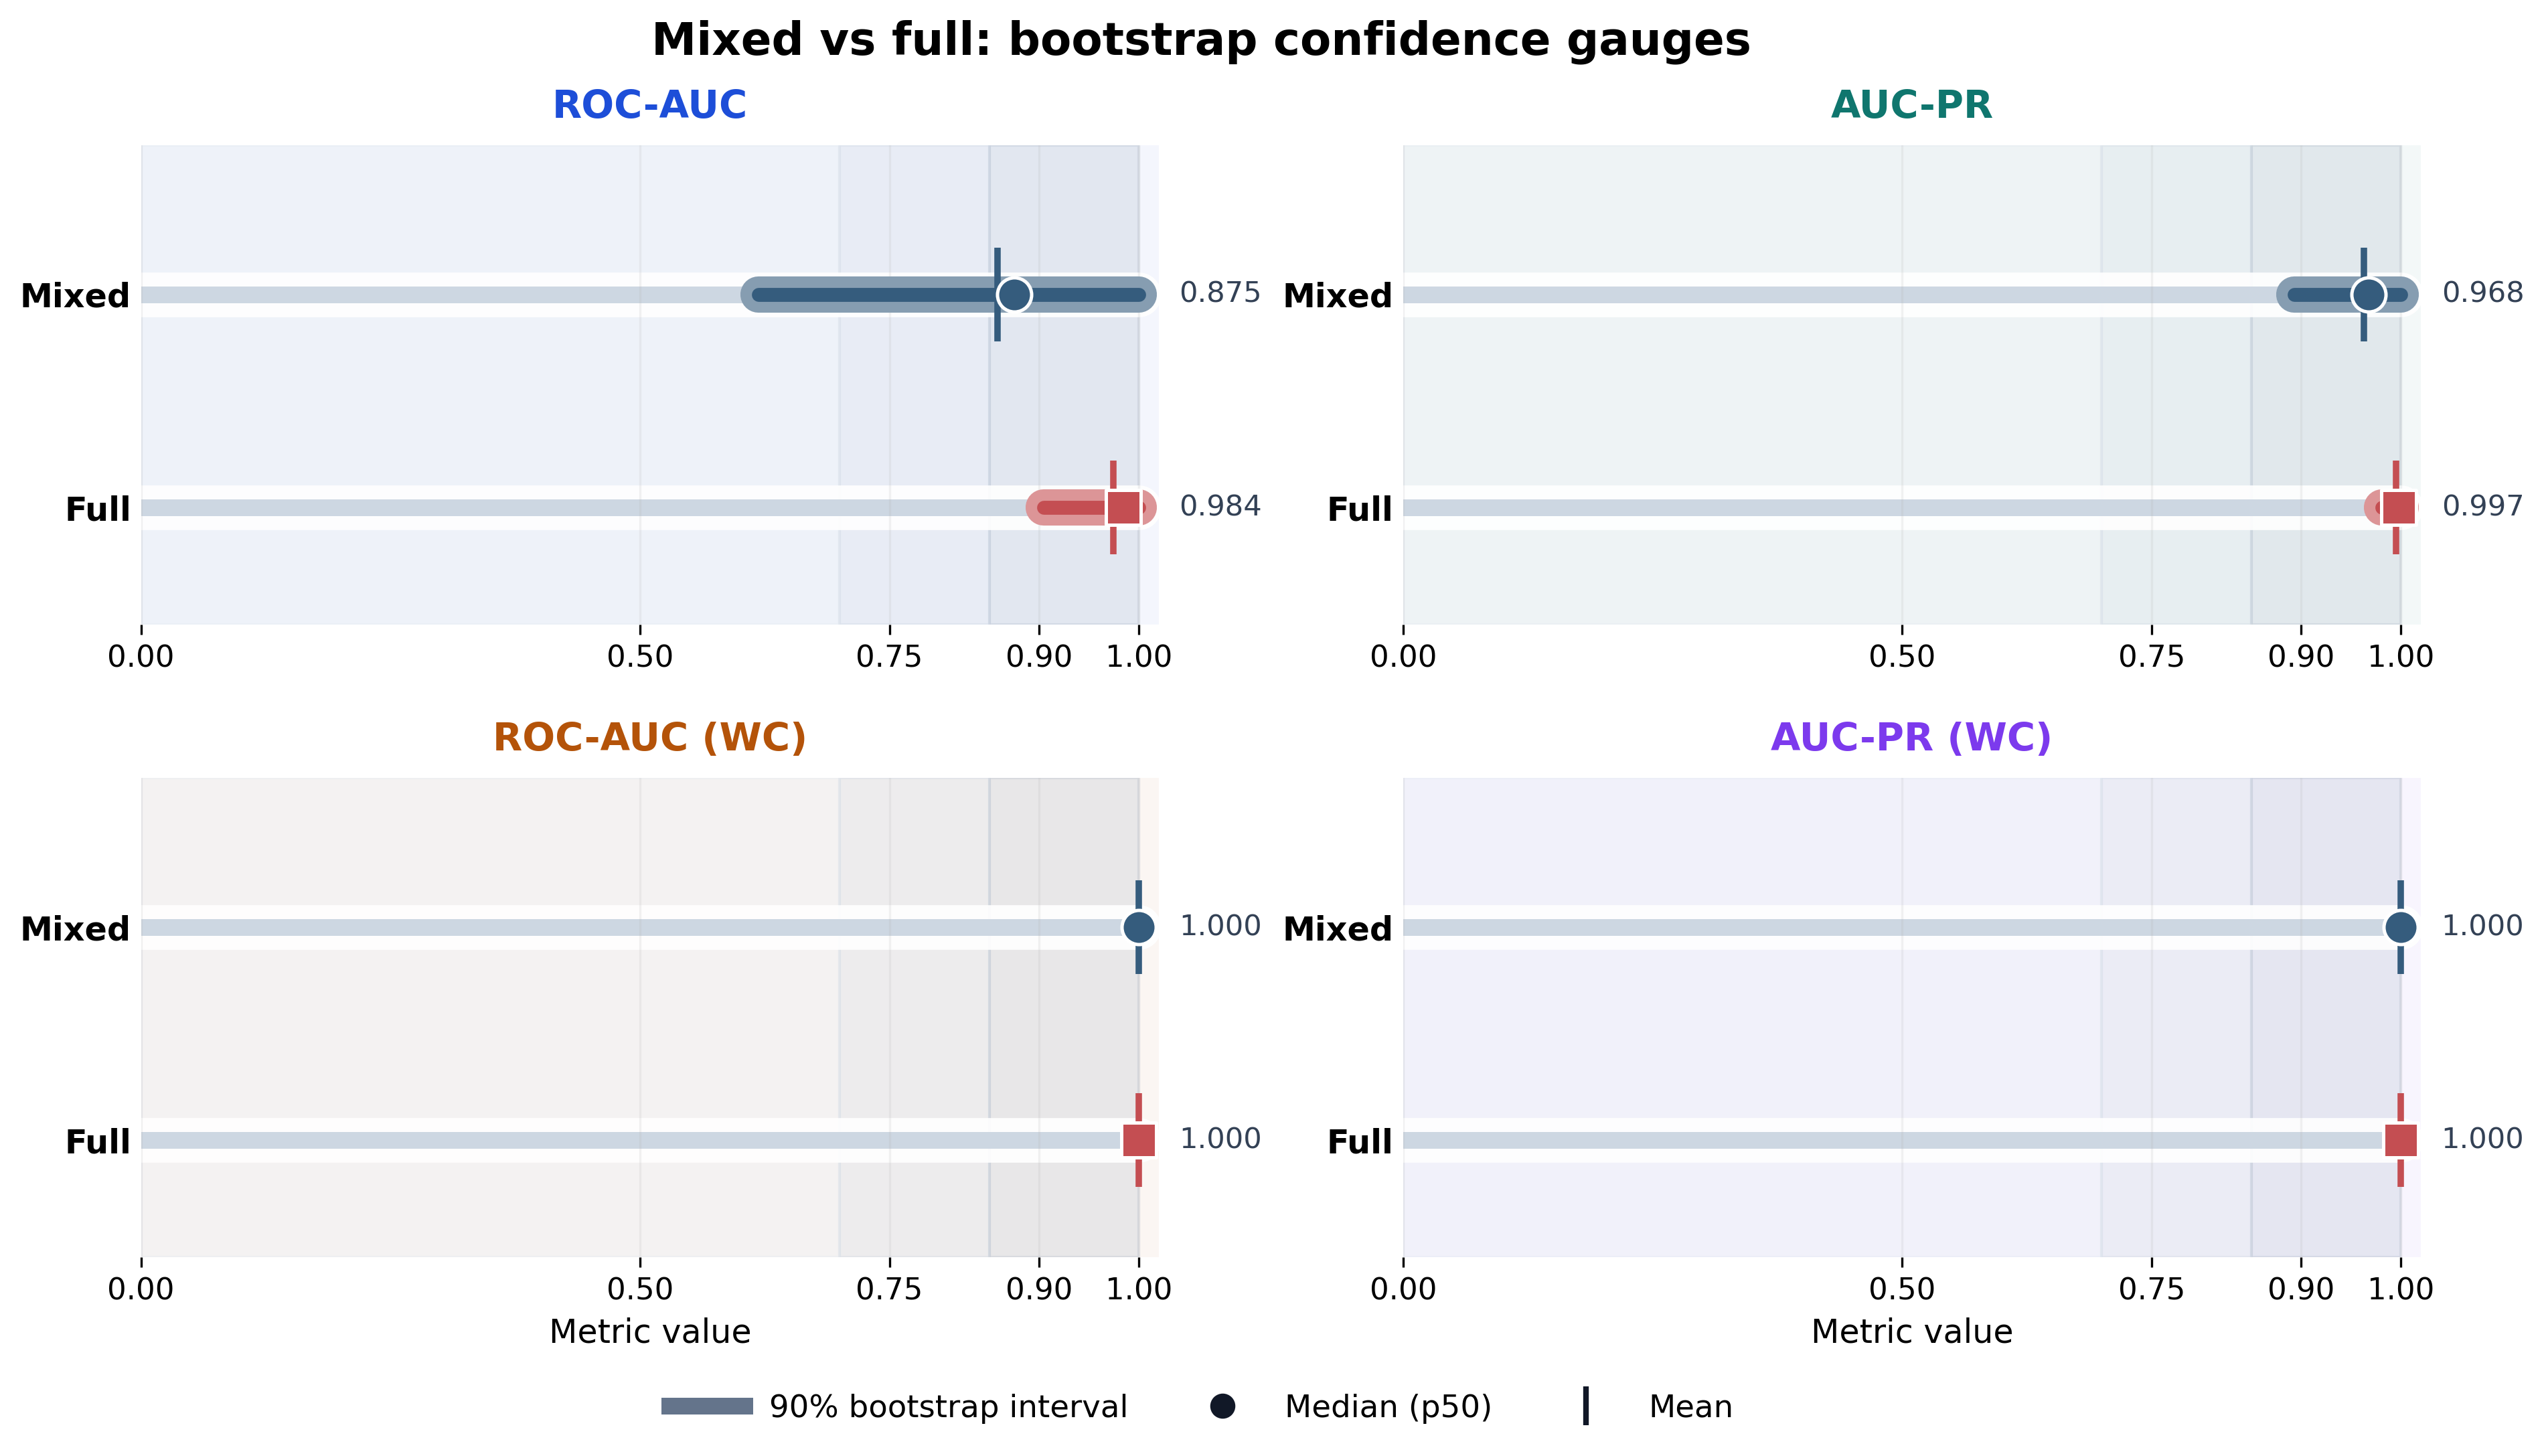

In [116]:
display(Markdown('### Bootstrap comparison figure'))

from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import to_rgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bootstrap_csv = COMPARISON_DIR / 'bootstrap_confidence_profiles.csv'
bootstrap_png = COMPARISON_FIG / 'fig_bootstrap_confidence_profiles.png'

if not bootstrap_csv.exists():
    display(Markdown('Run the bootstrap-summary cell first so the comparison CSV exists.'))
else:
    bootstrap_ci = pd.read_csv(bootstrap_csv)
    metric_order = ['ROC-AUC', 'AUC-PR', 'ROC-AUC (WC)', 'AUC-PR (WC)']
    bootstrap_ci['metric'] = pd.Categorical(bootstrap_ci['metric'], categories=metric_order, ordered=True)
    bootstrap_ci = bootstrap_ci.sort_values(['metric', 'feature_profile']).reset_index(drop=True)

    profiles = [p for p in PROFILE_ORDER if p in set(bootstrap_ci['feature_profile'])]

    if not profiles:
        display(Markdown('No bootstrap confidence rows were available.'))
    else:
        def lighten_color(color, amount):
            rgb = np.array(to_rgb(color), dtype=float)
            white = np.ones(3, dtype=float)
            return tuple(rgb * (1.0 - amount) + white * amount)

        profile_label_map = globals().get('PROFILE_LABEL', {'mixed': 'Mixed', 'full': 'Full'})
        profile_color_map = globals().get('PROFILE_COLOR', {'mixed': '#355C7D', 'full': '#C44E52'})
        profile_marker_map = globals().get('PROFILE_MARKER', {'mixed': 'o', 'full': 's'})

        metric_accent = {
            'ROC-AUC': '#1D4ED8',
            'AUC-PR': '#0F766E',
            'ROC-AUC (WC)': '#B45309',
            'AUC-PR (WC)': '#7C3AED',
        }

        fig, axes = plt.subplots(2, 2, figsize=(13.2, 7.8), constrained_layout=False)
        axes = axes.ravel()
        fig.subplots_adjust(left=0.10, right=0.96, top=0.87, bottom=0.16, wspace=0.24, hspace=0.32)

        for ax, metric in zip(axes, metric_order):
            d = bootstrap_ci[bootstrap_ci['metric'] == metric].copy()
            accent = metric_accent.get(metric, '#334155')

            ax.set_facecolor(lighten_color(accent, 0.95))
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Background gauge bands
            ax.axvspan(0.00, 0.70, color='#E2E8F0', alpha=0.28, zorder=0)
            ax.axvspan(0.70, 0.85, color='#CBD5E1', alpha=0.28, zorder=0)
            ax.axvspan(0.85, 1.00, color='#94A3B8', alpha=0.18, zorder=0)

            y_positions = np.arange(len(profiles), dtype=float)[::-1]
            ax.set_ylim(-0.55, len(profiles) - 0.30)
            ax.set_xlim(0.0, 1.02)
            ax.set_yticks(y_positions)
            ax.set_yticklabels([profile_label_map.get(p, p) for p in profiles], fontsize=11.8, fontweight='bold')
            ax.set_xticks([0.0, 0.5, 0.75, 0.9, 1.0])
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            ax.tick_params(axis='x', labelsize=10.8)
            ax.tick_params(axis='y', length=0)
            ax.grid(axis='x', alpha=0.16)

            for yi in y_positions:
                ax.plot([0.0, 1.0], [yi, yi], color='white', linewidth=16, solid_capstyle='round', alpha=0.92, zorder=1)
                ax.plot([0.0, 1.0], [yi, yi], color='#CBD5E1', linewidth=6, solid_capstyle='round', alpha=0.95, zorder=1.1)

            for yi, profile in zip(y_positions, profiles):
                row = d[d['feature_profile'] == profile]
                if row.empty:
                    continue
                row = row.iloc[0]

                color = profile_color_map.get(profile, '#334155')
                marker = profile_marker_map.get(profile, 'o')
                p05 = float(row['p05'])
                p50 = float(row['p50'])
                p95 = float(row['p95'])
                mean = float(row['mean'])

                ax.plot(
                    [p05, p95],
                    [yi, yi],
                    color=lighten_color(color, 0.40),
                    linewidth=13,
                    solid_capstyle='round',
                    zorder=2,
                )
                ax.plot(
                    [p05, p95],
                    [yi, yi],
                    color=color,
                    linewidth=5.0,
                    solid_capstyle='round',
                    zorder=3,
                )

                ax.vlines(
                    mean,
                    yi - 0.22,
                    yi + 0.22,
                    colors=color,
                    linewidth=2.3,
                    zorder=4,
                )

                ax.scatter(
                    [p50],
                    [yi],
                    s=150,
                    color=color,
                    marker=marker,
                    edgecolor='white',
                    linewidth=1.2,
                    zorder=5,
                )

                ax.text(
                    1.02,
                    yi,
                    f'{p50:.3f}',
                    ha='left',
                    va='center',
                    fontsize=10.4,
                    color='#334155',
                    transform=ax.get_yaxis_transform(),
                    clip_on=False,
                )

            ax.set_title(metric, fontsize=13.8, fontweight='bold', color=accent, pad=10)
            if metric in ['ROC-AUC (WC)', 'AUC-PR (WC)']:
                ax.set_xlabel('Metric value', fontsize=11.8)

        legend_handles = [
            Line2D([0], [0], color='#64748B', linewidth=6, label='90% bootstrap interval'),
            Line2D([0], [0], color='#111827', marker='o', linestyle='None', markersize=8, label='Median (p50)'),
            Line2D([0], [0], color='#111827', marker='|', linestyle='None', markersize=14, markeredgewidth=2.0, label='Mean'),
        ]

        fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.03),
            ncol=3,
            frameon=False,
            fontsize=11.2,
            columnspacing=1.8,
            handlelength=2.4,
        )

        fig.suptitle('Mixed vs full: bootstrap confidence gauges', fontsize=16.2, fontweight='bold', y=0.95)
        fig.savefig(bootstrap_png, dpi=PRO_FIG_DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        display(Image(filename=str(bootstrap_png)))



## 12. Paper-Ready Figure Bundle

This section assembles the reviewer-facing figures used in the main paper and appendix.


In [108]:
display(Markdown('### Paper-ready bundle summary'))

bundle_csv = COMPARISON_DIR / 'paper_ready_bundle_summary.csv'
rows = []
for profile in PROFILE_ORDER:
    rows.append({
        'feature_profile': profile,
        'profile_label': PROFILE_LABEL[profile],
        'global_dir_exists': int(profile_global_dir(profile).exists()),
        'holdout_dir_exists': int(profile_holdout_dir(profile).exists()),
        'paper_dir_exists': int(profile_paper_dir(profile).exists()),
        'overall_metrics_exists': int((profile_global_dir(profile) / 'overall_metrics.csv').exists()),
        'holdout_summary_exists': int((profile_holdout_dir(profile) / 'holdout_robustness_summary.csv').exists()),
        'two_stage_exists': int((profile_paper_dir(profile) / 'two_stage_dice_summary.csv').exists()),
        'feature_budget_exists': int((profile_paper_dir(profile) / 'dse_feature_budget_summary.csv').exists()),
        'reliability_exists': int((profile_paper_dir(profile) / 'conformal_reliability_summary.csv').exists()),
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(bundle_csv, index=False)
display(summary_df)


### Paper-ready bundle summary

,feature_profile,profile_label,global_dir_exists,holdout_dir_exists,paper_dir_exists,overall_metrics_exists,holdout_summary_exists,two_stage_exists,feature_budget_exists,reliability_exists
0,mixed,Mixed,1,1,1,1,1,1,1,1
1,full,Full,1,1,1,1,1,1,1,1


## 12B. Abstract-Ready Metric Summary

This section collects the smallest paper-safe set of headline numbers for the abstract.


In [117]:
display(Markdown("### Abstract-ready metrics"))

ABSTRACT_FINAL_CONFIG = 'tier0_tier1_tier2'
ABSTRACT_DIR = PAPER_FULL
ABSTRACT_DIR.mkdir(parents=True, exist_ok=True)


def _profile_dirs(profile: str) -> tuple[Path, Path]:
    return (
        default_full_out_dir(DATASET_ROOT, 'global', profile),
        default_full_out_dir(DATASET_ROOT, 'workload_holdout', profile),
    )


def _metric_or_nan(row: pd.Series, key: str) -> float:
    if key not in row.index or pd.isna(row[key]):
        return float('nan')
    return float(row[key])


def _load_abstract_row(profile: str) -> dict[str, object] | None:
    global_dir, holdout_dir = _profile_dirs(profile)
    needed = [
        global_dir / 'overall_metrics.csv',
        holdout_dir / 'holdout_robustness_summary.csv',
    ]
    if any(not p.exists() for p in needed):
        return None

    overall = pd.read_csv(global_dir / 'overall_metrics.csv')
    holdout = pd.read_csv(holdout_dir / 'holdout_robustness_summary.csv')

    overall_row = overall.loc[overall['config'] == ABSTRACT_FINAL_CONFIG].iloc[0]
    holdout_row = holdout.loc[holdout['config'] == ABSTRACT_FINAL_CONFIG].iloc[0]

    runtime_s = float('nan')
    invocation_path = global_dir / 'notebook_invocation.json'
    runtime_path = global_dir / 'config_runtime_summary.csv'
    if invocation_path.exists():
        runtime_s = float(json.loads(invocation_path.read_text()).get('elapsed_s', float('nan')))
    elif runtime_path.exists():
        runtime_df = pd.read_csv(runtime_path)
        runtime_row = runtime_df.loc[runtime_df['config'] == ABSTRACT_FINAL_CONFIG]
        if not runtime_row.empty:
            runtime_s = float(runtime_row['fit_eval_seconds'].iloc[0])

    return {
        'feature_profile': profile,
        'global_dir': str(global_dir),
        'holdout_dir': str(holdout_dir),
        'base_roc_auc': float(overall_row['roc_auc']),
        'base_pr_auc': float(overall_row['pr_auc']),
        'wc_roc_auc': float(overall_row['roc_auc_wc']),
        'wc_pr_auc': float(overall_row['pr_auc_wc']),
        'holdout_mean_pr_auc': _metric_or_nan(holdout_row, 'mean_pr_auc'),
        'holdout_worst_pr_auc': _metric_or_nan(holdout_row, 'worst_pr_auc'),
        'holdout_mean_roc_auc': _metric_or_nan(holdout_row, 'mean_roc_auc'),
        'holdout_mean_pr_auc_wc': _metric_or_nan(holdout_row, 'mean_pr_auc_wc'),
        'holdout_worst_pr_auc_wc': _metric_or_nan(holdout_row, 'worst_pr_auc_wc'),
        'holdout_mean_roc_auc_wc': _metric_or_nan(holdout_row, 'mean_roc_auc_wc'),
        'pooled_holdout_pr_auc': _metric_or_nan(holdout_row, 'pooled_pr_auc'),
        'pooled_holdout_roc_auc': _metric_or_nan(holdout_row, 'pooled_roc_auc'),
        'pooled_holdout_pr_auc_wc': _metric_or_nan(holdout_row, 'pooled_pr_auc_wc'),
        'pooled_holdout_roc_auc_wc': _metric_or_nan(holdout_row, 'pooled_roc_auc_wc'),
        'runtime_s': runtime_s,
    }


rows = []
for profile_name in ['mixed', 'full']:
    row = _load_abstract_row(profile_name)
    if row is not None:
        rows.append(row)

if not rows:
    display(Markdown(
        'No abstract-ready result bundles were found yet. Run the profile sweep first so both mixed and full bundles are generated.'
    ))
else:
    abstract_df = pd.DataFrame(rows)
    abstract_csv = ABSTRACT_DIR / 'abstract_metrics_summary.csv'
    abstract_df.to_csv(abstract_csv, index=False)

    display_cols = [
        'feature_profile',
        'base_roc_auc',
        'base_pr_auc',
        'holdout_mean_pr_auc',
        'holdout_worst_pr_auc',
        'pooled_holdout_roc_auc',
        'pooled_holdout_pr_auc',
        'holdout_mean_pr_auc_wc',
        'holdout_worst_pr_auc_wc',
        'pooled_holdout_roc_auc_wc',
        'pooled_holdout_pr_auc_wc',
        'runtime_s',
    ]
    present_cols = [col for col in display_cols if col in abstract_df.columns]
    display(abstract_df[present_cols].round(4))

    mixed_row = abstract_df.loc[abstract_df['feature_profile'] == 'mixed'].iloc[0]
    snippet_lines = []
    claim_lines = []

    claim_lines.append(
        f"Detection: mixed-profile ROC-AUC/AUC-PR = {mixed_row['base_roc_auc']:.4f}/{mixed_row['base_pr_auc']:.4f}."
    )
    claim_lines.append(
        f"Holdout (base): mean/worst AUC-PR = {mixed_row['holdout_mean_pr_auc']:.4f}/{mixed_row['holdout_worst_pr_auc']:.4f}; "
        f"pooled ROC-AUC/AUC-PR = {mixed_row['pooled_holdout_roc_auc']:.4f}/{mixed_row['pooled_holdout_pr_auc']:.4f}."
    )
    claim_lines.append(
        f"Holdout (workload-conditioned): mean/worst AUC-PR = {mixed_row['holdout_mean_pr_auc_wc']:.4f}/{mixed_row['holdout_worst_pr_auc_wc']:.4f}; "
        f"pooled ROC-AUC/AUC-PR = {mixed_row['pooled_holdout_roc_auc_wc']:.4f}/{mixed_row['pooled_holdout_pr_auc_wc']:.4f}."
    )

    snippet_lines.append('Detection headline (recommended strict):')
    snippet_lines.append(
        f"On the released trace set, the mixed-profile final head achieves ROC-AUC/AUC-PR of "
        f"{mixed_row['base_roc_auc']:.4f}/{mixed_row['base_pr_auc']:.4f} on the base run score."
    )
    snippet_lines.append('')
    snippet_lines.append('Holdout robustness (strict base score):')
    snippet_lines.append(
        f"Under workload holdout, the same head reaches mean AUC-PR {mixed_row['holdout_mean_pr_auc']:.4f}, "
        f"worst-case AUC-PR {mixed_row['holdout_worst_pr_auc']:.4f}, and pooled ROC-AUC/AUC-PR "
        f"{mixed_row['pooled_holdout_roc_auc']:.4f}/{mixed_row['pooled_holdout_pr_auc']:.4f}."
    )
    snippet_lines.append('')
    snippet_lines.append('Holdout robustness (workload-conditioned option):')
    snippet_lines.append(
        f"With workload-conditioned scoring, the same holdout evaluation reaches mean AUC-PR "
        f"{mixed_row['holdout_mean_pr_auc_wc']:.4f}, worst-case AUC-PR {mixed_row['holdout_worst_pr_auc_wc']:.4f}, "
        f"and pooled ROC-AUC/AUC-PR {mixed_row['pooled_holdout_roc_auc_wc']:.4f}/{mixed_row['pooled_holdout_pr_auc_wc']:.4f}."
    )

    full_row = abstract_df.loc[abstract_df['feature_profile'] == 'full']
    if not full_row.empty:
        full_row = full_row.iloc[0]
        snippet_lines.append('')
        snippet_lines.append('Full-profile upper-bound comparison (use only if it helps):')
        snippet_lines.append(
            f"Switching Tier-1 and Tier-2 from core to full changes base ROC-AUC/AUC-PR to "
            f"{full_row['base_roc_auc']:.4f}/{full_row['base_pr_auc']:.4f}, strict holdout pooled ROC-AUC/AUC-PR to "
            f"{full_row['pooled_holdout_roc_auc']:.4f}/{full_row['pooled_holdout_pr_auc']:.4f}, and workload-conditioned "
            f"holdout pooled ROC-AUC/AUC-PR to {full_row['pooled_holdout_roc_auc_wc']:.4f}/{full_row['pooled_holdout_pr_auc_wc']:.4f}."
        )

    power_headline_path = ABSTRACT_DIR / 'dice_power_overhead_headline.csv'
    power_line = 'Power overhead: waiting for the benign-only paired DICE-off/DICE-on study.'
    if power_headline_path.exists():
        power_headline = pd.read_csv(power_headline_path)
        if not power_headline.empty:
            head = power_headline.iloc[0]
            if {'median_delta_power_w', 'median_delta_power_pct'}.issubset(power_headline.columns):
                power_line = (
                    f"Power overhead: median detector power overhead = {head['median_delta_power_w']:.4f} W "
                    f"({head['median_delta_power_pct']:.2f}\\%)."
                )
                snippet_lines.append('')
                snippet_lines.append('Benign-only paired power overhead:')
                snippet_lines.append(
                    f"Across paired benign workloads, the median detector power overhead is {head['median_delta_power_w']:.4f} W "
                    f"({head['median_delta_power_pct']:.2f}\\%)."
                )
    claim_lines.append(power_line)

    snippet_text = '\n'.join(snippet_lines) + '\n'
    snippet_md = ABSTRACT_DIR / 'ABSTRACT_SNIPPETS.md'
    snippet_md.write_text(snippet_text)

    claim_text = '\n'.join(claim_lines) + '\n'
    claim_md = ABSTRACT_DIR / 'ABSTRACT_CLAIM_BOX.md'
    claim_md.write_text(claim_text)

    display(Markdown(
        '> **Abstract claim box**  \n' + '  \n'.join(claim_lines)
    ))
    display(Markdown(f'Wrote: `{abstract_csv}`'))
    display(Markdown(f'Wrote: `{snippet_md}`'))
    display(Markdown(f'Wrote: `{claim_md}`'))


### Abstract-ready metrics

,feature_profile,base_roc_auc,base_pr_auc,holdout_mean_pr_auc,holdout_worst_pr_auc,pooled_holdout_roc_auc,pooled_holdout_pr_auc,holdout_mean_pr_auc_wc,holdout_worst_pr_auc_wc,pooled_holdout_roc_auc_wc,pooled_holdout_pr_auc_wc,runtime_s
0,mixed,0.850,0.9620,0.8867,0.81,NaN,NaN,NaN,NaN,NaN,NaN,30.4470
1,full,0.975,0.9951,0.8325,0.71,NaN,NaN,NaN,NaN,NaN,NaN,35.0779


> **Abstract claim box**  
Detection: mixed-profile ROC-AUC/AUC-PR = 0.8500/0.9620.  
Holdout (base): mean/worst AUC-PR = 0.8867/0.8100; pooled ROC-AUC/AUC-PR = nan/nan.  
Holdout (workload-conditioned): mean/worst AUC-PR = nan/nan; pooled ROC-AUC/AUC-PR = nan/nan.  
Power overhead: waiting for the benign-only paired DICE-off/DICE-on study.

Wrote: `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/abstract_metrics_summary.csv`

Wrote: `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/ABSTRACT_SNIPPETS.md`

Wrote: `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/full/ABSTRACT_CLAIM_BOX.md`

## 12C. Mixed vs Full Summary

This section compares the deployment-oriented mixed profile with the fuller upper-bound profile and writes a compact paper-ready summary CSV.


In [118]:
display(Markdown("### Mixed vs full comparison and scenario-based config selection"))

PROFILE_CONFIG_COMPARISON_CSV = COMPARISON_DIR / 'profile_config_comparison.csv'
PROFILE_BEST_BY_SCENARIO_CSV = COMPARISON_DIR / 'profile_best_config_by_scenario.csv'
PROFILE_SELECTION_SNIPPET = COMPARISON_DIR / 'PROFILE_BEST_CONFIG_SNIPPET.md'

CFG_LABEL = {
    'tier0': 'Tier-0',
    'tier0_tier1': 'Tier-0/1',
    'tier0_tier1_tier2': 'Tier-0/1/2',
}
SCENARIO_LABEL = {
    'global': 'Global separation',
    'holdout': 'Holdout portability',
    'alert': 'Persistent alerting',
    'diagnosis': 'Diagnosis',
    'overall': 'Overall',
}


def _profile_dirs(profile: str) -> tuple[Path, Path]:
    return (
        default_full_out_dir(DATASET_ROOT, 'global', profile),
        default_full_out_dir(DATASET_ROOT, 'workload_holdout', profile),
    )


def _safe_merge(left: pd.DataFrame, right: pd.DataFrame | None, cols: list[str]) -> pd.DataFrame:
    if right is None or right.empty:
        return left
    keep = [c for c in cols if c in right.columns]
    if 'config' not in keep:
        keep = ['config'] + keep
    keep = list(dict.fromkeys(keep))
    return left.merge(right[keep], on='config', how='left')


def _load_profile_config_metrics(profile: str) -> tuple[pd.DataFrame | None, list[str]]:
    global_dir, holdout_dir = _profile_dirs(profile)
    missing = []
    overall_path = global_dir / 'overall_metrics.csv'
    sequential_path = global_dir / 'sequential_metrics.csv'
    diagnosis_path = global_dir / 'stressor_diagnosis_metrics.csv'
    if not overall_path.exists():
        missing.append(str(overall_path))
    if not sequential_path.exists():
        missing.append(str(sequential_path))
    if not diagnosis_path.exists():
        missing.append(str(diagnosis_path))
    if missing:
        return None, missing

    overall = pd.read_csv(overall_path).copy()
    overall['feature_profile'] = overall.get('feature_profile', profile)
    sequential = pd.read_csv(sequential_path).copy() if sequential_path.exists() else pd.DataFrame()
    diagnosis = pd.read_csv(diagnosis_path).copy() if diagnosis_path.exists() else pd.DataFrame()
    holdout_path = holdout_dir / 'holdout_robustness_summary.csv'
    holdout = pd.read_csv(holdout_path).copy() if holdout_path.exists() else pd.DataFrame()

    merged = overall.copy()
    merged = _safe_merge(
        merged,
        sequential,
        [
            'config', 'benign_run_alert_rate', 'anomaly_detect_rate',
            'median_time_to_detect_s', 'detect_within_120s', 'detect_within_300s', 'detect_within_600s'
        ],
    )
    merged = _safe_merge(
        merged,
        diagnosis,
        ['config', 'top1_acc', 'top2_acc', 'macro_f1', 'mean_margin_to_second'],
    )
    merged = _safe_merge(
        merged,
        holdout,
        [
            'config', 'mean_pr_auc', 'worst_pr_auc', 'mean_roc_auc',
            'pooled_pr_auc', 'pooled_roc_auc', 'mean_fpr', 'mean_tpr'
        ],
    )

    invocation_path = global_dir / 'notebook_invocation.json'
    runtime_s = float('nan')
    if invocation_path.exists():
        runtime_s = float(json.loads(invocation_path.read_text()).get('elapsed_s', float('nan')))
    elif 'fit_eval_seconds' in merged.columns:
        runtime_s = float(merged['fit_eval_seconds'].max())

    merged['runtime_s_profile'] = runtime_s
    merged['feature_profile'] = profile
    merged['global_dir'] = str(global_dir)
    merged['holdout_dir'] = str(holdout_dir)
    merged['config_label'] = merged['config'].map(CFG_LABEL).fillna(merged['config'])
    return merged, []


def _scaled_rank(s: pd.Series, ascending: bool) -> pd.Series:
    s = pd.to_numeric(s, errors='coerce')
    ranks = s.rank(method='average', ascending=ascending)
    out = pd.Series(np.nan, index=s.index, dtype=float)
    valid = ranks.notna()
    if not valid.any():
        return out
    max_rank = float(ranks[valid].max())
    if max_rank <= 1.0:
        out.loc[valid] = 1.0
        return out
    out.loc[valid] = 1.0 - (ranks[valid] - 1.0) / (max_rank - 1.0)
    return out


def _rank_desc(s: pd.Series) -> pd.Series:
    return _scaled_rank(s, ascending=False)


def _rank_asc(s: pd.Series) -> pd.Series:
    return _scaled_rank(s, ascending=True)


def _score_profile_configs(df: pd.DataFrame) -> pd.DataFrame:
    scored = df.copy()
    scored['score_global'] = (
        0.55 * _rank_desc(scored['pr_auc'])
        + 0.30 * _rank_desc(scored['roc_auc'])
        + 0.15 * _rank_asc(scored['n_features'])
    )

    has_holdout = {'mean_pr_auc', 'worst_pr_auc', 'pooled_pr_auc'}.issubset(scored.columns) and scored['mean_pr_auc'].notna().any()
    if has_holdout:
        scored['score_holdout'] = (
            0.50 * _rank_desc(scored['mean_pr_auc'])
            + 0.30 * _rank_desc(scored['worst_pr_auc'])
            + 0.20 * _rank_desc(scored['pooled_pr_auc'])
        )
    else:
        scored['score_holdout'] = np.nan

    scored['score_alert'] = (
        0.50 * _rank_desc(scored['anomaly_detect_rate'])
        + 0.30 * _rank_asc(scored['benign_run_alert_rate'])
        + 0.20 * _rank_asc(scored['median_time_to_detect_s'])
    )
    scored['score_diagnosis'] = (
        0.60 * _rank_desc(scored['top2_acc'])
        + 0.40 * _rank_desc(scored['top1_acc'])
    )

    if has_holdout:
        scored['score_overall'] = (
            0.45 * scored['score_holdout']
            + 0.25 * scored['score_global']
            + 0.20 * scored['score_alert']
            + 0.10 * scored['score_diagnosis']
        )
    else:
        scored['score_overall'] = (
            0.50 * scored['score_global']
            + 0.30 * scored['score_alert']
            + 0.20 * scored['score_diagnosis']
        )

    return scored


def _select_scenario_winners(scored: pd.DataFrame) -> pd.DataFrame:
    scenario_to_col = {
        'global': 'score_global',
        'holdout': 'score_holdout',
        'alert': 'score_alert',
        'diagnosis': 'score_diagnosis',
        'overall': 'score_overall',
    }
    winners = []
    for profile_name, block in scored.groupby('feature_profile', sort=False):
        for scenario, score_col in scenario_to_col.items():
            valid = block[block[score_col].notna()].copy()
            if valid.empty:
                continue
            sort_cols = [score_col, 'pr_auc', 'mean_pr_auc', 'anomaly_detect_rate', 'top2_acc', 'n_features']
            ascending = [False, False, False, False, False, True]
            best = valid.sort_values(sort_cols, ascending=ascending).iloc[0]
            winners.append({
                'feature_profile': profile_name,
                'scenario': scenario,
                'scenario_label': SCENARIO_LABEL[scenario],
                'config': best['config'],
                'config_label': best['config_label'],
                'n_features': int(best['n_features']),
                'score': float(best[score_col]),
                'roc_auc': float(best['roc_auc']),
                'pr_auc': float(best['pr_auc']),
                'mean_pr_auc': float(best.get('mean_pr_auc', np.nan)),
                'worst_pr_auc': float(best.get('worst_pr_auc', np.nan)),
                'pooled_pr_auc': float(best.get('pooled_pr_auc', np.nan)),
                'anomaly_detect_rate': float(best.get('anomaly_detect_rate', np.nan)),
                'benign_run_alert_rate': float(best.get('benign_run_alert_rate', np.nan)),
                'median_time_to_detect_s': float(best.get('median_time_to_detect_s', np.nan)),
                'top1_acc': float(best.get('top1_acc', np.nan)),
                'top2_acc': float(best.get('top2_acc', np.nan)),
            })
    return pd.DataFrame(winners)


profile_tables = []
missing_profiles = {}
for profile_name in FEATURE_PROFILES_TO_SWEEP:
    table, missing = _load_profile_config_metrics(profile_name)
    if table is None:
        missing_profiles[profile_name] = missing
        continue
    profile_tables.append(_score_profile_configs(table))

if not profile_tables:
    lines = ['No profile bundles are ready yet. Run the profile sweep first.']
    for profile_name, missing in missing_profiles.items():
        lines.append(f"- {profile_name}: missing {', '.join(missing)}")
    display(Markdown('\n'.join(lines)))
else:
    profile_config_comparison = pd.concat(profile_tables, ignore_index=True)
    profile_best_by_scenario = _select_scenario_winners(profile_config_comparison)

    profile_config_comparison.to_csv(PROFILE_CONFIG_COMPARISON_CSV, index=False)
    profile_best_by_scenario.to_csv(PROFILE_BEST_BY_SCENARIO_CSV, index=False)

    display(Markdown(
        'Scoring uses ranked metrics within each profile: global separation (PR-AUC/ROC-AUC/features), '
        'holdout portability (mean/worst/pooled holdout PR-AUC), persistent alerting (detect rate, benign alert rate, TTD), '
        'diagnosis (top-2/top-1), and an overall score that prioritizes holdout portability when available.'
    ))

    compare_cols = [
        'feature_profile', 'config_label', 'n_features', 'pr_auc', 'roc_auc',
        'mean_pr_auc', 'worst_pr_auc', 'pooled_pr_auc',
        'anomaly_detect_rate', 'benign_run_alert_rate', 'median_time_to_detect_s',
        'top1_acc', 'top2_acc',
        'score_global', 'score_holdout', 'score_alert', 'score_diagnosis', 'score_overall',
    ]
    compare_cols = [c for c in compare_cols if c in profile_config_comparison.columns]
    display(Markdown('#### Per-profile config comparison'))
    display(profile_config_comparison[compare_cols].round(4).sort_values(['feature_profile', 'score_overall'], ascending=[True, False]))

    winner_cols = [
        'feature_profile', 'scenario_label', 'config_label', 'n_features', 'score',
        'pr_auc', 'mean_pr_auc', 'worst_pr_auc', 'pooled_pr_auc',
        'anomaly_detect_rate', 'benign_run_alert_rate', 'median_time_to_detect_s', 'top2_acc',
    ]
    winner_cols = [c for c in winner_cols if c in profile_best_by_scenario.columns]
    display(Markdown('#### Best config for each scenario'))
    display(profile_best_by_scenario[winner_cols].round(4).sort_values(['feature_profile', 'scenario_label']))

    overall_winners = profile_best_by_scenario[profile_best_by_scenario['scenario'] == 'overall'].copy()
    if not overall_winners.empty:
        display(Markdown('#### Recommended overall config by profile'))
        display(overall_winners[[c for c in winner_cols if c in overall_winners.columns]].round(4))

    snippet_lines = []
    for profile_name in FEATURE_PROFILES_TO_SWEEP:
        block = profile_best_by_scenario[
            (profile_best_by_scenario['feature_profile'] == profile_name) &
            (profile_best_by_scenario['scenario'] == 'overall')
        ]
        if block.empty:
            continue
        row = block.iloc[0]
        snippet_lines.append(
            f"{profile_name.capitalize()} profile: best overall config is {row['config_label']} ({int(row['n_features'])} features), "
            f"with base AUC-PR {row['pr_auc']:.4f}, holdout mean/worst AUC-PR "
            f"{row['mean_pr_auc']:.4f}/{row['worst_pr_auc']:.4f}, detect rate {row['anomaly_detect_rate']:.4f}, "
            f"benign alert rate {row['benign_run_alert_rate']:.4f}, and top-2 diagnosis {row['top2_acc']:.4f}."
        )

    if set(profile_best_by_scenario['feature_profile']) >= {'mixed', 'full'}:
        mixed_best = profile_best_by_scenario[
            (profile_best_by_scenario['feature_profile'] == 'mixed') &
            (profile_best_by_scenario['scenario'] == 'overall')
        ]
        full_best = profile_best_by_scenario[
            (profile_best_by_scenario['feature_profile'] == 'full') &
            (profile_best_by_scenario['scenario'] == 'overall')
        ]
        if not mixed_best.empty and not full_best.empty:
            mixed_best = mixed_best.iloc[0]
            full_best = full_best.iloc[0]
            snippet_lines.append(
                f"Compared at their profile-specific best configs, switching from mixed to full changes holdout mean AUC-PR by "
                f"{full_best['mean_pr_auc'] - mixed_best['mean_pr_auc']:+.4f}, detect rate by "
                f"{full_best['anomaly_detect_rate'] - mixed_best['anomaly_detect_rate']:+.4f}, and benign alert rate by "
                f"{full_best['benign_run_alert_rate'] - mixed_best['benign_run_alert_rate']:+.4f}."
            )

    if missing_profiles:
        snippet_lines.append(
            'Missing profiles: ' + '; '.join(f"{k} ({len(v)} missing file(s))" for k, v in missing_profiles.items()) + '.'
        )

    PROFILE_SELECTION_SNIPPET.write_text('\n'.join(snippet_lines) + ('\n' if snippet_lines else ''))
    display(Markdown(f'Wrote comparison CSV to `{PROFILE_CONFIG_COMPARISON_CSV}` and winners CSV to `{PROFILE_BEST_BY_SCENARIO_CSV}`.'))


### Mixed vs full comparison and scenario-based config selection

Scoring uses ranked metrics within each profile: global separation (PR-AUC/ROC-AUC/features), holdout portability (mean/worst/pooled holdout PR-AUC), persistent alerting (detect rate, benign alert rate, TTD), diagnosis (top-2/top-1), and an overall score that prioritizes holdout portability when available.

#### Per-profile config comparison

,feature_profile,config_label,n_features,pr_auc,roc_auc,mean_pr_auc,worst_pr_auc,anomaly_detect_rate,benign_run_alert_rate,median_time_to_detect_s,top1_acc,top2_acc,score_global,score_holdout,score_alert,score_diagnosis,score_overall
5,full,Tier-0/1/2,75,0.9951,0.9750,0.8325,0.71,1.00,0.25,30.0,0.05,0.25,0.85,NaN,0.50,0.0,0.575
4,full,Tier-0/1,64,0.9600,0.8375,0.8075,0.71,0.80,0.25,30.0,0.10,0.35,0.50,NaN,0.25,0.5,0.425
3,full,Tier-0,46,0.9319,0.8000,0.8242,0.71,0.45,0.25,30.0,0.25,0.45,0.15,NaN,0.00,1.0,0.275
2,mixed,Tier-0/1/2,64,0.9620,0.8500,0.8867,0.81,0.90,0.25,76.0,0.25,0.60,0.85,NaN,0.60,0.6,0.725
1,mixed,Tier-0/1,57,0.9570,0.8375,0.8617,0.71,0.80,0.25,235.5,0.25,0.50,0.50,NaN,0.25,0.3,0.385
0,mixed,Tier-0,46,0.9319,0.8000,0.8242,0.71,0.45,0.25,30.0,0.25,0.45,0.15,NaN,0.20,0.0,0.135


#### Best config for each scenario

,feature_profile,scenario_label,config_label,n_features,score,pr_auc,mean_pr_auc,worst_pr_auc,pooled_pr_auc,anomaly_detect_rate,benign_run_alert_rate,median_time_to_detect_s,top2_acc
6,full,Diagnosis,Tier-0,46,1.000,0.9319,0.8242,0.71,NaN,0.45,0.25,30.0,0.45
4,full,Global separation,Tier-0/1/2,75,0.850,0.9951,0.8325,0.71,NaN,1.00,0.25,30.0,0.25
7,full,Overall,Tier-0/1/2,75,0.575,0.9951,0.8325,0.71,NaN,1.00,0.25,30.0,0.25
5,full,Persistent alerting,Tier-0/1/2,75,0.500,0.9951,0.8325,0.71,NaN,1.00,0.25,30.0,0.25
2,mixed,Diagnosis,Tier-0/1/2,64,0.600,0.9620,0.8867,0.81,NaN,0.90,0.25,76.0,0.60
0,mixed,Global separation,Tier-0/1/2,64,0.850,0.9620,0.8867,0.81,NaN,0.90,0.25,76.0,0.60
3,mixed,Overall,Tier-0/1/2,64,0.725,0.9620,0.8867,0.81,NaN,0.90,0.25,76.0,0.60
1,mixed,Persistent alerting,Tier-0/1/2,64,0.600,0.9620,0.8867,0.81,NaN,0.90,0.25,76.0,0.60


#### Recommended overall config by profile

,feature_profile,scenario_label,config_label,n_features,score,pr_auc,mean_pr_auc,worst_pr_auc,pooled_pr_auc,anomaly_detect_rate,benign_run_alert_rate,median_time_to_detect_s,top2_acc
3,mixed,Overall,Tier-0/1/2,64,0.725,0.9620,0.8867,0.81,NaN,0.9,0.25,76.0,0.60
7,full,Overall,Tier-0/1/2,75,0.575,0.9951,0.8325,0.71,NaN,1.0,0.25,30.0,0.25


Wrote comparison CSV to `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/comparison/profile_config_comparison.csv` and winners CSV to `/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_itc_paper/comparison/profile_best_config_by_scenario.csv`.

## 13. Reproducibility Manifest

This final section records the dataset hash, environment hash, notebook runtime summary, and execution configuration so the released analysis can be checked across machines.


In [119]:
manifest = json.loads(MANIFEST.read_text())
print('Manifest path:', MANIFEST)
git_meta = manifest.get('git', {})
platform_meta = manifest.get('platform', {})
print('Git commit:', git_meta.get('short_commit', git_meta.get('commit', 'n/a')))
print('Git branch:', git_meta.get('branch', 'n/a'))
print('Git tree clean:', git_meta.get('is_clean', 'n/a'))
print('Python version:', platform_meta.get('python_version', 'n/a'))
print('Platform:', platform_meta.get('platform', 'n/a'))
print('Dataset SHA256:', manifest['dataset_digest']['sha256'])
print('Environment file SHA256:', manifest['environment_files']['environment_yml']['sha256'])
print('Requirements SHA256:', manifest['environment_files']['requirements_txt']['sha256'])
print('Run config:', manifest.get('run_config', {}))
if NOTEBOOK_RUNTIME.exists():
    runtime_summary = json.loads(NOTEBOOK_RUNTIME.read_text())
    print('Notebook runtime summary:', runtime_summary)
print('Main paper artifacts:', PAPER_FULL)
print('Appendix artifacts :', APPENDIX_FULL)


Manifest path: /Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_portable/run_manifest.json
Git commit: 518c74f
Git branch: main
Git tree clean: False
Python version: 3.11.4
Platform: macOS-26.3.1-arm64-arm-64bit
Dataset SHA256: 4f1605d0c0d2208e79bc38998873eaa19d0a477a21449f1b2683f6ecd68d3e88
Environment file SHA256: f74eeaae1c6fda004a806ef00c10ffabcf57f2d27ac45b9a568a0baf8c48fe71
Requirements SHA256: 39815d96470e2d25a6e87627b202a083bfd157947b801c54990275a88289a225
Run config: {'source_hz': 5, 'fit_ratio': 0.6, 'block_B': 60, 'alpha': 0.05, 'persist_k': 3, 'gain': 0.35, 'ridge_lambda': 0.001, 'run_holdout': True, 'include_tuning': True, 'feature_profiles_swept': ['mixed', 'full'], 'display_feature_profile': 'full', 'alert_tuning_objective': 'balanced', 'use_tuned_alert_config': True, 'tuned_alert_config_path': '', 'profile_runs': {'mixed': {'feature_profile': 'mixed', 'global_out': '/Users/hsiaopingni/DICE/data generation/dataset/ITC_M2Pro_DATA/results_dice_full', 